# 06. Сравнение моделей на датасете заказчика ООО «Комус» — версия 5.2

## Главный исследовательский вопрос

> **Какая модель наиболее надёжно прогнозирует дефолт организаций на датасете Комуса, насколько устойчив её результат, какой компромисс между пропущенными дефолтами и ложными предупреждениями она обеспечивает и может ли её качество быть воспроизведено в практическом конвейере?**

Ноутбук рассчитан на Google Colab и обычный Jupyter Notebook. Кодовые ячейки по умолчанию свёрнуты: читатель видит название этапа, настройки и результаты, а код раскрывает только при необходимости.

Исследование построено как последовательность:

**вопрос → проверка → фактический результат → анализ → следующий вопрос**.


> Версия 4: светлые интуитивные цветовые матрицы, цветные панели состояния, полный технический отчёт, Excel/ZIP-выгрузка и защищённые кнопки скачивания.


> Версия 5 сохраняет завершённые этапы на Google Диске и безопасно продолжает совместимый запуск после перезагрузки Colab.


> **v5.2:** усилен контроль последовательности выполнения, добавлена финальная сводка и встроен опциональный LLM-аналитик результатов.


## Оглавление

1. Понятный профиль запуска
2. Окружение, контрольные точки и отдельная папка запуска
3. Выбор и сохранение датасета
4. Чтение датасета и быстрый кэш
5. Контроль качества и паспорт данных
6. Аудит возможной утечки
7. Честное разделение данных
8. Единый экспериментальный движок
9. Базовое сравнение моделей
10. Ограниченный подбор параметров лидеров
11. Выбор сильного алгоритма
12. Веса классов, калибровка и пороги
13. Абляция признаков и три заранее зафиксированных кандидата
14. Фиксация решений до тестовой выборки
15. Единственная итоговая оценка зафиксированных кандидатов
16. Доверительные интервалы и устойчивость
17. Интерпретация модели
18. Сравнение с ориентирами Комуса
19. Сохранение моделей и проверка повторной загрузки
20. Карточка модели и итоговая рекомендация
21. Технический отчёт, Excel и ZIP
22. Итоговый ответ
23. Контрольный лист
24. Финальная сводка запуска
25. LLM-аналитик результатов
26. Защищённое скачивание

**Принцип v5.2:** модельные контрольные точки остаются SHA-256-совместимыми с предыдущей версией; изменения интерфейса, отчётов и LLM не заставляют повторно обучать модели без необходимости.


# 1. Понятный профиль запуска

## Исследовательский вопрос

Как дать пользователю понятный выбор, не заставляя его вручную задавать количество деревьев, попыток подбора, размер выборки SHAP и другие технические параметры?

Выберите один готовый профиль:

- **Быстрая проверка** — убедиться, что все ячейки, папки и модели запускаются. Подходит для первого знакомства и проверки изменений кода.
- **Рекомендуемый** — основной рабочий режим. Сравнивает модели, настраивает трёх лидеров, проверяет устойчивость и выполняет интерпретацию.
- **Полный** — финальное расширенное исследование с большим числом попыток подбора, повторных выборок и проверок устойчивости.

<details>
<summary><b>Техническая справка о профилях</b></summary>

Профиль автоматически определяет вычислительный бюджет. Все скрытые числа выводятся ниже в сводной таблице, но менять их вручную не требуется.

**Быстрая проверка** экономит время: сокращает число деревьев, пропускает подбор параметров, SHAP и повторные проверки по случайным зернам.

**Рекомендуемый** предназначен для содержательного исследования на CPU. Он включает подбор параметров для трёх сильнейших бустингов, кросс-калибровку вероятностей, несколько случайных зерен, доверительные интервалы, перестановочную важность и SHAP.

**Полный** увеличивает вычислительный бюджет и предназначен для финального прогона перед отчётом. Он не меняет методологию, а делает оценки устойчивости точнее.

Независимо от профиля финальная тестовая выборка не используется при выборе модели, признаков, параметров, весов и порога.

</details>


Дополнительно выбирается режим возобновления. Для обычной работы используется автоматический режим: notebook сам найдёт последний совместимый запуск по SHA-256 датасета, схеме, разбиению и настройкам.


In [1]:
# @title Основные настройки исследования

# @markdown **Рекомендуемый** — основной рабочий режим. Для первого запуска можно выбрать **Быструю проверку**.
Профиль_запуска = "Полный"  # @param ["Быстрая проверка", "Рекомендуемый", "Полный"]

# @markdown Постоянная папка проекта на Google Диске. Датасет и общий кэш хранятся здесь, а каждый запуск получает отдельную подпапку.
Папка_проекта = "/content/drive/MyDrive/Комус_исследование_моделей_дефолта"  # @param {type:"string"}

# @markdown **Автоматически продолжить** — рекомендуемый режим. Notebook использует только SHA-256-совместимые контрольные точки из папки проекта.
Режим_возобновления = "Начать новый чистый запуск"  # @param ["Автоматически продолжить совместимый запуск", "Продолжить последний совместимый запуск", "Начать новый чистый запуск", "Пересобрать только графики и отчёты"]

# @markdown Сохранять проверенную контрольную точку после каждого тяжёлого этапа. Рекомендуется не отключать.
Пошаговое_сохранение = True  # @param {type:"boolean"}

# @markdown Проверять SHA-256 каждого кэша и checkpoint перед загрузкой. Повреждённый файл будет изолирован и пересчитан.
Проверять_SHA256 = True  # @param {type:"boolean"}

# @markdown Имя исходного файла заказчика. Обычно менять не нужно.
Имя_файла_датасета = "Data_final.xlsb"  # @param {type:"string"}

# @markdown Использовать ранее рассчитанные результаты, если совпадают датасет, версия конвейера, профиль и параметры.
Использовать_сохранённые_результаты = True  # @param {type:"boolean"}

# @markdown Пересчитать модельные эксперименты заново. Оставляйте выключенным, если не меняли логику эксперимента.
Пересчитать_эксперименты = True  # @param {type:"boolean"}


# @markdown Создать в конце единый Excel-отчёт, ZIP с таблицами/графиками и полный ZIP с моделями.
Создать_пакет_результатов = True  # @param {type:"boolean"}

# @markdown Показывать защищённые кнопки скачивания в самом конце ноутбука.
Показать_кнопки_скачивания = True  # @param {type:"boolean"}


# @markdown ---
# @markdown ### AI-анализ итогов исследования
# @markdown В конце notebook будет одна кнопка **«Сформировать итог исследования»**.
# @markdown AI автоматически возьмёт завершённые результаты моделей и ответит на главный вопрос:
# @markdown **какие модели на датасете заказчика лучше, какие хуже и какой вариант разумно выбрать.**
# @markdown Технические настройки спрятаны внизу и для обычного запуска не нужны.
Показывать_LLM_аналитик = True
Название_исследования_LLM = "Комус — сравнение моделей вероятности дефолта"
Модель_LLM_по_умолчанию = "Автоматически"
Глубина_анализа_LLM = "medium"
Подробность_LLM = "high"
Температура_LLM = 0.0
Использовать_кэш_LLM = True

from datetime import datetime, timezone
from time import perf_counter

НАЧАЛО_НОУТБУКА_PERF = perf_counter()
НАЧАЛО_НОУТБУКА_UTC = datetime.now(timezone.utc)

ПРОФИЛЬ_ЗАПУСКА = Профиль_запуска
КОРНЕВАЯ_ПАПКА_ПРОЕКТА = Папка_проекта
ИМЯ_ФАЙЛА_ДАТАСЕТА = Имя_файла_датасета
ИСПОЛЬЗОВАТЬ_КЭШ = Использовать_сохранённые_результаты
ПЕРЕСЧИТАТЬ_ЭКСПЕРИМЕНТЫ = Пересчитать_эксперименты
СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ = Создать_пакет_результатов
ПОКАЗАТЬ_КНОПКИ_СКАЧИВАНИЯ = Показать_кнопки_скачивания
ПОКАЗЫВАТЬ_LLM_АНАЛИТИК = Показывать_LLM_аналитик
НАЗВАНИЕ_ИССЛЕДОВАНИЯ_LLM = Название_исследования_LLM
МОДЕЛЬ_LLM_ПО_УМОЛЧАНИЮ = Модель_LLM_по_умолчанию
ГЛУБИНА_АНАЛИЗА_LLM = Глубина_анализа_LLM
ПОДРОБНОСТЬ_LLM_ПО_УМОЛЧАНИЮ = Подробность_LLM
ТЕМПЕРАТУРА_LLM_ПО_УМОЛЧАНИЮ = float(Температура_LLM)
ИСПОЛЬЗОВАТЬ_КЭШ_LLM = bool(Использовать_кэш_LLM)
РЕЖИМ_ВОЗОБНОВЛЕНИЯ = Режим_возобновления
ПОШАГОВОЕ_СОХРАНЕНИЕ = Пошаговое_сохранение
ПРОВЕРЯТЬ_SHA256 = Проверять_SHA256

ВЕРСИЯ_КОНВЕЙЕРА = "5.0.0"
ВЕРСИЯ_МОДЕЛЬНОЙ_ЛОГИКИ = "4.0.0"
ВЕРСИЯ_ВИЗУАЛИЗАЦИИ = "5.0.0"
ВЕРСИЯ_ОТЧЁТОВ = "5.3.0"
ВЕРСИЯ_НОУТБУКА = "5.3.0"
ВЕРСИЯ_LLM_АНАЛИТИКА = "1.4.0"
ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ИДЕНТИФИКАТОР = "INN"
ПОЛОЖИТЕЛЬНЫЙ_КЛАСС = 1
ДОЛЯ_ФИНАЛЬНОЙ_ТЕСТОВОЙ_ВЫБОРКИ = 0.20
ЧИСЛО_ФОЛДОВ = 3
СЛУЧАЙНОЕ_ЗЕРНО = 42
ЧИСЛО_ПОТОКОВ = -1

ПРОФИЛИ = {
    "Быстрая проверка": {
        "описание": "Проверка целостности ноутбука с небольшим вычислительным бюджетом",
        "когда_использовать": "Первый запуск, проверка папок и изменений кода",
        "нагрузка": "Низкая",
        "деревьев": 100,
        "итераций_бустинга": 160,
        "подбор_параметров": False,
        "попыток_подбора": 0,
        "топ_кандидатов": 2,
        "bootstrap_итераций": 100,
        "shap": False,
        "shap_строк": 0,
        "проверка_случайных_зерен": False,
        "случайные_зерна": [42],
        "permutation_строк": 5_000,
        "permutation_повторов": 2,
        "полные_наборы_признаков": False,
    },
    "Рекомендуемый": {
        "описание": "Основное исследование с умеренным подбором и полной диагностикой",
        "когда_использовать": "Рабочее сравнение и подготовка промежуточных выводов",
        "нагрузка": "Средняя",
        "деревьев": 250,
        "итераций_бустинга": 420,
        "подбор_параметров": True,
        "попыток_подбора": 10,
        "топ_кандидатов": 3,
        "bootstrap_итераций": 300,
        "shap": True,
        "shap_строк": 1_000,
        "проверка_случайных_зерен": True,
        "случайные_зерна": [17, 42, 101],
        "permutation_строк": 10_000,
        "permutation_повторов": 3,
        "полные_наборы_признаков": True,
    },
    "Полный": {
        "описание": "Финальное расширенное исследование с повышенным бюджетом",
        "когда_использовать": "Финальный прогон перед отчётом и рекомендацией",
        "нагрузка": "Высокая",
        "деревьев": 600,
        "итераций_бустинга": 900,
        "подбор_параметров": True,
        "попыток_подбора": 30,
        "топ_кандидатов": 4,
        "bootstrap_итераций": 700,
        "shap": True,
        "shap_строк": 3_000,
        "проверка_случайных_зерен": True,
        "случайные_зерна": [7, 17, 42, 101, 2026],
        "permutation_строк": 20_000,
        "permutation_повторов": 5,
        "полные_наборы_признаков": True,
    },
}

НАСТРОЙКИ_ПРОФИЛЯ = ПРОФИЛИ[ПРОФИЛЬ_ЗАПУСКА]

import pandas as pd
from IPython.display import Markdown, display

таблица_профиля = pd.DataFrame([
    ("Профиль", ПРОФИЛЬ_ЗАПУСКА),
    ("Назначение", НАСТРОЙКИ_ПРОФИЛЯ["описание"]),
    ("Когда использовать", НАСТРОЙКИ_ПРОФИЛЯ["когда_использовать"]),
    ("Вычислительная нагрузка", НАСТРОЙКИ_ПРОФИЛЯ["нагрузка"]),
    ("Режим возобновления", РЕЖИМ_ВОЗОБНОВЛЕНИЯ),
    ("Пошаговое сохранение", "Включено" if ПОШАГОВОЕ_СОХРАНЕНИЕ else "Выключено"),
    ("Проверка SHA-256", "Включена" if ПРОВЕРЯТЬ_SHA256 else "Выключена"),
    ("Разделение данных", "80% рабочая выборка + 20% финальная тестовая выборка"),
    ("Кросс-валидация", f"{ЧИСЛО_ФОЛДОВ} стратифицированных фолда"),
    ("Подбор параметров", "Выполняется" if НАСТРОЙКИ_ПРОФИЛЯ["подбор_параметров"] else "Пропускается"),
    ("Настраиваемых лидеров", НАСТРОЙКИ_ПРОФИЛЯ["топ_кандидатов"]),
    ("Попыток подбора на модель", НАСТРОЙКИ_ПРОФИЛЯ["попыток_подбора"]),
    ("Повторных выборок для интервалов", НАСТРОЙКИ_ПРОФИЛЯ["bootstrap_итераций"]),
    ("Анализ вкладов SHAP", "Выполняется" if НАСТРОЙКИ_ПРОФИЛЯ["shap"] else "Пропускается"),
    ("Проверка случайных зерен", "Выполняется" if НАСТРОЙКИ_ПРОФИЛЯ["проверка_случайных_зерен"] else "Пропускается"),
    ("Итоговый Excel и ZIP", "Создаются" if СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ else "Не создаются"),
    ("AI-анализ итогов", "Одна кнопка в конце notebook" if ПОКАЗЫВАТЬ_LLM_АНАЛИТИК else "Скрыт"),
], columns=["Настройка", "Выбранное значение"])

display(таблица_профиля)


,Настройка,Выбранное значение
0,Профиль,Полный
1,Назначение,Финальное расширенное исследование с повышенны...
2,Когда использовать,Финальный прогон перед отчётом и рекомендацией
3,Вычислительная нагрузка,Высокая
4,Режим возобновления,Начать новый чистый запуск
5,Пошаговое сохранение,Включено
6,Проверка SHA-256,Включена
7,Разделение данных,80% рабочая выборка + 20% финальная тестовая в...
8,Кросс-валидация,3 стратифицированных фолда
9,Подбор параметров,Выполняется


### Анализ настройки

Пользователь выбирает только понятный профиль и место хранения проекта. Все технические параметры задаются автоматически и сохраняются в метаданных запуска.

Каждый запуск получает отдельную папку с датой и временем. Общими остаются только исходный датасет, быстрый кэш и совместимое хранилище подбора параметров.

**Следующий вопрос:** можно ли подготовить воспроизводимое окружение и не смешивать результаты разных запусков?


# 2. Окружение и рабочие папки

## Исследовательский вопрос

Можно ли подготовить единое окружение, которое работает в Google Colab и сохраняет результаты после перезапуска среды?

In [2]:
# @title Установка недостающих библиотек
import importlib.util
import subprocess
import sys

БИБЛИОТЕКИ = {
    "pyxlsb": "pyxlsb",
    "optuna": "optuna",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "catboost": "catboost",
    "shap": "shap",
    "psutil": "psutil",
    "joblib": "joblib",
    "tabulate": "tabulate",
    "openpyxl": "openpyxl",
    "xlsxwriter": "xlsxwriter",
    "ipywidgets": "ipywidgets",
}

отсутствующие = [
    пакет for модуль, пакет in БИБЛИОТЕКИ.items()
    if importlib.util.find_spec(модуль) is None
]

if отсутствующие:
    print("Устанавливаются недостающие библиотеки:", ", ".join(отсутствующие))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *отсутствующие])
    print("✓ Установка завершена.")
else:
    print("✓ Все необходимые библиотеки уже установлены.")

import importlib.util
if importlib.util.find_spec("pyarrow") is None:
    print(
        "ℹ PyArrow не установлен. Быстрый кэш будет сохранён в формате Pickle. "
        "Это нормально и не мешает работе ноутбука."
    )
else:
    print("✓ Доступен компактный Parquet-кэш.")


Устанавливаются недостающие библиотеки: pyxlsb, optuna, catboost, xlsxwriter
✓ Установка завершена.
✓ Доступен компактный Parquet-кэш.


In [3]:
# @title Импорты, воспроизводимость и структура папок
from __future__ import annotations

import gc
import hashlib
import importlib.metadata as importlib_metadata
import json
import os
import platform
import random
import re
import shutil
import subprocess
import sys
import warnings
import html
import time
import traceback
import zipfile
import uuid
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter
from typing import Any

import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
import pandas as pd
import psutil
from IPython import get_ipython
from IPython.display import HTML, Markdown, clear_output, display

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

В_COLAB = "google.colab" in sys.modules

if В_COLAB:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("Подключение Google Диска...")
        drive.mount("/content/drive")

КОРЕНЬ_ПРОЕКТА = Path(КОРНЕВАЯ_ПАПКА_ПРОЕКТА).expanduser()
if not В_COLAB and str(КОРЕНЬ_ПРОЕКТА).startswith("/content/drive/"):
    КОРЕНЬ_ПРОЕКТА = Path("/mnt/data/Комус_исследование_моделей_дефолта")

# Каждый запуск получает новую папку. Совместимые контрольные точки
# читаются из предыдущего запуска, но старые исправные результаты не перезаписываются.
ИДЕНТИФИКАТОР_СЕАНСА = datetime.now().strftime("%Y%m%d_%H%M%S")
ИДЕНТИФИКАТОР_ЗАПУСКА = ИДЕНТИФИКАТОР_СЕАНСА

БЕЗОПАСНОЕ_ИМЯ_ПРОФИЛЯ = ПРОФИЛЬ_ЗАПУСКА.lower().replace(" ", "_")
ИМЯ_ЗАПУСКА = f"06_сравнение_моделей/{БЕЗОПАСНОЕ_ИМЯ_ПРОФИЛЯ}/{ИДЕНТИФИКАТОР_ЗАПУСКА}"
ВЕРСИЯ_ДЛЯ_ПУТИ = ВЕРСИЯ_КОНВЕЙЕРА.replace(".", "_")
КОРЕНЬ_ЗАПУСКОВ = КОРЕНЬ_ПРОЕКТА / "runs" / "06_сравнение_моделей"

ПАПКИ = {
    "корень": КОРЕНЬ_ПРОЕКТА,
    "данные": КОРЕНЬ_ПРОЕКТА / "data",
    # Модельный кэш привязан к версии модельной логики, а не к оформлению отчётов.
    "кэш": КОРЕНЬ_ПРОЕКТА / "cache" / f"model_v{ВЕРСИЯ_МОДЕЛЬНОЙ_ЛОГИКИ.replace('.', '_')}",
    "хранилище_подбора": КОРЕНЬ_ПРОЕКТА / "optuna" / f"optuna_model_v{ВЕРСИЯ_МОДЕЛЬНОЙ_ЛОГИКИ.replace('.', '_')}.sqlite3",
    "запуск": КОРЕНЬ_ПРОЕКТА / "runs" / ИМЯ_ЗАПУСКА,
}
for название in [
    "модели", "метрики", "прогнозы", "графики", "отчёты",
    "логи", "подбор", "метаданные", "контрольные_точки",
]:
    ПАПКИ[название] = ПАПКИ["запуск"] / название

for ключ, папка in ПАПКИ.items():
    if ключ == "хранилище_подбора":
        папка.parent.mkdir(parents=True, exist_ok=True)
    else:
        папка.mkdir(parents=True, exist_ok=True)

ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК = None
МАНИФЕСТ_ИСТОЧНИКА = None
ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА = None
ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ = []


# ---------------------------------------------------------------------
# Автоматический хронометраж последующих кодовых ячеек
# ---------------------------------------------------------------------

ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК = []
_ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ = {}
СЛЕДУЮЩИЙ_ЭТАП_ПО_НАЗВАНИЮ = {'Основные настройки исследования': 'Установка недостающих библиотек', 'Установка недостающих библиотек': 'Импорты, воспроизводимость и структура папок', 'Импорты, воспроизводимость и структура папок': 'Служебные функции файлов и метаданных', 'Служебные функции файлов и метаданных': 'Выбор источника датасета', 'Выбор источника датасета': 'Чтение датасета в память', 'Чтение датасета в память': 'Анализ загрузки', 'Анализ загрузки': 'Проверка структуры и качества данных', 'Проверка структуры и качества данных': 'Анализ результата контроля данных', 'Анализ результата контроля данных': 'Диагностика подозрительно сильных признаков', 'Диагностика подозрительно сильных признаков': 'Анализ аудита потенциальной утечки', 'Анализ аудита потенциальной утечки': 'Формирование честных разбиений', 'Формирование честных разбиений': 'Анализ разбиения', 'Анализ разбиения': 'Метрики, пороги и честная калибровка вероятностей', 'Метрики, пороги и честная калибровка вероятностей': 'Реестр моделей', 'Реестр моделей': 'Функции кросс-валидации, ранней остановки и кэширования', 'Функции кросс-валидации, ранней остановки и кэширования': 'Запуск базовых моделей', 'Запуск базовых моделей': 'Анализ базового сравнения', 'Анализ базового сравнения': 'Подбор параметров сильных моделей', 'Подбор параметров сильных моделей': 'Сравнение базовых и настроенных кандидатов', 'Сравнение базовых и настроенных кандидатов': 'Сравнение законченных вариантов с весами и без весов', 'Сравнение законченных вариантов с весами и без весов': 'Интуитивное сравнение пороговых сценариев', 'Интуитивное сравнение пороговых сценариев': 'Анализ весов классов и порогов', 'Анализ весов классов и порогов': 'Формирование наборов признаков', 'Формирование наборов признаков': 'Запуск абляционных экспериментов', 'Запуск абляционных экспериментов': 'Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке', 'Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке': 'Сохранение всех решений до финальной проверки', 'Сохранение всех решений до финальной проверки': 'Обучение и единственная оценка зафиксированных кандидатов', 'Обучение и единственная оценка зафиксированных кандидатов': 'Интуитивные графики финальной тестовой выборки', 'Интуитивные графики финальной тестовой выборки': 'Анализ итоговой проверки', 'Анализ итоговой проверки': 'Доверительные интервалы методом повторных выборок', 'Доверительные интервалы методом повторных выборок': 'Проверка устойчивости по нескольким случайным зернам', 'Проверка устойчивости по нескольким случайным зернам': 'Анализ устойчивости', 'Анализ устойчивости': 'Перестановочная важность признаков', 'Перестановочная важность признаков': 'Анализ вклада признаков методом SHAP', 'Анализ вклада признаков методом SHAP': 'Примеры правильных и ошибочных решений', 'Примеры правильных и ошибочных решений': 'Анализ интерпретации', 'Анализ интерпретации': 'Таблица сопоставления с ориентирами', 'Таблица сопоставления с ориентирами': 'Сохранение всех моделей и проверка повторной загрузки', 'Сохранение всех моделей и проверка повторной загрузки': 'Формирование карточки модели', 'Формирование карточки модели': 'Формирование технического отчёта, Excel и архивов', 'Формирование технического отчёта, Excel и архивов': 'Финализация технического отчёта и реестр артефактов', 'Финализация технического отчёта и реестр артефактов': 'Итог исследования', 'Итог исследования': 'Автоматический контрольный лист', 'Автоматический контрольный лист': 'Кнопки скачивания Excel и архивов', 'Кнопки скачивания Excel и архивов': 'Завершение ноутбука'}


# Дополнительные этапы интерфейса v5.2.
СЛЕДУЮЩИЙ_ЭТАП_ПО_НАЗВАНИЮ.update({
    "Автоматический контрольный лист": "Финальная сводка запуска",
    "Финальная сводка запуска": "LLM-аналитик — служебный модуль",
    "LLM-аналитик — служебный модуль": "LLM-аналитик — панель запуска",
    "LLM-аналитик — панель запуска": "Скачать проверенные результаты",
    "Скачать проверенные результаты": "Завершение ноутбука",
})


def _название_ячейки(исходный_код: str) -> str:
    """Получает понятное название из строки # @title или первой строки кода."""
    for строка in str(исходный_код).splitlines():
        очищенная = строка.strip()
        if очищенная.startswith("# @title"):
            название = очищенная.removeprefix("# @title").strip()
            return название or "Кодовая ячейка"
    for строка in str(исходный_код).splitlines():
        очищенная = строка.strip()
        if очищенная and not очищенная.startswith("#"):
            return очищенная[:100]
    return "Кодовая ячейка"


def _до_выполнения_ячейки(info) -> None:
    _ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ.clear()
    _ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ.update({
        "начало": perf_counter(),
        "код": getattr(info, "raw_cell", ""),
    })


def _после_выполнения_ячейки(result) -> None:
    if not _ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ:
        return

    длительность = perf_counter() - _ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ["начало"]
    ошибка = (
        getattr(result, "error_in_exec", None)
        or getattr(result, "error_before_exec", None)
    )
    название = _название_ячейки(_ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ["код"])
    следующий = СЛЕДУЮЩИЙ_ЭТАП_ПО_НАЗВАНИЮ.get(
        название,
        "Следующая глава ноутбука",
    )

    запись = {
        "Номер выполнения": getattr(result, "execution_count", None),
        "Этап": название,
        "Время, сек": float(длительность),
        "Статус": "Ошибка" if ошибка is not None else "Успешно",
        "Тип ошибки": type(ошибка).__name__ if ошибка is not None else "",
        "Сообщение ошибки": str(ошибка)[:500] if ошибка is not None else "",
        "Рассчитано заново": True,
    }
    ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК.append(запись)

    # Компактное завершение есть у каждой ячейки, включая служебные.
    if ошибка is None:
        display(HTML(
            f"""
            <div style="
                background:#F3FAF4;
                border-left:5px solid #43A047;
                border-radius:7px;
                padding:9px 13px;
                margin:9px 0 5px 0;
                color:#263238;
                line-height:1.38;
            ">
              <b>✓ Этап завершён:</b> {html.escape(название)}
              <span style="color:#607D8B;"> · {длительность:.1f} сек.</span><br>
              <span style="font-size:13px;">
                <b>Следующий шаг:</b> {html.escape(следующий)}
              </span>
            </div>
            """
        ))
    else:
        display(HTML(
            f"""
            <div style="
                background:#FFEBEE;
                border-left:5px solid #C62828;
                border-radius:7px;
                padding:9px 13px;
                margin:9px 0 5px 0;
                color:#263238;
            ">
              <b>✗ Этап не завершён:</b> {html.escape(название)}<br>
              {html.escape(type(ошибка).__name__)}: {html.escape(str(ошибка)[:350])}
            </div>
            """
        ))

    _ТЕКУЩИЙ_ЗАМЕР_ЯЧЕЙКИ.clear()


интерпретатор = get_ipython()
if интерпретатор is not None:
    for имя_обработчика, имя_события in [
        ("_СТАРЫЙ_ОБРАБОТЧИК_ДО", "pre_run_cell"),
        ("_СТАРЫЙ_ОБРАБОТЧИК_ПОСЛЕ", "post_run_cell"),
    ]:
        старый = globals().get(имя_обработчика)
        if старый is not None:
            try:
                интерпретатор.events.unregister(имя_события, старый)
            except Exception:
                pass

    интерпретатор.events.register("pre_run_cell", _до_выполнения_ячейки)
    интерпретатор.events.register("post_run_cell", _после_выполнения_ячейки)
    _СТАРЫЙ_ОБРАБОТЧИК_ДО = _до_выполнения_ячейки
    _СТАРЫЙ_ОБРАБОТЧИК_ПОСЛЕ = _после_выполнения_ячейки


random.seed(СЛУЧАЙНОЕ_ЗЕРНО)
np.random.seed(СЛУЧАЙНОЕ_ЗЕРНО)
os.environ["PYTHONHASHSEED"] = str(СЛУЧАЙНОЕ_ЗЕРНО)

print(f"Python: {platform.python_version()}")
print(f"Доступно процессорных потоков: {os.cpu_count()}")
print(f"Оперативная память: {psutil.virtual_memory().total / 1024**3:.1f} ГБ")
print(f"Идентификатор запуска: {ИДЕНТИФИКАТОР_ЗАПУСКА}")
print(f"Папка текущего запуска: {ПАПКИ['запуск']}")


Подключение Google Диска...
Mounted at /content/drive
Python: 3.12.13
Доступно процессорных потоков: 2
Оперативная память: 12.7 ГБ
Идентификатор запуска: 20260810_091527
Папка текущего запуска: /content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527


In [4]:
# @title Служебные функции файлов и метаданных
def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def устойчивый_хэш(объект: Any, длина: int = 16) -> str:
    строка = json.dumps(объект, ensure_ascii=False, sort_keys=True, default=str)
    return hashlib.sha256(строка.encode("utf-8")).hexdigest()[:длина]


def сохранить_json(объект: Any, путь: Path) -> None:
    путь.parent.mkdir(parents=True, exist_ok=True)
    временный = путь.with_suffix(путь.suffix + ".tmp")
    временный.write_text(
        json.dumps(объект, ensure_ascii=False, indent=2, default=str),
        encoding="utf-8",
    )
    временный.replace(путь)


def прочитать_json(путь: Path, значение_по_умолчанию=None):
    if not путь.exists():
        return значение_по_умолчанию
    return json.loads(путь.read_text(encoding="utf-8"))


def можно_использовать_кэш(путь: Path) -> bool:
    return ИСПОЛЬЗОВАТЬ_КЭШ and not ПЕРЕСЧИТАТЬ_ЭКСПЕРИМЕНТЫ and путь.exists()


def версии_библиотек(названия):
    результат = {}
    for название in названия:
        try:
            результат[название] = importlib_metadata.version(название)
        except importlib_metadata.PackageNotFoundError:
            результат[название] = "не установлена"
    return результат


ВЕРСИИ_БИБЛИОТЕК = версии_библиотек([
    "pandas", "numpy", "scikit-learn", "pyxlsb", "pyarrow",
    "xgboost", "lightgbm", "catboost", "optuna", "shap", "joblib", "tabulate",
    "openpyxl", "xlsxwriter", "ipywidgets",
])

def последние_статусы_этапов_текущего_сеанса(
    только_этапы: list[str] | set[str] | tuple[str, ...] | None = None,
) -> dict[str, dict]:
    """
    Возвращает ПОСЛЕДНЮЮ запись каждого этапа текущего Python-сеанса.

    История всех попыток остаётся в ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК для аудита,
    но исправленная старая ошибка не считается текущей ошибкой.
    """
    последние: dict[str, dict] = {}

    for запись in globals().get("ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК", []):
        этап = str(запись.get("Этап", "")).strip()
        if этап:
            последние[этап] = запись

    if только_этапы is None:
        return последние

    разрешённые = set(только_этапы)
    return {
        этап: запись
        for этап, запись in последние.items()
        if этап in разрешённые
    }


def выполненные_этапы_текущего_сеанса() -> set[str]:
    """
    Уникальные этапы, у которых именно ПОСЛЕДНЯЯ попытка успешна.
    """
    return {
        этап
        for этап, запись
        in последние_статусы_этапов_текущего_сеанса().items()
        if запись.get("Статус") == "Успешно"
    }


def актуальные_ошибки_этапов(
    обязательные_этапы: list[str] | None = None,
) -> dict[str, dict]:
    """
    Возвращает только НЕИСПРАВЛЕННЫЕ ошибки.

    Если обязательные_этапы переданы, посторонние этапы и старая ошибка
    текущей финальной ячейки не могут заблокировать её повторный запуск.
    """
    последние = последние_статусы_этапов_текущего_сеанса(
        обязательные_этапы
        if обязательные_этапы is not None
        else None
    )
    return {
        этап: запись
        for этап, запись in последние.items()
        if запись.get("Статус") == "Ошибка"
    }


def проверить_этапы_текущего_сеанса(
    обязательные_этапы: list[str],
    перед_этапом: str,
) -> None:
    """
    Проверяет только последнее состояние ЯВНО перечисленных обязательных этапов.

    Важное правило:
    - ошибка → успешный повторный запуск = этап считается исправленным;
    - ошибка необязательной ячейки не блокирует другой этап;
    - предыдущая ошибка самой финальной ячейки не создаёт самоблокировку.
    """
    последние = последние_статусы_этапов_текущего_сеанса(
        обязательные_этапы
    )

    отсутствуют = [
        этап
        for этап in обязательные_этапы
        if этап not in последние
    ]

    ошибки = {
        этап: запись
        for этап, запись in последние.items()
        if запись.get("Статус") == "Ошибка"
    }

    неуспешные_прочие = [
        этап
        for этап, запись in последние.items()
        if запись.get("Статус") not in {"Успешно", "Ошибка"}
    ]

    if отсутствуют or ошибки or неуспешные_прочие:
        части = []

        if отсутствуют:
            части.append(
                "не выполнены в текущем сеансе: "
                + "; ".join(отсутствуют)
            )

        if ошибки:
            части.append(
                "последняя попытка завершилась ошибкой: "
                + "; ".join(ошибки.keys())
            )

        if неуспешные_прочие:
            части.append(
                "не имеют успешного финального статуса: "
                + "; ".join(неуспешные_прочие)
            )

        показать_панель(
            f"Нельзя продолжить: {перед_этапом}",
            (
                "Проверяется только последнее выполнение обязательных этапов. "
                + " ".join(части)
                + ". Исправьте только перечисленные этапы и выполните их повторно."
            ),
            "ошибка",
        )

        raise RuntimeError(
            f"{перед_этапом}: нарушена последовательность текущего сеанса. "
            + " ".join(части)
        )



МЕТАДАННЫЕ_ЗАПУСКА = {
    "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
    "профиль": ПРОФИЛЬ_ЗАПУСКА,
    "настройки_профиля": НАСТРОЙКИ_ПРОФИЛЯ,
    "целевая_переменная": ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ,
    "идентификатор": ИДЕНТИФИКАТОР,
    "доля_test": ДОЛЯ_ФИНАЛЬНОЙ_ТЕСТОВОЙ_ВЫБОРКИ,
    "число_фолдов": ЧИСЛО_ФОЛДОВ,
    "случайное_зерно": СЛУЧАЙНОЕ_ЗЕРНО,
    "создано_utc": datetime.now(timezone.utc).isoformat(),
    "версии": ВЕРСИИ_БИБЛИОТЕК,
}
# Сохранение конфигурации выполняется в конце ячейки — после объявления
# всех SHA-256-служебных функций. Это устраняет зависимость от порядка определения.
display(pd.DataFrame(ВЕРСИИ_БИБЛИОТЕК.items(), columns=["Библиотека", "Версия"]))

# Указатель на созданный запуск также записывается в конце ячейки,
# когда SHA-256-служебные функции уже определены.


# ---------------------------------------------------------------------
# Единый визуальный язык результатов
# ---------------------------------------------------------------------

СТИЛИ_ПАНЕЛЕЙ = {
    "успех": {"фон": "#E8F5E9", "граница": "#2E7D32", "иконка": "✓"},
    "информация": {"фон": "#E3F2FD", "граница": "#1565C0", "иконка": "ℹ"},
    "предупреждение": {"фон": "#FFF8E1", "граница": "#F9A825", "иконка": "⚠"},
    "ошибка": {"фон": "#FFEBEE", "граница": "#C62828", "иконка": "✗"},
}


def показать_панель(заголовок: str, сообщение: str, тип: str = "информация") -> None:
    """Показывает единообразную цветную панель состояния."""
    стиль = СТИЛИ_ПАНЕЛЕЙ.get(тип, СТИЛИ_ПАНЕЛЕЙ["информация"])
    безопасный_заголовок = html.escape(str(заголовок))
    безопасный_текст = html.escape(str(сообщение)).replace("\n", "<br>")
    display(HTML(
        f"""
        <div style="
            background:{стиль['фон']};
            border-left:6px solid {стиль['граница']};
            border-radius:8px;
            padding:14px 16px;
            margin:10px 0 14px 0;
            color:#202428;
            line-height:1.5;
        ">
          <div style="font-weight:700;font-size:16px;margin-bottom:5px;">
            {стиль['иконка']} {безопасный_заголовок}
          </div>
          <div>{безопасный_текст}</div>
        </div>
        """
    ))


СВЕТЛАЯ_ЗЕЛЕНАЯ_ПАЛИТРА = LinearSegmentedColormap.from_list(
    "светлая_зелёная",
    ["#FFFFFF", "#F1F8E9", "#DCEDC8", "#C8E6C9", "#A5D6A7", "#81C784", "#43A047"],
)
СВЕТЛАЯ_ОРАНЖЕВАЯ_ПАЛИТРА = LinearSegmentedColormap.from_list(
    "светлая_оранжевая",
    ["#FFFFFF", "#FFF8E1", "#FFECB3", "#FFD180", "#FFB74D", "#EF6C00"],
)
СВЕТЛАЯ_РИСК_ПАЛИТРА = LinearSegmentedColormap.from_list(
    "светлая_риск",
    ["#E8F5E9", "#FFFDE7", "#FFF3E0", "#FFCDD2", "#EF5350"],
)
ПАЛИТРА_ИЗМЕНЕНИЙ = LinearSegmentedColormap.from_list(
    "красный_белый_зелёный",
    ["#B71C1C", "#F44336", "#FFCDD2", "#FFFFFF", "#C8E6C9", "#4CAF50", "#1B5E20"],
)
ПАЛИТРА_КОРРЕЛЯЦИИ = LinearSegmentedColormap.from_list(
    "синий_белый_красный",
    ["#2166AC", "#92C5DE", "#D1E5F0", "#FFFFFF", "#FDDBC7", "#F4A582", "#B2182B"],
)
ПАЛИТРА_SHAP = LinearSegmentedColormap.from_list(
    "shap_светлая",
    ["#2166AC", "#D1E5F0", "#FFFFFF", "#FDDBC7", "#B2182B"],
)


def _добавить_сетку_матрицы(ax, строк: int, столбцов: int) -> None:
    ax.set_xticks(np.arange(-0.5, столбцов, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, строк, 1), minor=True)
    ax.grid(which="minor", color="#D7DCE0", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)


def построить_матрицу_абсолютных_метрик(
    таблица: pd.DataFrame,
    заголовок: str,
    путь: Path | None = None,
    формат: str = ".3f",
    размер=(10, 5.2),
) -> None:
    """
    Показывает абсолютные значения метрик по фиксированной шкале 0–1.

    В отличие от предыдущей версии цвет НЕ зависит от медианы текущей
    таблицы. Поэтому при одинаковых числах одинаковая клетка всегда
    получает один и тот же цвет — независимо от состава строк и запуска.

    Интерпретация:
    - красный/розовый — низкое абсолютное значение;
    - светлый нейтральный — среднее;
    - зелёный — высокое;
    - фактическое число всегда напечатано внутри клетки.

    Функция предназначена только для метрик, где «больше — лучше»
    и естественный диапазон находится между 0 и 1.
    """
    числовая = таблица.astype(float).copy()
    значения = числовая.to_numpy(dtype=float)

    if значения.size == 0:
        raise ValueError("Невозможно построить пустую цветовую матрицу.")

    if np.nanmin(значения) < -1e-9 or np.nanmax(значения) > 1 + 1e-9:
        raise ValueError(
            "Матрица абсолютных метрик ожидает значения в диапазоне 0–1. "
            "Для изменений и ошибок используются отдельные функции."
        )

    # Фиксированные абсолютные опорные точки.
    # Они не зависят от состава моделей и поэтому воспроизводимы.
    опорные_значения = np.array([
        0.00, 0.55, 0.65, 0.75, 0.82, 0.88, 0.93, 1.00
    ], dtype=float)

    позиции_цвета = np.array([
        0.00, 0.08, 0.20, 0.36, 0.50, 0.66, 0.84, 1.00
    ], dtype=float)

    нормированные = np.interp(
        np.clip(значения, 0.0, 1.0),
        опорные_значения,
        позиции_цвета,
    )

    палитра = LinearSegmentedColormap.from_list(
        "абсолютное_качество_фиксированное",
        [
            "#C62828",  # очень низкое качество
            "#EF5350",
            "#FFCDD2",
            "#FFF3E0",
            "#FFFFFF",  # нейтральная зона
            "#E8F5E9",
            "#A5D6A7",
            "#43A047",  # высокое качество
        ],
    )

    # Ограничиваем физический размер, чтобы график помещался в Colab.
    ширина = min(float(размер[0]), 10.5)
    высота = min(float(размер[1]), 6.2)

    fig, ax = plt.subplots(figsize=(ширина, высота))
    изображение = ax.imshow(
        нормированные,
        cmap=палитра,
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_xticks(
        range(числовая.shape[1]),
        labels=числовая.columns,
        rotation=24,
        ha="right",
    )
    ax.set_yticks(
        range(числовая.shape[0]),
        labels=числовая.index,
    )

    ax.set_title(
        заголовок
        + "\nЧисла — абсолютные значения; цвет — фиксированная шкала качества 0–1",
        fontweight="bold",
        pad=16,
    )

    for i in range(значения.shape[0]):
        for j in range(значения.shape[1]):
            интенсивность = float(нормированные[i, j])

            # Белый текст только на действительно насыщенном фоне.
            тёмный_фон = интенсивность <= 0.11 or интенсивность >= 0.90

            ax.text(
                j,
                i,
                format(float(значения[i, j]), формат),
                ha="center",
                va="center",
                fontsize=8.2,
                color="#FFFFFF" if тёмный_фон else "#202428",
                fontweight="bold"
                if интенсивность <= 0.20 or интенсивность >= 0.80
                else "normal",
            )

    _добавить_сетку_матрицы(
        ax,
        значения.shape[0],
        значения.shape[1],
    )

    шкала = fig.colorbar(
        изображение,
        ax=ax,
        fraction=0.032,
        pad=0.025,
        ticks=[
            np.interp(0.60, опорные_значения, позиции_цвета),
            np.interp(0.75, опорные_значения, позиции_цвета),
            np.interp(0.85, опорные_значения, позиции_цвета),
            np.interp(0.93, опорные_значения, позиции_цвета),
        ],
    )
    шкала.ax.set_yticklabels([
        "≈ 0,60",
        "≈ 0,75",
        "≈ 0,85",
        "≈ 0,93",
    ])
    шкала.set_label(
        "Фиксированная абсолютная шкала: одинаковое значение → одинаковый цвет"
    )

    plt.tight_layout()

    if путь is not None:
        plt.savefig(
            путь,
            dpi=175,
            bbox_inches="tight",
        )

    plt.show()


def построить_матрицу_изменений(
    таблица: pd.DataFrame,
    заголовок: str,
    путь: Path | None = None,
    формат: str = "+.4f",
    размер=(12, 6),
    квантиль_границы: float = 0.90,
) -> None:
    """
    Красный — ухудшение, белый — отсутствие изменения, зелёный — улучшение.
    Цветовая граница устойчива к единичным экстремальным значениям:
    используется квантиль абсолютных изменений, а не один максимум.
    """
    числовая = таблица.astype(float).copy()
    значения = числовая.to_numpy(dtype=float)
    абсолютные = np.abs(значения[np.isfinite(значения)])

    if len(абсолютные) == 0:
        предел = 1.0
    else:
        ненулевые = абсолютные[абсолютные > 0]
        источник = ненулевые if len(ненулевые) else абсолютные
        предел = float(np.quantile(источник, квантиль_границы))
        if not np.isfinite(предел) or предел <= 0:
            предел = float(np.max(источник)) if len(источник) else 1.0
        if предел <= 0:
            предел = 1.0

    отображаемые = np.clip(значения, -предел, предел)
    нормализация = TwoSlopeNorm(vmin=-предел, vcenter=0, vmax=предел)

    fig, ax = plt.subplots(figsize=размер)
    изображение = ax.imshow(
        отображаемые,
        cmap=ПАЛИТРА_ИЗМЕНЕНИЙ,
        norm=нормализация,
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_xticks(
        range(числовая.shape[1]),
        labels=числовая.columns,
        rotation=28,
        ha="right",
    )
    ax.set_yticks(
        range(числовая.shape[0]),
        labels=числовая.index,
    )
    ax.set_title(
        заголовок
        + "\nКрасный — ухудшение, белый — без изменения, зелёный — улучшение",
        fontweight="bold",
        pad=18,
    )
    for i in range(значения.shape[0]):
        for j in range(значения.shape[1]):
            относительная = min(abs(значения[i, j]) / предел, 1.0)
            ax.text(
                j,
                i,
                format(значения[i, j], формат),
                ha="center",
                va="center",
                fontsize=8.5,
                color="#FFFFFF" if относительная >= 0.72 else "#202428",
                fontweight="bold" if относительная >= 0.45 else "normal",
            )

    _добавить_сетку_матрицы(ax, *значения.shape)
    шкала = fig.colorbar(
        изображение,
        ax=ax,
        fraction=0.032,
        pad=0.025,
    )
    шкала.set_label(
        f"Цветовая граница — {квантиль_границы:.0%}-й процентиль изменений; "
        "числа остаются фактическими"
    )
    plt.tight_layout()
    if путь is not None:
        plt.savefig(путь, dpi=175, bbox_inches="tight")
    plt.show()


def построить_матрицу_ошибок_по_сценариям(
    таблица: pd.DataFrame,
    заголовок: str,
    путь: Path | None = None,
    размер=(9, 4.8),
) -> None:
    """Меньше ошибок — зеленее, больше ошибок — краснее."""
    числовая = таблица.astype(float).copy()
    значения = числовая.to_numpy(dtype=float)
    цвета = np.full_like(значения, 0.5, dtype=float)
    for j in range(значения.shape[1]):
        столбец = np.log1p(значения[:, j])
        минимум, максимум = np.nanmin(столбец), np.nanmax(столбец)
        if максимум > минимум:
            цвета[:, j] = (столбец - минимум) / (максимум - минимум)

    палитра = LinearSegmentedColormap.from_list(
        "ошибки_зелёный_красный",
        ["#1B5E20", "#A5D6A7", "#FFFFFF", "#FFCDD2", "#C62828"],
    )
    fig, ax = plt.subplots(figsize=размер)
    изображение = ax.imshow(цвета, cmap=палитра, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(числовая.shape[1]), labels=числовая.columns, rotation=18, ha="right")
    ax.set_yticks(range(числовая.shape[0]), labels=числовая.index)
    ax.set_title(заголовок + "\nЗелёный — меньше ошибок, красный — больше", fontweight="bold", pad=16)
    for i in range(значения.shape[0]):
        for j in range(значения.shape[1]):
            интенсивность = цвета[i, j]
            ax.text(
                j, i, f"{int(значения[i, j]):,}",
                ha="center", va="center",
                color="#FFFFFF" if интенсивность <= 0.12 or интенсивность >= 0.88 else "#202428",
                fontweight="bold",
            )
    _добавить_сетку_матрицы(ax, *значения.shape)
    шкала = fig.colorbar(изображение, ax=ax, fraction=0.038, pad=0.025)
    шкала.set_label("От меньшего к большему числу ошибок внутри столбца")
    plt.tight_layout()
    if путь is not None:
        plt.savefig(путь, dpi=175, bbox_inches="tight")
    plt.show()



def построить_процентные_полосы_ошибок(
    y_true: pd.Series | np.ndarray,
    вероятности: np.ndarray,
    сценарии: pd.DataFrame,
    путь: Path | None = None,
) -> pd.DataFrame:
    """
    Основной бизнес-график ошибок.
    Для каждого сценария показывает доли верных и ошибочных решений
    отдельно внутри реальных недефолтов и реальных дефолтов.
    """
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(вероятности, dtype=float)
    записи = []

    for _, строка in сценарии.iterrows():
        название = str(строка["Сценарий"])
        порог = float(строка["Порог"])
        прогноз = (p >= порог).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, прогноз, labels=[0, 1]).ravel()
        недефолтов = tn + fp
        дефолтов = fn + tp
        записи.extend([
            {
                "Сценарий": название,
                "Фактический класс": "Реальные недефолты",
                "Верно, %": 100 * tn / недефолтов if недефолтов else 0.0,
                "Ошибка, %": 100 * fp / недефолтов if недефолтов else 0.0,
                "Верно, шт.": int(tn),
                "Ошибка, шт.": int(fp),
                "Подпись ошибки": "ложные предупреждения",
            },
            {
                "Сценарий": название,
                "Фактический класс": "Реальные дефолты",
                "Верно, %": 100 * tp / дефолтов if дефолтов else 0.0,
                "Ошибка, %": 100 * fn / дефолтов if дефолтов else 0.0,
                "Верно, шт.": int(tp),
                "Ошибка, шт.": int(fn),
                "Подпись ошибки": "пропущенные дефолты",
            },
        ])

    таблица = pd.DataFrame(записи)
    сценарии_порядок = сценарии["Сценарий"].astype(str).tolist()
    группы = [
        (сценарий, класс)
        for сценарий in сценарии_порядок
        for класс in ["Реальные недефолты", "Реальные дефолты"]
    ]
    таблица["_порядок"] = таблица.apply(
        lambda row: группы.index((row["Сценарий"], row["Фактический класс"])),
        axis=1,
    )
    таблица = таблица.sort_values("_порядок").reset_index(drop=True)

    y_positions = np.arange(len(таблица))
    fig, ax = plt.subplots(
        figsize=(12, max(5.5, len(таблица) * 0.72))
    )
    верно = таблица["Верно, %"].to_numpy()
    ошибка = таблица["Ошибка, %"].to_numpy()

    ax.barh(
        y_positions,
        верно,
        color="#81C784",
        edgecolor="#FFFFFF",
        label="Верно распознано",
    )
    ax.barh(
        y_positions,
        ошибка,
        left=верно,
        color="#EF9A9A",
        edgecolor="#FFFFFF",
        label="Ошибка",
    )

    labels = [
        f"{row['Сценарий']} · {row['Фактический класс']}"
        for _, row in таблица.iterrows()
    ]
    ax.set_yticks(y_positions, labels=labels)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Доля внутри фактического класса, %")
    ax.set_title(
        "Что происходит с реальными недефолтами и дефолтами при разных порогах",
        fontweight="bold",
        pad=16,
    )
    ax.grid(axis="x", alpha=0.2)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.14), ncol=2)

    for i, row in таблица.iterrows():
        if row["Верно, %"] >= 8:
            ax.text(
                row["Верно, %"] / 2,
                i,
                f"{row['Верно, шт.']:,}\n{row['Верно, %']:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color="#1B5E20",
            )
        if row["Ошибка, %"] >= 4:
            ax.text(
                row["Верно, %"] + row["Ошибка, %"] / 2,
                i,
                f"{row['Ошибка, шт.']:,}\n{row['Ошибка, %']:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color="#7F0000",
            )
        else:
            ax.text(
                100.8,
                i,
                f"ошибка: {row['Ошибка, шт.']:,} ({row['Ошибка, %']:.1f}%)",
                ha="left",
                va="center",
                fontsize=8,
                color="#7F0000",
                clip_on=False,
            )

    plt.tight_layout()
    if путь is not None:
        plt.savefig(путь, dpi=180, bbox_inches="tight")
    plt.show()

    return таблица.drop(columns="_порядок")


def построить_корреляционную_матрицу(
    таблица: pd.DataFrame,
    заголовок: str,
    путь: Path | None = None,
    размер=(11, 9),
) -> None:
    значения = таблица.astype(float).to_numpy()
    fig, ax = plt.subplots(figsize=размер)
    изображение = ax.imshow(
        значения, cmap=ПАЛИТРА_КОРРЕЛЯЦИИ, vmin=-1, vmax=1,
        aspect="auto", interpolation="nearest",
    )
    ax.set_xticks(range(таблица.shape[1]), labels=таблица.columns, rotation=60, ha="right")
    ax.set_yticks(range(таблица.shape[0]), labels=таблица.index)
    ax.set_title(заголовок, fontweight="bold", pad=16)
    for i in range(значения.shape[0]):
        for j in range(значения.shape[1]):
            значение = значения[i, j]
            ax.text(
                j, i, f"{значение:.2f}", ha="center", va="center", fontsize=7.5,
                color="#FFFFFF" if abs(значение) >= 0.72 else "#202428",
                fontweight="bold" if abs(значение) >= 0.6 else "normal",
            )
    _добавить_сетку_матрицы(ax, *значения.shape)
    шкала = fig.colorbar(изображение, ax=ax, fraction=0.035, pad=0.025)
    шкала.set_label("−1 — обратная связь; 0 — нет линейной связи; +1 — прямая")
    plt.tight_layout()
    if путь is not None:
        plt.savefig(путь, dpi=175, bbox_inches="tight")
    plt.show()


def построить_семантическую_матрицу_ошибок(
    матрица: np.ndarray,
    заголовок: str,
    путь: Path | None = None,
) -> None:
    """Правильные решения зелёные, ошибки — оранжевые и красные."""
    матрица = np.asarray(матрица, dtype=int)
    if матрица.shape != (2, 2):
        raise ValueError("Ожидалась матрица ошибок размером 2×2.")

    цвета = np.array([
        [[0.78, 0.90, 0.79], [1.00, 0.88, 0.70]],
        [[1.00, 0.75, 0.75], [0.65, 0.84, 0.66]],
    ])
    подписи = [
        ["Верно распознаны\nнедефолты", "Ложные\nпредупреждения"],
        ["Пропущенные\nдефолты", "Верно найденные\nдефолты"],
    ]

    fig, ax = plt.subplots(figsize=(6.7, 5.3))
    ax.imshow(цвета, aspect="auto")
    ax.set_xticks([0, 1], labels=["Прогноз: нет дефолта", "Прогноз: дефолт"])
    ax.set_yticks([0, 1], labels=["Факт: нет дефолта", "Факт: дефолт"])
    ax.set_title(заголовок, fontweight="bold", pad=14)
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f"{подписи[i][j]}\n{матрица[i, j]:,}",
                ha="center", va="center", fontsize=11, color="#202428", fontweight="bold",
            )
    _добавить_сетку_матрицы(ax, 2, 2)
    plt.tight_layout()
    if путь is not None:
        plt.savefig(путь, dpi=175, bbox_inches="tight")
    plt.show()


def создать_zip_атомарно(путь_zip: Path, файлы: list[Path], базовая_папка: Path) -> Path:
    """Создаёт ZIP во временном файле и атомарно заменяет итоговый."""
    путь_zip.parent.mkdir(parents=True, exist_ok=True)
    временный = путь_zip.with_suffix(".zip.tmp")
    if временный.exists():
        временный.unlink()

    уникальные = []
    уже_добавлены = set()
    for путь in файлы:
        путь = Path(путь)
        if not путь.is_file() or путь.resolve() == путь_zip.resolve():
            continue
        ключ = str(путь.resolve())
        if ключ not in уже_добавлены:
            уже_добавлены.add(ключ)
            уникальные.append(путь)

    with zipfile.ZipFile(временный, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as архив:
        for путь in уникальные:
            try:
                имя_в_архиве = путь.relative_to(базовая_папка)
            except ValueError:
                имя_в_архиве = Path(путь.name)
            архив.write(путь, arcname=str(имя_в_архиве))

    временный.replace(путь_zip)
    return путь_zip


# ---------------------------------------------------------------------
# Защищённые файлы, SHA-256 и пошаговое возобновление
# ---------------------------------------------------------------------

КЛЮЧЕВЫЕ_БИБЛИОТЕКИ_ДЛЯ_СОВМЕСТИМОСТИ = [
    "numpy", "pandas", "scikit-learn", "xgboost", "lightgbm",
    "catboost", "joblib",
]


def путь_sidecar_sha(путь: Path) -> Path:
    """Возвращает путь к метке целостности файла."""
    путь = Path(путь)
    return путь.with_name(путь.name + ".sha256.json")


def форматировать_размер(байт: int) -> str:
    """Показывает маленькие файлы в КБ, крупные — в МБ или ГБ."""
    байт = int(байт)
    if байт < 1024:
        return f"{байт} Б"
    if байт < 1024**2:
        return f"{байт / 1024:.0f} КБ"
    if байт < 1024**3:
        return f"{байт / 1024**2:.1f} МБ"
    return f"{байт / 1024**3:.2f} ГБ"


def сохранить_метку_sha(
    путь: Path,
    дополнительные_данные: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """Записывает SHA-256, размер и служебные поля в отдельный sidecar-файл."""
    путь = Path(путь)
    данные_метки = {
        "имя_файла": путь.name,
        "размер_байт": путь.stat().st_size,
        "sha256": вычислить_sha256(путь),
        "создано_utc": datetime.now(timezone.utc).isoformat(),
        **(дополнительные_данные or {}),
    }
    сохранить_json(данные_метки, путь_sidecar_sha(путь))
    return данные_метки


def проверить_файл_по_sha(
    путь: Path,
    ожидаемые_поля: dict[str, Any] | None = None,
    требовать_метку: bool = True,
) -> tuple[bool, str, dict[str, Any] | None]:
    """
    Проверяет существование, размер, SHA-256 и ожидаемые поля метки.
    Не доверяет одному только имени файла.
    """
    путь = Path(путь)
    if not путь.exists() or not путь.is_file():
        return False, "файл отсутствует", None
    if путь.stat().st_size == 0:
        return False, "файл пуст", None

    путь_метки = путь_sidecar_sha(путь)
    if not путь_метки.exists():
        if требовать_метку:
            return False, "нет SHA-256-метки", None
        return True, "метка отсутствует, но файл существует", None

    try:
        метка = прочитать_json(путь_метки, {})
    except Exception as ошибка:
        return False, f"метка не читается: {ошибка}", None

    if int(метка.get("размер_байт", -1)) != путь.stat().st_size:
        return False, "размер не совпадает с меткой", метка

    фактический_sha = вычислить_sha256(путь)
    if метка.get("sha256") != фактический_sha:
        return False, "SHA-256 не совпадает", метка

    for ключ, ожидаемое in (ожидаемые_поля or {}).items():
        if метка.get(ключ) != ожидаемое:
            return False, f"поле «{ключ}» несовместимо", метка

    return True, "целостность подтверждена", метка


def изолировать_повреждённый_файл(путь: Path, причина: str) -> Path | None:
    """Не удаляет сомнительный файл, а переносит его в карантин."""
    путь = Path(путь)
    if not путь.exists():
        return None
    карантин = КОРЕНЬ_ПРОЕКТА / "quarantine"
    карантин.mkdir(parents=True, exist_ok=True)
    новое_имя = (
        f"{путь.stem}_повреждён_{datetime.now():%Y%m%d_%H%M%S}"
        f"{путь.suffix}"
    )
    назначение = карантин / новое_имя
    shutil.move(str(путь), str(назначение))
    метка = путь_sidecar_sha(путь)
    if метка.exists():
        shutil.move(str(метка), str(карантин / (новое_имя + ".sha256.json")))
    сохранить_json(
        {
            "исходный_путь": str(путь),
            "карантин": str(назначение),
            "причина": причина,
            "дата_utc": datetime.now(timezone.utc).isoformat(),
        },
        карантин / f"{новое_имя}.причина.json",
    )
    return назначение


def сохранить_joblib_атомарно(
    объект: Any,
    путь: Path,
    метаданные: dict[str, Any] | None = None,
    compress: int = 3,
) -> Path:
    """
    Пишет во временный файл, проверяет повторным чтением,
    затем атомарно заменяет итоговый файл и создаёт SHA-256-метку.
    """
    путь = Path(путь)
    путь.parent.mkdir(parents=True, exist_ok=True)
    временный = путь.with_name(путь.name + f".tmp_{uuid.uuid4().hex}")
    try:
        joblib.dump(объект, временный, compress=compress)
        if временный.stat().st_size == 0:
            raise IOError("временный joblib-файл пуст")
        _ = joblib.load(временный)
        временный.replace(путь)
        сохранить_метку_sha(путь, метаданные)
    finally:
        if временный.exists():
            временный.unlink()
    return путь


def загрузить_joblib_проверенно(
    путь: Path,
    ожидаемые_поля: dict[str, Any] | None = None,
    изолировать_при_ошибке: bool = True,
):
    """Загружает объект только после проверки SHA-256."""
    путь = Path(путь)
    if ПРОВЕРЯТЬ_SHA256:
        хорошо, причина, _ = проверить_файл_по_sha(
            путь,
            ожидаемые_поля=ожидаемые_поля,
            требовать_метку=True,
        )
        if not хорошо:
            if изолировать_при_ошибке and путь.exists():
                изолировать_повреждённый_файл(путь, причина)
            raise IOError(f"Нельзя использовать {путь.name}: {причина}")
    return joblib.load(путь)




def загрузить_joblib_с_безопасной_миграцией(
    путь: Path,
    ожидаемые_поля: dict[str, Any],
    проверка_структуры=None,
):
    """
    Поддерживает старые исправные кэши без sidecar.
    Файл не переписывается: SHA-256 считается до и после чтения,
    структура проверяется, затем создаётся только метка целостности.
    """
    путь = Path(путь)
    if путь_sidecar_sha(путь).exists():
        объект = загрузить_joblib_проверенно(
            путь,
            ожидаемые_поля=ожидаемые_поля,
        )
    else:
        if not путь.exists() or путь.stat().st_size == 0:
            raise FileNotFoundError(путь)
        sha_до = вычислить_sha256(путь)
        объект = joblib.load(путь)
        sha_после = вычислить_sha256(путь)
        if sha_до != sha_после:
            raise IOError(
                f"Файл {путь.name} изменился во время чтения."
            )
        if проверка_структуры is not None:
            проверка_структуры(объект)
        сохранить_метку_sha(
            путь,
            {
                **ожидаемые_поля,
                "мигрировано_из_старого_кэша": True,
                "sha256_до_чтения": sha_до,
            },
        )
        показать_панель(
            "Старый кэш безопасно принят",
            f"{путь.name}: структура проверена, SHA-256 зафиксирован без "
            "перезаписи исходного файла.",
            "информация",
        )

    if проверка_структуры is not None:
        проверка_структуры(объект)
    return объект

def сохранить_json_атомарно_с_sha(
    объект: Any,
    путь: Path,
    метаданные: dict[str, Any] | None = None,
) -> Path:
    """Сохраняет JSON атомарно и создаёт проверяемую SHA-256-метку."""
    сохранить_json(объект, путь)
    сохранить_метку_sha(путь, метаданные)
    return путь


def прочитать_json_проверенно(
    путь: Path,
    ожидаемые_поля: dict[str, Any] | None = None,
):
    путь = Path(путь)
    if ПРОВЕРЯТЬ_SHA256 and путь_sidecar_sha(путь).exists():
        хорошо, причина, _ = проверить_файл_по_sha(
            путь, ожидаемые_поля=ожидаемые_поля
        )
        if not хорошо:
            raise IOError(f"JSON {путь.name} повреждён: {причина}")
    return прочитать_json(путь)


def переопределить_папки_запуска(папка_запуска: Path) -> None:
    """Обновляет только папки текущего нового запуска."""
    ПАПКИ["запуск"] = Path(папка_запуска)
    for название in [
        "модели", "метрики", "прогнозы", "графики", "отчёты",
        "логи", "подбор", "метаданные", "контрольные_точки",
    ]:
        ПАПКИ[название] = ПАПКИ["запуск"] / название
        ПАПКИ[название].mkdir(parents=True, exist_ok=True)


def сформировать_подпись_ядра(
    таблица: pd.DataFrame,
    sha256_датасета: str,
) -> tuple[str, dict[str, Any]]:
    """
    Подпись ядра не зависит от оформления графиков и отчётов.
    Она фиксирует данные, схему, split и модельную совместимость.
    """
    схема = {
        "столбцы": list(таблица.columns),
        "типы": {столбец: str(тип) for столбец, тип in таблица.dtypes.items()},
        "размерность": list(таблица.shape),
    }
    ключевые_версии = {
        имя: ВЕРСИИ_БИБЛИОТЕК.get(имя)
        for имя in КЛЮЧЕВЫЕ_БИБЛИОТЕКИ_ДЛЯ_СОВМЕСТИМОСТИ
    }
    ядро = {
        "sha256_датасета": sha256_датасета,
        "sha256_схемы": устойчивый_хэш(схема, длина=64),
        "целевая_переменная": ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ,
        "идентификатор": ИДЕНТИФИКАТОР,
        "доля_теста": ДОЛЯ_ФИНАЛЬНОЙ_ТЕСТОВОЙ_ВЫБОРКИ,
        "число_фолдов": ЧИСЛО_ФОЛДОВ,
        "случайное_зерно": СЛУЧАЙНОЕ_ЗЕРНО,
        "версия_модельной_логики": ВЕРСИЯ_МОДЕЛЬНОЙ_ЛОГИКИ,
        "ключевые_версии": ключевые_версии,
    }
    return устойчивый_хэш(ядро, длина=64), ядро


def путь_манифеста(папка_запуска: Path) -> Path:
    return Path(папка_запуска) / "метаданные" / "манифест_возобновления.json"


def найти_совместимые_запуски(подпись_ядра: str) -> list[dict[str, Any]]:
    """Ищет только внутри папки запусков проекта, а не по всему Google Диску."""
    найденные = []
    if not КОРЕНЬ_ЗАПУСКОВ.exists():
        return найденные

    for манифест_путь in КОРЕНЬ_ЗАПУСКОВ.rglob("манифест_возобновления.json"):
        if ПАПКИ["запуск"] in манифест_путь.parents:
            continue
        try:
            манифест = прочитать_json_проверенно(манифест_путь)
        except Exception:
            continue
        if манифест.get("подпись_ядра") != подпись_ядра:
            continue
        if манифест.get("статус") not in {
            "выполняется", "частично завершён", "результаты сформированы",
            "завершён",
        }:
            continue
        завершено = sum(
            1 for этап in манифест.get("этапы", {}).values()
            if этап.get("статус") == "завершён"
        )
        найденные.append({
            "папка": манифест_путь.parent.parent,
            "манифест": манифест,
            "завершено": завершено,
            "обновлено": манифест.get("обновлено_utc", ""),
        })

    return sorted(
        найденные,
        key=lambda x: (x["завершено"], x["обновлено"]),
        reverse=True,
    )


def активировать_возобновление(
    таблица: pd.DataFrame,
    sha256_датасета: str,
) -> None:
    """
    Выбирает совместимый источник контрольных точек после фактического
    вычисления SHA-256 и схемы. Старый запуск остаётся неизменным.
    """
    global ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА
    global ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК
    global МАНИФЕСТ_ИСТОЧНИКА

    ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА, ядро = сформировать_подпись_ядра(
        таблица, sha256_датасета
    )
    режим = РЕЖИМ_ВОЗОБНОВЛЕНИЯ
    совместимые = [] if режим == "Начать новый чистый запуск" else (
        найти_совместимые_запуски(ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА)
    )

    if совместимые:
        выбранный = совместимые[0]
        ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК = выбранный["папка"]
        МАНИФЕСТ_ИСТОЧНИКА = выбранный["манифест"]
        показать_панель(
            "Найден совместимый запуск",
            f"SHA-256 датасета и схема совпадают. "
            f"Завершено этапов: {выбранный['завершено']}. "
            f"Источник: {выбранный['папка']}. "
            "Старые файлы не будут изменяться: результаты читаются в новый запуск.",
            "успех",
        )
    elif режим == "Продолжить последний совместимый запуск":
        показать_панель(
            "Совместимый запуск не найден",
            "Будет начат новый расчёт. Причина: не найден запуск с тем же "
            "SHA-256 датасета, схемой, разбиением и версиями модельных библиотек.",
            "предупреждение",
        )
    else:
        показать_панель(
            "Создан новый запуск",
            "Совместимая контрольная точка не найдена либо выбран чистый режим. "
            "Завершённые этапы будут сохраняться пошагово.",
            "информация",
        )

    манифест = {
        "идентификатор_запуска": ИДЕНТИФИКАТОР_ЗАПУСКА,
        "статус": "выполняется",
        "подпись_ядра": ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА,
        "ядро": ядро,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "режим_возобновления": режим,
        "источник_контрольных_точек": (
            str(ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК)
            if ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК else None
        ),
        "создано_utc": datetime.now(timezone.utc).isoformat(),
        "обновлено_utc": datetime.now(timezone.utc).isoformat(),
        "этапы": {},
    }
    сохранить_json_атомарно_с_sha(
        манифест,
        путь_манифеста(ПАПКИ["запуск"]),
        {"тип": "манифест_возобновления"},
    )


def подпись_этапа(название: str, параметры: dict[str, Any]) -> str:
    if ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА is None:
        raise RuntimeError("Сначала нужно активировать механизм возобновления после чтения данных.")
    return устойчивый_хэш(
        {
            "ядро": ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА,
            "этап": название,
            "параметры": параметры,
        },
        длина=64,
    )


def _прочитать_манифест_папки(папка: Path) -> dict[str, Any] | None:
    путь = путь_манифеста(папка)
    if not путь.exists():
        return None
    try:
        return прочитать_json_проверенно(путь)
    except Exception:
        return None


def восстановить_контрольную_точку(
    этап: str,
    подпись: str,
    обязательные_переменные: list[str],
) -> bool:
    """Проверяет подпись этапа, SHA-256 файла и только затем вводит данные в globals()."""
    if (
        not ПОШАГОВОЕ_СОХРАНЕНИЕ
        or РЕЖИМ_ВОЗОБНОВЛЕНИЯ == "Начать новый чистый запуск"
        or ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК is None
    ):
        return False

    манифест = МАНИФЕСТ_ИСТОЧНИКА or _прочитать_манифест_папки(
        ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК
    )
    запись = (манифест or {}).get("этапы", {}).get(этап)
    if not запись or запись.get("статус") != "завершён":
        return False
    if запись.get("подпись_этапа") != подпись:
        return False

    путь = Path(запись["путь"])
    try:
        состояние = загрузить_joblib_проверенно(
            путь,
            ожидаемые_поля={
                "тип": "контрольная_точка",
                "этап": этап,
                "подпись_этапа": подпись,
            },
            изолировать_при_ошибке=False,
        )
    except Exception as ошибка:
        показать_панель(
            f"Контрольная точка «{этап}» отклонена",
            f"{ошибка}. Этап будет пересчитан, старый файл не изменяется.",
            "предупреждение",
        )
        return False

    отсутствуют = [
        имя for имя in обязательные_переменные
        if имя not in состояние
    ]
    if отсутствуют:
        показать_панель(
            f"Контрольная точка «{этап}» неполна",
            f"Нет переменных: {отсутствуют}. Этап будет пересчитан.",
            "предупреждение",
        )
        return False

    globals().update(состояние)
    ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ.append({
        "этап": этап,
        "источник": str(путь),
        "sha256": запись.get("sha256"),
    })
    показать_панель(
        f"Этап «{этап}» восстановлен",
        f"SHA-256 подтверждён. Загружено переменных: {len(состояние)}. "
        "Повторный расчёт не требуется.",
        "успех",
    )
    return True


def сохранить_контрольную_точку(
    этап: str,
    подпись: str,
    имена_переменных: list[str],
    дополнительные_данные: dict[str, Any] | None = None,
) -> Path | None:
    """Сохраняет завершённый этап и только после проверки отмечает его завершённым."""
    if not ПОШАГОВОЕ_СОХРАНЕНИЕ:
        return None

    состояние = {
        имя: globals()[имя]
        for имя in имена_переменных
        if имя in globals()
    }
    отсутствуют = [
        имя for имя in имена_переменных
        if имя not in состояние
    ]
    if отсутствуют:
        raise KeyError(
            f"Нельзя сохранить этап «{этап}»: отсутствуют {отсутствуют}"
        )

    безопасное = re.sub(r"[^0-9a-zA-Zа-яА-ЯёЁ_-]+", "_", этап).strip("_")
    путь = ПАПКИ["контрольные_точки"] / f"{безопасное}_{подпись[:16]}.joblib"
    сохранить_joblib_атомарно(
        состояние,
        путь,
        метаданные={
            "тип": "контрольная_точка",
            "этап": этап,
            "подпись_этапа": подпись,
            "подпись_ядра": ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА,
        },
        compress=3,
    )
    хорошо, причина, метка = проверить_файл_по_sha(
        путь,
        ожидаемые_поля={
            "тип": "контрольная_точка",
            "этап": этап,
            "подпись_этапа": подпись,
        },
    )
    if not хорошо:
        raise IOError(
            f"Контрольная точка «{этап}» не прошла проверку: {причина}"
        )

    путь_текущего_манифеста = путь_манифеста(ПАПКИ["запуск"])
    манифест = прочитать_json_проверенно(путь_текущего_манифеста) or {}
    манифест.setdefault("этапы", {})[этап] = {
        "статус": "завершён",
        "подпись_этапа": подпись,
        "путь": str(путь),
        "sha256": метка["sha256"],
        "размер_байт": метка["размер_байт"],
        "переменные": имена_переменных,
        "завершено_utc": datetime.now(timezone.utc).isoformat(),
        **(дополнительные_данные or {}),
    }
    манифест["статус"] = "частично завершён"
    манифест["обновлено_utc"] = datetime.now(timezone.utc).isoformat()
    сохранить_json_атомарно_с_sha(
        манифест,
        путь_текущего_манифеста,
        {"тип": "манифест_возобновления"},
    )
    показать_панель(
        f"Этап «{этап}» сохранён",
        f"Контрольная точка проверена по SHA-256: "
        f"{метка['sha256'][:16]}… · {форматировать_размер(метка['размер_байт'])}. "
        "При перезапуске выполнение продолжится отсюда.",
        "успех",
    )
    return путь


def обновить_статус_манифеста(статус: str) -> None:
    путь = путь_манифеста(ПАПКИ["запуск"])
    if not путь.exists():
        return
    манифест = прочитать_json_проверенно(путь) or {}
    манифест["статус"] = статус
    манифест["обновлено_utc"] = datetime.now(timezone.utc).isoformat()
    сохранить_json_атомарно_с_sha(
        манифест,
        путь,
        {"тип": "манифест_возобновления"},
    )

# ---------------------------------------------------------------------
# Первичная фиксация метаданных текущего запуска
# ---------------------------------------------------------------------
# ВАЖНО: этот блок расположен ПОСЛЕ объявления всех функций сохранения
# и SHA-256-проверки. Поэтому функции уже существуют в момент вызова.

сохранить_json_атомарно_с_sha(
    МЕТАДАННЫЕ_ЗАПУСКА,
    ПАПКИ["метаданные"] / "конфигурация_запуска.json",
    {"тип": "конфигурация_запуска"},
)

# Указатель на последний СОЗДАННЫЙ запуск не перезаписывает указатель
# на последний успешно завершённый запуск. Последний успешный запуск
# по-прежнему фиксируется только после финального контрольного листа.
сохранить_json_атомарно_с_sha(
    {
        "идентификатор_запуска": ИДЕНТИФИКАТОР_ЗАПУСКА,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "версия_ноутбука": ВЕРСИЯ_НОУТБУКА,
        "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
        "путь": str(ПАПКИ["запуск"]),
        "статус": "создан",
        "создано_utc": datetime.now(timezone.utc).isoformat(),
    },
    КОРЕНЬ_ПРОЕКТА / "последний_созданный_запуск.json",
    {"тип": "указатель_последнего_созданного_запуска"},
)

print(
    "✓ Служебные функции файлов и метаданных готовы. "
    "Конфигурация запуска и указатель на текущий запуск сохранены "
    "атомарно с SHA-256-проверкой."
)



,Библиотека,Версия
0,pandas,2.2.2
1,numpy,2.0.2
2,scikit-learn,1.6.1
3,pyxlsb,1.0.10
4,pyarrow,18.1.0
5,xgboost,3.3.0
6,lightgbm,4.6.0
7,catboost,1.2.10
8,optuna,4.9.0
9,shap,0.52.0


✓ Служебные функции файлов и метаданных готовы. Конфигурация запуска и указатель на текущий запуск сохранены атомарно с SHA-256-проверкой.


### Анализ окружения

Окружение, профиль запуска и версии библиотек зафиксированы в метаданных. Все результаты сохраняются вне временной файловой системы Colab, поэтому перезапуск среды не удаляет модели и таблицы.

**Следующий вопрос:** откуда взять `Data_final.xlsb` без долгого автоматического обхода всего Google Диска?

# 3. Выбор и сохранение датасета

## Исследовательский вопрос

Как выбрать датасет понятным способом и сохранить его в постоянной папке проекта только один раз?

### Варианты

- **Использовать файл из папки проекта** — рекомендуемый вариант после первого запуска.
- **Загрузить с компьютера** — файл выбирается через окно Colab и автоматически копируется в папку проекта.
- **Указать путь на Google Диске** — используется конкретный путь без автоматического поиска по всему диску.

<details>
<summary><b>Техническая справка</b></summary>

Эта ячейка только выбирает и сохраняет файл. Она не читает 362 тысячи строк и поэтому должна завершаться быстро. Чтение XLSB выполняется отдельной следующей ячейкой с понятным отображением прогресса.

Если в папке проекта уже находится идентичная копия, повторное копирование не выполняется. Это не ошибка: файл мог быть сохранён предыдущим запуском ноутбук.

</details>

In [5]:
# @title Выбор источника датасета

# @markdown После первого сохранения обычно выбирайте **«Использовать файл из папки проекта»**.
Источник_датасета = "Использовать файл из папки проекта"  # @param ["Использовать файл из папки проекта", "Загрузить с компьютера", "Указать путь на Google Диске"]

# @markdown Заполняется только для варианта **«Указать путь на Google Диске»**. Вставьте полный путь, скопированный в левой панели Colab.
Путь_к_файлу_на_Google_Диске = ""  # @param {type:"string"}

ИСТОЧНИК_ДАТАСЕТА = Источник_датасета
ПУТЬ_К_ФАЙЛУ_НА_GOOGLE_ДИСКЕ = Путь_к_файлу_на_Google_Диске


def нормализовать_путь_google_диска(значение: str) -> Path:
    значение = значение.strip().strip('"').strip("'")
    if not значение:
        raise ValueError("Путь к файлу на Google Диске не указан.")
    путь = Path(значение).expanduser()
    if путь.is_absolute():
        return путь
    if значение.startswith("MyDrive/"):
        return Path("/content/drive") / значение
    return Path("/content/drive/MyDrive") / значение


def загрузить_файл_с_компьютера() -> Path:
    if not В_COLAB:
        raise RuntimeError("Окно загрузки с компьютера доступно только в Google Colab.")
    from google.colab import files
    print(f"Выберите файл {ИМЯ_ФАЙЛА_ДАТАСЕТА} на компьютере...")
    загруженные = files.upload()
    if not загруженные:
        raise FileNotFoundError("Файл не был выбран.")
    if ИМЯ_ФАЙЛА_ДАТАСЕТА in загруженные:
        имя = ИМЯ_ФАЙЛА_ДАТАСЕТА
    else:
        xlsb = [имя for имя in загруженные if Path(имя).suffix.lower() == ".xlsb"]
        if len(xlsb) != 1:
            raise FileNotFoundError("Нужно выбрать один XLSB-файл.")
        имя = xlsb[0]
    временный_путь = Path("/content") / имя
    временный_путь.write_bytes(загруженные[имя])
    if временный_путь.stat().st_size == 0:
        raise ValueError("Загруженный файл пуст.")
    print(f"✓ Получен файл {имя}, размер {временный_путь.stat().st_size / 1024**2:.1f} МБ.")
    return временный_путь


def сохранить_постоянную_копию(исходный_путь: Path) -> Path:
    постоянный_путь = (ПАПКИ["данные"] / ИМЯ_ФАЙЛА_ДАТАСЕТА).resolve()
    исходный_путь = исходный_путь.resolve()
    if исходный_путь == постоянный_путь:
        print("✓ Выбранный файл уже находится в постоянной папке проекта.")
        return постоянный_путь
    исходный_хэш = вычислить_sha256(исходный_путь)
    if постоянный_путь.exists():
        сохранённый_хэш = вычислить_sha256(постоянный_путь)
        if исходный_хэш == сохранённый_хэш:
            print("✓ В папке проекта уже есть идентичная копия. Повторное копирование не требуется.")
            return постоянный_путь
        резервная_копия = постоянный_путь.with_name(
            f"{постоянный_путь.stem}_резервная_копия_{datetime.now():%Y%m%d_%H%M%S}{постоянный_путь.suffix}"
        )
        постоянный_путь.replace(резервная_копия)
        print(f"Предыдущая версия сохранена как:\n{резервная_копия}")
    shutil.copy2(исходный_путь, постоянный_путь)
    print(f"✓ Файл сохранён в постоянную папку:\n{постоянный_путь}")
    return постоянный_путь


постоянный_кандидат = ПАПКИ["данные"] / ИМЯ_ФАЙЛА_ДАТАСЕТА

if ИСТОЧНИК_ДАТАСЕТА == "Использовать файл из папки проекта":
    if not постоянный_кандидат.exists():
        raise FileNotFoundError(
            f"Файл ещё не сохранён в папке проекта:\n{постоянный_кандидат}\n"
            "Выберите «Загрузить с компьютера» или «Указать путь на Google Диске»."
        )
    исходный_путь = постоянный_кандидат
elif ИСТОЧНИК_ДАТАСЕТА == "Загрузить с компьютера":
    исходный_путь = загрузить_файл_с_компьютера()
elif ИСТОЧНИК_ДАТАСЕТА == "Указать путь на Google Диске":
    исходный_путь = нормализовать_путь_google_диска(ПУТЬ_К_ФАЙЛУ_НА_GOOGLE_ДИСКЕ)
    if исходный_путь.is_dir():
        исходный_путь = исходный_путь / ИМЯ_ФАЙЛА_ДАТАСЕТА
    if not исходный_путь.exists():
        raise FileNotFoundError(f"Файл не найден:\n{исходный_путь}")
else:
    raise ValueError(f"Неизвестный источник: {ИСТОЧНИК_ДАТАСЕТА}")

ПУТЬ_К_ДАТАСЕТУ = сохранить_постоянную_копию(исходный_путь)
сохранить_json({
    "путь": str(ПУТЬ_К_ДАТАСЕТУ),
    "источник": ИСТОЧНИК_ДАТАСЕТА,
    "имя_файла": ИМЯ_ФАЙЛА_ДАТАСЕТА,
    "дата": datetime.now().isoformat(timespec="seconds"),
}, ПАПКИ["метаданные"] / "источник_датасета.json")

print("\nВыбор файла завершён.")
print(f"Постоянный путь: {ПУТЬ_К_ДАТАСЕТУ}")
print("Следующий шаг: запустите ячейку чтения датасета.")

✓ Выбранный файл уже находится в постоянной папке проекта.

Выбор файла завершён.
Постоянный путь: /content/drive/MyDrive/Комус_исследование_моделей_дефолта/data/Data_final.xlsb
Следующий шаг: запустите ячейку чтения датасета.


# 4. Чтение датасета и быстрый кэш

## Исследовательский вопрос

Можно ли один раз прочитать медленный XLSB, привести типы и затем ускорить повторные запуски?

In [6]:
# @title Чтение датасета в память

# @markdown Обычно оставляйте включённым: повторное чтение Parquet значительно быстрее XLSB.
Использовать_быстрый_кэш = True  # @param {type:"boolean"}

# @markdown Включайте только при замене исходного XLSB или изменении логики типов.
Пересоздать_кэш = False  # @param {type:"boolean"}


def получить_путь_к_датасету() -> Path:
    if "ПУТЬ_К_ДАТАСЕТУ" in globals() and Path(ПУТЬ_К_ДАТАСЕТУ).exists():
        return Path(ПУТЬ_К_ДАТАСЕТУ)
    метаданные = прочитать_json(ПАПКИ["метаданные"] / "источник_датасета.json")
    if метаданные and Path(метаданные["путь"]).exists():
        return Path(метаданные["путь"])
    кандидат = ПАПКИ["данные"] / ИМЯ_ФАЙЛА_ДАТАСЕТА
    if кандидат.exists():
        return кандидат
    raise FileNotFoundError("Сначала выполните ячейку выбора датасета.")

ИСПОЛЬЗОВАТЬ_БЫСТРЫЙ_КЭШ_ДАННЫХ = Использовать_быстрый_кэш
ПЕРЕСОЗДАТЬ_КЭШ_ДАННЫХ = Пересоздать_кэш


def нормализовать_инн(столбец: pd.Series) -> pd.Series:
    def преобразовать(значение):
        if pd.isna(значение):
            return pd.NA
        if isinstance(значение, (int, np.integer)):
            return str(int(значение))
        if isinstance(значение, (float, np.floating)) and float(значение).is_integer():
            return str(int(значение))
        текст = str(значение).strip()
        if текст.endswith(".0") and текст[:-2].isdigit():
            return текст[:-2]
        return текст
    return столбец.map(преобразовать).astype("string")


ПУТЬ_К_ДАТАСЕТУ = получить_путь_к_датасету()
КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)

import importlib.util
ДОСТУПЕН_PARQUET = importlib.util.find_spec("pyarrow") is not None
РАСШИРЕНИЕ_КЭША = ".parquet" if ДОСТУПЕН_PARQUET else ".pkl"
ПУТЬ_К_КЭШУ_ДАННЫХ = (
    ПАПКИ["кэш"]
    / f"Data_final_{КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА[:12]}_v{ВЕРСИЯ_ДЛЯ_ПУТИ}{РАСШИРЕНИЕ_КЭША}"
)

начало = perf_counter()
print(f"Файл: {ПУТЬ_К_ДАТАСЕТУ}")
print(f"Размер файла: {ПУТЬ_К_ДАТАСЕТУ.stat().st_size / 1024**2:.1f} МБ")
print("-" * 72)

if ИСПОЛЬЗОВАТЬ_БЫСТРЫЙ_КЭШ_ДАННЫХ and ПУТЬ_К_КЭШУ_ДАННЫХ.exists() and not ПЕРЕСОЗДАТЬ_КЭШ_ДАННЫХ:
    print("1/3. Найден совместимый быстрый кэш. Чтение...")
    данные = (
        pd.read_parquet(ПУТЬ_К_КЭШУ_ДАННЫХ)
        if ДОСТУПЕН_PARQUET
        else pd.read_pickle(ПУТЬ_К_КЭШУ_ДАННЫХ)
    )
    источник_чтения = "быстрый кэш"
    память_до_мб = float(данные.memory_usage(deep=True).sum() / 1024**2)
    print("✓ Кэш прочитан.")
else:
    print("1/3. Чтение исходного XLSB. На первом запуске это может занять несколько минут...")
    данные = pd.read_excel(
        ПУТЬ_К_ДАТАСЕТУ,
        engine="pyxlsb",
        sheet_name="Data_final",
    ).reset_index(drop=True)
    print(f"✓ XLSB прочитан: {len(данные):,} строк, {данные.shape[1]} столбцов.")
    память_до_мб = float(данные.memory_usage(deep=True).sum() / 1024**2)

    обязательные = {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
    отсутствующие = обязательные.difference(данные.columns)
    if отсутствующие:
        raise KeyError(f"Отсутствуют обязательные столбцы: {sorted(отсутствующие)}")

    print("2/3. Приведение типов данных...")
    данные[ИДЕНТИФИКАТОР] = нормализовать_инн(данные[ИДЕНТИФИКАТОР])
    данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ] = pd.to_numeric(
        данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ], errors="raise"
    ).astype("int8")
    for столбец in данные.columns:
        if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}:
            данные[столбец] = pd.to_numeric(данные[столбец], errors="raise").astype("float32")
    print("✓ Типы приведены.")

    формат_кэша = "Parquet" if ДОСТУПЕН_PARQUET else "Pickle"
    print(f"3/3. Создание быстрого кэша {формат_кэша}...")
    if ДОСТУПЕН_PARQUET:
        данные.to_parquet(
            ПУТЬ_К_КЭШУ_ДАННЫХ,
            index=False,
            compression="snappy",
        )
    else:
        данные.to_pickle(ПУТЬ_К_КЭШУ_ДАННЫХ)
    print(f"✓ Кэш сохранён: {ПУТЬ_К_КЭШУ_ДАННЫХ}")
    источник_чтения = "исходный XLSB"

память_после_мб = float(данные.memory_usage(deep=True).sum() / 1024**2)
время_чтения_сек = perf_counter() - начало

МЕТАДАННЫЕ_ДАТАСЕТА = {
    "путь": str(ПУТЬ_К_ДАТАСЕТУ),
    "sha256": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
    "путь_к_кэшу": str(ПУТЬ_К_КЭШУ_ДАННЫХ),
    "источник_чтения": источник_чтения,
    "время_чтения_сек": время_чтения_сек,
    "размерность": list(данные.shape),
    "память_до_мб": память_до_мб,
    "память_после_мб": память_после_мб,
}
сохранить_json(МЕТАДАННЫЕ_ДАТАСЕТА, ПАПКИ["метаданные"] / "метаданные_датасета.json")

# Только после фактической проверки SHA-256 и схемы можно доверять
# ранее сохранённым результатам. Поиск ограничен папкой запусков проекта.
активировать_возобновление(
    таблица=данные,
    sha256_датасета=КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
)
сохранить_json_атомарно_с_sha(
    МЕТАДАННЫЕ_ДАТАСЕТА,
    ПАПКИ["метаданные"] / "метаданные_датасета.json",
    {
        "тип": "метаданные_датасета",
        "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
    },
)

print("\nЗагрузка полностью завершена.")
print(f"Источник: {источник_чтения}")
print(f"Размерность: {данные.shape}")
print(f"Память: {память_до_мб:.1f} → {память_после_мб:.1f} МБ")
print(f"Время: {время_чтения_сек:.1f} сек.")
print(f"SHA-256: {КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА}")

Файл: /content/drive/MyDrive/Комус_исследование_моделей_дефолта/data/Data_final.xlsb
Размер файла: 68.2 МБ
------------------------------------------------------------------------
1/3. Найден совместимый быстрый кэш. Чтение...
✓ Кэш прочитан.



Загрузка полностью завершена.
Источник: быстрый кэш
Размерность: (362018, 51)
Память: 88.4 → 88.4 МБ
Время: 3.4 сек.
SHA-256: fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930


In [7]:
# @title Анализ загрузки
ожидаемые_строки = 362_018
ожидаемые_столбцы = 51
совпадение_размера = данные.shape == (ожидаемые_строки, ожидаемые_столбцы)

текст = f"""### Анализ полученного результата

Датасет прочитан из источника **{МЕТАДАННЫЕ_ДАТАСЕТА['источник_чтения']}**. Получено **{данные.shape[0]:,} строк** и **{данные.shape[1]} столбцов**. Размерность {'совпадает' if совпадение_размера else 'не совпадает'} с контрольными характеристиками предыдущего EDA.

После приведения типов таблица занимает **{МЕТАДАННЫЕ_ДАТАСЕТА['память_после_мб']:.1f} МБ**. Быстрый кэш расположен в `{МЕТАДАННЫЕ_ДАТАСЕТА['путь_к_кэшу']}`.

**Следующий вопрос:** соответствует ли датасет требованиям к обучению и нет ли технических дефектов?
"""
display(Markdown(текст))

показать_панель(
    "Датасет загружен",
    f"Источник: {МЕТАДАННЫЕ_ДАТАСЕТА['источник_чтения']}. "
    f"Размер: {данные.shape[0]:,} строк × {данные.shape[1]} столбцов. "
    f"Время чтения: {МЕТАДАННЫЕ_ДАТАСЕТА['время_чтения_сек']:.1f} сек.",
    "успех",
)


### Анализ полученного результата

Датасет прочитан из источника **быстрый кэш**. Получено **362,018 строк** и **51 столбцов**. Размерность совпадает с контрольными характеристиками предыдущего EDA.

После приведения типов таблица занимает **88.4 МБ**. Быстрый кэш расположен в `/content/drive/MyDrive/Комус_исследование_моделей_дефолта/cache/model_v4_0_0/Data_final_fc742be66d23_v5_0_0.parquet`.

**Следующий вопрос:** соответствует ли датасет требованиям к обучению и нет ли технических дефектов?


# 5. Контроль качества и паспорт данных

**Исследовательский вопрос:** воспроизводится ли структура датасета, на которой строились предыдущие исследования, и нет ли технических причин останавливать моделирование?

Проверяем размерность, классы `DefMark`, пропуски, бесконечности, дубликаты, уникальность ИНН, константные и почти константные столбцы, а также дублирующиеся признаки.

Критерий продолжения: таргет содержит только `0` и `1`, обязательные поля существуют, а обнаруженные особенности явно зафиксированы.

In [8]:
# @title Проверка структуры и качества данных
ОЖИДАЕМОЕ_ЧИСЛО_СТРОК = 362_018
ОЖИДАЕМОЕ_ЧИСЛО_СТОЛБЦОВ = 51
ПОРОГ_ПОЧТИ_КОНСТАНТНОГО = 0.999

def проверить_датасет(таблица: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    обязательные = {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
    отсутствующие = обязательные.difference(таблица.columns)
    if отсутствующие:
        raise KeyError(f"Не найдены обязательные столбцы: {sorted(отсутствующие)}")

    значения_таргета = set(pd.Series(таблица[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]).dropna().unique().tolist())
    if not значения_таргета.issubset({0, 1}) or len(значения_таргета) != 2:
        raise ValueError(f"Таргет должен содержать оба класса 0 и 1. Найдено: {значения_таргета}")

    признаки = [
        столбец for столбец in таблица.columns
        if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
    ]

    числовые = таблица[признаки].select_dtypes(include=[np.number]).columns.tolist()
    нечисловые = sorted(set(признаки).difference(числовые))

    пропуски = int(таблица.isna().sum().sum())
    бесконечности = int(np.isinf(таблица[числовые].to_numpy()).sum()) if числовые else 0
    полные_дубли = int(таблица.duplicated().sum())
    дубли_инн = int(таблица[ИДЕНТИФИКАТОР].duplicated().sum())

    число_уникальных = таблица[признаки].nunique(dropna=False)
    константные = число_уникальных[число_уникальных <= 1].index.tolist()

    почти_константные = []
    for столбец in признаки:
        максимальная_доля = float(
            таблица[столбец].value_counts(dropna=False, normalize=True).iloc[0]
        )
        if максимальная_доля >= ПОРОГ_ПОЧТИ_КОНСТАНТНОГО and столбец not in константные:
            почти_константные.append((столбец, максимальная_доля))

    # Сначала сравниваем компактные цифровые отпечатки столбцов,
    # затем подтверждаем совпадение через equals. Это быстрее полного
    # попарного сравнения всех 49 столбцов.
    отпечатки: dict[str, list[str]] = {}
    for столбец in признаки:
        хэши_значений = pd.util.hash_pandas_object(
            таблица[столбец], index=False
        ).to_numpy()
        отпечаток = hashlib.sha256(хэши_значений.tobytes()).hexdigest()
        отпечатки.setdefault(отпечаток, []).append(столбец)

    дублирующиеся_столбцы = []
    for группа in отпечатки.values():
        if len(группа) < 2:
            continue
        for i, левый in enumerate(группа):
            for правый in группа[i + 1:]:
                if таблица[левый].equals(таблица[правый]):
                    дублирующиеся_столбцы.append((левый, правый))

    распределение = (
        таблица[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]
        .value_counts()
        .sort_index()
        .rename_axis("Класс")
        .reset_index(name="Количество")
    )
    распределение["Доля, %"] = распределение["Количество"] / len(таблица) * 100

    паспорт = pd.DataFrame({
        "Признак": признаки,
        "Тип": [str(таблица[c].dtype) for c in признаки],
        "Уникальных значений": [int(таблица[c].nunique(dropna=False)) for c in признаки],
        "Минимум": [float(таблица[c].min()) for c in признаки],
        "Медиана": [float(таблица[c].median()) for c in признаки],
        "Максимум": [float(таблица[c].max()) for c in признаки],
        "Среднее": [float(таблица[c].mean()) for c in признаки],
        "Стандартное отклонение": [float(таблица[c].std()) for c in признаки],
    })

    сводка = {
        "строк": int(таблица.shape[0]),
        "столбцов": int(таблица.shape[1]),
        "признаков": len(признаки),
        "пропусков": пропуски,
        "бесконечностей": бесконечности,
        "полных_дублей": полные_дубли,
        "дубликатов_инн": дубли_инн,
        "уникальных_инн": int(таблица[ИДЕНТИФИКАТОР].nunique(dropna=False)),
        "нечисловые_признаки": нечисловые,
        "константные": константные,
        "почти_константные": почти_константные,
        "дублирующиеся_столбцы": дублирующиеся_столбцы,
        "совпадает_ожидаемая_размерность": (
            таблица.shape == (ОЖИДАЕМОЕ_ЧИСЛО_СТРОК, ОЖИДАЕМОЕ_ЧИСЛО_СТОЛБЦОВ)
        ),
    }
    return паспорт, {"сводка": сводка, "распределение": распределение}

ПАСПОРТ_ПРИЗНАКОВ, ПРОВЕРКА_ДАННЫХ = проверить_датасет(данные)
СВОДКА_ДАННЫХ = ПРОВЕРКА_ДАННЫХ["сводка"]
РАСПРЕДЕЛЕНИЕ_КЛАССОВ = ПРОВЕРКА_ДАННЫХ["распределение"]

display(pd.DataFrame([
    ("Строк", СВОДКА_ДАННЫХ["строк"]),
    ("Столбцов", СВОДКА_ДАННЫХ["столбцов"]),
    ("Модельных признаков", СВОДКА_ДАННЫХ["признаков"]),
    ("Уникальных ИНН", СВОДКА_ДАННЫХ["уникальных_инн"]),
    ("Пропусков", СВОДКА_ДАННЫХ["пропусков"]),
    ("Бесконечных значений", СВОДКА_ДАННЫХ["бесконечностей"]),
    ("Полных дублей", СВОДКА_ДАННЫХ["полных_дублей"]),
    ("Дубликатов ИНН", СВОДКА_ДАННЫХ["дубликатов_инн"]),
    ("Константных признаков", len(СВОДКА_ДАННЫХ["константные"])),
    ("Почти константных признаков", len(СВОДКА_ДАННЫХ["почти_константные"])),
    ("Дублирующихся столбцов", len(СВОДКА_ДАННЫХ["дублирующиеся_столбцы"])),
], columns=["Проверка", "Результат"]))
display(РАСПРЕДЕЛЕНИЕ_КЛАССОВ.style.format({"Доля, %": "{:.2f}"}))

ПАСПОРТ_ПРИЗНАКОВ.to_csv(
    ПАПКИ["метрики"] / "паспорт_признаков.csv", index=False, encoding="utf-8-sig"
)
сохранить_json(СВОДКА_ДАННЫХ, ПАПКИ["метаданные"] / "контроль_качества.json")

критические_ошибки = (
    СВОДКА_ДАННЫХ["пропусков"] > 0
    or СВОДКА_ДАННЫХ["бесконечностей"] > 0
    or bool(СВОДКА_ДАННЫХ["нечисловые_признаки"])
    or bool(СВОДКА_ДАННЫХ["константные"])
)
if критические_ошибки:
    raise ValueError(
        "Контроль данных выявил особенности, требующие ручного решения. "
        "Подробности сохранены в контроль_качества.json."
    )
print("✓ Критических технических препятствий для моделирования не обнаружено.")

,Проверка,Результат
0,Строк,362018
1,Столбцов,51
2,Модельных признаков,49
3,Уникальных ИНН,362018
4,Пропусков,0
5,Бесконечных значений,0
6,Полных дублей,0
7,Дубликатов ИНН,0
8,Константных признаков,0
9,Почти константных признаков,1


,Класс,Количество,"Доля, %"
0,0,326999,90.33
1,1,35019,9.67


✓ Критических технических препятствий для моделирования не обнаружено.


In [9]:
# @title Анализ результата контроля данных
доля_дефолтов = float(
    РАСПРЕДЕЛЕНИЕ_КЛАССОВ.loc[
        РАСПРЕДЕЛЕНИЕ_КЛАССОВ["Класс"] == 1, "Доля, %"
    ].iloc[0]
)
display(Markdown(f"""
### Анализ полученного результата

- Датасет содержит **{СВОДКА_ДАННЫХ['строк']:,} организаций**, **{СВОДКА_ДАННЫХ['столбцов']} столбец** и **{СВОДКА_ДАННЫХ['признаков']} модельных признаков**.
- Доля класса `DefMark = 1` составляет **{доля_дефолтов:.2f}%**. Accuracy поэтому нельзя использовать как единственный критерий.
- Пропусков: **{СВОДКА_ДАННЫХ['пропусков']}**, полных дублей: **{СВОДКА_ДАННЫХ['полных_дублей']}**, дубликатов ИНН: **{СВОДКА_ДАННЫХ['дубликатов_инн']}**.
- Ожидаемая размерность из предыдущего EDA {'**подтверждена**' if СВОДКА_ДАННЫХ['совпадает_ожидаемая_размерность'] else '**не совпала**'}.

**Вывод:** данные технически пригодны для эксперимента. Следующий вопрос — нет ли признаков, которые подозрительно близки к готовой метке или дублируют внешний рейтинг.
"""))

показать_панель(
    "Контроль данных пройден",
    f"Пропусков: {СВОДКА_ДАННЫХ['пропусков']:,}; "
    f"полных дублей: {СВОДКА_ДАННЫХ['полных_дублей']:,}; "
    f"дубликатов ИНН: {СВОДКА_ДАННЫХ['дубликатов_инн']:,}.",
    "успех",
)
показать_панель(
    "Временная проверка пока невозможна",
    "В датасете нет даты наблюдения или года формирования признаков. "
    "Текущий результат подтверждён на случайно отложенных организациях, "
    "но не доказывает качество на будущем периоде.",
    "предупреждение",
)



### Анализ полученного результата

- Датасет содержит **362,018 организаций**, **51 столбец** и **49 модельных признаков**.
- Доля класса `DefMark = 1` составляет **9.67%**. Accuracy поэтому нельзя использовать как единственный критерий.
- Пропусков: **0**, полных дублей: **0**, дубликатов ИНН: **0**.
- Ожидаемая размерность из предыдущего EDA **подтверждена**.

**Вывод:** данные технически пригодны для эксперимента. Следующий вопрос — нет ли признаков, которые подозрительно близки к готовой метке или дублируют внешний рейтинг.


# 6. Аудит потенциальной утечки и неизвестных признаков

**Исследовательский вопрос:** какие признаки требуют отдельной проверки до сравнения моделей?

Мы не удаляем столбцы автоматически. Сначала рассчитываем однофакторную разделяющую способность, корреляцию с таргетом и сильные взаимные связи. Особое внимание уделяем `Q_B1_norm` — индексу финансового риска СПАРК — и нерасшифрованному `Q_B2_norm`.

Высокая связь сама по себе не доказывает утечку. Она означает, что происхождение и момент доступности признака должны быть подтверждены.

,Признак,Корреляция с DefMark,Однофакторный ROC-AUC,Направление
0,Q_B1_norm,-0.673,0.902,обратное
1,Q_B2_norm,-0.681,0.837,обратное
2,D5_norm,-0.220,0.706,обратное
3,D4_norm,-0.218,0.701,обратное
4,D1_norm,-0.154,0.697,обратное
5,Q_A5_norm,-0.249,0.691,обратное
6,E2_norm,-0.080,0.689,обратное
7,E1_norm,-0.077,0.687,обратное
8,G1_norm,-0.085,0.686,обратное
9,C4_norm,-0.018,0.683,обратное


,Признак 1,Признак 2,Корреляция
4,D4_norm,D5_norm,0.988
2,C1_norm,C2_norm,0.945
3,C3_norm,C4_norm,0.935
1,B1_norm,B3_norm,0.894
5,F1_norm,F2_norm,0.889
0,Q_B1_norm,Q_B2_norm,0.826
6,G3_norm,G4_norm,0.803


Важно: высокая однофакторная сила — повод для абляции и проверки происхождения, а не автоматическое доказательство утечки.


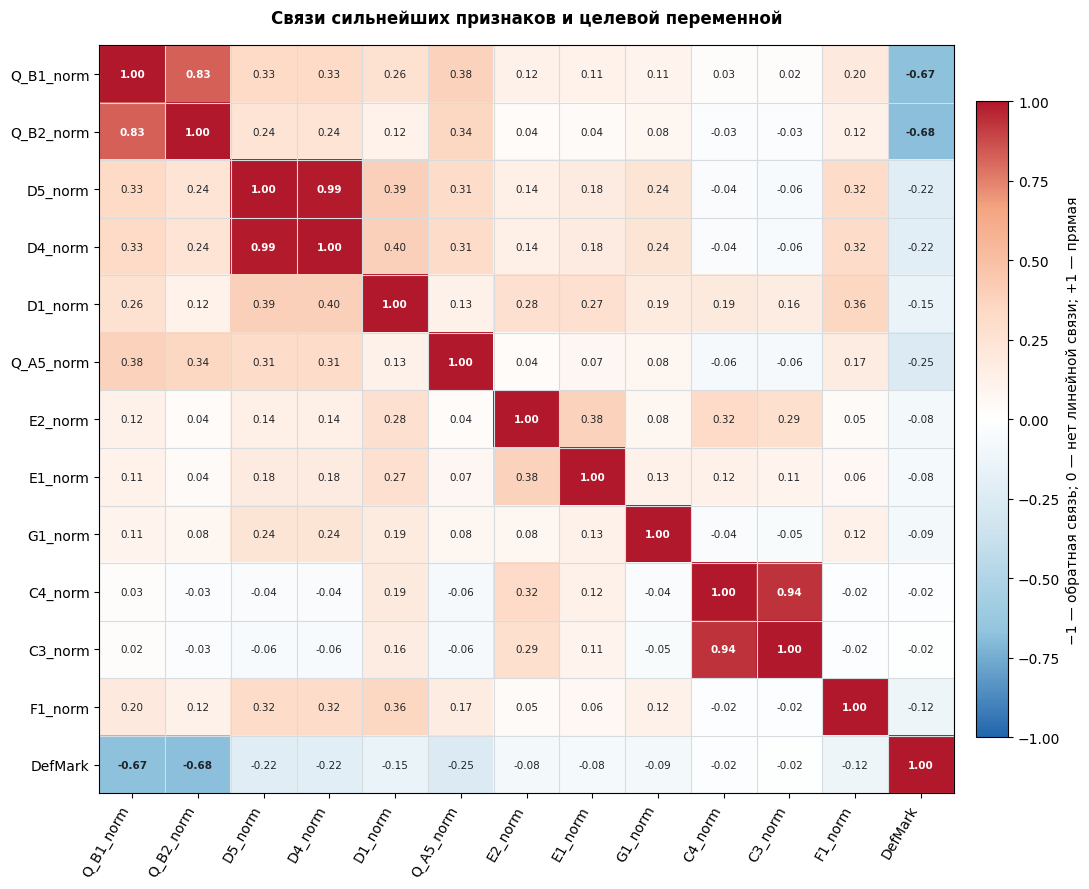

In [10]:
# @title Диагностика подозрительно сильных признаков
ПРИЗНАКИ = [
    столбец for столбец in данные.columns
    if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
]
y_полный = данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ].astype("int8")

строки_однофакторного = []
for столбец in ПРИЗНАКИ:
    значения = данные[столбец].to_numpy()
    корреляция = float(np.corrcoef(значения, y_полный.to_numpy())[0, 1])
    auc = float(roc_auc_score(y_полный, значения))
    направление = "прямое" if auc >= 0.5 else "обратное"
    однофакторный_auc = max(auc, 1 - auc)
    строки_однофакторного.append({
        "Признак": столбец,
        "Корреляция с DefMark": корреляция,
        "Однофакторный ROC-AUC": однофакторный_auc,
        "Направление": направление,
    })

ОДНОФАКТОРНАЯ_ДИАГНОСТИКА = (
    pd.DataFrame(строки_однофакторного)
    .sort_values("Однофакторный ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

корреляционная_матрица = данные[ПРИЗНАКИ].corr()
сильные_пары = []
for i, левый in enumerate(ПРИЗНАКИ):
    for правый in ПРИЗНАКИ[i + 1:]:
        значение = float(корреляционная_матрица.loc[левый, правый])
        if abs(значение) >= 0.80:
            сильные_пары.append({
                "Признак 1": левый,
                "Признак 2": правый,
                "Корреляция": значение,
            })
СИЛЬНЫЕ_ПАРЫ = (
    pd.DataFrame(сильные_пары)
    .sort_values("Корреляция", key=lambda s: s.abs(), ascending=False)
    if сильные_пары
    else pd.DataFrame(columns=["Признак 1", "Признак 2", "Корреляция"])
)

display(ОДНОФАКТОРНАЯ_ДИАГНОСТИКА.head(15).style.format({
    "Корреляция с DefMark": "{:.3f}",
    "Однофакторный ROC-AUC": "{:.3f}",
}))
display(СИЛЬНЫЕ_ПАРЫ.head(20).style.format({"Корреляция": "{:.3f}"}))

ОДНОФАКТОРНАЯ_ДИАГНОСТИКА.to_csv(
    ПАПКИ["метрики"] / "однофакторная_диагностика.csv", index=False, encoding="utf-8-sig"
)
СИЛЬНЫЕ_ПАРЫ.to_csv(
    ПАПКИ["метрики"] / "сильные_корреляции.csv", index=False, encoding="utf-8-sig"
)

НЕИЗВЕСТНЫЕ_КРИТИЧНЫЕ_ПРИЗНАКИ = [
    столбец for столбец in ["Q_B2_norm"]
    if столбец in ПРИЗНАКИ
]
print(
    "Важно: высокая однофакторная сила — повод для абляции и проверки происхождения, "
    "а не автоматическое доказательство утечки."
)

# Интуитивная цветовая матрица для самых сильных признаков.
топ_для_матрицы = ОДНОФАКТОРНАЯ_ДИАГНОСТИКА.head(12)["Признак"].tolist()
столбцы_матрицы = топ_для_матрицы + [ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]
МАТРИЦА_СИЛЬНЫХ_ПРИЗНАКОВ = данные[столбцы_матрицы].corr()

построить_корреляционную_матрицу(
    МАТРИЦА_СИЛЬНЫХ_ПРИЗНАКОВ,
    "Связи сильнейших признаков и целевой переменной",
    путь=ПАПКИ["графики"] / "цветовая_матрица_сильных_признаков.png",
    размер=(11, 9),
)


In [11]:
# @title Анализ аудита потенциальной утечки
топ_признак = ОДНОФАКТОРНАЯ_ДИАГНОСТИКА.iloc[0]
q_b1 = ОДНОФАКТОРНАЯ_ДИАГНОСТИКА[
    ОДНОФАКТОРНАЯ_ДИАГНОСТИКА["Признак"] == "Q_B1_norm"
]
q_b2 = ОДНОФАКТОРНАЯ_ДИАГНОСТИКА[
    ОДНОФАКТОРНАЯ_ДИАГНОСТИКА["Признак"] == "Q_B2_norm"
]

строки = [
    f"- Самый сильный одиночный признак: **{топ_признак['Признак']}**, ROC-AUC = **{топ_признак['Однофакторный ROC-AUC']:.3f}**."
]
if not q_b1.empty:
    строки.append(
        f"- `Q_B1_norm`: однофакторный ROC-AUC = **{q_b1.iloc[0]['Однофакторный ROC-AUC']:.3f}**."
    )
if not q_b2.empty:
    строки.append(
        f"- `Q_B2_norm`: однофакторный ROC-AUC = **{q_b2.iloc[0]['Однофакторный ROC-AUC']:.3f}**; бизнес-расшифровка в источниках отсутствует."
    )
строки.append(f"- Пар признаков с |корреляцией| ≥ 0.80: **{len(СИЛЬНЫЕ_ПАРЫ)}**.")

display(Markdown(
    "### Анализ полученного результата\n\n"
    + "\n".join(строки)
    + "\n\n**Вывод:** `Q_B1_norm` и `Q_B2_norm` нельзя удалять молча. "
      "Их влияние будет измерено отдельными абляционными экспериментами. "
      "Следующий вопрос — как сформировать честные и одинаковые разбиения для всех моделей."
))

показать_панель(
    "Аудит возможной утечки",
    f"Самые сильные одиночные признаки: {', '.join(ОДНОФАКТОРНАЯ_ДИАГНОСТИКА.head(3)['Признак'].tolist())}. "
    "Высокая связь не является доказательством утечки; признаки проверяются отдельными абляциями.",
    "предупреждение",
)


### Анализ полученного результата

- Самый сильный одиночный признак: **Q_B1_norm**, ROC-AUC = **0.902**.
- `Q_B1_norm`: однофакторный ROC-AUC = **0.902**.
- `Q_B2_norm`: однофакторный ROC-AUC = **0.837**; бизнес-расшифровка в источниках отсутствует.
- Пар признаков с |корреляцией| ≥ 0.80: **7**.

**Вывод:** `Q_B1_norm` и `Q_B2_norm` нельзя удалять молча. Их влияние будет измерено отдельными абляционными экспериментами. Следующий вопрос — как сформировать честные и одинаковые разбиения для всех моделей.

# 7. Финальный тестовая выборка и кросс-валидация

**Исследовательский вопрос:** как сравнить модели так, чтобы финальная оценка не участвовала в выборе решения?

Фиксируем:

- 20% — финальный стратифицированный тестовая выборка;
- 80% — рабочая выборка;
- внутри рабочих 80% — одинаковая трёхфолдовая `StratifiedKFold`;
- порог, признаки, веса классов и параметры выбираются только по внефолдовые-прогнозам.

Финальный тестовая выборка будет открыт только после сохранения файла с зафиксированным решением.

In [12]:
# @title Формирование честных разбиений
X_все = данные[ПРИЗНАКИ].copy()
y_все = данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ].astype("int8").copy()
инн_все = данные[ИДЕНТИФИКАТОР].astype("string").copy()

индексы = np.arange(len(данные))
индексы_работа, индексы_test = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОЙ_ТЕСТОВОЙ_ВЫБОРКИ,
    stratify=y_все,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

X_работа = X_все.iloc[индексы_работа].reset_index(drop=True)
y_работа = y_все.iloc[индексы_работа].reset_index(drop=True)
инн_работа = инн_все.iloc[индексы_работа].reset_index(drop=True)

X_test = X_все.iloc[индексы_test].reset_index(drop=True)
y_test = y_все.iloc[индексы_test].reset_index(drop=True)
инн_test = инн_все.iloc[индексы_test].reset_index(drop=True)

КРОСС_ВАЛИДАЦИЯ = StratifiedKFold(
    n_splits=ЧИСЛО_ФОЛДОВ,
    shuffle=True,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)
ФОЛДЫ = list(КРОСС_ВАЛИДАЦИЯ.split(X_работа, y_работа))

таблица_разбиений = []
таблица_разбиений.append({
    "Часть": "Рабочая выборка",
    "Строк": len(y_работа),
    "Дефолтов": int(y_работа.sum()),
    "Доля дефолтов, %": float(y_работа.mean() * 100),
})
таблица_разбиений.append({
    "Часть": "Финальная тестовая выборка",
    "Строк": len(y_test),
    "Дефолтов": int(y_test.sum()),
    "Доля дефолтов, %": float(y_test.mean() * 100),
})
for номер, (индекс_train, индекс_valid) in enumerate(ФОЛДЫ, start=1):
    таблица_разбиений.append({
        "Часть": f"Фолд {номер}: обучение",
        "Строк": len(индекс_train),
        "Дефолтов": int(y_работа.iloc[индекс_train].sum()),
        "Доля дефолтов, %": float(y_работа.iloc[индекс_train].mean() * 100),
    })
    таблица_разбиений.append({
        "Часть": f"Фолд {номер}: проверка",
        "Строк": len(индекс_valid),
        "Дефолтов": int(y_работа.iloc[индекс_valid].sum()),
        "Доля дефолтов, %": float(y_работа.iloc[индекс_valid].mean() * 100),
    })

ТАБЛИЦА_РАЗБИЕНИЙ = pd.DataFrame(таблица_разбиений)
display(ТАБЛИЦА_РАЗБИЕНИЙ.style.format({"Доля дефолтов, %": "{:.2f}"}))

пересечение_инн = set(инн_работа).intersection(set(инн_test))
if пересечение_инн:
    raise RuntimeError("Один и тот же ИНН попал одновременно в рабочую и тестовую выборки.")

описание_разбиения = {
    "случайное_зерно": СЛУЧАЙНОЕ_ЗЕРНО,
    "доля_тестовой_выборки": ДОЛЯ_ФИНАЛЬНОЙ_ТЕСТОВОЙ_ВЫБОРКИ,
    "число_фолдов": ЧИСЛО_ФОЛДОВ,
    "строк_работа": len(y_работа),
    "строк_тестовая_выборка": len(y_test),
    "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
}
сохранить_json(описание_разбиения, ПАПКИ["метаданные"] / "схема_разбиения.json")
print("✓ Финальная тестовая выборка изолирована. До специальной финальной главы её метки не используются.")

,Часть,Строк,Дефолтов,"Доля дефолтов, %"
0,Рабочая выборка,289614,28015,9.67
1,Финальная тестовая выборка,72404,7004,9.67
2,Фолд 1: обучение,193076,18677,9.67
3,Фолд 1: проверка,96538,9338,9.67
4,Фолд 2: обучение,193076,18677,9.67
5,Фолд 2: проверка,96538,9338,9.67
6,Фолд 3: обучение,193076,18676,9.67
7,Фолд 3: проверка,96538,9339,9.67


✓ Финальная тестовая выборка изолирована. До специальной финальной главы её метки не используются.


In [13]:
# @title Анализ разбиения
display(Markdown(f"""
### Анализ полученного результата

Рабочая выборка содержит **{len(y_работа):,} строк**, финальная тестовая выборка — **{len(y_test):,} строк**.
Доля дефолтов сохранена: **{y_работа.mean()*100:.2f}%** в рабочей части и **{y_test.mean()*100:.2f}%** в тестовой выборке.

Все модели будут получать одни и те же {ЧИСЛО_ФОЛДОВ} фолда. ИНН между рабочей и тестовой частями не пересекаются.

**Ограничение:** в датасете нет даты наблюдения, поэтому это случайное стратифицированное, а не разделение по времени. Оно измеряет качество на похожей выборке, но не доказывает устойчивость на будущих периодах.

**Следующий вопрос:** какие модели сравнить и как единообразно считать все метрики?
"""))

показать_панель(
    "Честное разделение создано",
    f"Рабочая часть: {len(y_работа):,} строк; финальная тестовая часть: {len(y_test):,}. "
    f"Пересечение ИНН: {len(пересечение_инн)}.",
    "успех",
)



### Анализ полученного результата

Рабочая выборка содержит **289,614 строк**, финальная тестовая выборка — **72,404 строк**.
Доля дефолтов сохранена: **9.67%** в рабочей части и **9.67%** в тестовой выборке.

Все модели будут получать одни и те же 3 фолда. ИНН между рабочей и тестовой частями не пересекаются.

**Ограничение:** в датасете нет даты наблюдения, поэтому это случайное стратифицированное, а не разделение по времени. Оно измеряет качество на похожей выборке, но не доказывает устойчивость на будущих периодах.

**Следующий вопрос:** какие модели сравнить и как единообразно считать все метрики?


# 8. Единый экспериментальный движок

**Исследовательский вопрос:** как сравнить разные алгоритмы в одинаковых условиях?

Создаём единый реестр моделей и функции, которые:

- обучают модель на каждом фиксированном фолде;
- собирают внефолдовые-вероятности;
- считают метрики класса `DefMark = 1`;
- измеряют время обучения и инференса;
- сохраняют результаты и ошибки;
- не используют финальная тестовая выборка.

В интерфейсе не требуется вводить глубину деревьев или число итераций: разумные значения уже заданы выбранным профилем запуска.

In [14]:
# @title Метрики, пороги и честная калибровка вероятностей
def безопасное_деление(числитель: float, знаменатель: float) -> float:
    return float(числитель / знаменатель) if знаменатель else 0.0


ПОДПИСИ_МЕТРИК = {
    "Accuracy": "Общая точность",
    "Balanced Accuracy": "Сбалансированная точность",
    "Precision": "Точность предупреждений",
    "Recall": "Полнота найденных дефолтов",
    "F1": "F1 — баланс точности и полноты",
    "F2": "F2 — повышенный приоритет полноты",
    "ROC-AUC": "Площадь под ROC-кривой",
    "Gini": "Gini",
    "PR-AUC": "Площадь под кривой точность–полнота",
    "Brier": "Ошибка вероятностей Brier",
    "Specificity": "Доля верно распознанных недефолтов",
    "FNR": "Доля пропущенных дефолтов",
    "FPR": "Доля ложных предупреждений",
    "Gini: std по фолдам": "Разброс Gini по фолдам",
    "PR-AUC: среднее по фолдам": "Средняя площадь точность–полнота по фолдам",
    "PR-AUC: std по фолдам": "Разброс площади точность–полнота по фолдам",
    "Recall: среднее по фолдам": "Средняя полнота дефолтов по фолдам",
    "Чувствительный Precision": "Точность предупреждений чувствительного сценария",
    "Чувствительный Recall": "Полнота дефолтов чувствительного сценария",
    "Чувствительный F1": "F1 чувствительного сценария",
    "Чувствительный F2": "F2 чувствительного сценария",
    "Время обучения CV, сек": "Время кросс-валидации, сек",
    "Время прогноза CV, сек": "Время прогнозирования по фолдам, сек",
}


def русские_названия_метрик(таблица: pd.DataFrame) -> pd.DataFrame:
    return таблица.rename(columns=ПОДПИСИ_МЕТРИК)


def рассчитать_метрики(
    истинные_классы: pd.Series | np.ndarray,
    вероятности: np.ndarray,
    порог: float = 0.5,
) -> dict[str, float]:
    y_true = np.asarray(истинные_классы, dtype=int)
    y_score = np.asarray(вероятности, dtype=float)
    y_pred = (y_score >= порог).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    roc_auc = float(roc_auc_score(y_true, y_score))

    return {
        "Порог": float(порог),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "F2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(y_true, y_score)),
        "Brier": float(brier_score_loss(y_true, y_score)),
        "Specificity": безопасное_деление(tn, tn + fp),
        "FNR": безопасное_деление(fn, fn + tp),
        "FPR": безопасное_деление(fp, fp + tn),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def обучить_калибратор(
    вероятности: np.ndarray,
    истинные_классы: pd.Series | np.ndarray,
    seed: int = СЛУЧАЙНОЕ_ЗЕРНО,
) -> LogisticRegression:
    """Обучает Platt-калибратор на переданном наборе вероятностей."""
    eps = 1e-6
    p = np.clip(np.asarray(вероятности), eps, 1 - eps)
    логиты = np.log(p / (1 - p)).reshape(-1, 1)
    калибратор = LogisticRegression(random_state=seed, max_iter=1_000)
    калибратор.fit(логиты, np.asarray(истинные_классы, dtype=int))
    return калибратор


def применить_калибратор(
    калибратор: LogisticRegression,
    вероятности: np.ndarray,
) -> np.ndarray:
    eps = 1e-6
    p = np.clip(np.asarray(вероятности), eps, 1 - eps)
    логиты = np.log(p / (1 - p)).reshape(-1, 1)
    return калибратор.predict_proba(логиты)[:, 1]


def кросс_калибровать_oof(
    сырые_oof: np.ndarray,
    истинные_классы: pd.Series | np.ndarray,
    фолды: list[tuple[np.ndarray, np.ndarray]],
) -> tuple[np.ndarray, LogisticRegression]:
    """
    Калибрует каждый validation-фолд калибратором, который не видел этот фолд.
    Отдельно обучает финальный калибратор на всех OOF-прогнозах для применения к тесту.
    """
    y = np.asarray(истинные_классы, dtype=int)
    p = np.asarray(сырые_oof, dtype=float)
    кросс_калиброванные = np.full(len(p), np.nan, dtype=float)

    все_индексы = np.arange(len(p))
    for номер_фолда, (_, индексы_проверки) in enumerate(фолды, start=1):
        индексы_обучения_калибратора = np.setdiff1d(
            все_индексы, индексы_проверки, assume_unique=False
        )
        калибратор_фолда = обучить_калибратор(
            p[индексы_обучения_калибратора],
            y[индексы_обучения_калибратора],
            seed=СЛУЧАЙНОЕ_ЗЕРНО + номер_фолда,
        )
        кросс_калиброванные[индексы_проверки] = применить_калибратор(
            калибратор_фолда, p[индексы_проверки]
        )

    if np.isnan(кросс_калиброванные).any():
        raise RuntimeError("Кросс-калиброванные OOF-прогнозы заполнены не полностью.")

    финальный_калибратор = обучить_калибратор(p, y)
    return кросс_калиброванные, финальный_калибратор


def таблица_порогов(
    y_true: pd.Series | np.ndarray,
    вероятности: np.ndarray,
    стоимость_fn: float = 5.0,
    стоимость_fp: float = 1.0,
) -> pd.DataFrame:
    сетка = np.unique(np.concatenate([
        np.linspace(0.01, 0.99, 99),
        np.quantile(вероятности, np.linspace(0.01, 0.99, 49)),
        np.array([0.5]),
    ]))
    строки = []
    for порог in сетка:
        метрики = рассчитать_метрики(y_true, вероятности, float(порог))
        метрики["Условная стоимость"] = (
            стоимость_fn * метрики["FN"] + стоимость_fp * метрики["FP"]
        )
        строки.append(метрики)
    return pd.DataFrame(строки).sort_values("Порог").reset_index(drop=True)


def выбрать_сценарии_порогов(
    y_true: pd.Series | np.ndarray,
    вероятности: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    таблица = таблица_порогов(y_true, вероятности)

    стандартный = таблица.iloc[(таблица["Порог"] - 0.5).abs().argmin()]
    сбалансированный = таблица.loc[таблица["F1"].idxmax()]

    допустимые = таблица[таблица["Recall"] >= 0.80]
    if допустимые.empty:
        чувствительный = таблица.loc[таблица["Recall"].idxmax()]
    else:
        чувствительный = допустимые.sort_values(
            ["Precision", "F1", "Порог"], ascending=[False, False, False]
        ).iloc[0]

    минимальная_стоимость = таблица.loc[таблица["Условная стоимость"].idxmin()]

    выбранные = pd.DataFrame([
        {"Сценарий": "Стандартный", **стандартный.to_dict()},
        {"Сценарий": "Сбалансированный", **сбалансированный.to_dict()},
        {"Сценарий": "Чувствительный", **чувствительный.to_dict()},
        {"Сценарий": "Исследовательский по стоимости", **минимальная_стоимость.to_dict()},
    ])
    выбранные["Пояснение"] = [
        "Порог 0,5: высокая точность предупреждений, но больше пропущенных дефолтов",
        "Максимум F1: равновесный компромисс точности и полноты",
        "Полнота не ниже 0,80 при максимально возможной точности предупреждений",
        "Минимум условной функции 5×FN + 1×FP; правило бизнесом не утверждено",
    ]
    return выбранные, таблица


In [15]:
# @title Реестр моделей
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def положительный_вес(y: pd.Series | np.ndarray) -> float:
    значения = np.asarray(y, dtype=int)
    отрицательных = int((значения == 0).sum())
    положительных = int((значения == 1).sum())
    return отрицательных / положительных

def создать_модель(
    код_модели: str,
    y_train: pd.Series | np.ndarray,
    использовать_веса: bool = False,
    параметры: dict[str, Any] | None = None,
    seed: int = СЛУЧАЙНОЕ_ЗЕРНО,
):
    параметры = параметры.copy() if параметры else {}
    вес = положительный_вес(y_train) if использовать_веса else 1.0
    деревьев = НАСТРОЙКИ_ПРОФИЛЯ["деревьев"]
    итераций = НАСТРОЙКИ_ПРОФИЛЯ["итераций_бустинга"]

    if код_модели == "dummy":
        return DummyClassifier(strategy="prior", random_state=seed)

    if код_модели == "logistic":
        базовые = {
            "max_iter": 2_000,
            "solver": "lbfgs",
            "class_weight": "balanced" if использовать_веса else None,
            "random_state": seed,
        }
        базовые.update(параметры)
        return Pipeline([
            ("масштабирование", StandardScaler()),
            ("модель", LogisticRegression(**базовые)),
        ])

    if код_модели == "decision_tree":
        базовые = {
            "max_depth": 8,
            "min_samples_leaf": 50,
            "class_weight": "balanced" if использовать_веса else None,
            "random_state": seed,
        }
        базовые.update(параметры)
        return DecisionTreeClassifier(**базовые)

    if код_модели == "random_forest":
        базовые = {
            "n_estimators": деревьев,
            "max_depth": None,
            "min_samples_leaf": 3,
            "max_features": "sqrt",
            "class_weight": "balanced_subsample" if использовать_веса else None,
            "n_jobs": ЧИСЛО_ПОТОКОВ,
            "random_state": seed,
        }
        базовые.update(параметры)
        return RandomForestClassifier(**базовые)

    if код_модели == "extra_trees":
        базовые = {
            "n_estimators": деревьев,
            "max_depth": None,
            "min_samples_leaf": 3,
            "max_features": "sqrt",
            "class_weight": "balanced" if использовать_веса else None,
            "n_jobs": ЧИСЛО_ПОТОКОВ,
            "random_state": seed,
        }
        базовые.update(параметры)
        return ExtraTreesClassifier(**базовые)

    if код_модели == "hist_gradient_boosting":
        базовые = {
            "max_iter": итераций,
            "learning_rate": 0.08,
            "max_leaf_nodes": 31,
            "l2_regularization": 1.0,
            "early_stopping": True,
            "validation_fraction": 0.10,
            "random_state": seed,
        }
        базовые.update(параметры)
        модель = HistGradientBoostingClassifier(**базовые)
        return модель

    if код_модели == "xgboost":
        базовые = {
            "n_estimators": итераций,
            "learning_rate": 0.06,
            "max_depth": 6,
            "min_child_weight": 3,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.05,
            "reg_lambda": 1.0,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "scale_pos_weight": вес,
            "n_jobs": ЧИСЛО_ПОТОКОВ,
            "random_state": seed,
            "tree_method": "hist",
        }
        базовые.update(параметры)
        return XGBClassifier(**базовые)

    if код_модели == "lightgbm":
        базовые = {
            "n_estimators": итераций,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "min_child_samples": 40,
            "subsample": 0.85,
            "subsample_freq": 1,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.05,
            "reg_lambda": 1.0,
            "class_weight": "balanced" if использовать_веса else None,
            "n_jobs": ЧИСЛО_ПОТОКОВ,
            "random_state": seed,
            "verbosity": -1,
        }
        базовые.update(параметры)
        return LGBMClassifier(**базовые)

    if код_модели == "catboost":
        базовые = {
            "iterations": итераций,
            "learning_rate": 0.06,
            "depth": 7,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": seed,
            "thread_count": ЧИСЛО_ПОТОКОВ,
            "verbose": False,
            "allow_writing_files": False,
        }
        if использовать_веса:
            базовые["class_weights"] = [1.0, вес]
        базовые.update(параметры)
        return CatBoostClassifier(**базовые)

    raise KeyError(f"Неизвестная модель: {код_модели}")

РЕЕСТР_МОДЕЛЕЙ = {
    "dummy": "Dummy — случайный ориентир",
    "logistic": "Логистическая регрессия",
    "decision_tree": "Дерево решений",
    "random_forest": "Случайный лес",
    "extra_trees": "Extra Trees",
    "hist_gradient_boosting": "HistGradientBoosting",
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
}
display(pd.DataFrame(
    [{"Код": код, "Модель": название} for код, название in РЕЕСТР_МОДЕЛЕЙ.items()]
))

,Код,Модель
0,dummy,Dummy — случайный ориентир
1,logistic,Логистическая регрессия
2,decision_tree,Дерево решений
3,random_forest,Случайный лес
4,extra_trees,Extra Trees
5,hist_gradient_boosting,HistGradientBoosting
6,xgboost,XGBoost
7,lightgbm,LightGBM
8,catboost,CatBoost


In [16]:
# @title Функции кросс-валидации, ранней остановки и кэширования
def подпись_эксперимента(
    код_модели: str,
    признаки: list[str],
    использовать_веса: bool,
    параметры: dict[str, Any] | None,
    seed: int,
) -> str:
    содержимое = json.dumps({
        "версия": ВЕРСИЯ_КОНВЕЙЕРА,
        "sha256": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "модель": код_модели,
        "признаки": признаки,
        "веса": использовать_веса,
        "параметры": параметры or {},
        "seed": seed,
        "фолды": ЧИСЛО_ФОЛДОВ,
    }, ensure_ascii=False, sort_keys=True, default=str)
    return hashlib.sha256(содержимое.encode("utf-8")).hexdigest()[:16]


def обучить_на_фолде(
    модель,
    код_модели: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    использовать_веса: bool,
):
    """Обучает модель. Для бустингов validation используется только внутри train/CV."""
    if код_модели == "xgboost":
        модель.set_params(early_stopping_rounds=40)
        модель.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False,
        )
        return модель

    if код_модели == "lightgbm":
        from lightgbm import early_stopping
        модель.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            callbacks=[early_stopping(40, verbose=False)],
        )
        return модель

    if код_модели == "catboost":
        модель.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=40,
            verbose=False,
        )
        return модель

    if код_модели == "hist_gradient_boosting" and использовать_веса:
        вес = положительный_вес(y_train)
        веса_строк = np.where(y_train.to_numpy() == 1, вес, 1.0)
        модель.fit(X_train, y_train, sample_weight=веса_строк)
        return модель

    модель.fit(X_train, y_train)
    return модель


def лучшая_итерация(модель, код_модели: str) -> int | None:
    """Возвращает фактически выбранное число итераций, если оно доступно."""
    значение = None
    if код_модели == "xgboost":
        значение = getattr(модель, "best_iteration", None)
        if значение is not None:
            значение = int(значение) + 1
    elif код_модели == "lightgbm":
        значение = getattr(модель, "best_iteration_", None)
    elif код_модели == "catboost":
        try:
            значение = int(модель.get_best_iteration()) + 1
        except Exception:
            значение = None
    elif код_модели == "hist_gradient_boosting":
        значение = getattr(модель, "n_iter_", None)

    if значение is None or int(значение) <= 0:
        return None
    return int(значение)


def проверить_структуру_cv_кэша(объект) -> None:
    обязательные = {
        "итоговые_метрики", "метрики_фолдов", "oof_вероятности",
        "признаки", "параметры", "seed",
    }
    if not isinstance(объект, dict):
        raise TypeError("CV-кэш должен быть словарём.")
    отсутствуют = обязательные.difference(объект)
    if отсутствуют:
        raise KeyError(f"В CV-кэше отсутствуют поля: {sorted(отсутствуют)}")
    if len(np.asarray(объект["oof_вероятности"])) != len(y_работа):
        raise ValueError("Длина OOF-прогнозов не совпадает с рабочей выборкой.")


def выполнить_cv(
    код_модели: str,
    признаки: list[str],
    использовать_веса: bool = False,
    параметры: dict[str, Any] | None = None,
    seed: int = СЛУЧАЙНОЕ_ЗЕРНО,
    использовать_кэш: bool = True,
) -> dict[str, Any]:
    подпись = подпись_эксперимента(
        код_модели, признаки, использовать_веса, параметры, seed
    )
    путь_кэша = ПАПКИ["кэш"] / f"cv_{подпись}.joblib"

    if (
        использовать_кэш
        and ИСПОЛЬЗОВАТЬ_КЭШ
        and not ПЕРЕСЧИТАТЬ_ЭКСПЕРИМЕНТЫ
        and путь_кэша.exists()
    ):
        try:
            результат = загрузить_joblib_с_безопасной_миграцией(
                путь_кэша,
                ожидаемые_поля={
                    "тип": "cv_cache",
                    "подпись_эксперимента": подпись,
                    "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
                },
                проверка_структуры=проверить_структуру_cv_кэша,
            )
        except Exception as ошибка_кэша:
            показать_панель(
                "CV-кэш отклонён",
                f"{путь_кэша.name}: {ошибка_кэша}. Эксперимент будет пересчитан.",
                "предупреждение",
            )
            результат = None
        if результат is not None:
            результат = dict(результат)
            результат["источник_результата"] = "кэш"
            результат["итоговые_метрики"] = dict(
                результат["итоговые_метрики"]
            )
            результат["итоговые_метрики"]["Источник результата"] = "кэш"
            print(f"  ↳ {РЕЕСТР_МОДЕЛЕЙ[код_модели]}: загружено из кэша")
            return результат

    X = X_работа[признаки]
    oof = np.full(len(X), np.nan, dtype=np.float64)
    метрики_фолдов = []
    ошибки = []

    for номер_фолда, (индекс_train, индекс_valid) in enumerate(ФОЛДЫ, start=1):
        X_train = X.iloc[индекс_train]
        y_train = y_работа.iloc[индекс_train]
        X_valid = X.iloc[индекс_valid]
        y_valid = y_работа.iloc[индекс_valid]

        try:
            модель = создать_модель(
                код_модели,
                y_train,
                использовать_веса=использовать_веса,
                параметры=параметры,
                seed=seed + номер_фолда,
            )
            начало_обучения = perf_counter()
            модель = обучить_на_фолде(
                модель,
                код_модели,
                X_train,
                y_train,
                X_valid,
                y_valid,
                использовать_веса,
            )
            время_обучения = perf_counter() - начало_обучения

            начало_прогноза = perf_counter()
            вероятности = модель.predict_proba(X_valid)[:, 1]
            время_прогноза = perf_counter() - начало_прогноза

            oof[индекс_valid] = вероятности
            метрики = рассчитать_метрики(y_valid, вероятности, порог=0.5)
            метрики.update({
                "Фолд": номер_фолда,
                "Время обучения, сек": время_обучения,
                "Время прогноза, сек": время_прогноза,
                "Мс на 1000 строк": время_прогноза / len(X_valid) * 1_000 * 1_000,
                "Лучшая итерация": лучшая_итерация(модель, код_модели),
            })
            метрики_фолдов.append(метрики)
            del модель
            gc.collect()

        except Exception as ошибка:
            ошибки.append({
                "Модель": код_модели,
                "Фолд": номер_фолда,
                "Тип": type(ошибка).__name__,
                "Сообщение": str(ошибка),
            })
            break

    if ошибки:
        raise RuntimeError(
            f"Ошибка эксперимента {код_модели}: {ошибки[0]['Тип']}: "
            f"{ошибки[0]['Сообщение']}"
        )

    if np.isnan(oof).any():
        raise RuntimeError(f"OOF-прогнозы {код_модели} заполнены не полностью.")

    таблица_фолдов = pd.DataFrame(метрики_фолдов)
    итоговые = рассчитать_метрики(y_работа, oof, порог=0.5)

    доступные_итерации = pd.to_numeric(
        таблица_фолдов["Лучшая итерация"], errors="coerce"
    ).dropna()
    рекомендуемые_итерации = (
        int(np.median(доступные_итерации))
        if not доступные_итерации.empty
        else None
    )

    итоговые.update({
        "Код модели": код_модели,
        "Модель": РЕЕСТР_МОДЕЛЕЙ[код_модели],
        "Веса классов": "Да" if использовать_веса else "Нет",
        "Число признаков": len(признаки),
        "Gini: среднее по фолдам": float(таблица_фолдов["Gini"].mean()),
        "Gini: std по фолдам": float(таблица_фолдов["Gini"].std(ddof=1)),
        "PR-AUC: среднее по фолдам": float(таблица_фолдов["PR-AUC"].mean()),
        "PR-AUC: std по фолдам": float(таблица_фолдов["PR-AUC"].std(ddof=1)),
        "Recall: среднее по фолдам": float(таблица_фолдов["Recall"].mean()),
        "Время обучения CV, сек": float(таблица_фолдов["Время обучения, сек"].sum()),
        "Время прогноза CV, сек": float(таблица_фолдов["Время прогноза, сек"].sum()),
        "Рекомендуемое число итераций": рекомендуемые_итерации,
        "Параметры": параметры or {},
        "Подпись": подпись,
    })

    итоговые["Источник результата"] = "расчёт"

    результат = {
        "итоговые_метрики": итоговые,
        "метрики_фолдов": таблица_фолдов,
        "источник_результата": "расчёт",
        "oof_вероятности": oof,
        "признаки": признаки,
        "параметры": параметры or {},
        "использовать_веса": использовать_веса,
        "seed": seed,
        "рекомендуемое_число_итераций": рекомендуемые_итерации,
    }
    сохранить_joblib_атомарно(
        результат,
        путь_кэша,
        метаданные={
            "тип": "cv_cache",
            "подпись_эксперимента": подпись,
            "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
        },
        compress=3,
    )
    print(
        f"  ✓ {РЕЕСТР_МОДЕЛЕЙ[код_модели]}: "
        f"Gini={итоговые['Gini']:.4f}, PR-AUC={итоговые['PR-AUC']:.4f}"
    )
    return результат

# 9. Базовое сравнение моделей

**Исследовательский вопрос:** какие алгоритмы лучше всего ранжируют риск без дорогого подбора параметров?

Все модели получают одинаковые стратифицированные фолды. В таблицах используются внефолдовые прогнозы: каждая строка оценивается моделью, которая не обучалась на этой строке.



Запуск: Dummy — случайный ориентир
  ✓ Dummy — случайный ориентир: Gini=-0.0000, PR-AUC=0.0967

Запуск: Логистическая регрессия
  ✓ Логистическая регрессия: Gini=0.9018, PR-AUC=0.8371

Запуск: Дерево решений
  ✓ Дерево решений: Gini=0.8963, PR-AUC=0.8353

Запуск: Случайный лес
  ✓ Случайный лес: Gini=0.9147, PR-AUC=0.8579

Запуск: Extra Trees
  ✓ Extra Trees: Gini=0.9148, PR-AUC=0.8570

Запуск: HistGradientBoosting
  ✓ HistGradientBoosting: Gini=0.9211, PR-AUC=0.8634

Запуск: XGBoost
  ✓ XGBoost: Gini=0.9232, PR-AUC=0.8658

Запуск: LightGBM
  ✓ LightGBM: Gini=0.9228, PR-AUC=0.8655

Запуск: CatBoost
  ✓ CatBoost: Gini=0.9236, PR-AUC=0.8664


,Модель,Gini,Разброс Gini по фолдам,Площадь под ROC-кривой,Площадь под кривой точность–полнота,Точность предупреждений,Полнота найденных дефолтов,F1 — баланс точности и полноты,"Время кросс-валидации, сек","Время прогнозирования по фолдам, сек"
0,CatBoost,0.9236,0.0050,0.9618,0.8664,0.9215,0.6825,0.7842,194.0,0.331
1,XGBoost,0.9232,0.0055,0.9616,0.8658,0.9156,0.6861,0.7844,95.3,2.040
2,LightGBM,0.9228,0.0053,0.9614,0.8655,0.9124,0.6892,0.7853,91.5,5.555
3,HistGradientBoosting,0.9211,0.0063,0.9605,0.8634,0.9129,0.6841,0.7821,39.9,4.925
4,Extra Trees,0.9148,0.0065,0.9574,0.8570,0.9584,0.6337,0.7629,728.3,45.336
5,Случайный лес,0.9147,0.0057,0.9574,0.8579,0.9573,0.6389,0.7664,1592.7,38.148
6,Логистическая регрессия,0.9018,0.0065,0.9509,0.8371,0.8997,0.6520,0.7561,4.9,0.400
7,Дерево решений,0.8963,0.0079,0.9482,0.8353,0.9255,0.6426,0.7585,11.0,0.033
8,Dummy — случайный ориентир,-0.0000,0.0000,0.5000,0.0967,0.0000,0.0000,0.0000,0.0,0.006


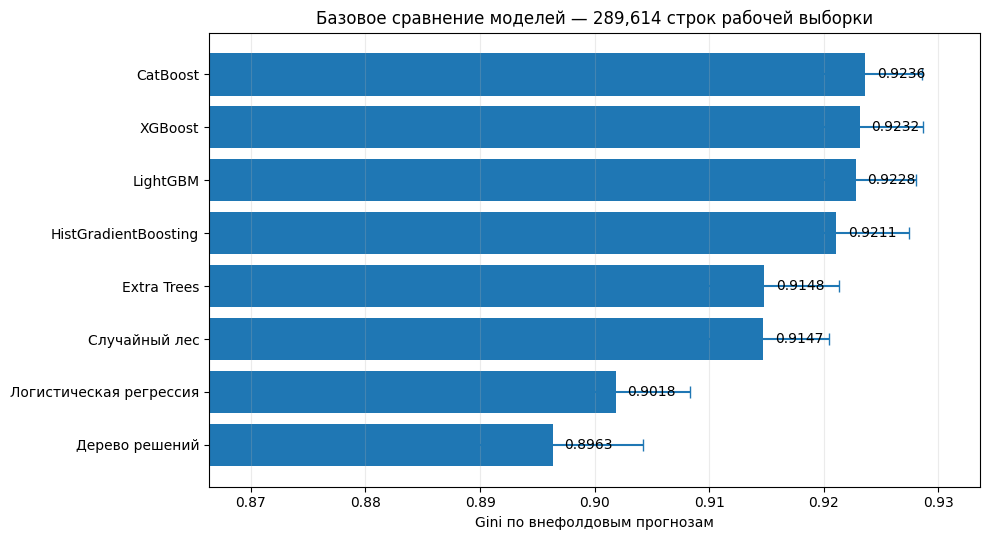

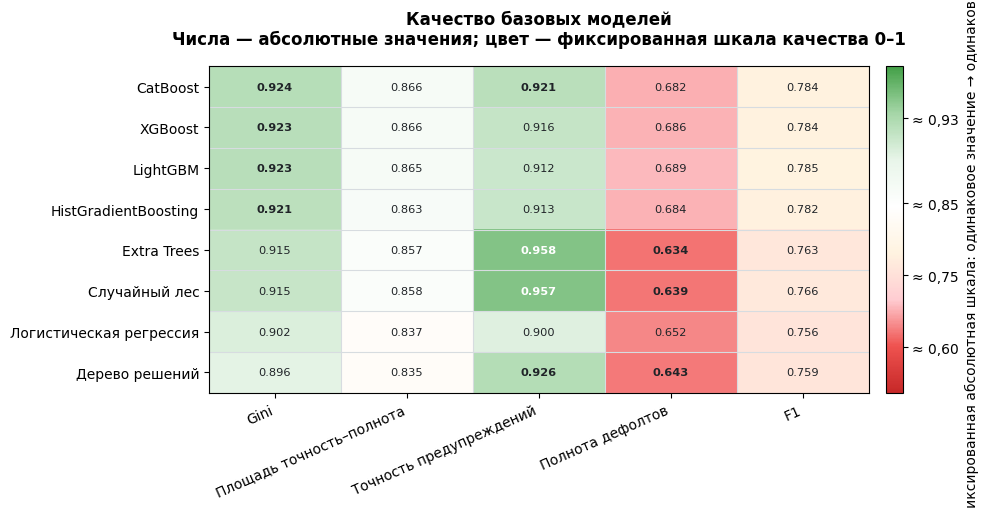

In [17]:
# @title Запуск базовых моделей
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Базовое сравнение моделей',
    {
        "модели": list(РЕЕСТР_МОДЕЛЕЙ.keys()),
        "число_признаков": len(ПРИЗНАКИ),
        "деревьев": НАСТРОЙКИ_ПРОФИЛЯ["деревьев"],
        "итераций_бустинга": НАСТРОЙКИ_ПРОФИЛЯ["итераций_бустинга"],
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Базовое сравнение моделей',
    _ПОДПИСЬ_ЭТАПА,
    ['РЕЗУЛЬТАТЫ_BASELINE', 'ОШИБКИ_BASELINE', 'ЛИДЕРБОРД_BASELINE', 'МАТРИЦА_МОДЕЛЕЙ'],
)

if _ВОССТАНОВЛЕНО:
    display(ЛИДЕРБОРД_BASELINE.head(10))

    # Метрики можно безопасно восстановить из checkpoint,
    # но визуализацию всегда строим заново текущей версией функции.
    # Это исключает ситуацию, когда в notebook остаётся график,
    # созданный старой цветовой логикой.
    if "МАТРИЦА_МОДЕЛЕЙ" in globals():
        построить_матрицу_абсолютных_метрик(
            МАТРИЦА_МОДЕЛЕЙ,
            "Качество базовых моделей",
            путь=ПАПКИ["графики"] / "цветовая_матрица_базовых_моделей.png",
            размер=(10, 5.2),
        )

    показать_панель(
        "Базовое сравнение восстановлено",
        (
            "Метрики прочитаны из совместимой контрольной точки. "
            "Цветовая матрица пересобрана заново по фиксированной абсолютной шкале."
        ),
        "информация",
    )
else:
    РЕЗУЛЬТАТЫ_BASELINE: dict[str, dict[str, Any]] = {}
    ОШИБКИ_BASELINE = []

    for код_модели in РЕЕСТР_МОДЕЛЕЙ:
        print(f"\nЗапуск: {РЕЕСТР_МОДЕЛЕЙ[код_модели]}")
        try:
            РЕЗУЛЬТАТЫ_BASELINE[код_модели] = выполнить_cv(
                код_модели=код_модели,
                признаки=ПРИЗНАКИ,
                использовать_веса=False,
            )
        except Exception as ошибка:
            запись = {
                "Код модели": код_модели,
                "Модель": РЕЕСТР_МОДЕЛЕЙ[код_модели],
                "Тип ошибки": type(ошибка).__name__,
                "Сообщение": str(ошибка),
            }
            ОШИБКИ_BASELINE.append(запись)
            print(f"  ✗ {запись['Тип ошибки']}: {запись['Сообщение']}")

    if not РЕЗУЛЬТАТЫ_BASELINE:
        raise RuntimeError("Не удалось выполнить ни одной базовой модели.")

    ЛИДЕРБОРД_BASELINE = pd.DataFrame([
        результат["итоговые_метрики"]
        for результат in РЕЗУЛЬТАТЫ_BASELINE.values()
    ]).sort_values(
        ["Gini", "PR-AUC", "Время обучения CV, сек"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    столбцы_показа = [
        "Модель", "Gini", "Gini: std по фолдам", "ROC-AUC", "PR-AUC",
        "Precision", "Recall", "F1", "Время обучения CV, сек",
        "Время прогноза CV, сек",
    ]
    display(русские_названия_метрик(ЛИДЕРБОРД_BASELINE[столбцы_показа]).style.format({
        "Gini": "{:.4f}",
        "Разброс Gini по фолдам": "{:.4f}",
        "Площадь под ROC-кривой": "{:.4f}",
        "Площадь под кривой точность–полнота": "{:.4f}",
        "Точность предупреждений": "{:.4f}",
        "Полнота найденных дефолтов": "{:.4f}",
        "F1 — баланс точности и полноты": "{:.4f}",
        "Время кросс-валидации, сек": "{:.1f}",
        "Время прогнозирования по фолдам, сек": "{:.3f}",
    }).background_gradient(subset=["Gini", "Площадь под кривой точность–полнота"], cmap=СВЕТЛАЯ_ЗЕЛЕНАЯ_ПАЛИТРА))

    ЛИДЕРБОРД_BASELINE.to_csv(
        ПАПКИ["метрики"] / "лидерборд_базовых_моделей.csv", index=False, encoding="utf-8-sig"
    )
    if ОШИБКИ_BASELINE:
        ТАБЛИЦА_ОШИБОК_BASELINE = pd.DataFrame(ОШИБКИ_BASELINE)
        display(ТАБЛИЦА_ОШИБОК_BASELINE)
        ТАБЛИЦА_ОШИБОК_BASELINE.to_csv(
            ПАПКИ["логи"] / "ошибки_базовых_моделей.csv", index=False, encoding="utf-8-sig"
        )

    # График с масштабом, позволяющим увидеть реальные различия.
    не_dummy = ЛИДЕРБОРД_BASELINE[ЛИДЕРБОРД_BASELINE["Код модели"] != "dummy"].copy()
    fig, ax = plt.subplots(figsize=(10, 5.5))
    y_pos = np.arange(len(не_dummy))
    ax.barh(y_pos, не_dummy["Gini"])
    ax.errorbar(
        не_dummy["Gini"],
        y_pos,
        xerr=не_dummy["Gini: std по фолдам"].fillna(0),
        fmt="none",
        capsize=4,
    )
    ax.set_yticks(y_pos, labels=не_dummy["Модель"])
    ax.invert_yaxis()
    минимум = max(0.0, float(не_dummy["Gini"].min()) - 0.03)
    максимум = min(1.0, float(не_dummy["Gini"].max()) + 0.01)
    ax.set_xlim(минимум, максимум)
    ax.set_xlabel("Gini по внефолдовым прогнозам")
    ax.set_title(f"Базовое сравнение моделей — {len(y_работа):,} строк рабочей выборки")
    ax.grid(axis="x", alpha=0.25)
    for i, значение in enumerate(не_dummy["Gini"]):
        ax.text(значение + 0.001, i, f"{значение:.4f}", va="center")
    plt.tight_layout()
    путь_графика = ПАПКИ["графики"] / "базовое_сравнение_gini.png"
    plt.savefig(путь_графика, dpi=160, bbox_inches="tight")
    plt.show()

    # Светлая цветовая матрица: числа абсолютные, цвет сравнивается внутри столбца.
    МАТРИЦА_МОДЕЛЕЙ = не_dummy.set_index("Модель")[[
        "Gini", "PR-AUC", "Precision", "Recall", "F1"
    ]].copy()
    МАТРИЦА_МОДЕЛЕЙ.columns = [
        "Gini", "Площадь точность–полнота",
        "Точность предупреждений", "Полнота дефолтов", "F1",
    ]
    построить_матрицу_абсолютных_метрик(
        МАТРИЦА_МОДЕЛЕЙ,
        "Качество базовых моделей",
        путь=ПАПКИ["графики"] / "цветовая_матрица_базовых_моделей.png",
        размер=(10, 5.2),
    )
    сохранить_контрольную_точку(
        'Базовое сравнение моделей',
        _ПОДПИСЬ_ЭТАПА,
        ['РЕЗУЛЬТАТЫ_BASELINE', 'ОШИБКИ_BASELINE', 'ЛИДЕРБОРД_BASELINE', 'МАТРИЦА_МОДЕЛЕЙ'],
    )


In [18]:
# @title Анализ базового сравнения
рабочий_лидерборд = ЛИДЕРБОРД_BASELINE[
    ЛИДЕРБОРД_BASELINE["Код модели"] != "dummy"
].reset_index(drop=True)
лидер = рабочий_лидерборд.iloc[0]
допуск_близости = 0.003
близкие = рабочий_лидерборд[
    рабочий_лидерборд["Gini"] >= лидер["Gini"] - допуск_близости
]

display(Markdown(f"""
### Анализ полученного результата

Лидер базового сравнения по Gini внефолдовых прогнозов — **{лидер['Модель']}**:

- Gini: **{лидер['Gini']:.4f}**;
- PR-AUC: **{лидер['PR-AUC']:.4f}**;
- Полнота дефолтов при пороге 0,5: **{лидер['Recall']:.4f}**;
- разброс Gini по фолдам: **{лидер['Gini: std по фолдам']:.4f}**.

В пределах **0.003 Gini** от лидера находятся **{len(близкие)} модели**:
{', '.join('**' + x + '**' for x in близкие['Модель'].tolist())}.

**Вывод:** различия между верхними моделями оцениваем не только по четвёртому знаку, но и по PR-AUC, скорости и устойчивости. Дорогой подбор параметров выполняется только для нескольких сильных CPU-кандидатов.
"""))

показать_панель(
    "Базовое сравнение завершено",
    f"Лидер: {рабочий_лидерборд.iloc[0]['Модель']} с Gini={рабочий_лидерборд.iloc[0]['Gini']:.4f}. "
    "Различия между ведущими бустингами оцениваются вместе с разбросом по фолдам и временем работы.",
    "успех",
)



### Анализ полученного результата

Лидер базового сравнения по Gini внефолдовых прогнозов — **CatBoost**:

- Gini: **0.9236**;
- PR-AUC: **0.8664**;
- Полнота дефолтов при пороге 0,5: **0.6825**;
- разброс Gini по фолдам: **0.0050**.

В пределах **0.003 Gini** от лидера находятся **4 модели**:
**CatBoost**, **XGBoost**, **LightGBM**, **HistGradientBoosting**.

**Вывод:** различия между верхними моделями оцениваем не только по четвёртому знаку, но и по PR-AUC, скорости и устойчивости. Дорогой подбор параметров выполняется только для нескольких сильных CPU-кандидатов.


# 10. Ограниченный подбор параметров лидеров

**Исследовательский вопрос:** даёт ли умеренный подбор гиперпараметров устойчивое улучшение относительно базовый уровень?

Подбор запускается только в профилях **«Рекомендуемый»** и **«Полный»**. В профиле **«Быстрая проверка»** этот этап корректно пропускается.

Количество попыток и диапазоны уже выбраны в профиле. Пользователю не нужно вводить технические числа вручную.

In [19]:
# @title Подбор параметров сильных моделей

# Фиксируем собственную случайность Optuna отдельно от случайности моделей.
# При одинаковых данных, пространстве поиска и версиях библиотек набор trial
# теперь будет воспроизводимым.
ЗЕРНО_OPTUNA = int(СЛУЧАЙНОЕ_ЗЕРНО)
ВЕРСИЯ_ПРОСТРАНСТВА_ПОДБОРА = "1.1"

_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Подбор параметров',
    {
        "кандидаты": [код for код in рабочий_лидерборд["Код модели"].tolist() if код in {"hist_gradient_boosting", "xgboost", "lightgbm", "catboost"}][:НАСТРОЙКИ_ПРОФИЛЯ["топ_кандидатов"]],
        "попыток": НАСТРОЙКИ_ПРОФИЛЯ["попыток_подбора"],
        "подбор_включён": НАСТРОЙКИ_ПРОФИЛЯ["подбор_параметров"],
        "seed_optuna": ЗЕРНО_OPTUNA,
        "версия_пространства_подбора": ВЕРСИЯ_ПРОСТРАНСТВА_ПОДБОРА,
        "baseline_подписи": {
            код: результат["итоговые_метрики"].get("Подпись")
            for код, результат in РЕЗУЛЬТАТЫ_BASELINE.items()
        },
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Подбор параметров',
    _ПОДПИСЬ_ЭТАПА,
    ['КАНДИДАТЫ_ДЛЯ_ПОДБОРА', 'ЛУЧШИЕ_ПАРАМЕТРЫ', 'РЕЗУЛЬТАТЫ_ПОДБОРА', 'ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ', 'ОБЩЕЕ_ВРЕМЯ_ПОДБОРА_ПАРАМЕТРОВ'],
)

if _ВОССТАНОВЛЕНО:
    print("✓ Лучшие параметры восстановлены для:", ", ".join(ЛУЧШИЕ_ПАРАМЕТРЫ) or "подбор не выполнялся")
else:
    ПОДДЕРЖИВАЮТ_ПОДБОР = {
        "hist_gradient_boosting", "xgboost", "lightgbm", "catboost"
    }
    кандидаты_из_лидерборда = [
        код for код in рабочий_лидерборд["Код модели"].tolist()
        if код in ПОДДЕРЖИВАЮТ_ПОДБОР
    ]
    КАНДИДАТЫ_ДЛЯ_ПОДБОРА = кандидаты_из_лидерборда[
        : НАСТРОЙКИ_ПРОФИЛЯ["топ_кандидатов"]
    ]

    def предложить_параметры(trial, код_модели: str) -> dict[str, Any]:
        if код_модели == "lightgbm":
            return {
                "num_leaves": trial.suggest_int("num_leaves", 20, 80),
                "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
                "learning_rate": trial.suggest_float("learning_rate", 0.025, 0.10, log=True),
                "subsample": trial.suggest_float("subsample", 0.70, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            }
        if код_модели == "xgboost":
            return {
                "max_depth": trial.suggest_int("max_depth", 4, 9),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
                "learning_rate": trial.suggest_float("learning_rate", 0.025, 0.10, log=True),
                "subsample": trial.suggest_float("subsample", 0.70, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            }
        if код_модели == "catboost":
            return {
                "depth": trial.suggest_int("depth", 5, 9),
                "learning_rate": trial.suggest_float("learning_rate", 0.025, 0.10, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
                "random_strength": trial.suggest_float("random_strength", 0.1, 2.0),
                "border_count": trial.suggest_int("border_count", 64, 192),
            }
        if код_модели == "hist_gradient_boosting":
            return {
                "learning_rate": trial.suggest_float("learning_rate", 0.025, 0.12, log=True),
                "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 20, 80),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 120),
                "l2_regularization": trial.suggest_float(
                    "l2_regularization", 1e-4, 5.0, log=True
                ),
            }
        return {}

    ЛУЧШИЕ_ПАРАМЕТРЫ: dict[str, dict[str, Any]] = {}
    РЕЗУЛЬТАТЫ_ПОДБОРА: dict[str, dict[str, Any]] = {}
    ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ: dict[str, float] = {}
    НАЧАЛО_ПОДБОРА_ПАРАМЕТРОВ = perf_counter()

    if not НАСТРОЙКИ_ПРОФИЛЯ["подбор_параметров"]:
        print(
            "Профиль «Быстрая проверка»: подбор параметров пропущен. "
            "Для итогового исследования выберите профиль «Рекомендуемый»."
        )
    else:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        for код_модели in КАНДИДАТЫ_ДЛЯ_ПОДБОРА:
            начало_подбора_модели = perf_counter()
            print(f"\nПодбор: {РЕЕСТР_МОДЕЛЕЙ[код_модели]}")
            имя_исследования = (
                f"v{ВЕРСИЯ_ДЛЯ_ПУТИ}_tune{ВЕРСИЯ_ПРОСТРАНСТВА_ПОДБОРА}"
                f"_seed{ЗЕРНО_OPTUNA}_{код_модели}_{БЕЗОПАСНОЕ_ИМЯ_ПРОФИЛЯ}"
                f"_{КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА[:10]}"
            )
            база = ПАПКИ["хранилище_подбора"]
            хранилище = f"sqlite:///{база}"

            def цель(trial):
                параметры = предложить_параметры(trial, код_модели)
                результат = выполнить_cv(
                    код_модели=код_модели,
                    признаки=ПРИЗНАКИ,
                    использовать_веса=False,
                    параметры=параметры,
                    использовать_кэш=True,
                )
                trial.set_user_attr(
                    "pr_auc", float(результат["итоговые_метрики"]["PR-AUC"])
                )
                return float(результат["итоговые_метрики"]["Gini"])

            sampler = optuna.samplers.TPESampler(
                seed=ЗЕРНО_OPTUNA,
            )

            study = optuna.create_study(
                study_name=имя_исследования,
                storage=хранилище,
                direction="maximize",
                sampler=sampler,
                load_if_exists=True,
            )
            осталось = max(
                0,
                НАСТРОЙКИ_ПРОФИЛЯ["попыток_подбора"] - len(study.trials),
            )
            if осталось:
                study.optimize(цель, n_trials=осталось, gc_after_trial=True)

            ЛУЧШИЕ_ПАРАМЕТРЫ[код_модели] = study.best_params
            РЕЗУЛЬТАТЫ_ПОДБОРА[код_модели] = выполнить_cv(
                код_модели=код_модели,
                признаки=ПРИЗНАКИ,
                использовать_веса=False,
                параметры=study.best_params,
            )
            ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ[код_модели] = (
                perf_counter() - начало_подбора_модели
            )
            print(
                f"✓ Лучший Gini: {study.best_value:.4f}; "
                f"попыток всего: {len(study.trials)}; "
                f"seed Optuna: {ЗЕРНО_OPTUNA}; "
                f"время: {ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ[код_модели]:.1f} сек."
            )

    сохранить_json(
        ЛУЧШИЕ_ПАРАМЕТРЫ,
        ПАПКИ["подбор"] / "лучшие_параметры.json",
    )
    ОБЩЕЕ_ВРЕМЯ_ПОДБОРА_ПАРАМЕТРОВ = perf_counter() - НАЧАЛО_ПОДБОРА_ПАРАМЕТРОВ
    сохранить_контрольную_точку(
        'Подбор параметров',
        _ПОДПИСЬ_ЭТАПА,
        ['КАНДИДАТЫ_ДЛЯ_ПОДБОРА', 'ЛУЧШИЕ_ПАРАМЕТРЫ', 'РЕЗУЛЬТАТЫ_ПОДБОРА', 'ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ', 'ОБЩЕЕ_ВРЕМЯ_ПОДБОРА_ПАРАМЕТРОВ'],
    )



Подбор: CatBoost
  ✓ CatBoost: Gini=0.9234, PR-AUC=0.8662
  ✓ CatBoost: Gini=0.9207, PR-AUC=0.8630
  ✓ CatBoost: Gini=0.9234, PR-AUC=0.8657
  ✓ CatBoost: Gini=0.9219, PR-AUC=0.8643
  ✓ CatBoost: Gini=0.9239, PR-AUC=0.8667
  ✓ CatBoost: Gini=0.9238, PR-AUC=0.8667
  ✓ CatBoost: Gini=0.9234, PR-AUC=0.8662
  ✓ CatBoost: Gini=0.9238, PR-AUC=0.8664
  ✓ CatBoost: Gini=0.9226, PR-AUC=0.8652
  ✓ CatBoost: Gini=0.9240, PR-AUC=0.8669
  ✓ CatBoost: Gini=0.9234, PR-AUC=0.8660
  ✓ CatBoost: Gini=0.9237, PR-AUC=0.8665
  ✓ CatBoost: Gini=0.9239, PR-AUC=0.8667
  ✓ CatBoost: Gini=0.9238, PR-AUC=0.8667
  ✓ CatBoost: Gini=0.9239, PR-AUC=0.8668
  ✓ CatBoost: Gini=0.9236, PR-AUC=0.8664
  ✓ CatBoost: Gini=0.9233, PR-AUC=0.8659
  ✓ CatBoost: Gini=0.9233, PR-AUC=0.8659
  ✓ CatBoost: Gini=0.9240, PR-AUC=0.8668
  ✓ CatBoost: Gini=0.9236, PR-AUC=0.8664
  ✓ CatBoost: Gini=0.9234, PR-AUC=0.8662
  ✓ CatBoost: Gini=0.9239, PR-AUC=0.8667
  ✓ CatBoost: Gini=0.9240, PR-AUC=0.8666
  ✓ CatBoost: Gini=0.9239, PR-AUC=0.866

# 11. Отбор основного кандидата

**Исследовательский вопрос:** улучшил ли подбор параметры и какую модель рационально продолжать исследовать?

Сравниваем лучший настроенный вариант каждого кандидата с его базовый уровень. Если разница Gini минимальна, предпочтение получает более быстрый и простой вариант. Это защищает от выбора сложной модели по случайному улучшению в четвёртом знаке.

In [20]:
# @title Сравнение базовых и настроенных кандидатов
строки_кандидатов = []

for код_модели, результат in РЕЗУЛЬТАТЫ_BASELINE.items():
    if код_модели == "dummy":
        continue
    строка = результат["итоговые_метрики"].copy()
    строка["Вариант"] = "Базовый уровень"
    строки_кандидатов.append(строка)

for код_модели, результат in РЕЗУЛЬТАТЫ_ПОДБОРА.items():
    строка = результат["итоговые_метрики"].copy()
    строка["Вариант"] = "После подбора"
    строки_кандидатов.append(строка)

ТАБЛИЦА_КАНДИДАТОВ = pd.DataFrame(строки_кандидатов).sort_values(
    ["Gini", "PR-AUC", "Время обучения CV, сек"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(русские_названия_метрик(ТАБЛИЦА_КАНДИДАТОВ[[
    "Модель", "Вариант", "Gini", "Gini: std по фолдам",
    "PR-AUC", "Recall", "F1", "Brier", "Время обучения CV, сек"
]]).style.format({
    "Gini": "{:.4f}",
    "Разброс Gini по фолдам": "{:.4f}",
    "Площадь под кривой точность–полнота": "{:.4f}",
    "Полнота найденных дефолтов": "{:.4f}",
    "F1 — баланс точности и полноты": "{:.4f}",
    "Ошибка вероятностей Brier": "{:.4f}",
    "Время кросс-валидации, сек": "{:.1f}",
}))

# Отбор: сначала качество. При разнице Gini до 0.0015 учитываем скорость и PR-AUC.
лучший_gini = float(ТАБЛИЦА_КАНДИДАТОВ["Gini"].max())
финалисты = ТАБЛИЦА_КАНДИДАТОВ[
    ТАБЛИЦА_КАНДИДАТОВ["Gini"] >= лучший_gini - 0.0015
].copy()
финалисты["Баллы скорости"] = финалисты["Время обучения CV, сек"].rank(
    method="min", ascending=True
)
финалисты["Баллы PR-AUC"] = финалисты["PR-AUC"].rank(
    method="min", ascending=False
)
финалисты["Итоговые баллы"] = (
    финалисты["Баллы скорости"] + финалисты["Баллы PR-AUC"]
)
выбранная_строка = финалисты.sort_values(
    ["Итоговые баллы", "Gini"], ascending=[True, False]
).iloc[0]

КОД_ОСНОВНОЙ_МОДЕЛИ = str(выбранная_строка["Код модели"])
ОСНОВНОЙ_ВАРИАНТ = str(выбранная_строка["Вариант"])
ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ = (
    ЛУЧШИЕ_ПАРАМЕТРЫ.get(КОД_ОСНОВНОЙ_МОДЕЛИ, {})
    if ОСНОВНОЙ_ВАРИАНТ == "После подбора"
    else {}
)

if ОСНОВНОЙ_ВАРИАНТ == "После подбора":
    ОСНОВНОЙ_CV = РЕЗУЛЬТАТЫ_ПОДБОРА[КОД_ОСНОВНОЙ_МОДЕЛИ]
else:
    ОСНОВНОЙ_CV = РЕЗУЛЬТАТЫ_BASELINE[КОД_ОСНОВНОЙ_МОДЕЛИ]

ТАБЛИЦА_КАНДИДАТОВ.to_csv(
    ПАПКИ["метрики"] / "сравнение_кандидатов.csv", index=False, encoding="utf-8-sig"
)

display(Markdown(f"""
### Зафиксированный основной кандидат

**{РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]}**, вариант **{ОСНОВНОЙ_ВАРИАНТ}**.

Он выбран не только по максимальному Gini, но и среди статистически близких решений
по сочетанию PR-AUC и времени обучения. Настройки сохранены автоматически.
"""))


,Модель,Вариант,Gini,Разброс Gini по фолдам,Площадь под кривой точность–полнота,Полнота найденных дефолтов,F1 — баланс точности и полноты,Ошибка вероятностей Brier,"Время кросс-валидации, сек"
0,XGBoost,После подбора,0.9245,0.0051,0.8675,0.6828,0.7840,0.0289,168.7
1,LightGBM,После подбора,0.9243,0.0051,0.8669,0.6873,0.7849,0.0290,133.0
2,CatBoost,После подбора,0.9240,0.0049,0.8666,0.6811,0.7838,0.0290,284.8
3,CatBoost,Базовый уровень,0.9236,0.0050,0.8664,0.6825,0.7842,0.0290,194.0
4,XGBoost,Базовый уровень,0.9232,0.0055,0.8658,0.6861,0.7844,0.0291,95.3
5,LightGBM,Базовый уровень,0.9228,0.0053,0.8655,0.6892,0.7853,0.0292,91.5
6,HistGradientBoosting,После подбора,0.9223,0.0055,0.8646,0.6854,0.7835,0.0293,120.7
7,HistGradientBoosting,Базовый уровень,0.9211,0.0063,0.8634,0.6841,0.7821,0.0294,39.9
8,Extra Trees,Базовый уровень,0.9148,0.0065,0.8570,0.6337,0.7629,0.0306,728.3
9,Случайный лес,Базовый уровень,0.9147,0.0057,0.8579,0.6389,0.7664,0.0304,1592.7



### Зафиксированный основной кандидат

**XGBoost**, вариант **После подбора**.

Он выбран не только по максимальному Gini, но и среди статистически близких решений
по сочетанию PR-AUC и времени обучения. Настройки сохранены автоматически.


# 12. Веса классов, калибровка и пороги как законченные конвейер

**Исследовательский вопрос:** даёт ли взвешивание классов дополнительную пользу после калибровки и настройки порога?

Сравниваем два полностью завершённых варианта одной модели:

1. без весов классов;
2. с весами классов.

Для каждого варианта:

- получаем внефолдовые-вероятности;
- обучаем калибратор только на внефолдовые-прогнозах;
- заново выбираем все сценарии порога;
- сравниваем Gini, PR-AUC, Brier и результат чувствительного сценария.

Это исправляет проблему, когда веса оценивались при пороге 0.5, а порог настраивался позже.

In [21]:
# @title Сравнение законченных вариантов с весами и без весов
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Веса классов и калибровка',
    {
        "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "параметры": ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
        "число_признаков": len(ПРИЗНАКИ),
        "правило_выбора": "gini_0.001_brier_f2_v1",
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Веса классов и калибровка',
    _ПОДПИСЬ_ЭТАПА,
    ['РЕЗУЛЬТАТЫ_ВЕСОВ', 'ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ', 'СРАВНЕНИЕ_ВЕСОВ', 'ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ', 'НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ', 'ВЫБРАННЫЙ_ВАРИАНТ_ВЕСОВ'],
)

if _ВОССТАНОВЛЕНО:
    display(СРАВНЕНИЕ_ВЕСОВ)
else:
    РЕЗУЛЬТАТЫ_ВЕСОВ = {}
    строки_сравнения_весов = []
    ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ = {}

    for использовать_веса, название_варианта in [
        (False, "Без весов классов"),
        (True, "С весами классов"),
    ]:
        print(f"\n{название_варианта}")
        результат_cv = выполнить_cv(
            код_модели=КОД_ОСНОВНОЙ_МОДЕЛИ,
            признаки=ПРИЗНАКИ,
            использовать_веса=использовать_веса,
            параметры=ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
        )
        сырые_oof = результат_cv["oof_вероятности"]
        калиброванные_oof, калибратор = кросс_калибровать_oof(
            сырые_oof, y_работа, ФОЛДЫ
        )
        сценарии, подробная_таблица = выбрать_сценарии_порогов(
            y_работа, калиброванные_oof
        )

        метрики_ранжирования = рассчитать_метрики(
            y_работа, калиброванные_oof, порог=0.5
        )
        чувствительный = сценарии[
            сценарии["Сценарий"] == "Чувствительный"
        ].iloc[0]

        строки_сравнения_весов.append({
            "Вариант": название_варианта,
            "Веса классов": использовать_веса,
            "Gini": метрики_ранжирования["Gini"],
            "PR-AUC": метрики_ранжирования["PR-AUC"],
            "Brier": метрики_ранжирования["Brier"],
            "Чувствительный порог": чувствительный["Порог"],
            "Чувствительный Precision": чувствительный["Precision"],
            "Чувствительный Recall": чувствительный["Recall"],
            "Чувствительный F1": чувствительный["F1"],
            "Чувствительный F2": чувствительный["F2"],
            "Чувствительный FP": int(чувствительный["FP"]),
            "Чувствительный FN": int(чувствительный["FN"]),
        })
        РЕЗУЛЬТАТЫ_ВЕСОВ[название_варианта] = {
            "cv": результат_cv,
            "калибратор": калибратор,
            "oof_сырые": сырые_oof,
            "oof_калиброванные": калиброванные_oof,
            "сценарии": сценарии,
        }
        ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ[название_варианта] = подробная_таблица

    СРАВНЕНИЕ_ВЕСОВ = pd.DataFrame(строки_сравнения_весов)
    display(русские_названия_метрик(СРАВНЕНИЕ_ВЕСОВ).style.format({
        "Gini": "{:.4f}",
        "Площадь под кривой точность–полнота": "{:.4f}",
        "Ошибка вероятностей Brier": "{:.4f}",
        "Чувствительный порог": "{:.3f}",
        "Точность предупреждений чувствительного сценария": "{:.4f}",
        "Полнота дефолтов чувствительного сценария": "{:.4f}",
        "F1 чувствительного сценария": "{:.4f}",
        "F2 чувствительного сценария": "{:.4f}",
    }))

    # Правило выбора:
    # 1) Gini не хуже более чем на 0.001;
    # 2) среди близких — меньший Brier;
    # 3) затем больший F2 чувствительного сценария.
    максимальный_gini_весов = float(СРАВНЕНИЕ_ВЕСОВ["Gini"].max())
    допустимые_веса = СРАВНЕНИЕ_ВЕСОВ[
        СРАВНЕНИЕ_ВЕСОВ["Gini"] >= максимальный_gini_весов - 0.001
    ].copy()
    выбранный_вариант_весов = допустимые_веса.sort_values(
        ["Brier", "Чувствительный F2"],
        ascending=[True, False],
    ).iloc[0]

    ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ = bool(
        выбранный_вариант_весов["Веса классов"]
    )
    НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ = str(выбранный_вариант_весов["Вариант"])
    ВЫБРАННЫЙ_ВАРИАНТ_ВЕСОВ = РЕЗУЛЬТАТЫ_ВЕСОВ[
        НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ
    ]

    СРАВНЕНИЕ_ВЕСОВ.to_csv(
        ПАПКИ["метрики"] / "сравнение_весов_классов.csv",
        index=False,
        encoding="utf-8-sig",
    )
    for название, таблица in ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ.items():
        безопасное_имя = название.lower().replace(" ", "_")
        таблица.to_csv(
            ПАПКИ["метрики"] / f"пороги_{безопасное_имя}.csv",
            index=False,
            encoding="utf-8-sig",
        )

    print(f"✓ Для следующих этапов выбран вариант: {НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ}.")
    сохранить_контрольную_точку(
        'Веса классов и калибровка',
        _ПОДПИСЬ_ЭТАПА,
        ['РЕЗУЛЬТАТЫ_ВЕСОВ', 'ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ', 'СРАВНЕНИЕ_ВЕСОВ', 'ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ', 'НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ', 'ВЫБРАННЫЙ_ВАРИАНТ_ВЕСОВ'],
    )



Без весов классов
  ✓ XGBoost: Gini=0.9245, PR-AUC=0.8675

С весами классов
  ✓ XGBoost: Gini=0.9194, PR-AUC=0.8624


,Вариант,Веса классов,Gini,Площадь под кривой точность–полнота,Ошибка вероятностей Brier,Чувствительный порог,Точность предупреждений чувствительного сценария,Полнота дефолтов чувствительного сценария,F1 чувствительного сценария,F2 чувствительного сценария,Чувствительный FP,Чувствительный FN
0,Без весов классов,False,0.9244,0.8675,0.0289,0.210,0.7216,0.8028,0.7601,0.7851,8675,5525
1,С весами классов,True,0.9191,0.8623,0.0295,0.200,0.6969,0.8048,0.7470,0.7806,9805,5469


✓ Для следующих этапов выбран вариант: Без весов классов.


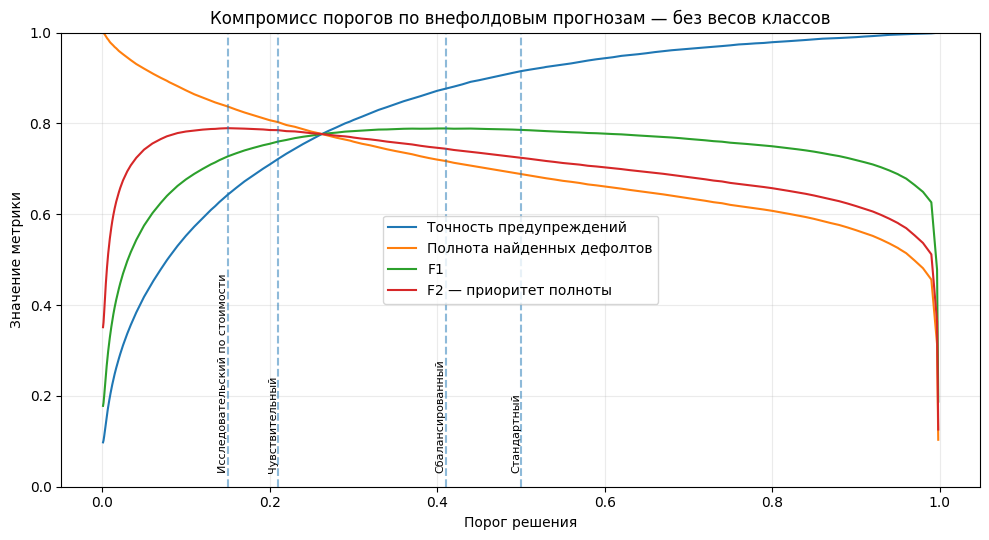

,Сценарий,Порог,Точность предупреждений,Полнота найденных дефолтов,F1,F2,Ложные предупреждения,Пропущенные дефолты,Пояснение
0,Стандартный,0.500,0.9151,0.6884,0.7857,0.7243,1790.000000,8730.000000,"Порог 0,5: высокая точность предупреждений, но больше пропущенных дефолтов"
1,Сбалансированный,0.410,0.8764,0.7172,0.7889,0.7443,2834.000000,7922.000000,Максимум F1: равновесный компромисс точности и полноты
2,Чувствительный,0.210,0.7216,0.8028,0.7601,0.7851,8675.000000,5525.000000,"Полнота не ниже 0,80 при максимально возможной точности предупреждений"
3,Исследовательский по стоимости,0.150,0.6430,0.8372,0.7274,0.7895,13020.000000,4562.000000,Минимум условной функции 5×FN + 1×FP; правило бизнесом не утверждено


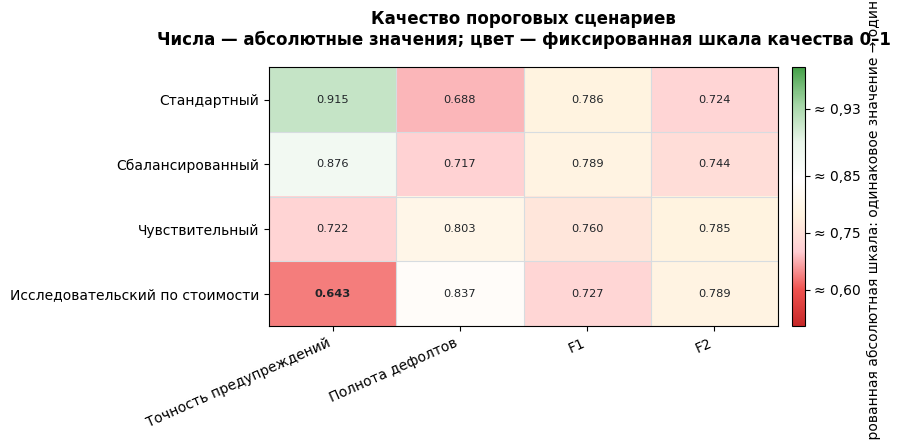

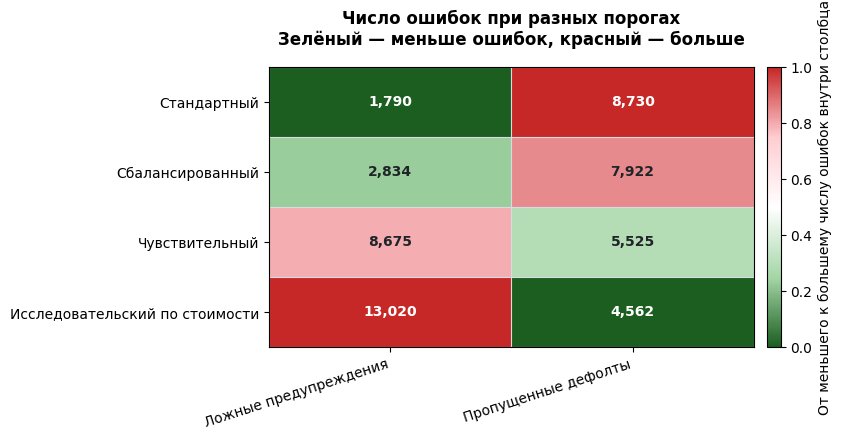

In [22]:
# @title Интуитивное сравнение пороговых сценариев
СЦЕНАРИИ_ПРЕДВАРИТЕЛЬНЫЕ = ВЫБРАННЫЙ_ВАРИАНТ_ВЕСОВ["сценарии"].copy()
ПОДРОБНЫЕ_ПОРОГИ = ТАБЛИЦЫ_ПОРОГОВ_ВЕСОВ[НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ].copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(ПОДРОБНЫЕ_ПОРОГИ["Порог"], ПОДРОБНЫЕ_ПОРОГИ["Precision"], label="Точность предупреждений")
ax.plot(ПОДРОБНЫЕ_ПОРОГИ["Порог"], ПОДРОБНЫЕ_ПОРОГИ["Recall"], label="Полнота найденных дефолтов")
ax.plot(ПОДРОБНЫЕ_ПОРОГИ["Порог"], ПОДРОБНЫЕ_ПОРОГИ["F1"], label="F1")
ax.plot(ПОДРОБНЫЕ_ПОРОГИ["Порог"], ПОДРОБНЫЕ_ПОРОГИ["F2"], label="F2 — приоритет полноты")
for _, строка in СЦЕНАРИИ_ПРЕДВАРИТЕЛЬНЫЕ.iterrows():
    ax.axvline(строка["Порог"], linestyle="--", alpha=0.5)
    ax.text(
        строка["Порог"], 0.03, строка["Сценарий"], rotation=90,
        va="bottom", ha="right", fontsize=8,
    )
ax.set_xlabel("Порог решения")
ax.set_ylabel("Значение метрики")
ax.set_title(f"Компромисс порогов по внефолдовым прогнозам — {НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ.lower()}")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ПАПКИ["графики"] / "компромисс_порогов_рабочая_выборка.png", dpi=170, bbox_inches="tight")
plt.show()

таблица_сценариев_показа = СЦЕНАРИИ_ПРЕДВАРИТЕЛЬНЫЕ[[
    "Сценарий", "Порог", "Precision", "Recall", "F1", "F2", "FP", "FN", "Пояснение"
]].rename(columns={
    "Precision": "Точность предупреждений",
    "Recall": "Полнота найденных дефолтов",
    "FP": "Ложные предупреждения",
    "FN": "Пропущенные дефолты",
})
display(таблица_сценариев_показа.style.format({
    "Порог": "{:.3f}",
    "Точность предупреждений": "{:.4f}",
    "Полнота найденных дефолтов": "{:.4f}",
    "F1": "{:.4f}",
    "F2": "{:.4f}",
}))

# Светлая матрица метрик: абсолютные числа и сравнение внутри столбца.
матрица_сценариев = СЦЕНАРИИ_ПРЕДВАРИТЕЛЬНЫЕ.set_index("Сценарий")[[
    "Precision", "Recall", "F1", "F2"
]].copy()
матрица_сценариев.columns = [
    "Точность предупреждений", "Полнота дефолтов", "F1", "F2"
]
построить_матрицу_абсолютных_метрик(
    матрица_сценариев,
    "Качество пороговых сценариев",
    путь=ПАПКИ["графики"] / "цветовая_матрица_пороговых_метрик.png",
    размер=(9, 4.5),
)

матрица_ошибок = СЦЕНАРИИ_ПРЕДВАРИТЕЛЬНЫЕ.set_index("Сценарий")[["FP", "FN"]].copy()
матрица_ошибок.columns = ["Ложные предупреждения", "Пропущенные дефолты"]
построить_матрицу_ошибок_по_сценариям(
    матрица_ошибок,
    "Число ошибок при разных порогах",
    путь=ПАПКИ["графики"] / "цветовая_матрица_ошибок_порогов.png",
    размер=(8.5, 4.5),
)


In [23]:
# @title Анализ весов классов и порогов
без_весов = СРАВНЕНИЕ_ВЕСОВ.iloc[0]
с_весами = СРАВНЕНИЕ_ВЕСОВ.iloc[1]

display(Markdown(f"""
### Анализ полученного результата

После полного цикла «OOF → калибровка → новый порог»:

- без весов: Gini **{без_весов['Gini']:.4f}**, Brier **{без_весов['Brier']:.4f}**, полнота дефолтов чувствительного сценария **{без_весов['Чувствительный Recall']:.4f}**;
- с весами: Gini **{с_весами['Gini']:.4f}**, Brier **{с_весами['Brier']:.4f}**, полнота дефолтов чувствительного сценария **{с_весами['Чувствительный Recall']:.4f}**.

Для дальнейшего исследования автоматически выбран вариант **{НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ}** по заранее зафиксированному правилу.

Порог не объявляется «промышленным». Ноутбук сохраняет четыре сценария, а бизнес сможет выбрать рабочую точку после оценки стоимости пропущенного дефолта и ложного предупреждения.

**Следующий вопрос:** насколько качество зависит от `Q_B1_norm`, неизвестного `Q_B2_norm` и групп признаков?
"""))


показать_панель(
    "Веса классов проверены",
    f"Для дальнейшего исследования выбран вариант: {НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ}. "
    "Решение принято после полного цикла калибровки и настройки порогов.",
    "информация",
)



### Анализ полученного результата

После полного цикла «OOF → калибровка → новый порог»:

- без весов: Gini **0.9244**, Brier **0.0289**, полнота дефолтов чувствительного сценария **0.8028**;
- с весами: Gini **0.9191**, Brier **0.0295**, полнота дефолтов чувствительного сценария **0.8048**.

Для дальнейшего исследования автоматически выбран вариант **Без весов классов** по заранее зафиксированному правилу.

Порог не объявляется «промышленным». Ноутбук сохраняет четыре сценария, а бизнес сможет выбрать рабочую точку после оценки стоимости пропущенного дефолта и ложного предупреждения.

**Следующий вопрос:** насколько качество зависит от `Q_B1_norm`, неизвестного `Q_B2_norm` и групп признаков?


# 13. Абляция признаков

**Исследовательский вопрос:** насколько основной кандидат зависит от внешнего индекса СПАРК и нерасшифрованного признака?

Обязательные сценарии:

- все признаки;
- без `Q_B1_norm`;
- без `Q_B2_norm`;
- без обоих.

В рекомендуемом и полном профиле дополнительно проверяются финансовые, качественные и объединённые расшифрованные признаки.

`Q_B2_norm` не удаляется автоматически: сценарии без него носят диагностический характер до получения бизнес-расшифровки.

In [24]:
# @title Формирование наборов признаков
ФИНАНСОВЫЕ_ПРИЗНАКИ = [
    "A1_norm", "A4_norm", "B1_norm", "B2_norm", "D1_norm",
    "D5_norm", "E1_norm", "G1_norm", "G2_norm",
]
КАЧЕСТВЕННЫЕ_ПРИЗНАКИ = [
    "Q_A1_norm", "Q_A4_norm", "Q_A5_norm", "Q_A6_norm", "Q_B1_norm",
    "Q_B3_norm", "Q_C1_norm", "Q_D4_norm", "Q_D6_norm",
]


def существующие(список: list[str]) -> list[str]:
    return [столбец for столбец in список if столбец in ПРИЗНАКИ]


РАСШИФРОВАННЫЕ_ПРИЗНАКИ = существующие(
    ФИНАНСОВЫЕ_ПРИЗНАКИ + КАЧЕСТВЕННЫЕ_ПРИЗНАКИ
)

НАБОРЫ_ПРИЗНАКОВ = {
    "Все признаки": ПРИЗНАКИ.copy(),
    "Без Q_B1_norm": [c for c in ПРИЗНАКИ if c != "Q_B1_norm"],
    "Без Q_B2_norm": [c for c in ПРИЗНАКИ if c != "Q_B2_norm"],
    "Без Q_B1_norm и Q_B2_norm": [
        c for c in ПРИЗНАКИ if c not in {"Q_B1_norm", "Q_B2_norm"}
    ],
    "Все расшифрованные признаки": РАСШИФРОВАННЫЕ_ПРИЗНАКИ,
}

if НАСТРОЙКИ_ПРОФИЛЯ["полные_наборы_признаков"]:
    НАБОРЫ_ПРИЗНАКОВ.update({
        "Только расшифрованные финансовые": существующие(ФИНАНСОВЫЕ_ПРИЗНАКИ),
        "Только расшифрованные качественные": существующие(КАЧЕСТВЕННЫЕ_ПРИЗНАКИ),
    })

display(pd.DataFrame([
    {"Набор": название, "Число признаков": len(признаки)}
    for название, признаки in НАБОРЫ_ПРИЗНАКОВ.items()
]))


,Набор,Число признаков
0,Все признаки,49
1,Без Q_B1_norm,48
2,Без Q_B2_norm,48
3,Без Q_B1_norm и Q_B2_norm,47
4,Все расшифрованные признаки,18
5,Только расшифрованные финансовые,9
6,Только расшифрованные качественные,9



Набор: Все признаки (49 признаков)
  ✓ XGBoost: Gini=0.9245, PR-AUC=0.8675

Набор: Без Q_B1_norm (48 признаков)
  ✓ XGBoost: Gini=0.9184, PR-AUC=0.8575

Набор: Без Q_B2_norm (48 признаков)
  ✓ XGBoost: Gini=0.9174, PR-AUC=0.8611

Набор: Без Q_B1_norm и Q_B2_norm (47 признаков)
  ✓ XGBoost: Gini=0.8072, PR-AUC=0.6051

Набор: Все расшифрованные признаки (18 признаков)
  ✓ XGBoost: Gini=0.9134, PR-AUC=0.8574

Набор: Только расшифрованные финансовые (9 признаков)
  ✓ XGBoost: Gini=0.6153, PR-AUC=0.3612

Набор: Только расшифрованные качественные (9 признаков)
  ✓ XGBoost: Gini=0.8951, PR-AUC=0.8391


,Набор признаков,Число признаков,Gini,Площадь под ROC-кривой,Площадь под кривой точность–полнота,Ошибка вероятностей Brier,Чувствительный порог,Точность предупреждений чувствительного сценария,Полнота дефолтов чувствительного сценария,F1 чувствительного сценария,F2 чувствительного сценария
0,Все признаки,49,0.9244,0.9622,0.8675,0.0289,0.210,0.7216,0.8028,0.7601,0.7851
1,Без Q_B1_norm,48,0.9183,0.9591,0.8575,0.0303,0.195,0.6923,0.8021,0.7432,0.7775
2,Без Q_B2_norm,48,0.9172,0.9586,0.8610,0.0294,0.190,0.7028,0.8004,0.7484,0.7787
3,Все расшифрованные признаки,18,0.9133,0.9567,0.8574,0.0298,0.184,0.6909,0.8006,0.7417,0.7759
4,Только расшифрованные качественные,9,0.8949,0.9475,0.8391,0.0316,0.150,0.6251,0.8014,0.7023,0.7586
5,Без Q_B1_norm и Q_B2_norm,47,0.8070,0.9035,0.6049,0.0565,0.111,0.3615,0.8004,0.4981,0.6440
6,Только расшифрованные финансовые,9,0.6153,0.8076,0.3611,0.0737,0.070,0.1998,0.8011,0.3198,0.5001


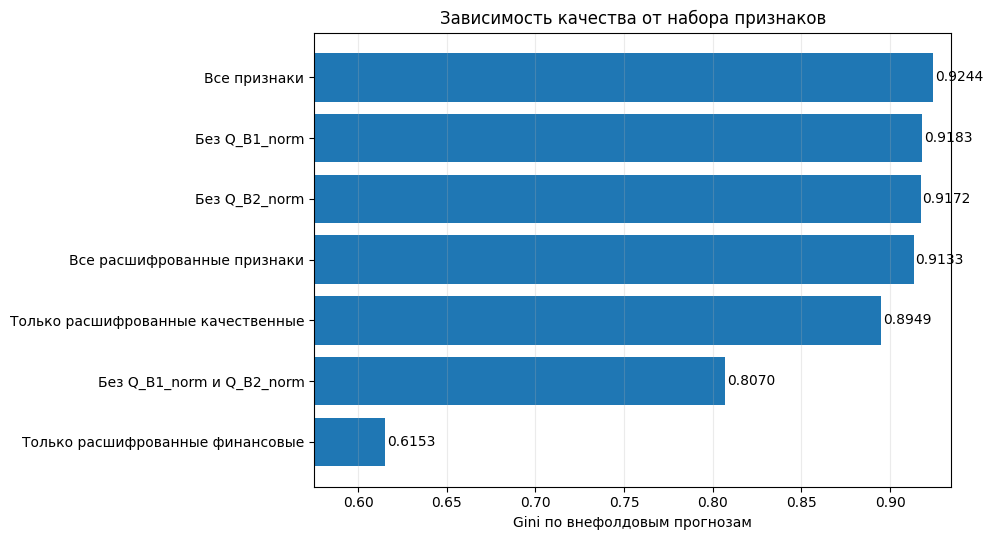

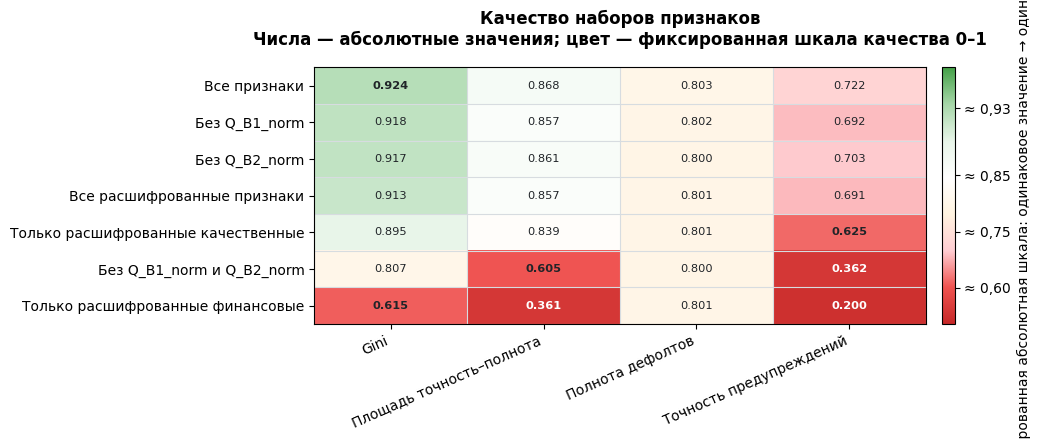

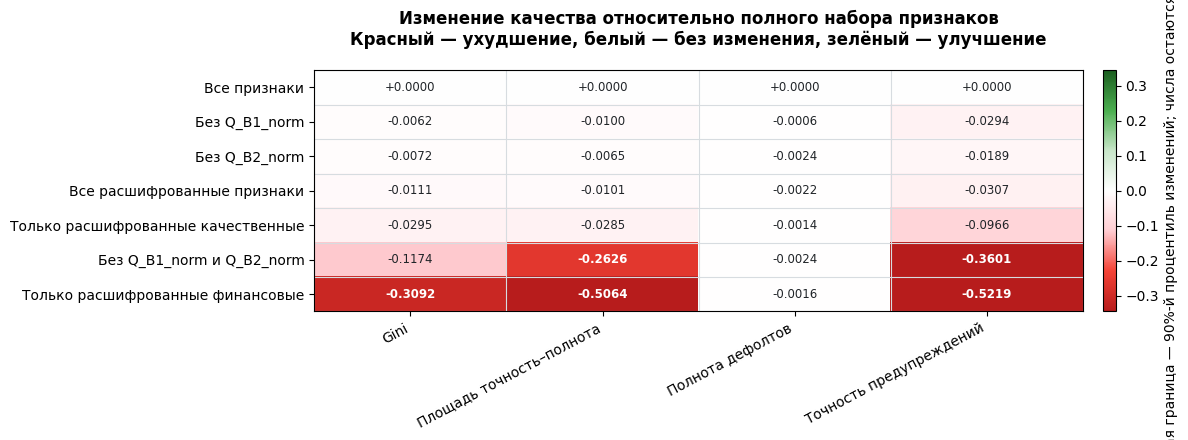

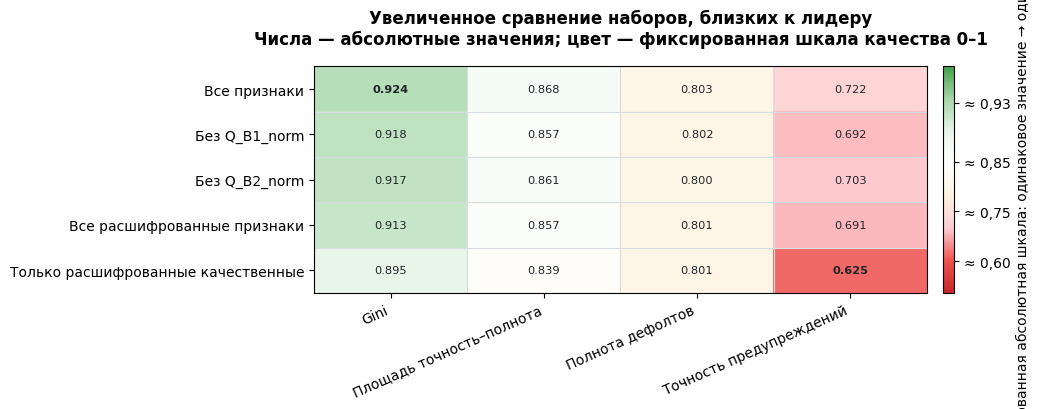

In [25]:
# @title Запуск абляционных экспериментов
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Абляция наборов признаков',
    {
        "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "параметры": ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
        "веса": ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ,
        "наборы": {имя: признаки for имя, признаки in НАБОРЫ_ПРИЗНАКОВ.items()},
        "полный_режим": НАСТРОЙКИ_ПРОФИЛЯ["полные_наборы_признаков"],
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Абляция наборов признаков',
    _ПОДПИСЬ_ЭТАПА,
    ['РЕЗУЛЬТАТЫ_АБЛЯЦИИ', 'ТАБЛИЦА_АБЛЯЦИИ'],
)

if _ВОССТАНОВЛЕНО:
    print("✓ Таблица абляций восстановлена; графики пересобираются без повторного обучения.")
    display(русские_названия_метрик(ТАБЛИЦА_АБЛЯЦИИ).style.format({
        "Gini": "{:.4f}",
        "Площадь под ROC-кривой": "{:.4f}",
        "Площадь под кривой точность–полнота": "{:.4f}",
        "Ошибка вероятностей Brier": "{:.4f}",
        "Чувствительный порог": "{:.3f}",
        "Точность предупреждений чувствительного сценария": "{:.4f}",
        "Полнота дефолтов чувствительного сценария": "{:.4f}",
        "F1 чувствительного сценария": "{:.4f}",
        "F2 чувствительного сценария": "{:.4f}",
    }).background_gradient(subset=["Gini", "Площадь под кривой точность–полнота"], cmap=СВЕТЛАЯ_ЗЕЛЕНАЯ_ПАЛИТРА))

    ТАБЛИЦА_АБЛЯЦИИ.to_csv(
        ПАПКИ["метрики"] / "абляция_признаков.csv",
        index=False,
        encoding="utf-8-sig",
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    таблица_графика = ТАБЛИЦА_АБЛЯЦИИ.sort_values("Gini", ascending=True)
    ax.barh(таблица_графика["Набор признаков"], таблица_графика["Gini"])
    минимум = max(0.0, float(таблица_графика["Gini"].min()) - 0.04)
    максимум = min(1.0, float(таблица_графика["Gini"].max()) + 0.01)
    ax.set_xlim(минимум, максимум)
    ax.set_xlabel("Gini по внефолдовым прогнозам")
    ax.set_title("Зависимость качества от набора признаков")
    ax.grid(axis="x", alpha=0.25)
    for i, значение in enumerate(таблица_графика["Gini"]):
        ax.text(значение + 0.001, i, f"{значение:.4f}", va="center")
    plt.tight_layout()
    plt.savefig(ПАПКИ["графики"] / "абляция_gini.png", dpi=160, bbox_inches="tight")
    plt.show()

    # Светлая матрица абсолютного качества наборов признаков.
    матрица_абляций = ТАБЛИЦА_АБЛЯЦИИ.set_index("Набор признаков")[[
        "Gini", "PR-AUC", "Чувствительный Recall", "Чувствительный Precision"
    ]].copy()
    матрица_абляций.columns = [
        "Gini", "Площадь точность–полнота",
        "Полнота дефолтов", "Точность предупреждений",
    ]
    построить_матрицу_абсолютных_метрик(
        матрица_абляций,
        "Качество наборов признаков",
        путь=ПАПКИ["графики"] / "цветовая_матрица_абляций.png",
        размер=(12, max(4.5, len(матрица_абляций) * 0.58)),
    )

    контрольная_строка = матрица_абляций.loc["Все признаки"]
    матрица_изменений_абляции = матрица_абляций.subtract(контрольная_строка, axis="columns")
    построить_матрицу_изменений(
        матрица_изменений_абляции,
        "Изменение качества относительно полного набора признаков",
        путь=ПАПКИ["графики"] / "изменения_абляций_относительно_всех_признаков.png",
        размер=(12, max(4.5, len(матрица_изменений_абляции) * 0.58)),
    )

else:
    РЕЗУЛЬТАТЫ_АБЛЯЦИИ = {}
    строки_абляции = []

    for название_набора, признаки_набора in НАБОРЫ_ПРИЗНАКОВ.items():
        if not признаки_набора:
            continue
        print(f"\nНабор: {название_набора} ({len(признаки_набора)} признаков)")
        результат_cv = выполнить_cv(
            код_модели=КОД_ОСНОВНОЙ_МОДЕЛИ,
            признаки=признаки_набора,
            использовать_веса=ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ,
            параметры=ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
        )
        oof_сырые = результат_cv["oof_вероятности"]
        oof_калиброванные, калибратор = кросс_калибровать_oof(
            oof_сырые, y_работа, ФОЛДЫ
        )
        сценарии, подробные_пороги = выбрать_сценарии_порогов(
            y_работа, oof_калиброванные
        )
        метрики = рассчитать_метрики(y_работа, oof_калиброванные, порог=0.5)
        чувствительный = сценарии[
            сценарии["Сценарий"] == "Чувствительный"
        ].iloc[0]

        строка = {
            "Набор признаков": название_набора,
            "Число признаков": len(признаки_набора),
            "Gini": метрики["Gini"],
            "ROC-AUC": метрики["ROC-AUC"],
            "PR-AUC": метрики["PR-AUC"],
            "Brier": метрики["Brier"],
            "Чувствительный порог": чувствительный["Порог"],
            "Чувствительный Precision": чувствительный["Precision"],
            "Чувствительный Recall": чувствительный["Recall"],
            "Чувствительный F1": чувствительный["F1"],
            "Чувствительный F2": чувствительный["F2"],
        }
        строки_абляции.append(строка)
        РЕЗУЛЬТАТЫ_АБЛЯЦИИ[название_набора] = {
            "cv": результат_cv,
            "калибратор": калибратор,
            "oof_сырые": oof_сырые,
            "oof_калиброванные": oof_калиброванные,
            "сценарии": сценарии,
            "подробные_пороги": подробные_пороги,
            "признаки": признаки_набора,
        }

    ТАБЛИЦА_АБЛЯЦИИ = pd.DataFrame(строки_абляции).sort_values(
        ["Gini", "PR-AUC"], ascending=False
    ).reset_index(drop=True)

    display(русские_названия_метрик(ТАБЛИЦА_АБЛЯЦИИ).style.format({
        "Gini": "{:.4f}",
        "Площадь под ROC-кривой": "{:.4f}",
        "Площадь под кривой точность–полнота": "{:.4f}",
        "Ошибка вероятностей Brier": "{:.4f}",
        "Чувствительный порог": "{:.3f}",
        "Точность предупреждений чувствительного сценария": "{:.4f}",
        "Полнота дефолтов чувствительного сценария": "{:.4f}",
        "F1 чувствительного сценария": "{:.4f}",
        "F2 чувствительного сценария": "{:.4f}",
    }).background_gradient(subset=["Gini", "Площадь под кривой точность–полнота"], cmap=СВЕТЛАЯ_ЗЕЛЕНАЯ_ПАЛИТРА))

    ТАБЛИЦА_АБЛЯЦИИ.to_csv(
        ПАПКИ["метрики"] / "абляция_признаков.csv",
        index=False,
        encoding="utf-8-sig",
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    таблица_графика = ТАБЛИЦА_АБЛЯЦИИ.sort_values("Gini", ascending=True)
    ax.barh(таблица_графика["Набор признаков"], таблица_графика["Gini"])
    минимум = max(0.0, float(таблица_графика["Gini"].min()) - 0.04)
    максимум = min(1.0, float(таблица_графика["Gini"].max()) + 0.01)
    ax.set_xlim(минимум, максимум)
    ax.set_xlabel("Gini по внефолдовым прогнозам")
    ax.set_title("Зависимость качества от набора признаков")
    ax.grid(axis="x", alpha=0.25)
    for i, значение in enumerate(таблица_графика["Gini"]):
        ax.text(значение + 0.001, i, f"{значение:.4f}", va="center")
    plt.tight_layout()
    plt.savefig(ПАПКИ["графики"] / "абляция_gini.png", dpi=160, bbox_inches="tight")
    plt.show()

    # Светлая матрица абсолютного качества наборов признаков.
    матрица_абляций = ТАБЛИЦА_АБЛЯЦИИ.set_index("Набор признаков")[[
        "Gini", "PR-AUC", "Чувствительный Recall", "Чувствительный Precision"
    ]].copy()
    матрица_абляций.columns = [
        "Gini", "Площадь точность–полнота",
        "Полнота дефолтов", "Точность предупреждений",
    ]
    построить_матрицу_абсолютных_метрик(
        матрица_абляций,
        "Качество наборов признаков",
        путь=ПАПКИ["графики"] / "цветовая_матрица_абляций.png",
        размер=(12, max(4.5, len(матрица_абляций) * 0.58)),
    )

    контрольная_строка = матрица_абляций.loc["Все признаки"]
    матрица_изменений_абляции = матрица_абляций.subtract(контрольная_строка, axis="columns")
    построить_матрицу_изменений(
        матрица_изменений_абляции,
        "Изменение качества относительно полного набора признаков",
        путь=ПАПКИ["графики"] / "изменения_абляций_относительно_всех_признаков.png",
        размер=(12, max(4.5, len(матрица_изменений_абляции) * 0.58)),
    )
    сохранить_контрольную_точку(
        'Абляция наборов признаков',
        _ПОДПИСЬ_ЭТАПА,
        ['РЕЗУЛЬТАТЫ_АБЛЯЦИИ', 'ТАБЛИЦА_АБЛЯЦИИ'],
    )


# Увеличенная матрица близких к лидеру вариантов:
# слабые сценарии не растягивают цветовую шкалу.
_порог_близости = float(ТАБЛИЦА_АБЛЯЦИИ["Gini"].max()) - 0.04
_близкие_абляции = ТАБЛИЦА_АБЛЯЦИИ[
    ТАБЛИЦА_АБЛЯЦИИ["Gini"] >= _порог_близости
].copy()
if len(_близкие_абляции) >= 2:
    _матрица_близких = _близкие_абляции.set_index("Набор признаков")[[
        "Gini", "PR-AUC", "Чувствительный Recall", "Чувствительный Precision"
    ]]
    _матрица_близких.columns = [
        "Gini", "Площадь точность–полнота",
        "Полнота дефолтов", "Точность предупреждений",
    ]
    построить_матрицу_абсолютных_метрик(
        _матрица_близких,
        "Увеличенное сравнение наборов, близких к лидеру",
        путь=ПАПКИ["графики"] / "абляции_близкие_к_лидеру.png",
        размер=(12, max(4.2, len(_матрица_близких) * 0.72)),
    )


In [26]:
# @title Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке
все = ТАБЛИЦА_АБЛЯЦИИ[
    ТАБЛИЦА_АБЛЯЦИИ["Набор признаков"] == "Все признаки"
].iloc[0]

РОЛИ_КАНДИДАТОВ = {
    "Технический максимум": {
        "набор": "Все признаки",
        "назначение": "Максимально возможное качество на предоставленном датасете",
    },
    "Производственный кандидат без Q_B2_norm": {
        "набор": "Без Q_B2_norm",
        "назначение": "Проверка решения без самого сильного нерасшифрованного признака",
    },
    "Интерпретируемый кандидат": {
        "набор": "Все расшифрованные признаки",
        "назначение": "Модель только на признаках, бизнес-смысл которых подтверждён источниками",
    },
}

КАНДИДАТЫ_ДО_ТЕСТА = {}
строки_кандидатов = []
for роль, описание in РОЛИ_КАНДИДАТОВ.items():
    название_набора = описание["набор"]
    if название_набора not in РЕЗУЛЬТАТЫ_АБЛЯЦИИ:
        continue
    результат = РЕЗУЛЬТАТЫ_АБЛЯЦИИ[название_набора]
    строка_абляции = ТАБЛИЦА_АБЛЯЦИИ[
        ТАБЛИЦА_АБЛЯЦИИ["Набор признаков"] == название_набора
    ].iloc[0]
    признаки = результат["признаки"]
    КАНДИДАТЫ_ДО_ТЕСТА[роль] = {
        **результат,
        "роль": роль,
        "набор": название_набора,
        "назначение": описание["назначение"],
    }
    строки_кандидатов.append({
        "Роль": роль,
        "Набор признаков": название_набора,
        "Назначение": описание["назначение"],
        "Число признаков": len(признаки),
        "Содержит Q_B1_norm": "Да" if "Q_B1_norm" in признаки else "Нет",
        "Содержит Q_B2_norm": "Да" if "Q_B2_norm" in признаки else "Нет",
        "Gini по рабочей выборке": float(строка_абляции["Gini"]),
        "PR-AUC по рабочей выборке": float(строка_абляции["PR-AUC"]),
    })

ТАБЛИЦА_ЗАФИКСИРОВАННЫХ_КАНДИДАТОВ = pd.DataFrame(строки_кандидатов)
ОСНОВНАЯ_РОЛЬ = "Технический максимум"
if ОСНОВНАЯ_РОЛЬ not in КАНДИДАТЫ_ДО_ТЕСТА:
    raise RuntimeError("Не удалось сформировать технического кандидата.")

# Совместимые переменные для последующих глав относятся к техническому кандидату.
ВЫБРАННЫЙ_НАБОР_ПРИЗНАКОВ = КАНДИДАТЫ_ДО_ТЕСТА[ОСНОВНАЯ_РОЛЬ]["набор"]
ФИНАЛЬНЫЕ_ПРИЗНАКИ = КАНДИДАТЫ_ДО_ТЕСТА[ОСНОВНАЯ_РОЛЬ]["признаки"]
ФИНАЛЬНЫЙ_OOF = КАНДИДАТЫ_ДО_ТЕСТА[ОСНОВНАЯ_РОЛЬ]
ФИНАЛЬНЫЙ_КАЛИБРАТОР = ФИНАЛЬНЫЙ_OOF["калибратор"]
ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ = ФИНАЛЬНЫЙ_OOF["сценарии"].copy()

display(ТАБЛИЦА_ЗАФИКСИРОВАННЫХ_КАНДИДАТОВ.style.format({
    "Gini по рабочей выборке": "{:.4f}",
    "PR-AUC по рабочей выборке": "{:.4f}",
}))
ТАБЛИЦА_ЗАФИКСИРОВАННЫХ_КАНДИДАТОВ.to_csv(
    ПАПКИ["метрики"] / "кандидаты_до_тестовой_выборки.csv",
    index=False,
    encoding="utf-8-sig",
)

display(Markdown(f"""
### Анализ полученного результата

Автоматическое пограничное правило больше не выбирает один набор признаков. До обращения к тестовой выборке зафиксированы **{len(КАНДИДАТЫ_ДО_ТЕСТА)} содержательно разные модели**:

1. технический максимум;
2. производственный кандидат без неизвестного `Q_B2_norm`;
3. интерпретируемый кандидат только на расшифрованных признаках.

Тестовая выборка будет использована один раз для каждого заранее объявленного кандидата. Результаты теста не будут использоваться для возврата к подбору параметров или признаков.

**Следующий шаг:** записать неизменяемый паспорт всех кандидатов и их пороговых сценариев.
"""))


показать_панель(
    "Зафиксированы три роли модели",
    "Технический максимум показывает достижимое качество; кандидат без Q_B2_norm снижает риск неизвестного признака; "
    "интерпретируемый кандидат использует только признаки с подтверждённой расшифровкой.",
    "информация",
)


,Роль,Набор признаков,Назначение,Число признаков,Содержит Q_B1_norm,Содержит Q_B2_norm,Gini по рабочей выборке,PR-AUC по рабочей выборке
0,Технический максимум,Все признаки,Максимально возможное качество на предоставленном датасете,49,Да,Да,0.9244,0.8675
1,Производственный кандидат без Q_B2_norm,Без Q_B2_norm,Проверка решения без самого сильного нерасшифрованного признака,48,Да,Нет,0.9172,0.8610
2,Интерпретируемый кандидат,Все расшифрованные признаки,"Модель только на признаках, бизнес-смысл которых подтверждён источниками",18,Да,Нет,0.9133,0.8574



### Анализ полученного результата

Автоматическое пограничное правило больше не выбирает один набор признаков. До обращения к тестовой выборке зафиксированы **3 содержательно разные модели**:

1. технический максимум;
2. производственный кандидат без неизвестного `Q_B2_norm`;
3. интерпретируемый кандидат только на расшифрованных признаках.

Тестовая выборка будет использована один раз для каждого заранее объявленного кандидата. Результаты теста не будут использоваться для возврата к подбору параметров или признаков.

**Следующий шаг:** записать неизменяемый паспорт всех кандидатов и их пороговых сценариев.


# 14. Фиксация решений до открытия финальной тестовой выборки

Эта глава создаёт неизменяемый паспорт алгоритма, параметров, весов, трёх наборов признаков, калибраторов и пороговых сценариев. После фиксации запрещено возвращаться к подбору на основании тестовых результатов.


In [27]:
# @title Сохранение всех решений до финальной проверки
кандидаты_для_json = []
for роль, кандидат in КАНДИДАТЫ_ДО_ТЕСТА.items():
    кандидаты_для_json.append({
        "роль": роль,
        "назначение": кандидат["назначение"],
        "набор_признаков": кандидат["набор"],
        "признаки": кандидат["признаки"],
        "пороги": {
            строка["Сценарий"]: float(строка["Порог"])
            for _, строка in кандидат["сценарии"].iterrows()
        },
        "gini_рабочая_выборка": float(
            рассчитать_метрики(y_работа, кандидат["oof_калиброванные"], 0.5)["Gini"]
        ),
        "pr_auc_рабочая_выборка": float(
            рассчитать_метрики(y_работа, кандидат["oof_калиброванные"], 0.5)["PR-AUC"]
        ),
    })

РЕШЕНИЕ_ДО_ТЕСТОВОЙ_ВЫБОРКИ = {
    "дата_фиксации_utc": datetime.now(timezone.utc).isoformat(),
    "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
    "профиль": ПРОФИЛЬ_ЗАПУСКА,
    "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
    "случайное_зерно": СЛУЧАЙНОЕ_ЗЕРНО,
    "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
    "название_модели": РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ],
    "вариант_модели": ОСНОВНОЙ_ВАРИАНТ,
    "параметры": ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
    "использовать_веса_классов": ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ,
    "вариант_весов": НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ,
    "основная_роль": ОСНОВНАЯ_РОЛЬ,
    "кандидаты": кандидаты_для_json,
    "ограничения": [
        "В датасете отсутствует дата наблюдения; проверка на будущем периоде невозможна.",
        "Расшифровка Q_B2_norm отсутствует в предоставленных источниках.",
        "Функция стоимости 5×FN + 1×FP является исследовательской и не согласована бизнесом.",
    ],
}
ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ = ПАПКИ["метаданные"] / "решение_до_тестовой_выборки.json"
сохранить_json(РЕШЕНИЕ_ДО_ТЕСТОВОЙ_ВЫБОРКИ, ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ)

ПОДПИСЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ = вычислить_sha256(ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ)
print("✓ Все кандидаты зафиксированы до открытия тестовой выборки.")
print(f"Файл: {ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ}")
print(f"SHA-256 решения: {ПОДПИСЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ}")
display(ТАБЛИЦА_ЗАФИКСИРОВАННЫХ_КАНДИДАТОВ)


✓ Все кандидаты зафиксированы до открытия тестовой выборки.
Файл: /content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/метаданные/решение_до_тестовой_выборки.json
SHA-256 решения: 2703517b2abc8cee3baf14179bc6d2a46b2ff75b0931fa2cbdb4eb7e141400b4


,Роль,Набор признаков,Назначение,Число признаков,Содержит Q_B1_norm,Содержит Q_B2_norm,Gini по рабочей выборке,PR-AUC по рабочей выборке
0,Технический максимум,Все признаки,Максимально возможное качество на предоставлен...,49,Да,Да,0.924446,0.867519
1,Производственный кандидат без Q_B2_norm,Без Q_B2_norm,Проверка решения без самого сильного нерасшифр...,48,Да,Нет,0.917207,0.861039
2,Интерпретируемый кандидат,Все расшифрованные признаки,"Модель только на признаках, бизнес-смысл котор...",18,Да,Нет,0.913304,0.857394


# 15. Единственная итоговая оценка зафиксированных кандидатов

**Исследовательский вопрос:** подтверждаются ли заранее выбранные решения на полностью отложенной тестовой выборке?

Каждый кандидат оценивается ровно один раз. Сравнение на тесте служит прозрачным отчётом, но не используется для нового подбора.


In [28]:
# @title Обучение и единственная оценка зафиксированных кандидатов

print("⏳ Подготовка финальной оценки зафиксированных кандидатов...")


# ---------------------------------------------------------------------
# Подготовка воспроизводимого описания кандидатов
# ---------------------------------------------------------------------
#
# В КАНДИДАТЫ_ДО_ТЕСТА нет отдельных полей:
#   «код_модели»,
#   «параметры»,
#   «использовать_веса».
#
# Эти настройки являются общими для всех кандидатов и хранятся
# в переменных КОД_ОСНОВНОЙ_МОДЕЛИ,
# ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ и
# ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ.


def подготовить_параметры_кандидата(
    кандидат: dict,
) -> dict:
    """
    Возвращает фактические параметры обучения кандидата.

    Учитывает рекомендованное число итераций,
    полученное на кросс-валидации конкретного набора признаков.
    """
    параметры = dict(ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ)

    рекомендуемое_число_итераций = (
        кандидат
        .get("cv", {})
        .get("рекомендуемое_число_итераций")
    )

    if рекомендуемое_число_итераций:
        ключ_итераций = {
            "xgboost": "n_estimators",
            "lightgbm": "n_estimators",
            "catboost": "iterations",
            "hist_gradient_boosting": "max_iter",
        }.get(КОД_ОСНОВНОЙ_МОДЕЛИ)

        if ключ_итераций:
            параметры[ключ_итераций] = int(
                рекомендуемое_число_итераций
            )

    return параметры


def подготовить_паспорт_кандидата(
    роль: str,
    кандидат: dict,
) -> dict:
    """
    Формирует компактный JSON-совместимый паспорт кандидата
    для SHA-256-подписи контрольной точки.
    """
    сценарии = кандидат.get("сценарии")

    if isinstance(сценарии, pd.DataFrame):
        пороги = [
            {
                "сценарий": str(строка["Сценарий"]),
                "порог": float(строка["Порог"]),
            }
            for _, строка in сценарии.iterrows()
        ]
    else:
        пороги = []

    return {
        "роль": роль,
        "набор": str(кандидат["набор"]),
        "код_модели": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "признаки": list(кандидат["признаки"]),
        "параметры": подготовить_параметры_кандидата(
            кандидат
        ),
        "использовать_веса": bool(
            ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ
        ),
        "пороги": пороги,
    }


паспорта_кандидатов = {
    роль: подготовить_паспорт_кандидата(
        роль,
        кандидат,
    )
    for роль, кандидат in КАНДИДАТЫ_ДО_ТЕСТА.items()
}


_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    "Финальная оценка кандидатов",
    {
        "подпись_решений":
            ПОДПИСЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ,
        "кандидаты": паспорта_кандидатов,
    },
)


_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    "Финальная оценка кандидатов",
    _ПОДПИСЬ_ЭТАПА,
    [
        "ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ",
        "ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ",
        "ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ",
        "ФИНАЛЬНЫЕ_СЫРЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ",
        "ФИНАЛЬНЫЕ_МЕТРИКИ_КАНДИДАТОВ",
        "ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ",
        "ВРЕМЯ_ОБУЧЕНИЯ_КАНДИДАТОВ",
        "ВРЕМЯ_ПРОГНОЗА_КАНДИДАТОВ",
        "ВСЕ_ИТОГОВЫЕ_МЕТРИКИ_ТЕСТ",
        "СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ",
        "ФИНАЛЬНАЯ_МОДЕЛЬ",
        "ФИНАЛЬНЫЙ_КАЛИБРАТОР",
        "TEST_ВЕРОЯТНОСТИ",
        "TEST_ВЕРОЯТНОСТИ_СЫРЫЕ",
        "ИТОГОВЫЕ_МЕТРИКИ_TEST",
        "ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ",
        "ВРЕМЯ_ФИНАЛЬНОГО_ОБУЧЕНИЯ",
        "ВРЕМЯ_TEST_ИНФЕРЕНСА",
        "ПРОГНОЗЫ_TEST",
        "ПУТЬ_ПРОГНОЗОВ_TEST",
    ],
)


# ---------------------------------------------------------------------
# Восстановление совместимой контрольной точки
# ---------------------------------------------------------------------

if _ВОССТАНОВЛЕНО:
    print(
        "✓ Найдена совместимая контрольная точка. "
        "Повторное обучение не требуется."
    )

    display(
        СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ
    )

    # В новый запуск копируются только производные файлы.
    # Исходная контрольная точка остаётся неизменной.
    if importlib.util.find_spec("pyarrow") is not None:
        ПУТЬ_ПРОГНОЗОВ_TEST = (
            ПАПКИ["прогнозы"]
            / "прогнозы_тестовой_выборки.parquet"
        )

        ПРОГНОЗЫ_TEST.to_parquet(
            ПУТЬ_ПРОГНОЗОВ_TEST,
            index=False,
        )

    else:
        ПУТЬ_ПРОГНОЗОВ_TEST = (
            ПАПКИ["прогнозы"]
            / "прогнозы_тестовой_выборки.csv.gz"
        )

        ПРОГНОЗЫ_TEST.to_csv(
            ПУТЬ_ПРОГНОЗОВ_TEST,
            index=False,
            compression="gzip",
            encoding="utf-8",
        )

    ВСЕ_ИТОГОВЫЕ_МЕТРИКИ_ТЕСТ.to_csv(
        ПАПКИ["метрики"]
        / "итоговые_метрики_тестовой_выборки_"
          "все_кандидаты.csv",
        index=False,
        encoding="utf-8-sig",
    )

    СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ.to_csv(
        ПАПКИ["метрики"]
        / "сравнение_зафиксированных_кандидатов_"
          "на_тесте.csv",
        index=False,
        encoding="utf-8-sig",
    )


# ---------------------------------------------------------------------
# Обучение и единственная финальная оценка
# ---------------------------------------------------------------------

else:
    if not ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ.exists():
        raise RuntimeError(
            "Решения до тестовой выборки "
            "не были зафиксированы."
        )

    текущее_решение = прочитать_json(
        ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ
    )

    if (
        текущее_решение["sha256_датасета"]
        != КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА
    ):
        raise RuntimeError(
            "Датасет изменился после фиксации решений. "
            "Финальная оценка остановлена."
        )


    def безопасное_имя(текст: str) -> str:
        результат = re.sub(
            r"[^0-9A-Za-zА-Яа-я_]+",
            "_",
            текст.strip().lower(),
        )
        return результат.strip("_")


    ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ = {}
    ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ = {}
    ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ = {}
    ФИНАЛЬНЫЕ_СЫРЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ = {}
    ФИНАЛЬНЫЕ_МЕТРИКИ_КАНДИДАТОВ = {}
    ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ = {}
    ВРЕМЯ_ОБУЧЕНИЯ_КАНДИДАТОВ = {}
    ВРЕМЯ_ПРОГНОЗА_КАНДИДАТОВ = {}

    строки_всех_метрик = []
    строки_сравнения_кандидатов = []

    число_кандидатов = len(
        КАНДИДАТЫ_ДО_ТЕСТА
    )

    print(
        f"Будет обучено кандидатов: "
        f"{число_кандидатов}"
    )


    for номер_кандидата, (
        роль,
        кандидат,
    ) in enumerate(
        КАНДИДАТЫ_ДО_ТЕСТА.items(),
        start=1,
    ):
        признаки = list(
            кандидат["признаки"]
        )

        параметры_обучения = (
            подготовить_параметры_кандидата(
                кандидат
            )
        )

        print()
        print("=" * 70)
        print(
            f"⏳ Кандидат "
            f"{номер_кандидата}/{число_кандидатов}"
        )
        print(f"Роль: {роль}")
        print(
            f"Набор: {кандидат['набор']} "
            f"— {len(признаки)} признаков"
        )


        # -------------------------------------------------------------
        # Обучение
        # -------------------------------------------------------------

        начало_обучения = perf_counter()

        модель = создать_модель(
            КОД_ОСНОВНОЙ_МОДЕЛИ,
            y_работа,
            использовать_веса=(
                ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ
            ),
            параметры=параметры_обучения,
            seed=СЛУЧАЙНОЕ_ЗЕРНО,
        )

        if (
            КОД_ОСНОВНОЙ_МОДЕЛИ
            == "hist_gradient_boosting"
            and ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ
        ):
            вес = положительный_вес(
                y_работа
            )

            веса_строк = np.where(
                y_работа.to_numpy() == 1,
                вес,
                1.0,
            )

            модель.fit(
                X_работа[признаки],
                y_работа,
                sample_weight=веса_строк,
            )

        else:
            модель.fit(
                X_работа[признаки],
                y_работа,
            )

        время_обучения = (
            perf_counter()
            - начало_обучения
        )


        # -------------------------------------------------------------
        # Прогноз
        # -------------------------------------------------------------

        начало_прогноза = perf_counter()

        вероятности_сырые = (
            модель
            .predict_proba(
                X_test[признаки]
            )[:, 1]
        )

        время_прогноза = (
            perf_counter()
            - начало_прогноза
        )

        калибратор = кандидат[
            "калибратор"
        ]

        вероятности = применить_калибратор(
            калибратор,
            вероятности_сырые,
        )


        # -------------------------------------------------------------
        # Оценка всех заранее выбранных порогов
        # -------------------------------------------------------------

        строки_кандидата = []

        for _, сценарий in кандидат[
            "сценарии"
        ].iterrows():
            метрики = рассчитать_метрики(
                y_test,
                вероятности,
                float(сценарий["Порог"]),
            )

            запись = {
                "Роль кандидата": роль,
                "Набор признаков":
                    кандидат["набор"],
                "Число признаков":
                    len(признаки),
                "Сценарий":
                    сценарий["Сценарий"],
                **метрики,
                "Пояснение":
                    сценарий["Пояснение"],
            }

            строки_кандидата.append(
                запись
            )

            строки_всех_метрик.append(
                запись
            )


        таблица_метрик = pd.DataFrame(
            строки_кандидата
        )

        стандартная_строка = (
            таблица_метрик[
                таблица_метрик[
                    "Сценарий"
                ] == "Стандартный"
            ]
            .iloc[0]
        )

        чувствительная_строка = (
            таблица_метрик[
                таблица_метрик[
                    "Сценарий"
                ] == "Чувствительный"
            ]
            .iloc[0]
        )


        строки_сравнения_кандидатов.append({
            "Роль кандидата": роль,
            "Набор признаков":
                кандидат["набор"],
            "Число признаков":
                len(признаки),
            "Gini":
                стандартная_строка["Gini"],
            "PR-AUC":
                стандартная_строка["PR-AUC"],
            "Brier":
                стандартная_строка["Brier"],
            "Полнота при пороге 0,5":
                стандартная_строка["Recall"],
            "Точность при пороге 0,5":
                стандартная_строка["Precision"],
            "Полнота чувствительного сценария":
                чувствительная_строка["Recall"],
            "Точность чувствительного сценария":
                чувствительная_строка["Precision"],
            "Время обучения, сек":
                время_обучения,
            "Время прогноза, сек":
                время_прогноза,
        })


        ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ[
            роль
        ] = модель

        ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ[
            роль
        ] = калибратор

        ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ[
            роль
        ] = вероятности

        ФИНАЛЬНЫЕ_СЫРЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ[
            роль
        ] = вероятности_сырые

        ФИНАЛЬНЫЕ_МЕТРИКИ_КАНДИДАТОВ[
            роль
        ] = таблица_метрик

        ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ[
            роль
        ] = кандидат["сценарии"].copy()

        ВРЕМЯ_ОБУЧЕНИЯ_КАНДИДАТОВ[
            роль
        ] = время_обучения

        ВРЕМЯ_ПРОГНОЗА_КАНДИДАТОВ[
            роль
        ] = время_прогноза


        print(
            f"✓ Кандидат завершён. "
            f"Обучение: {время_обучения:.1f} сек.; "
            f"прогноз: {время_прогноза:.3f} сек.; "
            f"Gini: {float(стандартная_строка['Gini']):.4f}"
        )


    # -----------------------------------------------------------------
    # Итоговые таблицы
    # -----------------------------------------------------------------

    ВСЕ_ИТОГОВЫЕ_МЕТРИКИ_ТЕСТ = (
        pd.DataFrame(
            строки_всех_метрик
        )
    )

    СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ = (
        pd.DataFrame(
            строки_сравнения_кандидатов
        )
        .sort_values(
            ["Gini", "PR-AUC"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


    таблица_для_вывода = (
        русские_названия_метрик(
            СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ
        )
    )

    display(
        таблица_для_вывода.style.format({
            "Gini": "{:.4f}",
            "Площадь под кривой точность–полнота":
                "{:.4f}",
            "Ошибка вероятностей Brier":
                "{:.4f}",
            "Полнота при пороге 0,5":
                "{:.4f}",
            "Точность при пороге 0,5":
                "{:.4f}",
            "Полнота чувствительного сценария":
                "{:.4f}",
            "Точность чувствительного сценария":
                "{:.4f}",
            "Время обучения, сек":
                "{:.1f}",
            "Время прогноза, сек":
                "{:.3f}",
        })
    )


    ВСЕ_ИТОГОВЫЕ_МЕТРИКИ_ТЕСТ.to_csv(
        ПАПКИ["метрики"]
        / "итоговые_метрики_тестовой_выборки_"
          "все_кандидаты.csv",
        index=False,
        encoding="utf-8-sig",
    )

    СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ.to_csv(
        ПАПКИ["метрики"]
        / "сравнение_зафиксированных_кандидатов_"
          "на_тесте.csv",
        index=False,
        encoding="utf-8-sig",
    )


    # -----------------------------------------------------------------
    # Совместимые переменные технического кандидата
    # -----------------------------------------------------------------

    ФИНАЛЬНАЯ_МОДЕЛЬ = (
        ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    ФИНАЛЬНЫЙ_КАЛИБРАТОР = (
        ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    TEST_ВЕРОЯТНОСТИ = (
        ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    TEST_ВЕРОЯТНОСТИ_СЫРЫЕ = (
        ФИНАЛЬНЫЕ_СЫРЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    ИТОГОВЫЕ_МЕТРИКИ_TEST = (
        ФИНАЛЬНЫЕ_МЕТРИКИ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ = (
        ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    ВРЕМЯ_ФИНАЛЬНОГО_ОБУЧЕНИЯ = (
        ВРЕМЯ_ОБУЧЕНИЯ_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )

    ВРЕМЯ_TEST_ИНФЕРЕНСА = (
        ВРЕМЯ_ПРОГНОЗА_КАНДИДАТОВ[
            ОСНОВНАЯ_РОЛЬ
        ]
    )


    # -----------------------------------------------------------------
    # Сохранение прогнозов
    # -----------------------------------------------------------------

    ПРОГНОЗЫ_TEST = pd.DataFrame({
        "INN": (
            pd.Series(инн_test)
            .astype("string")
            .reset_index(drop=True)
        ),
        "DefMark": (
            pd.Series(y_test)
            .astype("int8")
            .reset_index(drop=True)
        ),
    })


    for роль, вероятности in (
        ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ
        .items()
    ):
        имя = безопасное_имя(
            роль
        )

        ПРОГНОЗЫ_TEST[
            f"Вероятность_{имя}"
        ] = np.asarray(
            вероятности,
            dtype=float,
        )

        сценарии = (
            ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ[
                роль
            ]
        )

        for _, сценарий in сценарии.iterrows():
            имя_сценария = безопасное_имя(
                сценарий["Сценарий"]
            )

            ПРОГНОЗЫ_TEST[
                f"Прогноз_{имя}_{имя_сценария}"
            ] = (
                np.asarray(
                    вероятности,
                    dtype=float,
                )
                >= float(
                    сценарий["Порог"]
                )
            ).astype("int8")


    if importlib.util.find_spec(
        "pyarrow"
    ) is not None:
        ПУТЬ_ПРОГНОЗОВ_TEST = (
            ПАПКИ["прогнозы"]
            / "прогнозы_тестовой_выборки.parquet"
        )

        ПРОГНОЗЫ_TEST.to_parquet(
            ПУТЬ_ПРОГНОЗОВ_TEST,
            index=False,
        )

    else:
        ПУТЬ_ПРОГНОЗОВ_TEST = (
            ПАПКИ["прогнозы"]
            / "прогнозы_тестовой_выборки.csv.gz"
        )

        ПРОГНОЗЫ_TEST.to_csv(
            ПУТЬ_ПРОГНОЗОВ_TEST,
            index=False,
            compression="gzip",
            encoding="utf-8",
        )


    # -----------------------------------------------------------------
    # Контрольная точка
    # -----------------------------------------------------------------

    print()
    print(
        "✓ Все заранее зафиксированные кандидаты "
        "оценены ровно один раз."
    )
    print(
        "Результаты тестовой выборки не использовались "
        "для повторного подбора."
    )

    сохранить_контрольную_точку(
        "Финальная оценка кандидатов",
        _ПОДПИСЬ_ЭТАПА,
        [
            "ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ",
            "ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ",
            "ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ",
            "ФИНАЛЬНЫЕ_СЫРЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ",
            "ФИНАЛЬНЫЕ_МЕТРИКИ_КАНДИДАТОВ",
            "ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ",
            "ВРЕМЯ_ОБУЧЕНИЯ_КАНДИДАТОВ",
            "ВРЕМЯ_ПРОГНОЗА_КАНДИДАТОВ",
            "ВСЕ_ИТОГОВЫЕ_МЕТРИКИ_ТЕСТ",
            "СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ",
            "ФИНАЛЬНАЯ_МОДЕЛЬ",
            "ФИНАЛЬНЫЙ_КАЛИБРАТОР",
            "TEST_ВЕРОЯТНОСТИ",
            "TEST_ВЕРОЯТНОСТИ_СЫРЫЕ",
            "ИТОГОВЫЕ_МЕТРИКИ_TEST",
            "ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ",
            "ВРЕМЯ_ФИНАЛЬНОГО_ОБУЧЕНИЯ",
            "ВРЕМЯ_TEST_ИНФЕРЕНСА",
            "ПРОГНОЗЫ_TEST",
            "ПУТЬ_ПРОГНОЗОВ_TEST",
        ],
    )


показать_панель(
    "Финальная оценка кандидатов завершена",
    (
        f"Оценено кандидатов: "
        f"{len(КАНДИДАТЫ_ДО_ТЕСТА)}. "
        "Результаты сохранены и защищены "
        "контрольной точкой."
    ),
    "успех",
)

print(
    "Следующий шаг: сравнение пороговых сценариев "
    "и анализ типов ошибок."
)

⏳ Подготовка финальной оценки зафиксированных кандидатов...
Будет обучено кандидатов: 3

⏳ Кандидат 1/3
Роль: Технический максимум
Набор: Все признаки — 49 признаков
✓ Кандидат завершён. Обучение: 50.2 сек.; прогноз: 1.263 сек.; Gini: 0.9199

⏳ Кандидат 2/3
Роль: Производственный кандидат без Q_B2_norm
Набор: Без Q_B2_norm — 48 признаков
✓ Кандидат завершён. Обучение: 50.1 сек.; прогноз: 1.068 сек.; Gini: 0.9121

⏳ Кандидат 3/3
Роль: Интерпретируемый кандидат
Набор: Все расшифрованные признаки — 18 признаков
✓ Кандидат завершён. Обучение: 22.9 сек.; прогноз: 1.756 сек.; Gini: 0.9086


,Роль кандидата,Набор признаков,Число признаков,Gini,Площадь под кривой точность–полнота,Ошибка вероятностей Brier,"Полнота при пороге 0,5","Точность при пороге 0,5",Полнота чувствительного сценария,Точность чувствительного сценария,"Время обучения, сек","Время прогноза, сек"
0,Технический максимум,Все признаки,49,0.9199,0.8639,0.0293,0.6859,0.9119,0.7988,0.7146,50.2,1.263
1,Производственный кандидат без Q_B2_norm,Без Q_B2_norm,48,0.9121,0.8565,0.0298,0.6785,0.9204,0.7964,0.6951,50.1,1.068
2,Интерпретируемый кандидат,Все расшифрованные признаки,18,0.9086,0.8526,0.0304,0.6716,0.9205,0.7961,0.6827,22.9,1.756



✓ Все заранее зафиксированные кандидаты оценены ровно один раз.
Результаты тестовой выборки не использовались для повторного подбора.


Следующий шаг: сравнение пороговых сценариев и анализ типов ошибок.


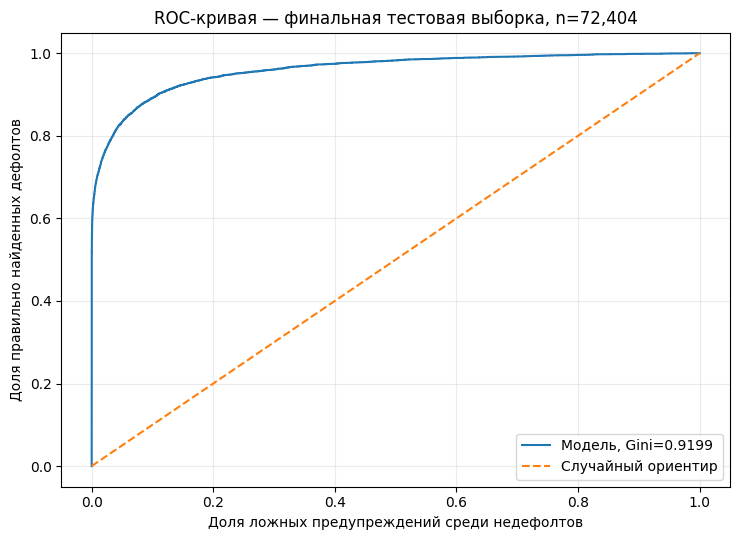

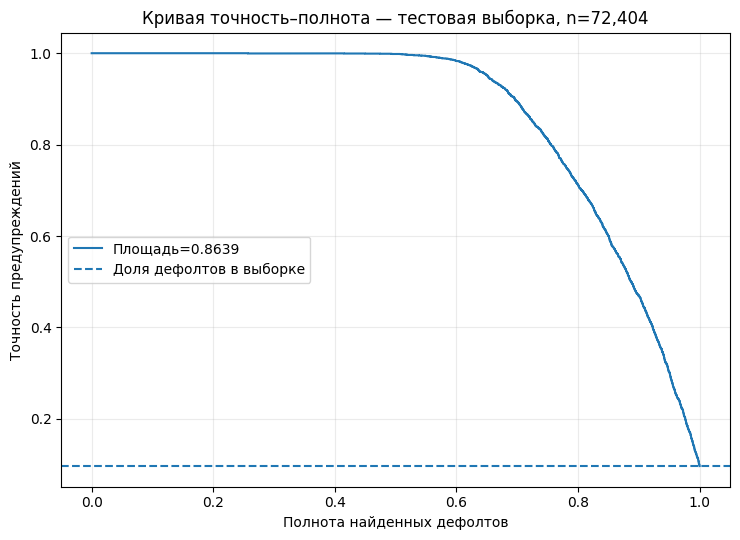

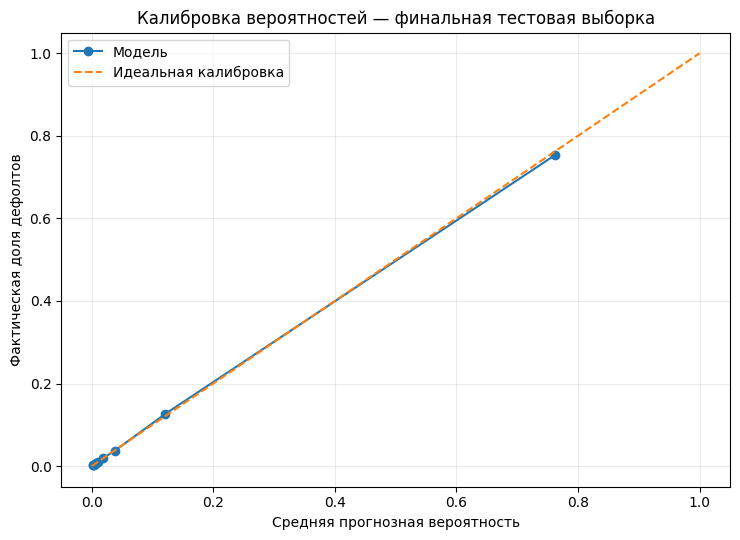

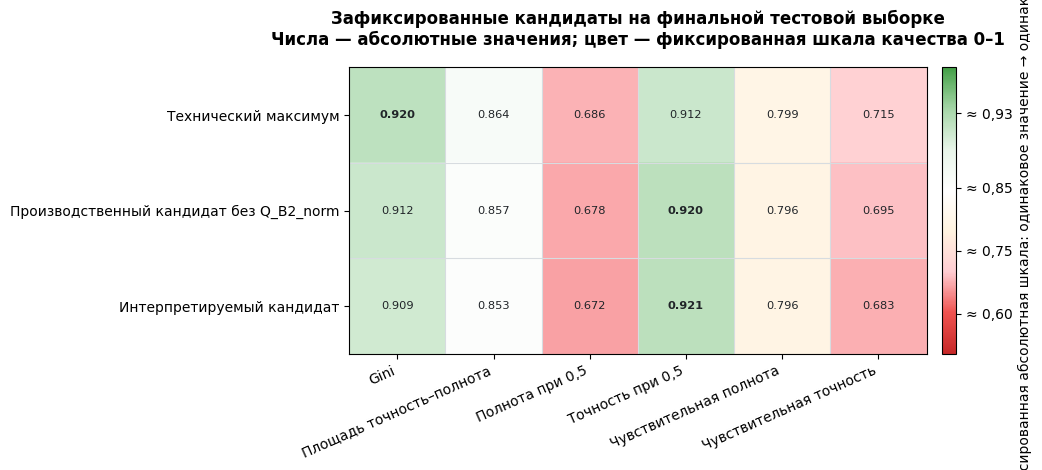

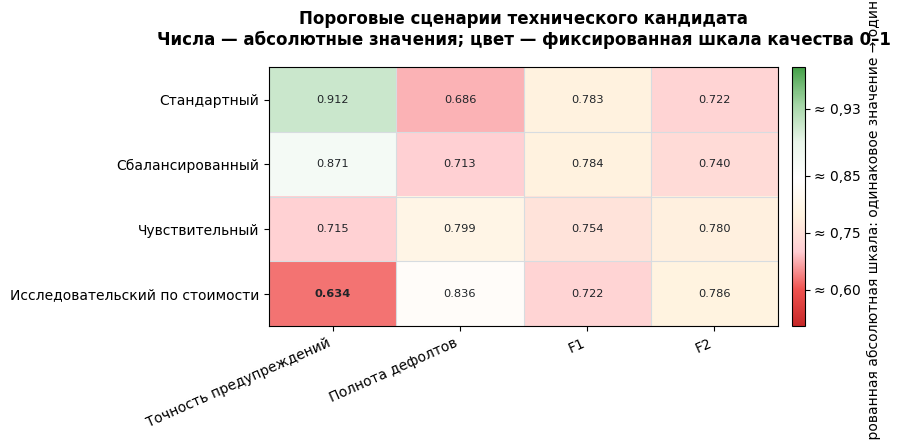

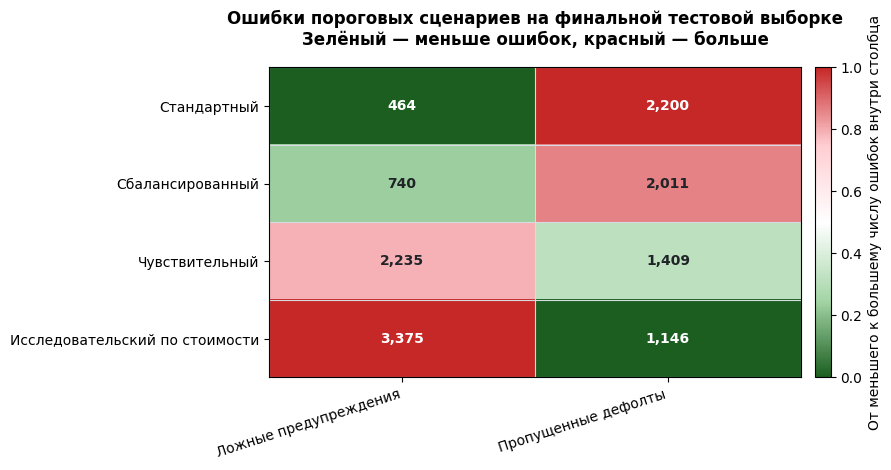

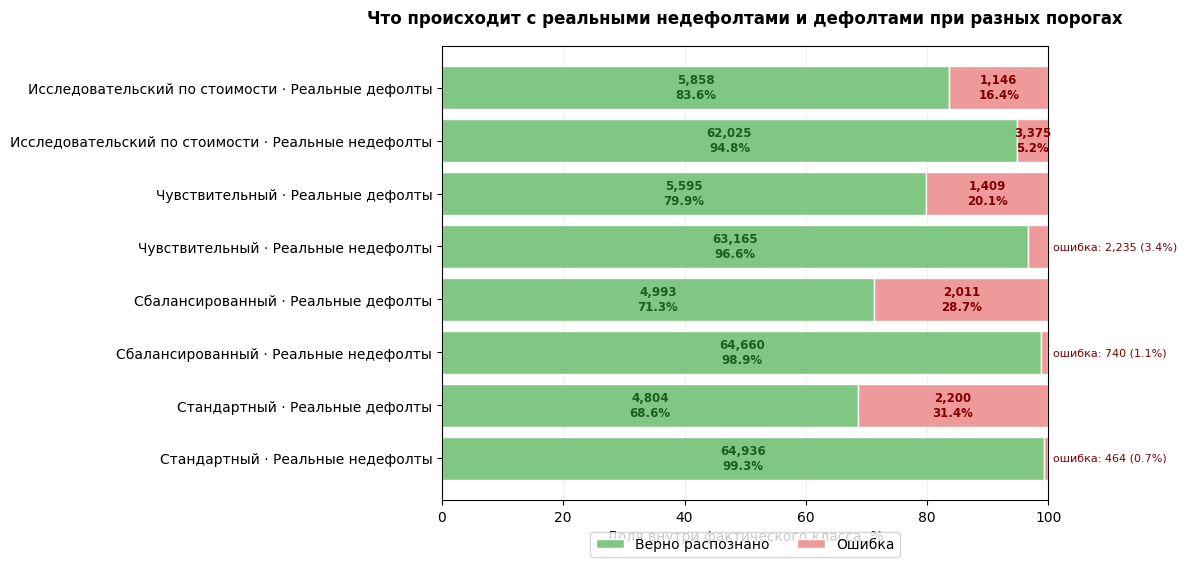

In [29]:
# @title Интуитивные графики финальной тестовой выборки
fpr, tpr, _ = roc_curve(y_test, TEST_ВЕРОЯТНОСТИ)
точность_кривой, полнота_кривой, _ = precision_recall_curve(y_test, TEST_ВЕРОЯТНОСТИ)
gini_test = float(ИТОГОВЫЕ_МЕТРИКИ_TEST.iloc[0]["Gini"])
pr_auc_test = float(ИТОГОВЫЕ_МЕТРИКИ_TEST.iloc[0]["PR-AUC"])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(fpr, tpr, label=f"Модель, Gini={gini_test:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Случайный ориентир")
ax.set_xlabel("Доля ложных предупреждений среди недефолтов")
ax.set_ylabel("Доля правильно найденных дефолтов")
ax.set_title(f"ROC-кривая — финальная тестовая выборка, n={len(y_test):,}")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ПАПКИ["графики"] / "roc_финальная_тестовая_выборка.png", dpi=170, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(полнота_кривой, точность_кривой, label=f"Площадь={pr_auc_test:.4f}")
ax.axhline(y_test.mean(), linestyle="--", label="Доля дефолтов в выборке")
ax.set_xlabel("Полнота найденных дефолтов")
ax.set_ylabel("Точность предупреждений")
ax.set_title(f"Кривая точность–полнота — тестовая выборка, n={len(y_test):,}")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ПАПКИ["графики"] / "кривая_точность_полнота_тест.png", dpi=170, bbox_inches="tight")
plt.show()

калибровочные_корзины = pd.qcut(pd.Series(TEST_ВЕРОЯТНОСТИ), q=10, duplicates="drop")
КАЛИБРОВОЧНАЯ_ТАБЛИЦА = pd.DataFrame({
    "Вероятность": TEST_ВЕРОЯТНОСТИ,
    "Факт": y_test.to_numpy(),
    "Корзина": калибровочные_корзины.astype(str),
}).groupby("Корзина", observed=True).agg(
    Средняя_вероятность=("Вероятность", "mean"),
    Фактическая_доля=("Факт", "mean"),
    Наблюдений=("Факт", "size"),
).reset_index()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(
    КАЛИБРОВОЧНАЯ_ТАБЛИЦА["Средняя_вероятность"],
    КАЛИБРОВОЧНАЯ_ТАБЛИЦА["Фактическая_доля"],
    marker="o",
    label="Модель",
)
ax.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")
ax.set_xlabel("Средняя прогнозная вероятность")
ax.set_ylabel("Фактическая доля дефолтов")
ax.set_title("Калибровка вероятностей — финальная тестовая выборка")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ПАПКИ["графики"] / "калибровка_финальная_тестовая_выборка.png", dpi=170, bbox_inches="tight")
plt.show()

# Светлая матрица сравнения заранее зафиксированных кандидатов.
матрица_кандидатов = СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ.set_index("Роль кандидата")[[
    "Gini", "PR-AUC", "Полнота при пороге 0,5", "Точность при пороге 0,5",
    "Полнота чувствительного сценария", "Точность чувствительного сценария",
]].copy()
матрица_кандидатов.columns = [
    "Gini", "Площадь точность–полнота", "Полнота при 0,5", "Точность при 0,5",
    "Чувствительная полнота", "Чувствительная точность",
]
построить_матрицу_абсолютных_метрик(
    матрица_кандидатов,
    "Зафиксированные кандидаты на финальной тестовой выборке",
    путь=ПАПКИ["графики"] / "цветовая_матрица_кандидатов_тест.png",
    размер=(12, 4.8),
)

матрица_порогов_тест = ИТОГОВЫЕ_МЕТРИКИ_TEST.set_index("Сценарий")[[
    "Precision", "Recall", "F1", "F2"
]].copy()
матрица_порогов_тест.columns = [
    "Точность предупреждений", "Полнота дефолтов", "F1", "F2"
]
построить_матрицу_абсолютных_метрик(
    матрица_порогов_тест,
    "Пороговые сценарии технического кандидата",
    путь=ПАПКИ["графики"] / "цветовая_матрица_порогов_тест.png",
    размер=(9, 4.5),
)

матрица_ошибок_тест = ИТОГОВЫЕ_МЕТРИКИ_TEST.set_index("Сценарий")[["FP", "FN"]].copy()
матрица_ошибок_тест.columns = ["Ложные предупреждения", "Пропущенные дефолты"]
построить_матрицу_ошибок_по_сценариям(
    матрица_ошибок_тест,
    "Ошибки пороговых сценариев на финальной тестовой выборке",
    путь=ПАПКИ["графики"] / "цветовая_матрица_ошибок_тест.png",
    размер=(9, 4.8),
)


def показать_матрицу_ошибок(название_сценария: str) -> None:
    строка = ИТОГОВЫЕ_МЕТРИКИ_TEST[
        ИТОГОВЫЕ_МЕТРИКИ_TEST["Сценарий"] == название_сценария
    ].iloc[0]
    матрица = np.array(
        [[строка["TN"], строка["FP"]], [строка["FN"], строка["TP"]]],
        dtype=int,
    )
    построить_семантическую_матрицу_ошибок(
        матрица,
        f"Матрица ошибок — сценарий «{название_сценария}»",
        путь=ПАПКИ["графики"] / f"матрица_ошибок_{безопасное_имя(название_сценария)}.png",
    )

ТАБЛИЦА_ПРОЦЕНТНЫХ_ОШИБОК = построить_процентные_полосы_ошибок(
    y_true=y_test,
    вероятности=TEST_ВЕРОЯТНОСТИ,
    сценарии=ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ,
    путь=ПАПКИ["графики"] / "процентные_полосы_ошибок_по_порогам.png",
)
ТАБЛИЦА_ПРОЦЕНТНЫХ_ОШИБОК.to_csv(
    ПАПКИ["метрики"] / "процентные_ошибки_по_порогам.csv",
    index=False,
    encoding="utf-8-sig",
)

# Технические матрицы 2×2 сохраняются как данные, но не занимают основной вывод.
_технические_матрицы = []
for _сценарий in ["Стандартный", "Чувствительный"]:
    _строка = ИТОГОВЫЕ_МЕТРИКИ_TEST[
        ИТОГОВЫЕ_МЕТРИКИ_TEST["Сценарий"] == _сценарий
    ].iloc[0]
    _технические_матрицы.append({
        "Сценарий": _сценарий,
        "TN": int(_строка["TN"]),
        "FP": int(_строка["FP"]),
        "FN": int(_строка["FN"]),
        "TP": int(_строка["TP"]),
    })
pd.DataFrame(_технические_матрицы).to_csv(
    ПАПКИ["метрики"] / "технические_матрицы_ошибок.csv",
    index=False,
    encoding="utf-8-sig",
)



In [30]:
# @title Анализ итоговой проверки
стандартный_test = ИТОГОВЫЕ_МЕТРИКИ_TEST[
    ИТОГОВЫЕ_МЕТРИКИ_TEST["Сценарий"] == "Стандартный"
].iloc[0]
чувствительный_test = ИТОГОВЫЕ_МЕТРИКИ_TEST[
    ИТОГОВЫЕ_МЕТРИКИ_TEST["Сценарий"] == "Чувствительный"
].iloc[0]

разница_пропущенных = int(стандартный_test["FN"] - чувствительный_test["FN"])
разница_ложных = int(чувствительный_test["FP"] - стандартный_test["FP"])

display(Markdown(f"""
### Анализ полученного результата

Технический кандидат на всех признаках получил на финальной тестовой выборке:

- Gini: **{стандартный_test['Gini']:.4f}**;
- площадь под кривой точность–полнота: **{стандартный_test['PR-AUC']:.4f}**;
- полноту дефолтов при пороге 0,5: **{стандартный_test['Recall']:.4f}**;
- точность предупреждений при пороге 0,5: **{стандартный_test['Precision']:.4f}**.

Переход к чувствительному сценарию уменьшает число пропущенных дефолтов на **{разница_пропущенных:,}**, но добавляет **{разница_ложных:,}** ложных предупреждений.

Три кандидата были зафиксированы до теста. Их тестовые результаты показаны для прозрачности и не используются для нового подбора. Производственная рекомендация должна учитывать не только максимальный Gini, но и воспроизводимость признаков — прежде всего неизвестного `Q_B2_norm`.

**Следующий вопрос:** насколько устойчивы метрики к повторным выборкам и случайности обучения?
"""))


показать_панель(
    "Финальная тестовая проверка завершена",
    f"Gini технического кандидата: {стандартный_test['Gini']:.4f}; "
    f"полнота чувствительного сценария: {чувствительный_test['Recall']:.4f}; "
    f"точность предупреждений: {чувствительный_test['Precision']:.4f}.",
    "успех",
)
показать_панель(
    "Рабочий порог должен утвердить бизнес",
    f"Чувствительный сценарий пропускает {int(чувствительный_test['FN']):,} дефолтов "
    f"и создаёт {int(чувствительный_test['FP']):,} ложных предупреждений. "
    "Это бизнес-компромисс, а не универсально лучший порог.",
    "предупреждение",
)



### Анализ полученного результата

Технический кандидат на всех признаках получил на финальной тестовой выборке:

- Gini: **0.9199**;
- площадь под кривой точность–полнота: **0.8639**;
- полноту дефолтов при пороге 0,5: **0.6859**;
- точность предупреждений при пороге 0,5: **0.9119**.

Переход к чувствительному сценарию уменьшает число пропущенных дефолтов на **791**, но добавляет **1,771** ложных предупреждений.

Три кандидата были зафиксированы до теста. Их тестовые результаты показаны для прозрачности и не используются для нового подбора. Производственная рекомендация должна учитывать не только максимальный Gini, но и воспроизводимость признаков — прежде всего неизвестного `Q_B2_norm`.

**Следующий вопрос:** насколько устойчивы метрики к повторным выборкам и случайности обучения?


# 16. Доверительные интервалы и устойчивость

**Исследовательский вопрос:** насколько итоговые метрики чувствительны к составу выборки и случайности обучения?

Проверяем:

- повторные выборки-доверительные интервалы на финальной тестовой выборке;
- вариативность модели по нескольким случайное зерно — в рекомендуемом и полном профиле;
- разрыв между внефолдовые и тестовая выборка.

Bootstrap оценивает неопределённость метрик. Он не является повторные выборки-ансамблем моделей.

In [31]:
# @title Доверительные интервалы методом повторных выборок
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Доверительные интервалы',
    {
        "подпись_решений": ПОДПИСЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ,
        "итераций": НАСТРОЙКИ_ПРОФИЛЯ["bootstrap_итераций"],
        "seed": СЛУЧАЙНОЕ_ЗЕРНО,
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Доверительные интервалы',
    _ПОДПИСЬ_ЭТАПА,
    ['BOOTSTRAP_ИНТЕРВАЛЫ', 'BOOTSTRAP_ПОДРОБНО'],
)

if _ВОССТАНОВЛЕНО:
    display(BOOTSTRAP_ИНТЕРВАЛЫ)
else:
    def bootstrap_интервалы(
        y_true: pd.Series | np.ndarray,
        вероятности: np.ndarray,
        сценарии: pd.DataFrame,
        число_итераций: int,
        seed: int,
    ) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        y = np.asarray(y_true, dtype=int)
        p = np.asarray(вероятности, dtype=float)
        индексы_0 = np.flatnonzero(y == 0)
        индексы_1 = np.flatnonzero(y == 1)

        интересующие = сценарии[
            сценарии["Сценарий"].isin(["Сбалансированный", "Чувствительный"])
        ]
        записи = []

        for итерация in range(число_итераций):
            выборка_0 = rng.choice(индексы_0, size=len(индексы_0), replace=True)
            выборка_1 = rng.choice(индексы_1, size=len(индексы_1), replace=True)
            выборка = np.concatenate([выборка_0, выборка_1])
            rng.shuffle(выборка)

            y_boot = y[выборка]
            p_boot = p[выборка]
            roc_auc = float(roc_auc_score(y_boot, p_boot))
            pr_auc = float(average_precision_score(y_boot, p_boot))

            for _, сценарий in интересующие.iterrows():
                метрики = рассчитать_метрики(
                    y_boot, p_boot, float(сценарий["Порог"])
                )
                записи.append({
                    "Итерация": итерация + 1,
                    "Сценарий": сценарий["Сценарий"],
                    "Gini": 2 * roc_auc - 1,
                    "PR-AUC": pr_auc,
                    "Precision": метрики["Precision"],
                    "Recall": метрики["Recall"],
                    "F1": метрики["F1"],
                    "F2": метрики["F2"],
                })

        подробные = pd.DataFrame(записи)
        строки = []
        for сценарий, группа in подробные.groupby("Сценарий"):
            for метрика in ["Gini", "PR-AUC", "Precision", "Recall", "F1", "F2"]:
                значения = группа[метрика].to_numpy()
                строки.append({
                    "Сценарий": сценарий,
                    "Метрика": метрика,
                    "Среднее": float(np.mean(значения)),
                    "Нижняя граница 95%": float(np.quantile(значения, 0.025)),
                    "Верхняя граница 95%": float(np.quantile(значения, 0.975)),
                    "Стандартное отклонение": float(np.std(значения, ddof=1)),
                })
        return pd.DataFrame(строки), подробные

    print(
        f"Повторные выборки (bootstrap): {НАСТРОЙКИ_ПРОФИЛЯ['bootstrap_итераций']} итераций. "
        "В полном профиле этап может занять несколько минут."
    )
    BOOTSTRAP_ИНТЕРВАЛЫ, BOOTSTRAP_ПОДРОБНО = bootstrap_интервалы(
        y_test,
        TEST_ВЕРОЯТНОСТИ,
        ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ,
        число_итераций=НАСТРОЙКИ_ПРОФИЛЯ["bootstrap_итераций"],
        seed=СЛУЧАЙНОЕ_ЗЕРНО,
    )
    display(BOOTSTRAP_ИНТЕРВАЛЫ.replace({"PR-AUC": "Площадь точность–полнота", "Precision": "Точность предупреждений", "Recall": "Полнота дефолтов"}).style.format({
        "Среднее": "{:.4f}",
        "Нижняя граница 95%": "{:.4f}",
        "Верхняя граница 95%": "{:.4f}",
        "Стандартное отклонение": "{:.4f}",
    }))
    BOOTSTRAP_ИНТЕРВАЛЫ.to_csv(
        ПАПКИ["метрики"] / "bootstrap_интервалы.csv",
        index=False,
        encoding="utf-8-sig",
    )
    сохранить_контрольную_точку(
        'Доверительные интервалы',
        _ПОДПИСЬ_ЭТАПА,
        ['BOOTSTRAP_ИНТЕРВАЛЫ', 'BOOTSTRAP_ПОДРОБНО'],
    )


Повторные выборки (bootstrap): 700 итераций. В полном профиле этап может занять несколько минут.


,Сценарий,Метрика,Среднее,Нижняя граница 95%,Верхняя граница 95%,Стандартное отклонение
0,Сбалансированный,Gini,0.9198,0.9144,0.9246,0.0028
1,Сбалансированный,Площадь точность–полнота,0.8636,0.8571,0.8696,0.0033
2,Сбалансированный,Точность предупреждений,0.8707,0.8619,0.8792,0.0044
3,Сбалансированный,Полнота дефолтов,0.7122,0.7023,0.7225,0.0053
4,Сбалансированный,F1,0.7835,0.7755,0.7919,0.0041
5,Сбалансированный,F2,0.7391,0.7300,0.7487,0.0048
6,Чувствительный,Gini,0.9198,0.9144,0.9246,0.0028
7,Чувствительный,Площадь точность–полнота,0.8636,0.8571,0.8696,0.0033
8,Чувствительный,Точность предупреждений,0.7143,0.7054,0.7229,0.0045
9,Чувствительный,Полнота дефолтов,0.7983,0.7892,0.8072,0.0049


In [32]:
# @title Проверка устойчивости по нескольким случайным зернам
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Устойчивость по случайным зернам',
    {
        "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "параметры": ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
        "признаки": ФИНАЛЬНЫЕ_ПРИЗНАКИ,
        "зерна": НАСТРОЙКИ_ПРОФИЛЯ["случайные_зерна"],
        "включено": НАСТРОЙКИ_ПРОФИЛЯ["проверка_случайных_зерен"],
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Устойчивость по случайным зернам',
    _ПОДПИСЬ_ЭТАПА,
    ['РЕЗУЛЬТАТЫ_СЛУЧАЙНЫХ_ЗЕРЕН', 'ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН'],
)

if _ВОССТАНОВЛЕНО:
    display(ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН)
else:
    РЕЗУЛЬТАТЫ_СЛУЧАЙНЫХ_ЗЕРЕН = []

    if not НАСТРОЙКИ_ПРОФИЛЯ["проверка_случайных_зерен"]:
        print(
            "Профиль «Быстрая проверка»: проверка нескольких случайных зерен пропущена. "
            "Она включится в профиле «Рекомендуемый»."
        )
    else:
        for seed in НАСТРОЙКИ_ПРОФИЛЯ["случайные_зерна"]:
            print(f"\nСлучайное зерно: {seed}")
            результат = выполнить_cv(
                код_модели=КОД_ОСНОВНОЙ_МОДЕЛИ,
                признаки=ФИНАЛЬНЫЕ_ПРИЗНАКИ,
                использовать_веса=ИСПОЛЬЗОВАТЬ_ВЕСА_В_ФИНАЛЕ,
                параметры=ПАРАМЕТРЫ_ОСНОВНОЙ_МОДЕЛИ,
                seed=int(seed),
            )
            метрики = результат["итоговые_метрики"]
            РЕЗУЛЬТАТЫ_СЛУЧАЙНЫХ_ЗЕРЕН.append({
                "Случайное зерно": int(seed),
                "Gini": метрики["Gini"],
                "PR-AUC": метрики["PR-AUC"],
                "Полнота при пороге 0,5": метрики["Recall"],
                "Время кросс-валидации, сек": метрики["Время обучения CV, сек"],
            })

    ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН = pd.DataFrame(РЕЗУЛЬТАТЫ_СЛУЧАЙНЫХ_ЗЕРЕН)
    if not ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН.empty:
        display(ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН.style.format({
            "Gini": "{:.4f}",
            "PR-AUC": "{:.4f}",
            "Полнота при пороге 0,5": "{:.4f}",
            "Время кросс-валидации, сек": "{:.1f}",
        }))
        ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН.to_csv(
            ПАПКИ["метрики"] / "устойчивость_по_случайным_зернам.csv",
            index=False,
            encoding="utf-8-sig",
        )
        print(
            f"Разброс Gini по случайным зернам: "
            f"{ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН['Gini'].max() - ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН['Gini'].min():.4f}"
        )
    сохранить_контрольную_точку(
        'Устойчивость по случайным зернам',
        _ПОДПИСЬ_ЭТАПА,
        ['РЕЗУЛЬТАТЫ_СЛУЧАЙНЫХ_ЗЕРЕН', 'ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН'],
    )



Случайное зерно: 7
  ✓ XGBoost: Gini=0.9244, PR-AUC=0.8676

Случайное зерно: 17
  ✓ XGBoost: Gini=0.9243, PR-AUC=0.8675

Случайное зерно: 42
  ✓ XGBoost: Gini=0.9245, PR-AUC=0.8675

Случайное зерно: 101
  ✓ XGBoost: Gini=0.9247, PR-AUC=0.8677

Случайное зерно: 2026
  ✓ XGBoost: Gini=0.9248, PR-AUC=0.8677


,Случайное зерно,Gini,PR-AUC,"Полнота при пороге 0,5","Время кросс-валидации, сек"
0,7,0.9244,0.8676,0.6841,170.5
1,17,0.9243,0.8675,0.6851,167.1
2,42,0.9245,0.8675,0.6828,167.3
3,101,0.9247,0.8677,0.6840,163.5
4,2026,0.9248,0.8677,0.6831,157.5


Разброс Gini по случайным зернам: 0.0005


In [33]:
# @title Анализ устойчивости
oof_метрики_финальные = рассчитать_метрики(
    y_работа, ФИНАЛЬНЫЙ_OOF["oof_калиброванные"], порог=0.5
)
тестовые_метрики_ранжирования = рассчитать_метрики(
    y_test, TEST_ВЕРОЯТНОСТИ, порог=0.5
)
разрыв_gini = oof_метрики_финальные["Gini"] - тестовые_метрики_ранжирования["Gini"]

интервал_gini = BOOTSTRAP_ИНТЕРВАЛЫ[
    (BOOTSTRAP_ИНТЕРВАЛЫ["Сценарий"] == "Чувствительный")
    & (BOOTSTRAP_ИНТЕРВАЛЫ["Метрика"] == "Gini")
].iloc[0]

текст_случайных_зерен = (
    f"Разброс Gini по случайным зернам составил **{ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН['Gini'].max() - ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН['Gini'].min():.4f}**."
    if not ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН.empty
    else "Проверка нескольких случайных зерен пропущена текущим быстрым профилем."
)

display(Markdown(f"""
### Анализ полученного результата

- Gini по внефолдовым прогнозам выбранного конвейера: **{oof_метрики_финальные['Gini']:.4f}**.
- Gini финальной тестовой выборки: **{тестовые_метрики_ранжирования['Gini']:.4f}**.
- Разрыв между рабочей и тестовой оценкой: **{разрыв_gini:+.4f}**.
- 95%-й интервал Gini по повторным выборкам: **[{интервал_gini['Нижняя граница 95%']:.4f}; {интервал_gini['Верхняя граница 95%']:.4f}]**.
- {текст_случайных_зерен}

**Вывод:** небольшое снижение на тестовой выборке ожидаемо; существенный разрыв потребовал бы проверки временной стабильности и происхождения признаков. Следующий вопрос — какие признаки формируют прогноз модели.
"""))


показать_панель(
    "Результат устойчив",
    f"Разрыв Gini между рабочей и тестовой частями: {разрыв_gini:+.4f}. "
    "Небольшой разрыв и низкий разброс по случайным зернам не показывают выраженного переобучения.",
    "успех" if abs(разрыв_gini) <= 0.02 else "предупреждение",
)



### Анализ полученного результата

- Gini по внефолдовым прогнозам выбранного конвейера: **0.9244**.
- Gini финальной тестовой выборки: **0.9199**.
- Разрыв между рабочей и тестовой оценкой: **+0.0045**.
- 95%-й интервал Gini по повторным выборкам: **[0.9144; 0.9246]**.
- Разброс Gini по случайным зернам составил **0.0005**.

**Вывод:** небольшое снижение на тестовой выборке ожидаемо; существенный разрыв потребовал бы проверки временной стабильности и происхождения признаков. Следующий вопрос — какие признаки формируют прогноз модели.


# 17. Интерпретация модели

**Исследовательский вопрос:** какие признаки определяют прогноз и согласуется ли это с бизнес-логикой?

Используем два уровня:

1. перестановочная важность на фиксированной части финальной тестовой выборки;
2. SHAP на ограниченной подвыборке — только в рекомендуемом и полном профиле.

Важность и SHAP показывают вклад в прогноз, а не причинное влияние. Особо проверяем положение `Q_B2_norm`.

Перестановочная важность: 20,000 строк, 5 повторов.
  Проверено признаков: 10/49
  Проверено признаков: 20/49
  Проверено признаков: 30/49
  Проверено признаков: 40/49
  Проверено признаков: 49/49


,Признак,Среднее снижение ROC-AUC,Стандартное отклонение
0,Q_B1_norm,0.03120,0.00082
1,Q_B2_norm,0.03068,0.00112
2,Q_B3_norm,0.01465,0.00117
3,Q_D4_norm,0.00526,0.00034
4,A4_norm,0.00489,0.00044
5,G1_norm,0.00296,0.00074
6,Q_C1_norm,0.00182,0.00042
7,Q_A5_norm,0.00125,0.00031
8,Q_A2_norm,0.00084,0.00017
9,Q_A6_norm,0.00075,0.00018


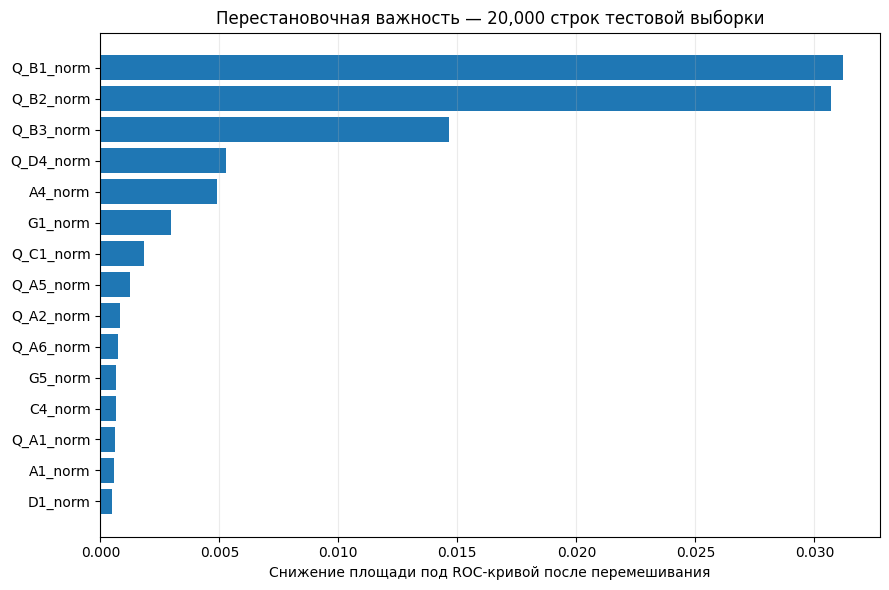

In [34]:
# @title Перестановочная важность признаков
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'Перестановочная важность',
    {
        "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "роль": ОСНОВНАЯ_РОЛЬ,
        "признаки": ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ if "ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ" in globals() else ФИНАЛЬНЫЕ_ПРИЗНАКИ,
        "строк": НАСТРОЙКИ_ПРОФИЛЯ["permutation_строк"],
        "повторов": НАСТРОЙКИ_ПРОФИЛЯ["permutation_повторов"],
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'Перестановочная важность',
    _ПОДПИСЬ_ЭТАПА,
    ['РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'ВАЖНОСТЬ_ПЕРЕСТАНОВОК'],
)

if _ВОССТАНОВЛЕНО:
    display(ВАЖНОСТЬ_ПЕРЕСТАНОВОК.head(20))
    _топ_перестановок = ВАЖНОСТЬ_ПЕРЕСТАНОВОК.head(15).sort_values(
        "Среднее снижение ROC-AUC", ascending=True
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(
        _топ_перестановок["Признак"],
        _топ_перестановок["Среднее снижение ROC-AUC"],
    )
    ax.set_xlabel("Снижение площади под ROC-кривой после перемешивания")
    ax.set_title("Перестановочная важность признаков")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        ПАПКИ["графики"] / "перестановочная_важность.png",
        dpi=170,
        bbox_inches="tight",
    )
    plt.show()
else:
    РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ = ОСНОВНАЯ_РОЛЬ
    МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ = ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ[РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ]
    ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ = КАНДИДАТЫ_ДО_ТЕСТА[РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ]["признаки"]

    rng = np.random.default_rng(СЛУЧАЙНОЕ_ЗЕРНО)
    число_строк_важности = min(НАСТРОЙКИ_ПРОФИЛЯ["permutation_строк"], len(X_test))
    индексы_важности = rng.choice(len(X_test), size=число_строк_важности, replace=False)
    X_важность = X_test.iloc[индексы_важности][ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ].copy()
    y_важность = y_test.iloc[индексы_важности].to_numpy()
    число_повторов = int(НАСТРОЙКИ_ПРОФИЛЯ["permutation_повторов"])

    print(f"Перестановочная важность: {число_строк_важности:,} строк, {число_повторов} повторов.")

    # Собственная модельно-независимая реализация не зависит от совместимости
    # конкретной библиотеки модели со служебными тегами scikit-learn.
    базовые_вероятности = МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ.predict_proba(X_важность)[:, 1]
    базовый_auc = float(roc_auc_score(y_важность, базовые_вероятности))
    строки_важности = []

    for номер, признак in enumerate(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ, start=1):
        снижения = []
        исходный_столбец = X_важность[признак].to_numpy(copy=True)
        for повтор in range(число_повторов):
            переставленные_данные = X_важность.copy()
            переставленные_данные[признак] = rng.permutation(исходный_столбец)
            вероятности = МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ.predict_proba(переставленные_данные)[:, 1]
            auc = float(roc_auc_score(y_важность, вероятности))
            снижения.append(базовый_auc - auc)
        строки_важности.append({
            "Признак": признак,
            "Среднее снижение ROC-AUC": float(np.mean(снижения)),
            "Стандартное отклонение": float(np.std(снижения, ddof=1)) if len(снижения) > 1 else 0.0,
        })
        if номер % 10 == 0 or номер == len(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ):
            print(f"  Проверено признаков: {номер}/{len(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ)}")

    ВАЖНОСТЬ_ПЕРЕСТАНОВОК = pd.DataFrame(строки_важности).sort_values(
        "Среднее снижение ROC-AUC", ascending=False
    ).reset_index(drop=True)

    display(ВАЖНОСТЬ_ПЕРЕСТАНОВОК.head(20).style.format({
        "Среднее снижение ROC-AUC": "{:.5f}",
        "Стандартное отклонение": "{:.5f}",
    }))
    ВАЖНОСТЬ_ПЕРЕСТАНОВОК.to_csv(
        ПАПКИ["метрики"] / "перестановочная_важность.csv", index=False, encoding="utf-8-sig"
    )

    топ = ВАЖНОСТЬ_ПЕРЕСТАНОВОК.head(15).sort_values("Среднее снижение ROC-AUC", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(топ["Признак"], топ["Среднее снижение ROC-AUC"])
    ax.set_xlabel("Снижение площади под ROC-кривой после перемешивания")
    ax.set_title(f"Перестановочная важность — {число_строк_важности:,} строк тестовой выборки")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(ПАПКИ["графики"] / "перестановочная_важность.png", dpi=170, bbox_inches="tight")
    plt.show()
    сохранить_контрольную_точку(
        'Перестановочная важность',
        _ПОДПИСЬ_ЭТАПА,
        ['РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ', 'ВАЖНОСТЬ_ПЕРЕСТАНОВОК'],
    )


SHAP: анализ 3,000 строк для роли «Технический максимум» и модели «XGBoost»...


,Признак,Средний абсолютный вклад SHAP,Средний направленный вклад SHAP
0,Q_B1_norm,1.033748,-0.524719
1,Q_B2_norm,0.783820,-0.327832
2,Q_B3_norm,0.539462,-0.249188
3,G1_norm,0.268208,-0.108290
4,A4_norm,0.246855,+0.010757
5,Q_D4_norm,0.197572,-0.083026
6,Q_C1_norm,0.177537,-0.060149
7,Q_D6_norm,0.137094,-0.035858
8,C4_norm,0.116623,-0.040342
9,A1_norm,0.111492,-0.050416


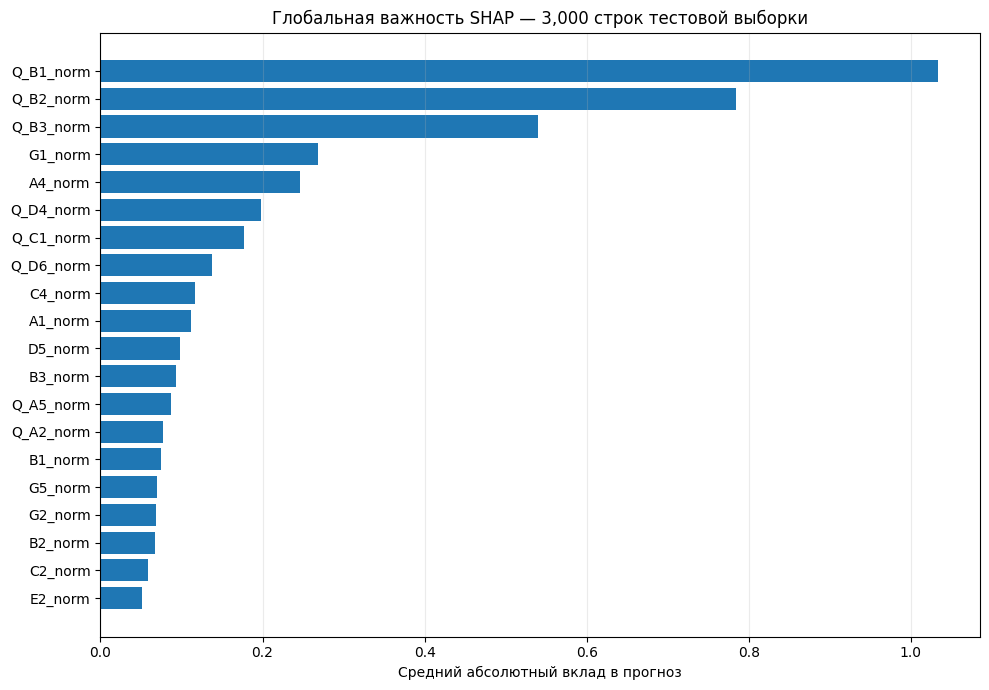

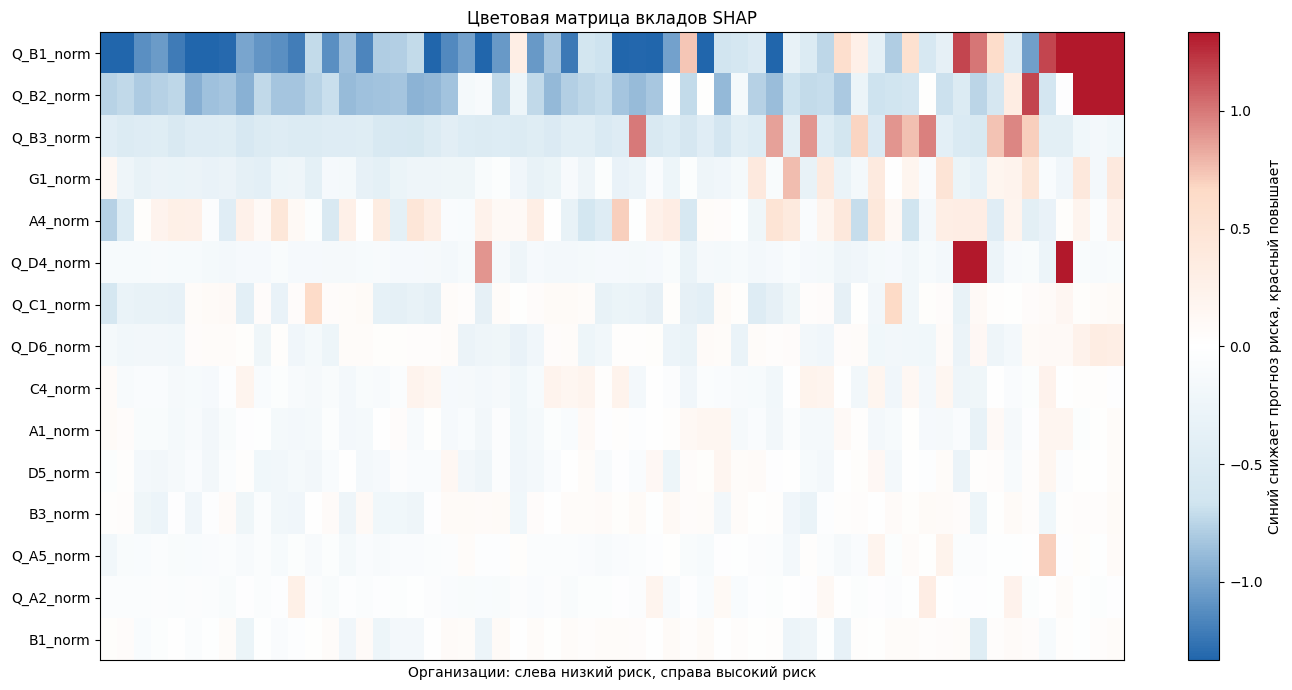

✓ Выполнен на 3,000 строках; метод: Встроенные точные вклады XGBoost


In [35]:
# @title Анализ вклада признаков методом SHAP
_ПОДПИСЬ_ЭТАПА = подпись_этапа(
    'SHAP-интерпретация',
    {
        "модель": КОД_ОСНОВНОЙ_МОДЕЛИ,
        "роль": ОСНОВНАЯ_РОЛЬ,
        "включено": НАСТРОЙКИ_ПРОФИЛЯ["shap"],
        "строк": НАСТРОЙКИ_ПРОФИЛЯ["shap_строк"],
        "версия_визуализации": ВЕРСИЯ_ВИЗУАЛИЗАЦИИ,
    },
)
_ВОССТАНОВЛЕНО = восстановить_контрольную_точку(
    'SHAP-интерпретация',
    _ПОДПИСЬ_ЭТАПА,
    ['SHAP_ВАЖНОСТЬ', 'SHAP_СТАТУС', 'SHAP_МЕТОД'],
)

if _ВОССТАНОВЛЕНО:
    print(SHAP_СТАТУС)
else:
    SHAP_ВАЖНОСТЬ = pd.DataFrame()
    SHAP_СТАТУС = "Пропущен текущим профилем"
    SHAP_МЕТОД = None

    if not НАСТРОЙКИ_ПРОФИЛЯ["shap"]:
        print("Текущий профиль не требует SHAP. Он включён в рекомендуемом и полном режимах.")
    else:
        try:
            число_shap = min(int(НАСТРОЙКИ_ПРОФИЛЯ["shap_строк"]), len(X_test))
            индексы_shap = rng.choice(len(X_test), size=число_shap, replace=False)
            X_shap = X_test.iloc[индексы_shap][ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ].copy()
            модель_shap = МОДЕЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ
            код_модели_shap = КОД_ОСНОВНОЙ_МОДЕЛИ

            print(
                f"SHAP: анализ {число_shap:,} строк для роли "
                f"«{РОЛЬ_ДЛЯ_ИНТЕРПРЕТАЦИИ}» и модели "
                f"«{РЕЕСТР_МОДЕЛЕЙ[код_модели_shap]}»..."
            )

            if isinstance(модель_shap, Pipeline):
                import shap
                преобразователь = модель_shap.named_steps["масштабирование"]
                внутренняя_модель = модель_shap.named_steps["модель"]
                X_модель = преобразователь.transform(X_shap)
                объяснитель = shap.LinearExplainer(внутренняя_модель, X_модель)
                значения = np.asarray(объяснитель(X_модель).values, dtype=float)
                SHAP_МЕТОД = "Линейный SHAP"

            elif код_модели_shap == "xgboost":
                import xgboost as xgb
                матрица_xgb = xgb.DMatrix(
                    X_shap,
                    feature_names=ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ,
                )
                значения = np.asarray(
                    модель_shap.get_booster().predict(
                        матрица_xgb,
                        pred_contribs=True,
                        approx_contribs=False,
                    )[:, :-1],
                    dtype=float,
                )
                SHAP_МЕТОД = "Встроенные точные вклады XGBoost"

            elif код_модели_shap == "lightgbm":
                значения = np.asarray(
                    модель_shap.predict(X_shap, pred_contrib=True)[:, :-1],
                    dtype=float,
                )
                SHAP_МЕТОД = "Встроенные вклады LightGBM"

            elif код_модели_shap == "catboost":
                from catboost import Pool
                значения = np.asarray(
                    модель_shap.get_feature_importance(
                        Pool(X_shap),
                        type="ShapValues",
                        shap_calc_type="Approximate",
                        thread_count=ЧИСЛО_ПОТОКОВ,
                    )[:, :-1],
                    dtype=float,
                )
                SHAP_МЕТОД = "Встроенные приближённые вклады CatBoost"

            else:
                import shap
                try:
                    объяснитель = shap.TreeExplainer(модель_shap)
                    результат_shap = объяснитель(X_shap)
                    значения = np.asarray(результат_shap.values, dtype=float)
                    if значения.ndim == 3:
                        значения = значения[:, :, -1]
                    SHAP_МЕТОД = "Древесный SHAP"
                except Exception as ошибка_tree_shap:
                    # Универсальный резервный вариант намеренно ограничен по строкам,
                    # иначе перестановочное объяснение может быть слишком долгим в Colab.
                    число_фона = min(50, len(X_работа))
                    индексы_фона = rng.choice(len(X_работа), size=число_фона, replace=False)
                    фон = X_работа.iloc[индексы_фона][ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ].copy()
                    X_shap = X_shap.head(min(len(X_shap), 80)).copy()

                    def функция_прогноза(массив):
                        таблица = pd.DataFrame(
                            массив,
                            columns=ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ,
                        )
                        return модель_shap.predict_proba(таблица)[:, 1]

                    объяснитель = shap.PermutationExplainer(функция_прогноза, фон)
                    результат_shap = объяснитель(
                        X_shap,
                        max_evals=2 * len(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ) + 1,
                        silent=True,
                    )
                    значения = np.asarray(результат_shap.values, dtype=float)
                    SHAP_МЕТОД = (
                        "Универсальный перестановочный SHAP; "
                        f"TreeExplainer недоступен: {type(ошибка_tree_shap).__name__}"
                    )

            if значения.shape != (len(X_shap), len(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ)):
                raise RuntimeError(
                    f"Неожиданная размерность SHAP: {значения.shape}; "
                    f"ожидалась {(len(X_shap), len(ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ))}."
                )
            if not np.isfinite(значения).all():
                raise RuntimeError("SHAP вернул нечисловые или бесконечные значения.")

            SHAP_ВАЖНОСТЬ = pd.DataFrame({
                "Признак": ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ,
                "Средний абсолютный вклад SHAP": np.abs(значения).mean(axis=0),
                "Средний направленный вклад SHAP": значения.mean(axis=0),
            }).sort_values(
                "Средний абсолютный вклад SHAP",
                ascending=False,
            ).reset_index(drop=True)

            display(
                SHAP_ВАЖНОСТЬ.head(20).style
                .format({
                    "Средний абсолютный вклад SHAP": "{:.6f}",
                    "Средний направленный вклад SHAP": "{:+.6f}",
                })
                .background_gradient(
                    subset=["Средний абсолютный вклад SHAP"],
                    cmap=СВЕТЛАЯ_ОРАНЖЕВАЯ_ПАЛИТРА,
                )
            )
            SHAP_ВАЖНОСТЬ.to_csv(
                ПАПКИ["метрики"] / "важность_shap.csv",
                index=False,
                encoding="utf-8-sig",
            )

            # 1. Простой рейтинг глобальной важности.
            топ_shap = SHAP_ВАЖНОСТЬ.head(20).sort_values(
                "Средний абсолютный вклад SHAP",
                ascending=True,
            )
            fig, ax = plt.subplots(figsize=(10, 7))
            ax.barh(
                топ_shap["Признак"],
                топ_shap["Средний абсолютный вклад SHAP"],
            )
            ax.set_xlabel("Средний абсолютный вклад в прогноз")
            ax.set_title(
                f"Глобальная важность SHAP — {len(X_shap):,} строк тестовой выборки"
            )
            ax.grid(axis="x", alpha=0.25)
            plt.tight_layout()
            plt.savefig(
                ПАПКИ["графики"] / "глобальная_важность_shap.png",
                dpi=170,
                bbox_inches="tight",
            )
            plt.show()

            # 2. Интуитивная цветовая матрица: красный вклад повышает риск,
            # синий — снижает. Организации упорядочены по прогнозируемому риску.
            топ_признаки_shap = SHAP_ВАЖНОСТЬ.head(15)["Признак"].tolist()
            позиции_признаков = [
                ПРИЗНАКИ_ДЛЯ_ИНТЕРПРЕТАЦИИ.index(признак)
                for признак in топ_признаки_shap
            ]
            вероятности_shap = модель_shap.predict_proba(X_shap)[:, 1]
            порядок_риска = np.argsort(вероятности_shap)
            максимум_столбцов = min(60, len(X_shap))
            выбранные_позиции = np.linspace(
                0,
                len(порядок_риска) - 1,
                num=максимум_столбцов,
                dtype=int,
            )
            выбранные_строки = порядок_риска[выбранные_позиции]
            матрица_shap = значения[
                выбранные_строки
            ][:, позиции_признаков].T
            предел = float(np.quantile(np.abs(матрица_shap), 0.98))
            if not np.isfinite(предел) or предел <= 0:
                предел = 1.0

            fig, ax = plt.subplots(figsize=(14, 7))
            изображение = ax.imshow(
                матрица_shap,
                cmap=ПАЛИТРА_SHAP,
                vmin=-предел,
                vmax=предел,
                aspect="auto",
            )
            ax.set_yticks(range(len(топ_признаки_shap)), labels=топ_признаки_shap)
            ax.set_xticks([])
            ax.set_xlabel("Организации: слева низкий риск, справа высокий риск")
            ax.set_title("Цветовая матрица вкладов SHAP")
            шкала = fig.colorbar(изображение, ax=ax)
            шкала.set_label("Синий снижает прогноз риска, красный повышает")
            plt.tight_layout()
            plt.savefig(
                ПАПКИ["графики"] / "цветовая_матрица_shap.png",
                dpi=170,
                bbox_inches="tight",
            )
            plt.show()

            SHAP_СТАТУС = f"Выполнен на {len(X_shap):,} строках; метод: {SHAP_МЕТОД}"
            сохранить_json(
                {"статус": SHAP_СТАТУС, "метод": SHAP_МЕТОД},
                ПАПКИ["метаданные"] / "статус_shap.json",
            )
            print(f"✓ {SHAP_СТАТУС}")

        except Exception as ошибка_shap:
            SHAP_СТАТУС = f"Не выполнен: {type(ошибка_shap).__name__}: {ошибка_shap}"
            сохранить_json(
                {"статус": SHAP_СТАТУС},
                ПАПКИ["логи"] / "ошибка_shap.json",
            )
            print(SHAP_СТАТУС)
            print(
                "Финальный контроль не признает рекомендуемый или полный "
                "запуск завершённым без SHAP."
            )
    сохранить_контрольную_точку(
        'SHAP-интерпретация',
        _ПОДПИСЬ_ЭТАПА,
        ['SHAP_ВАЖНОСТЬ', 'SHAP_СТАТУС', 'SHAP_МЕТОД'],
    )


In [36]:
# @title Примеры правильных и ошибочных решений
чувствительный_порог = float(
    ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ.loc[
        ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ["Сценарий"] == "Чувствительный",
        "Порог",
    ].iloc[0]
)
предсказание_чувствительное = (
    TEST_ВЕРОЯТНОСТИ >= чувствительный_порог
).astype(int)

ТИПЫ_РЕШЕНИЙ = pd.DataFrame({
    "ИНН": pd.Series(инн_test).astype("string").reset_index(drop=True),
    "Фактический класс": pd.Series(y_test).astype(int).reset_index(drop=True),
    "Вероятность дефолта": np.asarray(TEST_ВЕРОЯТНОСТИ, dtype=float),
    "Прогноз": np.asarray(предсказание_чувствительное, dtype=int),
})

ТИПЫ_РЕШЕНИЙ["Тип решения"] = np.select(
    [
        (ТИПЫ_РЕШЕНИЙ["Фактический класс"] == 1) & (ТИПЫ_РЕШЕНИЙ["Прогноз"] == 1),
        (ТИПЫ_РЕШЕНИЙ["Фактический класс"] == 1) & (ТИПЫ_РЕШЕНИЙ["Прогноз"] == 0),
        (ТИПЫ_РЕШЕНИЙ["Фактический класс"] == 0) & (ТИПЫ_РЕШЕНИЙ["Прогноз"] == 1),
        (ТИПЫ_РЕШЕНИЙ["Фактический класс"] == 0) & (ТИПЫ_РЕШЕНИЙ["Прогноз"] == 0),
    ],
    [
        "Верно найден дефолт",
        "Пропущен дефолт",
        "Ложное предупреждение",
        "Верно распознан недефолт",
    ],
    default="Не определён",
)

порядок_типов = [
    "Верно найден дефолт",
    "Пропущен дефолт",
    "Ложное предупреждение",
    "Верно распознан недефолт",
]

выбранные_примеры = []
for тип in порядок_типов:
    группа = ТИПЫ_РЕШЕНИЙ.loc[ТИПЫ_РЕШЕНИЙ["Тип решения"] == тип]
    if группа.empty:
        continue
    # Для пропущенных дефолтов показываем самые рискованные случаи,
    # для ложных предупреждений — случаи с максимальной вероятностью,
    # для верных решений — наиболее характерные примеры.
    по_убыванию = тип != "Верно распознан недефолт"
    выбранные_примеры.append(
        группа.sort_values("Вероятность дефолта", ascending=not по_убыванию).head(5)
    )

ПРИМЕРЫ_РЕШЕНИЙ = (
    pd.concat(выбранные_примеры, ignore_index=True)
    if выбранные_примеры
    else ТИПЫ_РЕШЕНИЙ.head(0).copy()
)

ПРИМЕРЫ_РЕШЕНИЙ["Тип решения"] = pd.Categorical(
    ПРИМЕРЫ_РЕШЕНИЙ["Тип решения"],
    categories=порядок_типов,
    ordered=True,
)
ПРИМЕРЫ_РЕШЕНИЙ = ПРИМЕРЫ_РЕШЕНИЙ.sort_values(
    ["Тип решения", "Вероятность дефолта"],
    ascending=[True, False],
).reset_index(drop=True)

display(
    ПРИМЕРЫ_РЕШЕНИЙ.style
    .format({"Вероятность дефолта": "{:.4f}"})
    .background_gradient(subset=["Вероятность дефолта"], cmap=СВЕТЛАЯ_РИСК_ПАЛИТРА)
)

ПРИМЕРЫ_РЕШЕНИЙ.to_csv(
    ПАПКИ["прогнозы"] / "примеры_правильных_и_ошибочных_решений.csv",
    index=False,
    encoding="utf-8-sig",
)


,ИНН,Фактический класс,Вероятность дефолта,Прогноз,Тип решения
0,7737069494,1,0.9994,1,Верно найден дефолт
1,7804272487,1,0.9994,1,Верно найден дефолт
2,7802601739,1,0.9993,1,Верно найден дефолт
3,7725535694,1,0.9993,1,Верно найден дефолт
4,7714711210,1,0.9993,1,Верно найден дефолт
5,7720525893,1,0.2096,0,Пропущен дефолт
6,2315190623,1,0.2096,0,Пропущен дефолт
7,7841078618,1,0.2095,0,Пропущен дефолт
8,6312160191,1,0.2089,0,Пропущен дефолт
9,6234122904,1,0.2084,0,Пропущен дефолт


In [37]:
# @title Анализ интерпретации
топ_5 = ВАЖНОСТЬ_ПЕРЕСТАНОВОК.head(5)["Признак"].tolist()
позиция_qb2 = None
if "Q_B2_norm" in ВАЖНОСТЬ_ПЕРЕСТАНОВОК["Признак"].values:
    позиция_qb2 = int(
        ВАЖНОСТЬ_ПЕРЕСТАНОВОК.index[
            ВАЖНОСТЬ_ПЕРЕСТАНОВОК["Признак"] == "Q_B2_norm"
        ][0] + 1
    )

текст_qb2 = (
    f"`Q_B2_norm` занимает **{позиция_qb2}-е место** по перестановочной важности."
    if позиция_qb2 is not None
    else "`Q_B2_norm` не входит в выбранный набор признаков."
)

display(Markdown(f"""
### Анализ полученного результата

Топ-5 признаков по перестановочной важности:
{', '.join('`' + x + '`' for x in топ_5)}.

{текст_qb2}

Статус анализа SHAP: **{SHAP_СТАТУС}**.

**Вывод:** модель интерпретирована на глобальном уровне и дополнена примерами верных дефолтов, пропущенных дефолтов и ложных предупреждений.
Однако высокая роль неизвестного `Q_B2_norm` остаётся главным риском бизнес-интерпретации.
До получения расшифровки нельзя утверждать, что этот признак воспроизводим в промышленном конвейере.
"""))

показать_панель(
    "Интерпретация выполнена",
    f"Статус SHAP: {SHAP_СТАТУС}. Топ-5 признаков: {', '.join(топ_5)}.",
    "успех" if SHAP_СТАТУС.startswith("Выполнен") else "ошибка",
)
показать_панель(
    "Главный риск интерпретации",
    "Q_B2_norm имеет высокий вклад, но его бизнес-смысл и момент доступности не подтверждены источниками.",
    "предупреждение",
)



### Анализ полученного результата

Топ-5 признаков по перестановочной важности:
`Q_B1_norm`, `Q_B2_norm`, `Q_B3_norm`, `Q_D4_norm`, `A4_norm`.

`Q_B2_norm` занимает **2-е место** по перестановочной важности.

Статус анализа SHAP: **Выполнен на 3,000 строках; метод: Встроенные точные вклады XGBoost**.

**Вывод:** модель интерпретирована на глобальном уровне и дополнена примерами верных дефолтов, пропущенных дефолтов и ложных предупреждений.
Однако высокая роль неизвестного `Q_B2_norm` остаётся главным риском бизнес-интерпретации.
До получения расшифровки нельзя утверждать, что этот признак воспроизводим в промышленном конвейере.


# 18. Сравнение с ориентирами Комуса

Результаты заказчика используются только как ориентиры:

- подрядчик: Gini около 0.83;
- внутренний эксперимент Комуса: Gini около 0.92;
- Recall дефолтного класса около 0.68–0.69.

Мы не подгоняем текущую модель под эти числа. При расхождении учитываем split, параметры, признаки, калибровку и порог.

In [38]:
# @title Таблица сопоставления с ориентирами
ориентир_полноты = "0.68–0.69"
СРАВНЕНИЕ_С_КОМУСОМ = pd.DataFrame([
    {
        "Источник": "Предыдущий подрядчик",
        "Gini": 0.83,
        "Полнота дефолтов": "Нет данных в переданных материалах",
        "Комментарий": "Исторический ориентир",
    },
    {
        "Источник": "Внутренний эксперимент Комуса",
        "Gini": 0.92,
        "Полнота дефолтов": ориентир_полноты,
        "Комментарий": "Ориентир, а не гарантированный результат",
    },
    {
        "Источник": "Ноутбук №06 — финальная тестовая выборка",
        "Gini": float(стандартный_test["Gini"]),
        "Полнота дефолтов": f"{чувствительный_test['Recall']:.4f} в чувствительном сценарии",
        "Комментарий": (
            f"{РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]}, "
            f"{ВЫБРАННЫЙ_НАБОР_ПРИЗНАКОВ}"
        ),
    },
])
display(СРАВНЕНИЕ_С_КОМУСОМ.style.format({"Gini": "{:.4f}"}))
СРАВНЕНИЕ_С_КОМУСОМ.to_csv(
    ПАПКИ["метрики"] / "сравнение_с_ориентирами_Комуса.csv",
    index=False,
    encoding="utf-8-sig",
)

,Источник,Gini,Полнота дефолтов,Комментарий
0,Предыдущий подрядчик,0.8300,Нет данных в переданных материалах,Исторический ориентир
1,Внутренний эксперимент Комуса,0.9200,0.68–0.69,"Ориентир, а не гарантированный результат"
2,Ноутбук №06 — финальная тестовая выборка,0.9199,0.7988 в чувствительном сценарии,"XGBoost, Все признаки"


# 19. Сохранение модели и проверка повторной загрузки

**Исследовательский вопрос:** можно ли воспроизвести прогноз после перезапуска среды?

Сохраняем:

- модель;
- калибратор;
- порядок признаков;
- сценарии порогов;
- метрики;
- прогнозы;
- версии библиотек;
- model card.

После сохранения модель и калибратор загружаются заново. Вероятности должны совпасть с исходными в пределах численной погрешности.

In [39]:
# @title Сохранение всех моделей и проверка повторной загрузки
ПУТИ_МОДЕЛЕЙ_КАНДИДАТОВ = {}
ПУТИ_КАЛИБРАТОРОВ_КАНДИДАТОВ = {}
ПУТИ_ПОРОГОВ_КАНДИДАТОВ = {}
РАЗМЕРЫ_МОДЕЛЕЙ_МБ = {}
РАСХОЖДЕНИЯ_ПОСЛЕ_ЗАГРУЗКИ = {}
СХЕМЫ_КАНДИДАТОВ = {}

for роль, модель in ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ.items():
    имя = безопасное_имя(роль)
    путь_модели = ПАПКИ["модели"] / f"модель_{имя}.joblib"
    путь_калибратора = ПАПКИ["модели"] / f"калибратор_{имя}.joblib"
    путь_порогов = ПАПКИ["метрики"] / f"пороги_{имя}.csv"
    признаки = КАНДИДАТЫ_ДО_ТЕСТА[роль]["признаки"]

    joblib.dump(модель, путь_модели, compress=3)
    joblib.dump(ФИНАЛЬНЫЕ_КАЛИБРАТОРЫ_КАНДИДАТОВ[роль], путь_калибратора, compress=3)
    ФИНАЛЬНЫЕ_СЦЕНАРИИ_КАНДИДАТОВ[роль].to_csv(
        путь_порогов, index=False, encoding="utf-8-sig"
    )

    модель_после_загрузки = joblib.load(путь_модели)
    калибратор_после_загрузки = joblib.load(путь_калибратора)
    контрольные_строки = X_test[признаки].head(1_000)
    повторные_вероятности = применить_калибратор(
        калибратор_после_загрузки,
        модель_после_загрузки.predict_proba(контрольные_строки)[:, 1],
    )
    исходные_вероятности = ФИНАЛЬНЫЕ_ВЕРОЯТНОСТИ_КАНДИДАТОВ[роль][:1_000]
    расхождение = float(np.max(np.abs(повторные_вероятности - исходные_вероятности)))
    if расхождение > 1e-10:
        raise RuntimeError(f"Прогноз кандидата «{роль}» изменился после загрузки: {расхождение:.3e}")

    ПУТИ_МОДЕЛЕЙ_КАНДИДАТОВ[роль] = путь_модели
    ПУТИ_КАЛИБРАТОРОВ_КАНДИДАТОВ[роль] = путь_калибратора
    ПУТИ_ПОРОГОВ_КАНДИДАТОВ[роль] = путь_порогов
    РАЗМЕРЫ_МОДЕЛЕЙ_МБ[роль] = путь_модели.stat().st_size / 1024**2
    РАСХОЖДЕНИЯ_ПОСЛЕ_ЗАГРУЗКИ[роль] = расхождение
    СХЕМЫ_КАНДИДАТОВ[роль] = {
        "роль": роль,
        "назначение": КАНДИДАТЫ_ДО_ТЕСТА[роль]["назначение"],
        "набор_признаков": КАНДИДАТЫ_ДО_ТЕСТА[роль]["набор"],
        "target": ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ,
        "identifier": ИДЕНТИФИКАТОР,
        "features": признаки,
        "feature_count": len(признаки),
        "dtypes": {признак: str(X_работа[признак].dtype) for признак in признаки},
        "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
    }
    print(f"✓ {роль}: {РАЗМЕРЫ_МОДЕЛЕЙ_МБ[роль]:.2f} МБ; расхождение {расхождение:.3e}")

ПУТЬ_СХЕМЫ = ПАПКИ["метаданные"] / "схемы_кандидатов.json"
сохранить_json(СХЕМЫ_КАНДИДАТОВ, ПУТЬ_СХЕМЫ)

# Совместимые пути технического кандидата.
ПУТЬ_МОДЕЛИ = ПУТИ_МОДЕЛЕЙ_КАНДИДАТОВ[ОСНОВНАЯ_РОЛЬ]
ПУТЬ_КАЛИБРАТОРА = ПУТИ_КАЛИБРАТОРОВ_КАНДИДАТОВ[ОСНОВНАЯ_РОЛЬ]
ПУТЬ_ПОРОГОВ = ПУТИ_ПОРОГОВ_КАНДИДАТОВ[ОСНОВНАЯ_РОЛЬ]
максимальное_расхождение = max(РАСХОЖДЕНИЯ_ПОСЛЕ_ЗАГРУЗКИ.values())
РАЗМЕР_МОДЕЛИ_МБ = РАЗМЕРЫ_МОДЕЛЕЙ_МБ[ОСНОВНАЯ_РОЛЬ]

МЕТАДАННЫЕ_МОДЕЛЕЙ = {
    "алгоритм": РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ],
    "код_модели": КОД_ОСНОВНОЙ_МОДЕЛИ,
    "профиль": ПРОФИЛЬ_ЗАПУСКА,
    "кандидаты": {
        роль: {
            "путь_модели": str(ПУТИ_МОДЕЛЕЙ_КАНДИДАТОВ[роль]),
            "путь_калибратора": str(ПУТИ_КАЛИБРАТОРОВ_КАНДИДАТОВ[роль]),
            "путь_порогов": str(ПУТИ_ПОРОГОВ_КАНДИДАТОВ[роль]),
            "размер_модели_мб": РАЗМЕРЫ_МОДЕЛЕЙ_МБ[роль],
            "максимальное_расхождение_после_загрузки": РАСХОЖДЕНИЯ_ПОСЛЕ_ЗАГРУЗКИ[роль],
        }
        for роль in ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ
    },
    "версии": ВЕРСИИ_БИБЛИОТЕК,
}
сохранить_json(МЕТАДАННЫЕ_МОДЕЛЕЙ, ПАПКИ["метаданные"] / "метаданные_моделей.json")


✓ Технический максимум: 2.44 МБ; расхождение 0.000e+00
✓ Производственный кандидат без Q_B2_norm: 2.33 МБ; расхождение 0.000e+00
✓ Интерпретируемый кандидат: 2.11 МБ; расхождение 0.000e+00


# 20. Карточка модели и итоговая рекомендация

Карточка модели собирает фактические результаты запуска, ограничения и правила применения. Он не заменяет бизнес-решение о цене ошибок.

LLM не включена в основной рейтинг: текущий датасет состоит из нормализованных числовых признаков и не содержит исходного текста. Искусственное превращение чисел в текст не даёт честного основания ожидать преимущество LLM. Такой подход может быть исследован отдельно при появлении содержательных текстовых источников.

In [40]:
# @title Формирование карточки модели
лучший_сценарий_для_карточки = чувствительный_test
таблица_кандидатов_md = СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ[[
    "Роль кандидата", "Набор признаков", "Gini", "PR-AUC",
    "Полнота чувствительного сценария", "Точность чувствительного сценария",
]].to_markdown(index=False, floatfmt=".4f")

текст_model_card = f"""# Карточка моделей — прогноз дефолта Комус

## Назначение

Оценка вероятности `DefMark = 1` для организаций на подготовленном датасете заказчика.

## Данные

- SHA-256: `{КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА}`
- Строк: {len(данные):,}
- Рабочая выборка: {len(y_работа):,}
- Финальная тестовая выборка: {len(y_test):,}
- Доля дефолтов: {y_все.mean()*100:.2f}%
- Дата наблюдения в датасете отсутствует.

## Алгоритм

- Алгоритм: {РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]}
- Профиль запуска: {ПРОФИЛЬ_ЗАПУСКА}
- Веса классов: {НАЗВАНИЕ_ВАРИАНТА_ВЕСОВ}
- Калибровка: кросс-калибровка вероятностей по внефолдовым прогнозам.
- Интерпретация SHAP: {SHAP_СТАТУС}

## Заранее зафиксированные кандидаты

{таблица_кандидатов_md}

## Технический кандидат на всех признаках

- Gini: {стандартный_test['Gini']:.4f}
- площадь под ROC-кривой: {стандартный_test['ROC-AUC']:.4f}
- Площадь под кривой точность–полнота: {стандартный_test['PR-AUC']:.4f}
- ошибка вероятностей Brier: {стандартный_test['Brier']:.4f}

### Чувствительный сценарий

- Порог: {лучший_сценарий_для_карточки['Порог']:.4f}
- Точность предупреждений: {лучший_сценарий_для_карточки['Precision']:.4f}
- Полнота найденных дефолтов: {лучший_сценарий_для_карточки['Recall']:.4f}
- F1: {лучший_сценарий_для_карточки['F1']:.4f}
- Ложные предупреждения: {int(лучший_сценарий_для_карточки['FP']):,}
- Пропущенные дефолты: {int(лучший_сценарий_для_карточки['FN']):,}

## Ограничения

1. Нет даты наблюдения, поэтому отсутствует проверка на будущем периоде.
2. Бизнес-расшифровка `Q_B2_norm` не предоставлена.
3. Порог и относительная стоимость пропущенного дефолта и ложного предупреждения должны быть утверждены владельцем продукта.
4. Важность признака и SHAP не доказывают причинность.
5. Результат относится к текущей версии подготовленного датасета.
6. Для промышленного использования нужно воспроизвести те же признаки в том же порядке и по той же методике.

## Рекомендация

- **Технический максимум** использовать как ориентир достижимого качества.
- **Кандидата без `Q_B2_norm`** рассматривать как основной вариант до расшифровки неизвестного признака.
- **Интерпретируемого кандидата** использовать как контроль того, сколько качества обеспечивают только подтверждённые бизнес-признаки.

Окончательная промышленная рекомендация возможна после расшифровки `Q_B2_norm`, получения дат наблюдения и согласования рабочего порога.
"""

ПУТЬ_MODEL_CARD = ПАПКИ["отчёты"] / "карточка_моделей.md"
ПУТЬ_MODEL_CARD.write_text(текст_model_card, encoding="utf-8")
display(Markdown(текст_model_card))


# Карточка моделей — прогноз дефолта Комус

## Назначение

Оценка вероятности `DefMark = 1` для организаций на подготовленном датасете заказчика.

## Данные

- SHA-256: `fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930`
- Строк: 362,018
- Рабочая выборка: 289,614
- Финальная тестовая выборка: 72,404
- Доля дефолтов: 9.67%
- Дата наблюдения в датасете отсутствует.

## Алгоритм

- Алгоритм: XGBoost
- Профиль запуска: Полный
- Веса классов: Без весов классов
- Калибровка: кросс-калибровка вероятностей по внефолдовым прогнозам.
- Интерпретация SHAP: Выполнен на 3,000 строках; метод: Встроенные точные вклады XGBoost

## Заранее зафиксированные кандидаты

| Роль кандидата                          | Набор признаков             |   Gini |   PR-AUC |   Полнота чувствительного сценария |   Точность чувствительного сценария |
|:----------------------------------------|:----------------------------|-------:|---------:|-----------------------------------:|------------------------------------:|
| Технический максимум                    | Все признаки                | 0.9199 |   0.8639 |                             0.7988 |                              0.7146 |
| Производственный кандидат без Q_B2_norm | Без Q_B2_norm               | 0.9121 |   0.8565 |                             0.7964 |                              0.6951 |
| Интерпретируемый кандидат               | Все расшифрованные признаки | 0.9086 |   0.8526 |                             0.7961 |                              0.6827 |

## Технический кандидат на всех признаках

- Gini: 0.9199
- площадь под ROC-кривой: 0.9599
- Площадь под кривой точность–полнота: 0.8639
- ошибка вероятностей Brier: 0.0293

### Чувствительный сценарий

- Порог: 0.2100
- Точность предупреждений: 0.7146
- Полнота найденных дефолтов: 0.7988
- F1: 0.7543
- Ложные предупреждения: 2,235
- Пропущенные дефолты: 1,409

## Ограничения

1. Нет даты наблюдения, поэтому отсутствует проверка на будущем периоде.
2. Бизнес-расшифровка `Q_B2_norm` не предоставлена.
3. Порог и относительная стоимость пропущенного дефолта и ложного предупреждения должны быть утверждены владельцем продукта.
4. Важность признака и SHAP не доказывают причинность.
5. Результат относится к текущей версии подготовленного датасета.
6. Для промышленного использования нужно воспроизвести те же признаки в том же порядке и по той же методике.

## Рекомендация

- **Технический максимум** использовать как ориентир достижимого качества.
- **Кандидата без `Q_B2_norm`** рассматривать как основной вариант до расшифровки неизвестного признака.
- **Интерпретируемого кандидата** использовать как контроль того, сколько качества обеспечивают только подтверждённые бизнес-признаки.

Окончательная промышленная рекомендация возможна после расшифровки `Q_B2_norm`, получения дат наблюдения и согласования рабочего порога.


# 21. Технический отчёт о выполнении и пакет результатов

**Исследовательский вопрос:** можно ли получить единый технический паспорт запуска и выгрузить результаты без ручного поиска десятков файлов?

В этой главе автоматически формируются:

- полный хронометраж notebook и отдельных этапов;
- время обучения и прогнозирования каждой модели;
- характеристики окружения и версия датасета;
- единый Excel-отчёт с отдельными листами;
- лёгкий ZIP с таблицами, графиками и отчётами;
- полный ZIP со всеми артефактами и моделями.

Исходный `Data_final.xlsb` в архивы не включается.


In [41]:
# @title Формирование технического отчёта, Excel и архивов

ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_УПАКОВКИ = ['Служебные функции файлов и метаданных', 'Выбор источника датасета', 'Чтение датасета в память', 'Анализ загрузки', 'Проверка структуры и качества данных', 'Анализ результата контроля данных', 'Диагностика подозрительно сильных признаков', 'Анализ аудита потенциальной утечки', 'Формирование честных разбиений', 'Анализ разбиения', 'Метрики, пороги и честная калибровка вероятностей', 'Реестр моделей', 'Функции кросс-валидации, ранней остановки и кэширования', 'Запуск базовых моделей', 'Анализ базового сравнения', 'Подбор параметров сильных моделей', 'Сравнение базовых и настроенных кандидатов', 'Сравнение законченных вариантов с весами и без весов', 'Интуитивное сравнение пороговых сценариев', 'Анализ весов классов и порогов', 'Формирование наборов признаков', 'Запуск абляционных экспериментов', 'Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке', 'Сохранение всех решений до финальной проверки', 'Обучение и единственная оценка зафиксированных кандидатов', 'Интуитивные графики финальной тестовой выборки', 'Анализ итоговой проверки', 'Доверительные интервалы методом повторных выборок', 'Проверка устойчивости по нескольким случайным зернам', 'Анализ устойчивости', 'Перестановочная важность признаков', 'Анализ вклада признаков методом SHAP', 'Примеры правильных и ошибочных решений', 'Анализ интерпретации', 'Таблица сопоставления с ориентирами', 'Сохранение всех моделей и проверка повторной загрузки', 'Формирование карточки модели']
проверить_этапы_текущего_сеанса(
    ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_УПАКОВКИ,
    "формирование технического отчёта и пакета результатов",
)

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as ExcelImage

КОНЕЦ_ТЕХНИЧЕСКОГО_ОТЧЁТА_UTC = datetime.now(timezone.utc)
ОБЩЕЕ_ВРЕМЯ_НОУТБУКА_СЕК = perf_counter() - НАЧАЛО_НОУТБУКА_PERF

ХРОНОМЕТРАЖ_ЯЧЕЕК = pd.DataFrame(ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК)
if ХРОНОМЕТРАЖ_ЯЧЕЕК.empty:
    ХРОНОМЕТРАЖ_ЯЧЕЕК = pd.DataFrame(columns=[
        "Номер выполнения", "Этап", "Время, сек", "Статус",
        "Тип ошибки", "Сообщение ошибки", "Рассчитано заново",
    ])

столбцы_времени_baseline = [
    "Модель", "Время обучения CV, сек", "Время прогноза CV, сек",
    "Число признаков", "Gini", "PR-AUC",
]
if "Источник результата" in ЛИДЕРБОРД_BASELINE.columns:
    столбцы_времени_baseline.append("Источник результата")

ВРЕМЯ_МОДЕЛЕЙ = ЛИДЕРБОРД_BASELINE[
    столбцы_времени_baseline
].copy()
ВРЕМЯ_МОДЕЛЕЙ["Тип эксперимента"] = "Базовая кросс-валидация"

финальные_времена = СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ[[
    "Роль кандидата", "Время обучения, сек", "Время прогноза, сек",
    "Число признаков", "Gini", "PR-AUC",
]].copy().rename(columns={
    "Роль кандидата": "Модель",
    "Время обучения, сек": "Время обучения CV, сек",
    "Время прогноза, сек": "Время прогноза CV, сек",
})
финальные_времена["Источник результата"] = "расчёт"
финальные_времена["Тип эксперимента"] = "Финальное обучение на 80% данных"
ВРЕМЯ_МОДЕЛЕЙ = pd.concat([ВРЕМЯ_МОДЕЛЕЙ, финальные_времена], ignore_index=True)

if "ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ" in globals() and ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ:
    ВРЕМЯ_ПОДБОРА = pd.DataFrame([
        {
            "Модель": РЕЕСТР_МОДЕЛЕЙ.get(код, код),
            "Время подбора, сек": секунды,
            "Попыток по профилю": НАСТРОЙКИ_ПРОФИЛЯ["попыток_подбора"],
            "Лучшие параметры": json.dumps(
                ЛУЧШИЕ_ПАРАМЕТРЫ.get(код, {}),
                ensure_ascii=False,
            ),
        }
        for код, секунды in ВРЕМЯ_ПОДБОРА_ПО_МОДЕЛЯМ.items()
    ])
else:
    ВРЕМЯ_ПОДБОРА = pd.DataFrame(columns=[
        "Модель", "Время подбора, сек",
        "Попыток по профилю", "Лучшие параметры",
    ])

СВОДКА_ЗАПУСКА = pd.DataFrame([
    ("Идентификатор запуска", ИДЕНТИФИКАТОР_ЗАПУСКА),
    ("Профиль", ПРОФИЛЬ_ЗАПУСКА),
    ("Режим возобновления", РЕЖИМ_ВОЗОБНОВЛЕНИЯ),
    ("Источник контрольных точек", str(ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК) if ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК else "не использовался"),
    ("Восстановлено этапов", len(ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ)),
    ("Версия notebook", ВЕРСИЯ_НОУТБУКА),
    ("Версия конвейера", ВЕРСИЯ_КОНВЕЙЕРА),
    ("Версия отчётов", ВЕРСИЯ_ОТЧЁТОВ),
    ("Начало UTC", НАЧАЛО_НОУТБУКА_UTC.isoformat()),
    ("Формирование отчёта UTC", КОНЕЦ_ТЕХНИЧЕСКОГО_ОТЧЁТА_UTC.isoformat()),
    ("Общее время до формирования отчёта, сек", ОБЩЕЕ_ВРЕМЯ_НОУТБУКА_СЕК),
    ("Общее время, формат", str(pd.to_timedelta(ОБЩЕЕ_ВРЕМЯ_НОУТБУКА_СЕК, unit="s"))),
    ("Строк датасета", len(данные)),
    ("Столбцов датасета", данные.shape[1]),
    ("Модельных признаков", len(ПРИЗНАКИ)),
    ("Доля дефолтов", float(y_все.mean())),
    ("SHA-256 датасета", КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА),
    ("Источник загрузки", МЕТАДАННЫЕ_ДАТАСЕТА["источник_чтения"]),
    ("Время загрузки датасета, сек", МЕТАДАННЫЕ_ДАТАСЕТА["время_чтения_сек"]),
    ("Python", platform.python_version()),
    ("Процессорных потоков", os.cpu_count()),
    ("Оперативная память, ГБ", psutil.virtual_memory().total / 1024**3),
    ("Основной алгоритм", РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]),
    ("Gini технического кандидата", float(стандартный_test["Gini"])),
    ("PR-AUC технического кандидата", float(стандартный_test["PR-AUC"])),
    ("Полнота дефолтов чувствительного сценария", float(чувствительный_test["Recall"])),
    ("Точность предупреждений чувствительного сценария", float(чувствительный_test["Precision"])),
    ("Статус SHAP", SHAP_СТАТУС),
], columns=["Показатель", "Значение"])

строки_параметров = []
for код, результат in РЕЗУЛЬТАТЫ_BASELINE.items():
    строки_параметров.append({
        "Модель": РЕЕСТР_МОДЕЛЕЙ.get(код, код),
        "Вариант": "Базовый",
        "Параметры": json.dumps(
            результат.get("параметры", {}),
            ensure_ascii=False,
        ),
    })
for код, параметры in ЛУЧШИЕ_ПАРАМЕТРЫ.items():
    строки_параметров.append({
        "Модель": РЕЕСТР_МОДЕЛЕЙ.get(код, код),
        "Вариант": "После подбора",
        "Параметры": json.dumps(параметры, ensure_ascii=False),
    })
ТАБЛИЦА_ПАРАМЕТРОВ = pd.DataFrame(строки_параметров)


def собрать_реестр_артефактов() -> pd.DataFrame:
    """Собирает файлы текущего запуска без исходного датасета."""
    записи = []
    for раздел in [
        "модели", "метрики", "прогнозы", "графики",
        "отчёты", "метаданные", "логи", "подбор", "контрольные_точки",
    ]:
        for путь in ПАПКИ[раздел].rglob("*"):
            if путь.is_file():
                записи.append({
                    "Раздел": раздел,
                    "Файл": путь.name,
                    "Путь": str(путь),
                    "Размер, МБ": путь.stat().st_size / 1024**2,
                    "SHA-256": (
                        вычислить_sha256(путь)
                        if путь.stat().st_size < 250 * 1024**2
                        else "не рассчитан: файл >250 МБ"
                    ),
                })
    if not записи:
        return pd.DataFrame(columns=[
            "Раздел", "Файл", "Путь", "Размер, МБ", "SHA-256"
        ])
    return pd.DataFrame(записи).sort_values(
        ["Раздел", "Файл"]
    ).reset_index(drop=True)


ПУТЬ_ТЕХНИЧЕСКОГО_ОТЧЁТА = (
    ПАПКИ["отчёты"] / "технический_отчёт_выполнения.md"
)
ПУТЬ_EXCEL_ОТЧЁТА = (
    ПАПКИ["отчёты"] / "полный_отчёт_исследования.xlsx"
)
ПУТЬ_ЛЁГКОГО_ZIP = (
    ПАПКИ["отчёты"] / "результаты_таблицы_и_графики.zip"
)
ПУТЬ_ПОЛНОГО_ZIP = (
    ПАПКИ["отчёты"] / "полный_архив_с_моделями.zip"
)

технический_markdown = f"""# Технический отчёт о выполнении notebook №06

## Запуск

- Идентификатор: `{ИДЕНТИФИКАТОР_ЗАПУСКА}`
- Профиль: **{ПРОФИЛЬ_ЗАПУСКА}**
- Версия notebook: `{ВЕРСИЯ_НОУТБУКА}`
- Версия конвейера: `{ВЕРСИЯ_КОНВЕЙЕРА}`
- Версия отчётов: `{ВЕРСИЯ_ОТЧЁТОВ}`
- Начало UTC: `{НАЧАЛО_НОУТБУКА_UTC.isoformat()}`
- Формирование отчёта UTC: `{КОНЕЦ_ТЕХНИЧЕСКОГО_ОТЧЁТА_UTC.isoformat()}`
- Общее время до отчёта: **{pd.to_timedelta(ОБЩЕЕ_ВРЕМЯ_НОУТБУКА_СЕК, unit='s')}**

## Данные

- Размер: {len(данные):,} строк × {данные.shape[1]} столбцов
- Признаков: {len(ПРИЗНАКИ)}
- Доля дефолтов: {y_все.mean()*100:.2f}%
- SHA-256: `{КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА}`
- Источник чтения: {МЕТАДАННЫЕ_ДАТАСЕТА['источник_чтения']}
- Время чтения: {МЕТАДАННЫЕ_ДАТАСЕТА['время_чтения_сек']:.1f} сек.

## Финальный результат технического кандидата

- Алгоритм: {РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]}
- Gini: {стандартный_test['Gini']:.4f}
- PR-AUC: {стандартный_test['PR-AUC']:.4f}
- Полнота дефолтов чувствительного сценария: {чувствительный_test['Recall']:.4f}
- Точность предупреждений чувствительного сценария: {чувствительный_test['Precision']:.4f}
- SHAP: {SHAP_СТАТУС}

## Возобновление и целостность

- Режим: `{РЕЖИМ_ВОЗОБНОВЛЕНИЯ}`
- Источник контрольных точек: `{ПАПКА_ИСТОЧНИКА_КОНТРОЛЬНЫХ_ТОЧЕК or "не использовался"}`
- Восстановлено этапов: `{len(ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ)}`
- SHA-256 датасета: `{КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА}`
- Подпись ядра эксперимента: `{ПОДПИСЬ_ЯДРА_ЭКСПЕРИМЕНТА}`

## Ограничения

1. Временная проверка невозможна без даты наблюдения.
2. Бизнес-смысл `Q_B2_norm` не подтверждён источниками.
3. Рабочий порог должен быть согласован владельцем продукта.
4. Важность и SHAP не доказывают причинную связь.
"""
ПУТЬ_ТЕХНИЧЕСКОГО_ОТЧЁТА.write_text(
    технический_markdown,
    encoding="utf-8",
)


def подготовить_лист_excel(лист) -> None:
    """Единое оформление листа Excel."""
    лист.freeze_panes = "A2"
    лист.auto_filter.ref = лист.dimensions
    for ячейка in лист[1]:
        ячейка.fill = PatternFill("solid", fgColor="1F4E78")
        ячейка.font = Font(color="FFFFFF", bold=True)
        ячейка.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True,
        )
    for колонка in лист.columns:
        буква = get_column_letter(колонка[0].column)
        максимальная_длина = 0
        for ячейка in колонка[:5000]:
            длина = (
                len(str(ячейка.value))
                if ячейка.value is not None
                else 0
            )
            максимальная_длина = max(
                максимальная_длина,
                длина,
            )
            ячейка.alignment = Alignment(
                vertical="top",
                wrap_text=True,
            )
        лист.column_dimensions[буква].width = min(
            max(11, максимальная_длина + 2),
            55,
        )


def сформировать_excel() -> Path:
    артефакты = собрать_реестр_артефактов()
    таблицы = {
        "Сводка": СВОДКА_ЗАПУСКА,
        "Окружение": pd.DataFrame(
            ВЕРСИИ_БИБЛИОТЕК.items(),
            columns=["Библиотека", "Версия"],
        ),
        "Данные": pd.DataFrame([
            {
                ключ: (
                    json.dumps(значение, ensure_ascii=False)
                    if isinstance(значение, (list, dict))
                    else значение
                )
                for ключ, значение in СВОДКА_ДАННЫХ.items()
            }
        ]),
        "Базовые модели": ЛИДЕРБОРД_BASELINE,
        "Подбор параметров": ВРЕМЯ_ПОДБОРА,
        "Параметры моделей": ТАБЛИЦА_ПАРАМЕТРОВ,
        "Веса классов": СРАВНЕНИЕ_ВЕСОВ,
        "Пороговые сценарии": ФИНАЛЬНЫЕ_СЦЕНАРИИ_ПОРОГОВ,
        "Абляции": ТАБЛИЦА_АБЛЯЦИИ,
        "Финальные кандидаты": СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ,
        "Метрики теста": ИТОГОВЫЕ_МЕТРИКИ_TEST,
        "Bootstrap": BOOTSTRAP_ИНТЕРВАЛЫ,
        "Устойчивость": ТАБЛИЦА_СЛУЧАЙНЫХ_ЗЕРЕН,
        "Важность признаков": ВАЖНОСТЬ_ПЕРЕСТАНОВОК,
        "SHAP": (
            SHAP_ВАЖНОСТЬ
            if isinstance(SHAP_ВАЖНОСТЬ, pd.DataFrame)
            else pd.DataFrame()
        ),
        "Примеры ошибок": ПРИМЕРЫ_РЕШЕНИЙ,
        "Время моделей": ВРЕМЯ_МОДЕЛЕЙ,
        "Время ячеек": ХРОНОМЕТРАЖ_ЯЧЕЕК,
        "Контрольные точки": pd.DataFrame(ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ),
        "Артефакты": артефакты,
    }

    временный_excel = (
        ПУТЬ_EXCEL_ОТЧЁТА.parent
        / f"{ПУТЬ_EXCEL_ОТЧЁТА.stem}.tmp.xlsx"
    )
    if временный_excel.exists():
        временный_excel.unlink()

    with pd.ExcelWriter(
        временный_excel,
        engine="openpyxl",
    ) as writer:
        for имя_листа, таблица in таблицы.items():
            безопасное_имя = re.sub(
                r'[:\\/?*\[\]]',
                "_",
                имя_листа,
            )[:31]
            if not isinstance(таблица, pd.DataFrame):
                таблица = pd.DataFrame(
                    {"Значение": [str(таблица)]}
                )
            таблица.to_excel(
                writer,
                sheet_name=безопасное_имя,
                index=False,
            )

    книга = load_workbook(временный_excel)

    # Оглавление делает большой Excel понятным без ручного просмотра всех вкладок.
    if "Оглавление" in книга.sheetnames:
        del книга["Оглавление"]
    оглавление = книга.create_sheet("Оглавление", 0)
    оглавление.append(["Лист", "Что находится внутри"])
    описания_листов = {
        "Сводка": "Главные параметры запуска, SHA-256 данных и итоговые метрики",
        "Окружение": "Версии Python-библиотек и техническое окружение",
        "Данные": "Размерность, баланс классов и результаты контроля качества",
        "Базовые модели": "Сравнение всех базовых алгоритмов на едином CV-протоколе",
        "Подбор параметров": "Время и результаты ограниченного подбора Optuna",
        "Параметры моделей": "Фактические параметры обученных моделей",
        "Веса классов": "Сравнение законченных конвейеров с весами и без весов",
        "Пороговые сценарии": "Компромисс FN/FP, Precision и Recall для рабочих порогов",
        "Абляции": "Влияние исключения и группировки признаков на качество",
        "Финальные кандидаты": "Три заранее зафиксированных кандидата и их test-метрики",
        "Метрики теста": "Подробные метрики технического кандидата на финальном test",
        "Bootstrap": "Доверительные интервалы итоговых метрик",
        "Устойчивость": "Результаты проверки на нескольких случайных зернах",
        "Важность признаков": "Permutation importance",
        "SHAP": "Глобальная SHAP-важность признаков",
        "Примеры ошибок": "Примеры правильных и ошибочных решений модели",
        "Время моделей": "Время обучения и прогноза моделей",
        "Время ячеек": "Хронометраж этапов текущего сеанса",
        "Контрольные точки": "Какие тяжёлые этапы восстановлены без повторного расчёта",
        "Артефакты": "Реестр сформированных файлов и их размеры",
    }
    for имя in книга.sheetnames:
        if имя not in {"Оглавление", "Графики"}:
            оглавление.append([имя, описания_листов.get(имя, "Технические результаты этапа")])

    # Встраиваем ключевые PNG-графики в отдельный лист.
    if "Графики" in книга.sheetnames:
        del книга["Графики"]
    лист_графиков = книга.create_sheet("Графики")
    лист_графиков["A1"] = "Ключевые графики исследования"
    лист_графиков["A1"].font = Font(bold=True, size=16)
    строка_якоря = 3
    ключевые_графики = [
        "сравнение_gini_по_моделям.png",
        "цветовая_матрица_базовых_моделей.png",
        "цветовая_матрица_базовых_моделей.png",
        "абляция_gini.png",
        "абляции_близкие_к_лидеру.png",
        "процентные_полосы_ошибок_по_порогам.png",
        "roc_финальная_тестовая_выборка.png",
        "кривая_точность_полнота_тест.png",
        "перестановочная_важность.png",
    ]
    for имя_графика in ключевые_графики:
        путь_графика = ПАПКИ["графики"] / имя_графика
        if not путь_графика.exists():
            continue
        лист_графиков.cell(row=строка_якоря, column=1, value=имя_графика)
        изображение = ExcelImage(str(путь_графика))
        изображение.width = min(900, изображение.width)
        изображение.height = min(520, изображение.height)
        лист_графиков.add_image(изображение, f"A{строка_якоря + 1}")
        строка_якоря += 30

    for лист in книга.worksheets:
        подготовить_лист_excel(лист)
    книга.save(временный_excel)
    временный_excel.replace(ПУТЬ_EXCEL_ОТЧЁТА)

    # Повторное открытие — обязательная проверка, а не доверие факту записи.
    проверочная_книга = load_workbook(
        ПУТЬ_EXCEL_ОТЧЁТА,
        read_only=True,
        data_only=True,
    )
    ожидаемые_листы = {"Сводка", "Базовые модели", "Финальные кандидаты", "Оглавление"}
    отсутствующие_листы = ожидаемые_листы.difference(проверочная_книга.sheetnames)
    пустые_листы = [
        имя for имя in ожидаемые_листы
        if имя in проверочная_книга.sheetnames
        and проверочная_книга[имя].max_row < 2
    ]
    if отсутствующие_листы or пустые_листы:
        raise IOError(
            f"Excel не прошёл проверку. Отсутствуют: {sorted(отсутствующие_листы)}; "
            f"пустые: {sorted(пустые_листы)}"
        )
    globals()["ПРОВЕРКА_EXCEL"] = {
        "статус": "проверен",
        "листов": len(проверочная_книга.sheetnames),
        "имена_листов": проверочная_книга.sheetnames,
        "размер_байт": ПУТЬ_EXCEL_ОТЧЁТА.stat().st_size,
    }
    проверочная_книга.close()
    сохранить_метку_sha(
        ПУТЬ_EXCEL_ОТЧЁТА,
        {
            "тип": "excel_отчёт",
            "листов": ПРОВЕРКА_EXCEL["листов"],
        },
    )
    return ПУТЬ_EXCEL_ОТЧЁТА


if СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ:
    сформировать_excel()

    # Удаляем старые sidecar-метки ZIP перед пересборкой,
    # чтобы внутрь нового архива не попала метка от предыдущей версии файла.
    for _zip_path in [ПУТЬ_ЛЁГКОГО_ZIP, ПУТЬ_ПОЛНОГО_ZIP]:
        путь_sidecar_sha(_zip_path).unlink(missing_ok=True)

    лёгкие_файлы = [
        путь
        for раздел in [
            "метрики", "графики", "отчёты",
            "метаданные", "логи",
        ]
        for путь in ПАПКИ[раздел].rglob("*")
        if путь.is_file() and путь.suffix.lower() != ".zip"
    ]
    создать_zip_атомарно(
        ПУТЬ_ЛЁГКОГО_ZIP,
        лёгкие_файлы,
        ПАПКИ["запуск"],
    )
    сохранить_метку_sha(
        ПУТЬ_ЛЁГКОГО_ZIP,
        {
            "тип": "лёгкий_zip_результатов",
            "файлов": int(len(лёгкие_файлы)),
        },
    )

    полные_файлы = [
        путь
        for путь in ПАПКИ["запуск"].rglob("*")
        if путь.is_file() and путь.suffix.lower() != ".zip"
    ]
    создать_zip_атомарно(
        ПУТЬ_ПОЛНОГО_ZIP,
        полные_файлы,
        ПАПКИ["запуск"],
    )
    сохранить_метку_sha(
        ПУТЬ_ПОЛНОГО_ZIP,
        {
            "тип": "полный_zip_результатов",
            "файлов": int(len(полные_файлы)),
        },
    )

    показать_панель(
        "Пакет результатов сформирован",
        f"Excel: {ПУТЬ_EXCEL_ОТЧЁТА.name} "
        f"({форматировать_размер(ПУТЬ_EXCEL_ОТЧЁТА.stat().st_size)} · "
        f"{ПРОВЕРКА_EXCEL.get('листов', 0)} листов · проверен)\n"
        f"Лёгкий ZIP: {ПУТЬ_ЛЁГКОГО_ZIP.name} "
        f"({форматировать_размер(ПУТЬ_ЛЁГКОГО_ZIP.stat().st_size)})\n"
        f"Полный ZIP: {ПУТЬ_ПОЛНОГО_ZIP.name} "
        f"({форматировать_размер(ПУТЬ_ПОЛНОГО_ZIP.stat().st_size)})",
        "успех",
    )
else:
    показать_панель(
        "Пакет результатов не создавался",
        "Параметр «Создать пакет результатов» выключен. "
        "Отдельные артефакты сохранены в папке запуска.",
        "информация",
    )

_топ_долгих = ХРОНОМЕТРАЖ_ЯЧЕЕК.sort_values(
    "Время, сек", ascending=False
).head(5)

_описание_excel_техитог = (
    форматировать_размер(ПУТЬ_EXCEL_ОТЧЁТА.stat().st_size)
    if ПУТЬ_EXCEL_ОТЧЁТА.exists()
    else "не создавался"
)

показать_панель(
    "Краткий технический итог",
    f"Профиль: {ПРОФИЛЬ_ЗАПУСКА}. "
    f"Основной алгоритм: {РЕЕСТР_МОДЕЛЕЙ[КОД_ОСНОВНОЙ_МОДЕЛИ]}. "
    f"Gini теста: {float(стандартный_test['Gini']):.4f}. "
    f"Восстановлено этапов: {len(ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ)}. "
    f"Excel: {_описание_excel_техитог}.",
    "успех",
)

display(HTML(
    "<details><summary><b>Показать полную сводку запуска</b></summary>"
    + СВОДКА_ЗАПУСКА.to_html(index=False, escape=True)
    + "</details>"
    "<details><summary><b>Показать время моделей</b></summary>"
    + ВРЕМЯ_МОДЕЛЕЙ.sort_values(
        ["Тип эксперимента", "Время обучения CV, сек"],
        ascending=[True, False],
    ).to_html(index=False, escape=True)
    + "</details>"
    "<details><summary><b>Показать самые долгие этапы</b></summary>"
    + _топ_долгих.to_html(index=False, escape=True)
    + "</details>"
))


Показатель,Значение
Идентификатор запуска,20260810_091527
Профиль,Полный
Режим возобновления,Начать новый чистый запуск
Источник контрольных точек,не использовался
Восстановлено этапов,0
Версия notebook,5.3.0
Версия конвейера,5.0.0
Версия отчётов,5.3.0
Начало UTC,2026-08-10T09:14:13.245639+00:00
Формирование отчёта UTC,2026-08-10T16:01:51.037028+00:00


In [42]:
# @title Финализация технического отчёта и реестр артефактов
НАЧАЛО_ФИНАЛИЗАЦИИ = perf_counter()

# К этому моменту в журнал уже попало время формирования Excel и архивов.
ХРОНОМЕТРАЖ_ЯЧЕЕК = pd.DataFrame(ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК)
ОБЩЕЕ_ВРЕМЯ_ДО_ФИНАЛИЗАЦИИ_СЕК = (
    perf_counter() - НАЧАЛО_НОУТБУКА_PERF
)

def обновить_сводку(показатель: str, значение: Any) -> None:
    маска = СВОДКА_ЗАПУСКА["Показатель"] == показатель
    if маска.any():
        СВОДКА_ЗАПУСКА.loc[маска, "Значение"] = значение
    else:
        СВОДКА_ЗАПУСКА.loc[len(СВОДКА_ЗАПУСКА)] = [
            показатель,
            значение,
        ]

обновить_сводку(
    "Общее время до финализации, сек",
    ОБЩЕЕ_ВРЕМЯ_ДО_ФИНАЛИЗАЦИИ_СЕК,
)
обновить_сводку(
    "Общее время до финализации, формат",
    str(
        pd.to_timedelta(
            ОБЩЕЕ_ВРЕМЯ_ДО_ФИНАЛИЗАЦИИ_СЕК,
            unit="s",
        )
    ),
)

ХРОНОМЕТРАЖ_ЯЧЕЕК.to_csv(
    ПАПКИ["отчёты"] / "хронометраж_ячеек.csv",
    index=False,
    encoding="utf-8-sig",
)

# Обновляем текстовый отчёт с фактическим временем,
# включающим основной этап формирования пакета.
with ПУТЬ_ТЕХНИЧЕСКОГО_ОТЧЁТА.open(
    "a",
    encoding="utf-8",
) as файл:
    файл.write(
        "\n## Финальный хронометраж\n\n"
        f"- Время до финализации: "
        f"{pd.to_timedelta(ОБЩЕЕ_ВРЕМЯ_ДО_ФИНАЛИЗАЦИИ_СЕК, unit='s')}\n"
        f"- Кодовых этапов в журнале: {len(ХРОНОМЕТРАЖ_ЯЧЕЕК)}\n"
    )

if СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ:
    # Пересобираем Excel и архивы один раз после появления
    # хронометража предыдущих этапов.
    сформировать_excel()

    # Удаляем старые sidecar-метки ZIP перед пересборкой,
    # чтобы внутрь нового архива не попала метка от предыдущей версии файла.
    for _zip_path in [ПУТЬ_ЛЁГКОГО_ZIP, ПУТЬ_ПОЛНОГО_ZIP]:
        путь_sidecar_sha(_zip_path).unlink(missing_ok=True)

    лёгкие_файлы = [
        путь
        for раздел in [
            "метрики", "графики", "отчёты",
            "метаданные", "логи",
        ]
        for путь in ПАПКИ[раздел].rglob("*")
        if путь.is_file() and путь.suffix.lower() != ".zip"
    ]
    создать_zip_атомарно(
        ПУТЬ_ЛЁГКОГО_ZIP,
        лёгкие_файлы,
        ПАПКИ["запуск"],
    )
    сохранить_метку_sha(
        ПУТЬ_ЛЁГКОГО_ZIP,
        {
            "тип": "лёгкий_zip_результатов",
            "файлов": int(len(лёгкие_файлы)),
        },
    )

    полные_файлы = [
        путь
        for путь in ПАПКИ["запуск"].rglob("*")
        if путь.is_file() and путь.suffix.lower() != ".zip"
    ]
    создать_zip_атомарно(
        ПУТЬ_ПОЛНОГО_ZIP,
        полные_файлы,
        ПАПКИ["запуск"],
    )
    сохранить_метку_sha(
        ПУТЬ_ПОЛНОГО_ZIP,
        {
            "тип": "полный_zip_результатов",
            "файлов": int(len(полные_файлы)),
        },
    )

# Пакет уже сформирован, но пока НЕ объявляем запуск завершённым:
# финальный указатель создаст контрольный лист только после всех проверок.
сохранить_json_атомарно_с_sha(
    {
        "идентификатор_запуска": ИДЕНТИФИКАТОР_ЗАПУСКА,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
        "путь": str(ПАПКИ["запуск"]),
        "статус": "ожидает контрольного листа",
        "excel": str(ПУТЬ_EXCEL_ОТЧЁТА),
        "лёгкий_zip": str(ПУТЬ_ЛЁГКОГО_ZIP),
        "полный_zip": str(ПУТЬ_ПОЛНОГО_ZIP),
        "обновлено_utc": datetime.now(timezone.utc).isoformat(),
    },
    КОРЕНЬ_ПРОЕКТА / "последний_сформированный_пакет.json",
    {"тип": "указатель_сформированного_пакета"},
)

пути_артефактов = []
for папка_ключ in [
    "модели", "метрики", "прогнозы", "графики",
    "отчёты", "метаданные", "логи", "подбор", "контрольные_точки",
]:
    папка = ПАПКИ[папка_ключ]
    for путь in папка.rglob("*"):
        if путь.is_file():
            пути_артефактов.append({
                "Раздел": папка_ключ,
                "Файл": путь.name,
                "Путь": str(путь),
                "Размер, МБ": путь.stat().st_size / 1024**2,
            })

ТАБЛИЦА_АРТЕФАКТОВ = pd.DataFrame(
    пути_артефактов
).sort_values(
    ["Раздел", "Файл"]
).reset_index(drop=True)

ТАБЛИЦА_АРТЕФАКТОВ.to_csv(
    ПАПКИ["отчёты"] / "реестр_артефактов.csv",
    index=False,
    encoding="utf-8-sig",
)

ВРЕМЯ_ФИНАЛИЗАЦИИ_СЕК = perf_counter() - НАЧАЛО_ФИНАЛИЗАЦИИ
ОБЩЕЕ_ВРЕМЯ_К_КОНЦУ_СЕК = perf_counter() - НАЧАЛО_НОУТБУКА_PERF

display(
    ТАБЛИЦА_АРТЕФАКТОВ.style.format(
        {"Размер, МБ": "{:.3f}"}
    )
)

показать_панель(
    "Технический пакет завершён",
    f"Общее время к концу упаковки: "
    f"{pd.to_timedelta(ОБЩЕЕ_ВРЕМЯ_К_КОНЦУ_СЕК, unit='s')}. "
    f"Финализация заняла {ВРЕМЯ_ФИНАЛИЗАЦИИ_СЕК:.1f} сек. "
    f"Создано файлов: {len(ТАБЛИЦА_АРТЕФАКТОВ)}. "
    f"Папка: {ПАПКИ['запуск']}",
    "успех",
)


обновить_статус_манифеста("результаты сформированы")


,Раздел,Файл,Путь,"Размер, МБ"
0,графики,roc_финальная_тестовая_выборка.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/roc_финальная_тестовая_выборка.png,0.082
1,графики,абляции_близкие_к_лидеру.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/абляции_близкие_к_лидеру.png,0.151
2,графики,абляция_gini.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/абляция_gini.png,0.073
3,графики,базовое_сравнение_gini.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/базовое_сравнение_gini.png,0.077
4,графики,глобальная_важность_shap.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/глобальная_важность_shap.png,0.081
5,графики,изменения_абляций_относительно_всех_признаков.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/изменения_абляций_относительно_всех_признаков.png,0.177
6,графики,калибровка_финальная_тестовая_выборка.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/калибровка_финальная_тестовая_выборка.png,0.077
7,графики,компромисс_порогов_рабочая_выборка.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/компромисс_порогов_рабочая_выборка.png,0.148
8,графики,кривая_точность_полнота_тест.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/кривая_точность_полнота_тест.png,0.066
9,графики,перестановочная_важность.png,/content/drive/MyDrive/Комус_исследование_моделей_дефолта/runs/06_сравнение_моделей/полный/20260810_091527/графики/перестановочная_важность.png,0.071


# 22. Итоговый ответ на исследовательский вопрос

In [43]:
# @title Итог исследования

ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_ИТОГОВОГО_ВЫВОДА = ['Служебные функции файлов и метаданных', 'Выбор источника датасета', 'Чтение датасета в память', 'Анализ загрузки', 'Проверка структуры и качества данных', 'Анализ результата контроля данных', 'Диагностика подозрительно сильных признаков', 'Анализ аудита потенциальной утечки', 'Формирование честных разбиений', 'Анализ разбиения', 'Метрики, пороги и честная калибровка вероятностей', 'Реестр моделей', 'Функции кросс-валидации, ранней остановки и кэширования', 'Запуск базовых моделей', 'Анализ базового сравнения', 'Подбор параметров сильных моделей', 'Сравнение базовых и настроенных кандидатов', 'Сравнение законченных вариантов с весами и без весов', 'Интуитивное сравнение пороговых сценариев', 'Анализ весов классов и порогов', 'Формирование наборов признаков', 'Запуск абляционных экспериментов', 'Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке', 'Сохранение всех решений до финальной проверки', 'Обучение и единственная оценка зафиксированных кандидатов', 'Интуитивные графики финальной тестовой выборки', 'Анализ итоговой проверки', 'Доверительные интервалы методом повторных выборок', 'Проверка устойчивости по нескольким случайным зернам', 'Анализ устойчивости', 'Перестановочная важность признаков', 'Анализ вклада признаков методом SHAP', 'Примеры правильных и ошибочных решений', 'Анализ интерпретации', 'Таблица сопоставления с ориентирами', 'Сохранение всех моделей и проверка повторной загрузки', 'Формирование карточки модели', 'Формирование технического отчёта, Excel и архивов', 'Финализация технического отчёта и реестр артефактов']
проверить_этапы_текущего_сеанса(
    ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_ИТОГОВОГО_ВЫВОДА,
    "итоговый вывод",
)

лидеры_топ3 = рабочий_лидерборд.head(3)["Модель"].tolist()
позиция_qb2 = None
if "Q_B2_norm" in ВАЖНОСТЬ_ПЕРЕСТАНОВОК["Признак"].values:
    позиция_qb2 = int(ВАЖНОСТЬ_ПЕРЕСТАНОВОК.index[
        ВАЖНОСТЬ_ПЕРЕСТАНОВОК["Признак"] == "Q_B2_norm"
    ][0]) + 1
роль_qb2 = (
    f"занимает {позиция_qb2}-е место по перестановочной важности"
    if позиция_qb2 is not None
    else "не входит в интерпретируемый набор"
)

display(Markdown(f"""
## Итоговый вывод

На текущем датасете современные процессорные бустинги уверенно превосходят простые модели. Три сильнейших исходных кандидата: **{', '.join(лидеры_топ3)}**.

Вместо одного автоматически выбранного набора до теста зафиксированы три роли:

1. технический максимум на всех признаках;
2. производственный кандидат без неизвестного `Q_B2_norm`;
3. интерпретируемый кандидат только на расшифрованных признаках.

Технический кандидат на финальной тестовой выборке получил:

- Gini: **{стандартный_test['Gini']:.4f}**;
- площадь под кривой точность–полнота: **{стандартный_test['PR-AUC']:.4f}**;
- чувствительную полноту дефолтов: **{чувствительный_test['Recall']:.4f}**;
- чувствительную точность предупреждений: **{чувствительный_test['Precision']:.4f}**.

Главный практический эффект достигается не механической балансировкой, а настройкой рабочего порога. Чувствительный сценарий пропускает меньше дефолтов, но создаёт больше ложных предупреждений.

`Q_B1_norm` исследован отдельной абляцией. `Q_B2_norm` {роль_qb2}; его бизнес-смысл в источниках не раскрыт. Это главное ограничение промышленной интерпретации.

### Рекомендация команде Комуса

1. Использовать технический максимум как ориентир качества, а не как автоматически готовую производственную модель.
2. До расшифровки `Q_B2_norm` отдавать приоритет отдельному сохранённому кандидату без этого признака.
3. Согласовать с владельцем продукта один из сохранённых пороговых сценариев.
4. Получить дату наблюдения и провести проверку на будущем периоде.
5. После полного запуска встроить сохранённые модели в интерфейс включения и отключения признаков.

**Статус:** ноутбук полностью собран для профиля **{ПРОФИЛЬ_ЗАПУСКА}**. Финальная готовность подтверждается автоматическим контрольным листом, включая обязательный SHAP для рекомендуемого и полного режимов.
"""))


показать_панель(
    "Исследование завершено",
    f"Профиль: {ПРОФИЛЬ_ЗАПУСКА}. Gini технического кандидата: {стандартный_test['Gini']:.4f}. "
    "Сохранены технический, производственный и интерпретируемый кандидаты.",
    "успех",
)



## Итоговый вывод

На текущем датасете современные процессорные бустинги уверенно превосходят простые модели. Три сильнейших исходных кандидата: **CatBoost, XGBoost, LightGBM**.

Вместо одного автоматически выбранного набора до теста зафиксированы три роли:

1. технический максимум на всех признаках;
2. производственный кандидат без неизвестного `Q_B2_norm`;
3. интерпретируемый кандидат только на расшифрованных признаках.

Технический кандидат на финальной тестовой выборке получил:

- Gini: **0.9199**;
- площадь под кривой точность–полнота: **0.8639**;
- чувствительную полноту дефолтов: **0.7988**;
- чувствительную точность предупреждений: **0.7146**.

Главный практический эффект достигается не механической балансировкой, а настройкой рабочего порога. Чувствительный сценарий пропускает меньше дефолтов, но создаёт больше ложных предупреждений.

`Q_B1_norm` исследован отдельной абляцией. `Q_B2_norm` занимает 2-е место по перестановочной важности; его бизнес-смысл в источниках не раскрыт. Это главное ограничение промышленной интерпретации.

### Рекомендация команде Комуса

1. Использовать технический максимум как ориентир качества, а не как автоматически готовую производственную модель.
2. До расшифровки `Q_B2_norm` отдавать приоритет отдельному сохранённому кандидату без этого признака.
3. Согласовать с владельцем продукта один из сохранённых пороговых сценариев.
4. Получить дату наблюдения и провести проверку на будущем периоде.
5. После полного запуска встроить сохранённые модели в интерфейс включения и отключения признаков.

**Статус:** ноутбук полностью собран для профиля **Полный**. Финальная готовность подтверждается автоматическим контрольным листом, включая обязательный SHAP для рекомендуемого и полного режимов.


# 23. Контрольный лист завершения

Перед передачей результата убедитесь, что рядом с каждой строкой стоит `✓`.

- Датасет загружен из постоянной папки или сохранён туда после загрузки.
- Контрольная сумма датасета зафиксирована.
- Выполнена проверка структуры и качества данных.
- Финальная тестовая выборка изолирована до фиксации решений.
- Все модели сравнивались на одинаковых фолдах.
- Калибровка и пороги выбирались по внефолдовым прогнозам, а не по тестовой выборке.
- Веса классов сравнивались как законченные конвейеры.
- Проведены абляции `Q_B1_norm` и `Q_B2_norm`.
- Три содержательно разных кандидата зафиксированы до открытия тестовой выборки.
- Каждый кандидат оценён на тестовой выборке ровно один раз.
- Все модели, калибраторы, признаки, пороги и метрики сохранены.
- Прогнозы после повторной загрузки совпадают.
- Для рекомендуемого и полного профилей успешно выполнен SHAP.
- Ограничения по отсутствию даты и неизвестному `Q_B2_norm` включены в карточку моделей.


In [44]:
# @title Автоматический контрольный лист

ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_КОНТРОЛЯ = ['Служебные функции файлов и метаданных', 'Выбор источника датасета', 'Чтение датасета в память', 'Анализ загрузки', 'Проверка структуры и качества данных', 'Анализ результата контроля данных', 'Диагностика подозрительно сильных признаков', 'Анализ аудита потенциальной утечки', 'Формирование честных разбиений', 'Анализ разбиения', 'Метрики, пороги и честная калибровка вероятностей', 'Реестр моделей', 'Функции кросс-валидации, ранней остановки и кэширования', 'Запуск базовых моделей', 'Анализ базового сравнения', 'Подбор параметров сильных моделей', 'Сравнение базовых и настроенных кандидатов', 'Сравнение законченных вариантов с весами и без весов', 'Интуитивное сравнение пороговых сценариев', 'Анализ весов классов и порогов', 'Формирование наборов признаков', 'Запуск абляционных экспериментов', 'Фиксация трёх содержательно разных кандидатов без доступа к тестовой выборке', 'Сохранение всех решений до финальной проверки', 'Обучение и единственная оценка зафиксированных кандидатов', 'Интуитивные графики финальной тестовой выборки', 'Анализ итоговой проверки', 'Доверительные интервалы методом повторных выборок', 'Проверка устойчивости по нескольким случайным зернам', 'Анализ устойчивости', 'Перестановочная важность признаков', 'Анализ вклада признаков методом SHAP', 'Примеры правильных и ошибочных решений', 'Анализ интерпретации', 'Таблица сопоставления с ориентирами', 'Сохранение всех моделей и проверка повторной загрузки', 'Формирование карточки модели', 'Формирование технического отчёта, Excel и архивов', 'Финализация технического отчёта и реестр артефактов', 'Итог исследования']
проверить_этапы_текущего_сеанса(
    ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_КОНТРОЛЯ,
    "финальный контрольный лист",
)

shap_обязателен = bool(НАСТРОЙКИ_ПРОФИЛЯ["shap"])
shap_выполнен = SHAP_СТАТУС.startswith("Выполнен")

ПРОВЕРКИ_ГОТОВНОСТИ = {
    "Все обязательные этапы реально выполнены в текущем сеансе": (
        all(
            этап in выполненные_этапы_текущего_сеанса()
            for этап in ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_КОНТРОЛЯ
        )
    ),
    "Нет актуальных ошибок среди обязательных этапов": (
        len(
            актуальные_ошибки_этапов(
                ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_КОНТРОЛЯ
            )
        ) == 0
    ),
    "Манифест возобновления сохранён и имеет SHA-256": (
        путь_манифеста(ПАПКИ["запуск"]).exists()
        and проверить_файл_по_sha(
            путь_манифеста(ПАПКИ["запуск"]),
            ожидаемые_поля={"тип": "манифест_возобновления"},
        )[0]
    ),
    "Excel повторно открыт и SHA-256 подтверждён": (
        not СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ
        or (
            globals().get("ПРОВЕРКА_EXCEL", {}).get("статус") == "проверен"
            and ПУТЬ_EXCEL_ОТЧЁТА.exists()
            and проверить_файл_по_sha(
                ПУТЬ_EXCEL_ОТЧЁТА,
                ожидаемые_поля={"тип": "excel_отчёт"},
            )[0]
        )
    ),
    "Файл решений до тестовой выборки существует": ПУТЬ_РЕШЕНИЯ_ДО_ТЕСТОВОЙ_ВЫБОРКИ.exists(),
    "Все зафиксированные кандидаты обучены": len(ФИНАЛЬНЫЕ_МОДЕЛИ_КАНДИДАТОВ) == len(КАНДИДАТЫ_ДО_ТЕСТА),
    "Все модели сохранены": all(путь.exists() for путь in ПУТИ_МОДЕЛЕЙ_КАНДИДАТОВ.values()),
    "Все калибраторы сохранены": all(путь.exists() for путь in ПУТИ_КАЛИБРАТОРОВ_КАНДИДАТОВ.values()),
    "Схемы признаков сохранены": ПУТЬ_СХЕМЫ.exists(),
    "Пороговые сценарии сохранены": all(путь.exists() for путь in ПУТИ_ПОРОГОВ_КАНДИДАТОВ.values()),
    "Метрики тестовой выборки сохранены": (ПАПКИ["метрики"] / "итоговые_метрики_тестовой_выборки_все_кандидаты.csv").exists(),
    "Прогнозы тестовой выборки сохранены": ПУТЬ_ПРОГНОЗОВ_TEST.exists(),
    "Карточка моделей сохранена": ПУТЬ_MODEL_CARD.exists(),
    "Повторная загрузка всех моделей идентична": максимальное_расхождение <= 1e-10,
    "Тестовая и рабочая выборки не пересекаются": len(пересечение_инн) == 0,
    "SHAP выполнен либо не требуется выбранным профилем": (not shap_обязателен) or shap_выполнен,
    "Результаты сохранены в отдельной папке запуска": ИДЕНТИФИКАТОР_ЗАПУСКА in str(ПАПКИ["запуск"]),
    "Технический отчёт сохранён": ПУТЬ_ТЕХНИЧЕСКОГО_ОТЧЁТА.exists(),
    "Excel-отчёт создан либо отключён настройкой": (
        not СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ
        or ПУТЬ_EXCEL_ОТЧЁТА.exists()
    ),
    "Лёгкий ZIP создан и SHA-256 подтверждён либо отключён": (
        not СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ
        or (
            ПУТЬ_ЛЁГКОГО_ZIP.exists()
            and проверить_файл_по_sha(
                ПУТЬ_ЛЁГКОГО_ZIP,
                ожидаемые_поля={"тип": "лёгкий_zip_результатов"},
            )[0]
        )
    ),
    "Полный ZIP создан и SHA-256 подтверждён либо отключён": (
        not СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ
        or (
            ПУТЬ_ПОЛНОГО_ZIP.exists()
            and проверить_файл_по_sha(
                ПУТЬ_ПОЛНОГО_ZIP,
                ожидаемые_поля={"тип": "полный_zip_результатов"},
            )[0]
        )
    ),
}

ТАБЛИЦА_ГОТОВНОСТИ = pd.DataFrame([
    {
        "Проверка": название,
        "Статус": "✓ Выполнено" if значение else "✗ Не выполнено",
    }
    for название, значение in ПРОВЕРКИ_ГОТОВНОСТИ.items()
])
display(ТАБЛИЦА_ГОТОВНОСТИ)

_АКТУАЛЬНЫЕ_ОШИБКИ_ФИНАЛ = актуальные_ошибки_этапов(
    ОБЯЗАТЕЛЬНЫЕ_ЭТАПЫ_ДО_КОНТРОЛЯ
)
if _АКТУАЛЬНЫЕ_ОШИБКИ_ФИНАЛ:
    print("⚠ Актуальные ошибки обязательных этапов:")
    for _этап, _запись in _АКТУАЛЬНЫЕ_ОШИБКИ_ФИНАЛ.items():
        print(
            f"  • {_этап}: "
            f"{_запись.get('Тип ошибки', '')} "
            f"{_запись.get('Сообщение ошибки', '')}"
        )

if not all(ПРОВЕРКИ_ГОТОВНОСТИ.values()):
    невыполненные = [название for название, значение in ПРОВЕРКИ_ГОТОВНОСТИ.items() if not значение]
    raise RuntimeError(
        "Не все финальные проверки выполнены: " + "; ".join(невыполненные)
    )

print("✓ Ноутбук завершил все обязательные автоматические проверки.")

ПУТЬ_МЕТКИ_ГОТОВНОСТИ = ПАПКИ["метаданные"] / "готовность_запуска.json"
сохранить_json_атомарно_с_sha(
    {
        "тип": "готовность_запуска",
        "статус": "завершён",
        "идентификатор_запуска": ИДЕНТИФИКАТОР_ЗАПУСКА,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "версия_ноутбука": ВЕРСИЯ_НОУТБУКА,
        "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
        "sha256_датасета": КОНТРОЛЬНАЯ_СУММА_ДАТАСЕТА,
        "успешных_проверок": int(sum(ПРОВЕРКИ_ГОТОВНОСТИ.values())),
        "всего_проверок": int(len(ПРОВЕРКИ_ГОТОВНОСТИ)),
        "этапов_в_журнале": int(len(ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК)),
        "завершено_utc": datetime.now(timezone.utc).isoformat(),
    },
    ПУТЬ_МЕТКИ_ГОТОВНОСТИ,
    {"тип": "готовность_запуска"},
)

_готово, _причина, _метка = проверить_файл_по_sha(
    ПУТЬ_МЕТКИ_ГОТОВНОСТИ,
    ожидаемые_поля={"тип": "готовность_запуска"},
)
if not _готово:
    raise IOError(
        "Финальная метка готовности не прошла SHA-256-проверку: "
        + str(_причина)
    )

обновить_статус_манифеста("завершён")

# Только теперь этот запуск становится «последним завершённым».
сохранить_json_атомарно_с_sha(
    {
        "идентификатор_запуска": ИДЕНТИФИКАТОР_ЗАПУСКА,
        "профиль": ПРОФИЛЬ_ЗАПУСКА,
        "версия_ноутбука": ВЕРСИЯ_НОУТБУКА,
        "версия_конвейера": ВЕРСИЯ_КОНВЕЙЕРА,
        "путь": str(ПАПКИ["запуск"]),
        "статус": "завершён",
        "excel": str(ПУТЬ_EXCEL_ОТЧЁТА),
        "лёгкий_zip": str(ПУТЬ_ЛЁГКОГО_ZIP),
        "полный_zip": str(ПУТЬ_ПОЛНОГО_ZIP),
        "готовность": str(ПУТЬ_МЕТКИ_ГОТОВНОСТИ),
        "обновлено_utc": datetime.now(timezone.utc).isoformat(),
    },
    КОРЕНЬ_ПРОЕКТА / "последний_запуск.json",
    {"тип": "указатель_последнего_запуска"},
)

ПРОВЕРКА_ГОТОВНОСТИ_ТЕКУЩЕГО_СЕАНСА = True

показать_панель(
    "Все обязательные проверки пройдены",
    f"Успешно выполнено {sum(ПРОВЕРКИ_ГОТОВНОСТИ.values())} "
    f"из {len(ПРОВЕРКИ_ГОТОВНОСТИ)} проверок. "
    "Запуск отмечен как завершённый только после SHA-256-проверки финальной метки.",
    "успех",
)


,Проверка,Статус
0,Все обязательные этапы реально выполнены в тек...,✓ Выполнено
1,Нет актуальных ошибок среди обязательных этапов,✓ Выполнено
2,Манифест возобновления сохранён и имеет SHA-256,✓ Выполнено
3,Excel повторно открыт и SHA-256 подтверждён,✓ Выполнено
4,Файл решений до тестовой выборки существует,✓ Выполнено
5,Все зафиксированные кандидаты обучены,✓ Выполнено
6,Все модели сохранены,✓ Выполнено
7,Все калибраторы сохранены,✓ Выполнено
8,Схемы признаков сохранены,✓ Выполнено
9,Пороговые сценарии сохранены,✓ Выполнено


✓ Ноутбук завершил все обязательные автоматические проверки.


# 24. Финальная сводка запуска

Здесь собраны: что реально отработало в текущем сеансе, сколько заняло времени, ключевые метрики и состав итоговых файлов.


In [45]:
# @title Финальная сводка запуска
if globals().get("ПРОВЕРКА_ГОТОВНОСТИ_ТЕКУЩЕГО_СЕАНСА") is not True:
    raise RuntimeError("Сводка доступна только после успешного контрольного листа.")

_журнал = pd.DataFrame(ЖУРНАЛ_ВЫПОЛНЕНИЯ_ЯЧЕЕК)
_wall = perf_counter() - НАЧАЛО_НОУТБУКА_PERF
_код = float(_журнал["Время, сек"].sum()) if not _журнал.empty else 0.0
_последние_статусы = последние_статусы_этапов_текущего_сеанса()
_успешно = sum(
    1
    for _запись in _последние_статусы.values()
    if _запись.get("Статус") == "Успешно"
)
_актуальных_ошибок = len(
    актуальные_ошибки_этапов()
)
_исторических_ошибок = (
    int((_журнал["Статус"] == "Ошибка").sum())
    if not _журнал.empty
    else 0
)
_исправленных_ошибок = max(
    0,
    _исторических_ошибок - _актуальных_ошибок,
)
_восстановлено = len(ИСПОЛЬЗОВАННЫЕ_КОНТРОЛЬНЫЕ_ТОЧКИ)
_графиков = int((ТАБЛИЦА_АРТЕФАКТОВ["Раздел"] == "графики").sum())
_листов = globals().get("ПРОВЕРКА_EXCEL", {}).get("листов", "—")

def _время(сек):
    return str(pd.to_timedelta(float(сек), unit="s")).split(".")[0]

def _безопасный_размер(путь):
    путь = Path(путь)
    return (
        форматировать_размер(путь.stat().st_size)
        if путь.exists()
        else "не создан"
    )

def _безопасный_sha(путь):
    путь = Path(путь)
    return вычислить_sha256(путь) if путь.exists() else "файл не создан"

def _карточка(название, значение, подпись, фон="#F8FAFC", граница="#78909C"):
    return f"""
    <div style="flex:1 1 190px;min-width:180px;background:{фон};
        border:1px solid #E0E0E0;border-top:5px solid {граница};
        border-radius:10px;padding:12px 14px;margin:5px;">
      <div style="font-size:12px;color:#607D8B;">{html.escape(str(название))}</div>
      <div style="font-size:23px;font-weight:900;color:#263238;margin:3px 0;">
        {html.escape(str(значение))}
      </div>
      <div style="font-size:12px;color:#546E7A;">{html.escape(str(подпись))}</div>
    </div>"""

display(HTML("""
<div style="background:#E8F5E9;border-left:6px solid #2E7D32;border-radius:10px;
padding:14px 16px;margin:8px 0 12px 0;">
<b style="font-size:19px;">✓ Исследование прошло финальный контроль</b><br>
<span style="color:#455A64;">Сводка относится к реально выполненным этапам текущего сеанса,
а не к старым outputs, сохранённым внутри файла notebook.</span>
</div>"""))

_карточки = [
    _карточка("Время от старта", _время(_wall), "включая паузы между ячейками", "#E3F2FD", "#1565C0"),
    _карточка("Учтённое время этапов", _время(_код), f"{_успешно} уникальных успешных этапов · актуальных ошибок {_актуальных_ошибок} · исправленных {_исправленных_ошибок}", "#E8F5E9", "#2E7D32"),
    _карточка("Базовые модели", len(ЛИДЕРБОРД_BASELINE), f"Optuna: {len(globals().get('КАНДИДАТЫ_ДЛЯ_ПОДБОРА', []))} моделей", "#F3E5F5", "#7B1FA2"),
    _карточка("Финальные кандидаты", len(СРАВНЕНИЕ_КАНДИДАТОВ_ТЕСТ), f"восстановлено checkpoint: {_восстановлено}", "#FFF8E1", "#F9A825"),
    _карточка("Gini на test", f"{float(стандартный_test['Gini']):.4f}", f"PR-AUC {float(стандартный_test['PR-AUC']):.4f}", "#E8F5E9", "#2E7D32"),
    _карточка("Чувствительный порог", f"Recall {float(чувствительный_test['Recall']):.3f}", f"Precision {float(чувствительный_test['Precision']):.3f}", "#FFF8E1", "#F9A825"),
    _карточка("Итоговые материалы", f"{len(ТАБЛИЦА_АРТЕФАКТОВ)} файлов", f"{_графиков} графиков · Excel {_листов} листов", "#E3F2FD", "#1565C0"),
]
display(HTML('<div style="display:flex;flex-wrap:wrap;margin:-5px;">' + "".join(_карточки) + "</div>"))

if not _журнал.empty:
    display(Markdown("### Три самых долгих этапа"))
    _топ = (_журнал[_журнал["Статус"] == "Успешно"].sort_values("Время, сек", ascending=False).head(3)[["Этап", "Время, сек"]].copy())
    _топ["Время"] = _топ["Время, сек"].map(_время)
    display(_топ[["Этап", "Время"]].style.hide(axis="index"))

display(Markdown("### Что находится в итоговых файлах"))
_файлы = pd.DataFrame([
    {
        "Файл": "полный_отчёт_исследования.xlsx",
        "Что внутри": "Сводка, данные, модели, Optuna, веса, пороги, абляции, test, bootstrap, устойчивость, importance/SHAP, время, параметры, графики и реестр артефактов.",
        "Размер": _безопасный_размер(ПУТЬ_EXCEL_ОТЧЁТА),
    },
    {
        "Файл": "результаты_таблицы_и_графики.zip",
        "Что внутри": "Excel, CSV, PNG, отчёты, метаданные и логи. Без обученных моделей и без исходного Data_final.",
        "Размер": _безопасный_размер(ПУТЬ_ЛЁГКОГО_ZIP),
    },
    {
        "Файл": "полный_архив_с_моделями.zip",
        "Что внутри": "Всё из лёгкого пакета плюс обученные модели, калибраторы, схемы и checkpoint. Исходный Data_final не включён.",
        "Размер": _безопасный_размер(ПУТЬ_ПОЛНОГО_ZIP),
    },
])
display(_файлы.style.hide(axis="index").set_properties(**{"white-space":"pre-wrap","text-align":"left"}))

display(HTML(f"""
<details><summary><b>Показать пути и SHA-256 итоговых файлов</b></summary>
<div style="margin-top:8px;line-height:1.6;">
Папка: <code>{html.escape(str(ПАПКИ['запуск']))}</code><br>
Excel: <code>{_безопасный_sha(ПУТЬ_EXCEL_ОТЧЁТА)}</code><br>
Лёгкий ZIP: <code>{_безопасный_sha(ПУТЬ_ЛЁГКОГО_ZIP)}</code><br>
Полный ZIP: <code>{_безопасный_sha(ПУТЬ_ПОЛНОГО_ZIP)}</code>
</div></details>"""))


### Три самых долгих этапа

Этап,Время
Подбор параметров сильных моделей,0 days 05:07:58
Запуск базовых моделей,0 days 00:47:49
Запуск абляционных экспериментов,0 days 00:20:13


### Что находится в итоговых файлах

Файл,Что внутри,Размер
полный_отчёт_исследования.xlsx,"Сводка, данные, модели, Optuna, веса, пороги, абляции, test, bootstrap, устойчивость, importance/SHAP, время, параметры, графики и реестр артефактов.",944 КБ
результаты_таблицы_и_графики.zip,"Excel, CSV, PNG, отчёты, метаданные и логи. Без обученных моделей и без исходного Data_final.",3.2 МБ
полный_архив_с_моделями.zip,"Всё из лёгкого пакета плюс обученные модели, калибраторы, схемы и checkpoint. Исходный Data_final не включён.",89.0 МБ


# 25. LLM-аналитик результатов

Опциональный этап. LLM не обучает модели и не меняет рассчитанные метрики. Она получает только агрегированные результаты выбранного завершённого исследования.

- API-ключ читается из Colab Secret `OPENAI_API_KEY`;
- `Data_final`, ИНН и индивидуальные прогнозы не отправляются;
- API вызывается только по кнопке;
- полностью совпадающий анализ может быть восстановлен из локального LLM-кэша.


In [46]:
# @title AI-анализ итогов — техническая подготовка
# Служебная ячейка. Обычному пользователю ничего настраивать здесь не нужно.
# Она НЕ вызывает AI и НЕ расходует токены.

import os
import sys
import json
import html
import re
import hashlib
import subprocess
import importlib.util
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import ipywidgets as widgets
from IPython.display import HTML, Markdown, display, clear_output

AI_МОДУЛЬ_ГОТОВ = False
AI_ВЕРСИЯ = "1.4.0"
AI_ВЕРСИЯ_ПРОМПТА = "komus_model_comparison_v1.4"

if globals().get("ПОКАЗЫВАТЬ_LLM_АНАЛИТИК", True):
    if importlib.util.find_spec("openai") is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "-U", "openai"
        ])
    from openai import OpenAI

    def _ai_colab_key():
        if "google.colab" not in sys.modules:
            return None
        try:
            from google.colab import userdata
            key = userdata.get("OPENAI_API_KEY")
            return str(key).strip() if key else None
        except Exception:
            return None

    def _ai_get_key(manual=""):
        manual = str(manual or "").strip()
        if manual:
            return manual, "временное защищённое поле"
        key = _ai_colab_key()
        if key:
            return key, "Colab Secrets"
        key = os.environ.get("OPENAI_API_KEY", "").strip()
        if key:
            return key, "переменная окружения"
        raise RuntimeError(
            "OPENAI_API_KEY не найден. Откройте «Расширенные настройки» "
            "под кнопкой анализа и введите ключ либо добавьте его в "
            "Colab → Secrets под именем OPENAI_API_KEY."
        )

    def _ai_key_ready():
        return bool(_ai_colab_key() or os.environ.get("OPENAI_API_KEY", "").strip())

    AI_РЕЗЕРВНЫЕ_МОДЕЛИ = ["gpt-5", "gpt-4.1"]

    def _ai_model_priority(model_id):
        preferred = [
            "gpt-5.6-sol", "gpt-5.6", "gpt-5.5", "gpt-5.6-terra",
            "gpt-5.4", "gpt-5.2", "gpt-5.1", "gpt-5",
            "gpt-5-mini", "gpt-4.1", "gpt-4.1-mini",
        ]
        if model_id in preferred:
            return (0, preferred.index(model_id), model_id)
        is_snapshot = bool(re.search(r"-20\d{2}-\d{2}-\d{2}$", str(model_id)))
        return (2 if is_snapshot else 1, len(str(model_id)), str(model_id))

    def _ai_available_models(api_key):
        ids = [str(item.id) for item in OpenAI(api_key=api_key).models.list().data]
        blocked = (
            "codex", "realtime", "audio", "transcribe", "image",
            "embedding", "moderation", "tts", "whisper",
            "search-preview", "chat-latest",
        )
        candidates = [
            model_id for model_id in ids
            if (model_id.startswith("gpt-5") or model_id.startswith("gpt-4.1"))
            and not any(x in model_id.lower() for x in blocked)
        ]
        return sorted(dict.fromkeys(candidates), key=_ai_model_priority) or AI_РЕЗЕРВНЫЕ_МОДЕЛИ.copy()

    def _ai_verify_excel(excel):
        excel = Path(excel)
        if not excel.is_file() or excel.stat().st_size == 0:
            return False, "Итоговый Excel не найден или пуст."
        if "проверить_файл_по_sha" in globals():
            try:
                ok, reason, _ = проверить_файл_по_sha(
                    excel, ожидаемые_поля={"тип": "excel_отчёт"}
                )
                return bool(ok), str(reason)
            except Exception as exc:
                return False, f"SHA-256-проверка Excel не пройдена: {exc}"
        return True, "Excel найден."

    def _ai_verify_ready(ready):
        ready = Path(ready)
        if not ready.is_file():
            return False
        if "проверить_файл_по_sha" in globals():
            try:
                ok, _, _ = проверить_файл_по_sha(
                    ready, ожидаемые_поля={"тип": "готовность_запуска"}
                )
                return bool(ok)
            except Exception:
                return False
        return True

    def _ai_summary(excel):
        try:
            table = pd.read_excel(excel, sheet_name="Сводка", engine="openpyxl")
            if {"Показатель", "Значение"}.issubset(table.columns):
                return {str(k): v for k, v in zip(table["Показатель"], table["Значение"])}
        except Exception:
            pass
        return {}

    def _ai_current_research():
        if globals().get("ПРОВЕРКА_ГОТОВНОСТИ_ТЕКУЩЕГО_СЕАНСА", False) is True:
            excel = globals().get("ПУТЬ_EXCEL_ОТЧЁТА")
            ready = globals().get("ПУТЬ_МЕТКИ_ГОТОВНОСТИ")
            run_dir = globals().get("ПАПКИ", {}).get("запуск")
            if excel and ready and _ai_verify_ready(ready):
                ok, reason = _ai_verify_excel(excel)
                if ok:
                    return {
                        "excel": Path(excel),
                        "run": Path(run_dir) if run_dir else Path(excel).parent.parent,
                        "summary": _ai_summary(excel),
                        "source": "текущий завершённый запуск",
                        "reason": reason,
                    }

        root = globals().get("КОРЕНЬ_ПРОЕКТА")
        if root:
            pointer = Path(root) / "последний_запуск.json"
            if pointer.exists():
                try:
                    if "прочитать_json_проверенно" in globals():
                        state = прочитать_json_проверенно(
                            pointer,
                            ожидаемые_поля={"тип": "указатель_последнего_запуска"},
                        ) or {}
                    else:
                        state = json.loads(pointer.read_text(encoding="utf-8"))
                    if state.get("статус") == "завершён" and _ai_verify_ready(state.get("готовность", "")):
                        excel = Path(state.get("excel", ""))
                        ok, reason = _ai_verify_excel(excel)
                        if ok:
                            return {
                                "excel": excel,
                                "run": Path(state.get("путь", excel.parent.parent)),
                                "summary": _ai_summary(excel),
                                "source": "последний завершённый запуск",
                                "reason": reason,
                            }
                except Exception:
                    pass
        return None

    AI_ЛИСТЫ = {
        "Сводка": 120,
        "Данные": 50,
        "Базовые модели": 40,
        "Подбор параметров": 40,
        "Параметры моделей": 40,
        "Веса классов": 40,
        "Пороговые сценарии": 50,
        "Абляции": 60,
        "Финальные кандидаты": 40,
        "Метрики теста": 50,
        "Bootstrap": 40,
        "Устойчивость": 40,
        "Важность признаков": 40,
        "SHAP": 40,
        "Время моделей": 40,
    }
    AI_ИСКЛЮЧЁННЫЕ_ЛИСТЫ = {"Примеры ошибок", "Артефакты", "Графики"}
    AI_ПОСТАНОВКА = {
        "исследовательский_вопрос": (
            "Какие модели лучше подходят для прогнозирования дефолта на датасете заказчика, "
            "какие модели уступают лидерам и какой вариант разумно выбрать по итогам исследования?"
        ),
        "таргет": "DefMark",
        "период": "2005–2024",
        "важное_ограничение": (
            "В датасете нет единой даты наблюдения, поэтому полноценный временной holdout сейчас невозможен."
        ),
        "правило_final_test": (
            "Final test используется только для итоговой оценки зафиксированного кандидата, а не для выбора модели."
        ),
        "важные_признаки": {
            "Q_B1_norm": "индекс финансового риска СПАРК",
            "Q_B2_norm": "бизнес-смысл пока не подтверждён заказчиком; требует отдельной проверки",
        },
    }

    def _ai_scalar(value):
        if value is None:
            return None
        if isinstance(value, pd.Timestamp):
            return value.isoformat()
        if hasattr(value, "item"):
            try:
                return value.item()
            except Exception:
                pass
        try:
            if pd.isna(value):
                return None
        except Exception:
            pass
        return value

    def _ai_compact_table(df, limit):
        df = df.copy()
        drop_cols = []
        for col in df.columns:
            name = str(col).lower()
            if "инн" in name or name == "inn" or name.startswith("inn_") or name in {"path", "путь"}:
                drop_cols.append(col)
        if drop_cols:
            df = df.drop(columns=drop_cols, errors="ignore")
        numeric = df.select_dtypes(include="number").columns
        if len(numeric):
            df.loc[:, numeric] = df.loc[:, numeric].astype(float).round(6)
        sent = df.head(int(limit)).copy()
        rows = []
        for row in sent.to_dict(orient="records"):
            clean = {}
            for key, value in row.items():
                value = _ai_scalar(value)
                if isinstance(value, str):
                    if "/content/" in value or "/MyDrive/" in value or "\\content\\" in value:
                        value = "[локальный путь скрыт]"
                    elif len(value) > 1400:
                        value = value[:1400] + "…"
                clean[str(key)] = value
            rows.append(clean)
        return {
            "всего_строк": int(len(df)),
            "передано_строк": int(len(sent)),
            "столбцы": [str(c) for c in df.columns],
            "данные": rows,
        }

    def _ai_build_context(excel):
        excel = Path(excel)
        book = pd.ExcelFile(excel, engine="openpyxl")
        tables = {}
        for sheet, limit in AI_ЛИСТЫ.items():
            if sheet not in book.sheet_names or sheet in AI_ИСКЛЮЧЁННЫЕ_ЛИСТЫ:
                continue
            tables[sheet] = _ai_compact_table(pd.read_excel(book, sheet_name=sheet), limit)
        sv = _ai_summary(excel)
        payload = {
            "постановка": AI_ПОСТАНОВКА,
            "метаданные": {
                "файл": excel.name,
                "идентификатор_запуска": sv.get("Идентификатор запуска"),
                "профиль": sv.get("Профиль"),
                "sha256_датасета": sv.get("SHA-256 датасета"),
                "sha256_excel": вычислить_sha256(excel) if "вычислить_sha256" in globals() else hashlib.sha256(excel.read_bytes()).hexdigest(),
            },
            "таблицы": tables,
            "конфиденциальность": {
                "Data_final_передан": False,
                "ИНН_переданы": False,
                "индивидуальные_прогнозы_переданы": False,
                "исключённые_листы": sorted(AI_ИСКЛЮЧЁННЫЕ_ЛИСТЫ),
            },
        }
        return payload, json.dumps(payload, ensure_ascii=False, separators=(",", ":"), default=str)

    AI_СХЕМА = {
        "type": "object",
        "properties": {
            "итог": {
                "type": "object",
                "properties": {
                    "статус": {"type": "string", "enum": ["успех", "осторожно", "риск"]},
                    "заголовок": {"type": "string"},
                    "короткий_ответ": {"type": "string"},
                    "что_выбрать_сейчас": {"type": "string"},
                },
                "required": ["статус", "заголовок", "короткий_ответ", "что_выбрать_сейчас"],
                "additionalProperties": False,
            },
            "сравнение_моделей": {
                "type": "object",
                "properties": {
                    "лучший_по_cv": {
                        "type": "object",
                        "properties": {
                            "модель": {"type": "string"},
                            "gini": {"type": "string"},
                            "pr_auc": {"type": "string"},
                            "вывод": {"type": "string"},
                        },
                        "required": ["модель", "gini", "pr_auc", "вывод"],
                        "additionalProperties": False,
                    },
                    "группа_лидеров": {
                        "type": "object",
                        "properties": {
                            "модели": {"type": "array", "items": {"type": "string"}},
                            "вывод": {"type": "string"},
                        },
                        "required": ["модели", "вывод"],
                        "additionalProperties": False,
                    },
                    "практический_кандидат": {
                        "type": "object",
                        "properties": {
                            "модель": {"type": "string"},
                            "вывод": {"type": "string"},
                        },
                        "required": ["модель", "вывод"],
                        "additionalProperties": False,
                    },
                    "кто_заметно_хуже": {
                        "type": "object",
                        "properties": {
                            "модели": {"type": "array", "items": {"type": "string"}},
                            "вывод": {"type": "string"},
                        },
                        "required": ["модели", "вывод"],
                        "additionalProperties": False,
                    },
                },
                "required": ["лучший_по_cv", "группа_лидеров", "практический_кандидат", "кто_заметно_хуже"],
                "additionalProperties": False,
            },
            "что_показали_эксперименты": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "тема": {"type": "string"},
                        "вывод": {"type": "string"},
                        "цифры": {"type": "string"},
                        "что_это_значит": {"type": "string"},
                        "уровень": {"type": "string", "enum": ["успех", "информация", "предупреждение", "риск"]},
                        "источник": {"type": "string"},
                    },
                    "required": ["тема", "вывод", "цифры", "что_это_значит", "уровень", "источник"],
                    "additionalProperties": False,
                },
            },
            "что_мешает_окончательному_решению": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "проблема": {"type": "string"},
                        "почему_важно": {"type": "string"},
                        "что_нужно": {"type": "string"},
                        "уровень": {"type": "string", "enum": ["предупреждение", "риск"]},
                    },
                    "required": ["проблема", "почему_важно", "что_нужно", "уровень"],
                    "additionalProperties": False,
                },
            },
            "следующие_шаги": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "номер": {"type": "integer"},
                        "действие": {"type": "string"},
                        "зачем": {"type": "string"},
                    },
                    "required": ["номер", "действие", "зачем"],
                    "additionalProperties": False,
                },
            },
            "техническая_справка": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "тема": {"type": "string"},
                        "комментарий": {"type": "string"},
                        "источник": {"type": "string"},
                    },
                    "required": ["тема", "комментарий", "источник"],
                    "additionalProperties": False,
                },
            },
        },
        "required": ["итог", "сравнение_моделей", "что_показали_эксперименты", "что_мешает_окончательному_решению", "следующие_шаги", "техническая_справка"],
        "additionalProperties": False,
    }

    AI_ИНСТРУКЦИЯ = """
Ты — ведущий DS/ML-аналитик исследования для ООО «Комус».

ГЛАВНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ ВОПРОС:
«Какие модели лучше подходят для прогнозирования дефолта на датасете заказчика,
какие модели уступают лидерам и какой вариант разумно выбрать по итогам исследования?»

Перед тобой уже рассчитанные результаты: базовые модели, CV/OOF, Optuna,
веса классов, пороги, абляции признаков, финальные кандидаты, final test,
bootstrap, устойчивость, permutation importance и SHAP.

Дай расширенный, но понятный ответ на вопрос исследования.

ПРАВИЛА:
1. Используй только факты из входного пакета.
2. Не придумывай значения и бизнес-смыслы.
3. Не смешивай CV/OOF и final test.
4. Рейтинг алгоритмов делай по сопоставимым CV/OOF-результатам.
5. Явно раздели лучший алгоритм по качеству, группу почти равных лидеров,
   практический кандидат и модели, заметно уступающие лидерам.
6. Если разница лидеров измеряется тысячными, не делай из неё большой отрыв.
7. По Optuna анализируй фактический прирост; малый прирост означает,
   что дальнейший тюнинг не главный резерв качества.
8. Сравни class weights и threshold. Если порог влияет сильнее — скажи это.
9. Q_B1_norm — индекс финансового риска СПАРК.
10. Q_B2_norm имеет неподтверждённый бизнес-смысл; зависимость качества от него — риск.
11. SHAP/permutation — объяснение модели, не причинность.
12. Без временного holdout нельзя доказать устойчивость на будущем периоде.
13. Без стоимости FN/FP нельзя выбрать окончательный бизнес-порог.
14. Не давай общих советов, не следующих из экспериментов.

СОПОСТАВЬ КАК ЕДИНУЮ ЦЕПОЧКУ:
- какие алгоритмы лидируют и насколько близки;
- что реально добавила Optuna;
- дали ли пользу class weights;
- как threshold меняет Recall/Precision/FN/FP;
- что показали абляции Q_B1/Q_B2 и расшифрованный набор;
- каков final test зафиксированного кандидата;
- что говорят bootstrap и разные seed;
- согласуются ли SHAP, permutation importance и абляции.

В КОНЦЕ ОТВЕТЬ: что сейчас важнее для следующего шага —
дальнейший выбор алгоритма, тюнинг, состав признаков,
бизнес-порог или временная проверка?

ФОРМАТ:
- «итог» — короткий ответ руководителю;
- «сравнение_моделей» — прямой ответ, кто лучше/хуже и кого разумно рассматривать;
- «что_показали_эксперименты» — 5–7 пунктов максимум;
- «что_мешает_окончательному_решению» — 2–4 действительно важных ограничения;
- «следующие_шаги» — ровно 3 конкретных действия;
- «техническая_справка» — второстепенные детали для DS-команды.

Язык — русский. Не пересказывай Excel лист за листом. Не повторяй один риск несколько раз.
""".strip()

    def _ai_call(client, request):
        current = dict(request)
        current["text"] = dict(request.get("text", {}))
        for _ in range(4):
            try:
                return client.responses.create(**current)
            except Exception as exc:
                message = str(exc).lower()
                changed = False
                if "reasoning" in message and "reasoning" in current:
                    current.pop("reasoning", None)
                    changed = True
                elif "verbosity" in message and "verbosity" in current.get("text", {}):
                    text_cfg = dict(current["text"])
                    text_cfg.pop("verbosity", None)
                    current["text"] = text_cfg
                    changed = True
                if not changed:
                    raise
        raise RuntimeError("Не удалось согласовать параметры с выбранной AI-моделью.")

    def _ai_sha(path):
        h = hashlib.sha256()
        with Path(path).open("rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                h.update(chunk)
        return h.hexdigest()

    def _ai_write_json(obj, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp = path.with_name(path.name + ".tmp")
        tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
        json.loads(tmp.read_text(encoding="utf-8"))
        os.replace(tmp, path)
        return path

    def _ai_sidecar(path, meta):
        path = Path(path)
        sidecar = path.with_name(path.name + ".sha256.json")
        _ai_write_json({
            "sha256": _ai_sha(path),
            "размер_байт": path.stat().st_size,
            **meta,
            "создано_utc": datetime.now(timezone.utc).isoformat(),
        }, sidecar)
        return sidecar

    def _ai_verify_local(path, expected):
        path = Path(path)
        sidecar = path.with_name(path.name + ".sha256.json")
        if not path.exists() or not sidecar.exists():
            return False
        try:
            meta = json.loads(sidecar.read_text(encoding="utf-8"))
        except Exception:
            return False
        if meta.get("sha256") != _ai_sha(path):
            return False
        if int(meta.get("размер_байт", -1)) != path.stat().st_size:
            return False
        return all(meta.get(k) == v for k, v in expected.items())

    AI_МОДУЛЬ_ГОТОВ = True


In [47]:
# @title 🤖 Итоговый AI-анализ исследования
# Обычный сценарий: дождитесь зелёного статуса и нажмите ОДНУ кнопку.

if not globals().get("ПОКАЗЫВАТЬ_LLM_АНАЛИТИК", True):
    display(HTML("""
    <div style="background:#FFF8E1;border-left:6px solid #F9A825;border-radius:11px;padding:14px 16px;">
      AI-анализ отключён в настройках notebook.
    </div>
    """))

elif not globals().get("AI_МОДУЛЬ_ГОТОВ", False):
    display(HTML("""
    <div style="background:#FFEBEE;border-left:6px solid #C62828;border-radius:11px;padding:14px 16px;">
      <b>AI-анализ не подготовлен.</b><br>Сначала выполните предыдущую служебную ячейку.
    </div>
    """))

else:
    def _ui_escape(value):
        return html.escape(str(value))

    def _ui_box(title, text, level="info"):
        styles = {
            "success": ("#E8F5E9", "#2E7D32", "✓"),
            "info": ("#E3F2FD", "#1565C0", "ℹ"),
            "warn": ("#FFF8E1", "#F9A825", "⚠"),
            "error": ("#FFEBEE", "#C62828", "!"),
        }
        bg, border, icon = styles.get(level, styles["info"])
        return f"""
        <div style="background:{bg};border-left:6px solid {border};border-radius:11px;padding:13px 15px;margin:7px 0;line-height:1.47;">
          <b>{icon} {_ui_escape(title)}</b><br>
          <span style="color:#455A64;">{_ui_escape(text)}</span>
        </div>
        """

    def _ui_level_style(level):
        styles = {
            "успех": ("#E8F5E9", "#2E7D32", "✓"),
            "информация": ("#E3F2FD", "#1565C0", "ℹ"),
            "предупреждение": ("#FFF8E1", "#F9A825", "⚠"),
            "осторожно": ("#FFF8E1", "#F9A825", "⚠"),
            "риск": ("#FFEBEE", "#C62828", "!"),
        }
        return styles.get(level, styles["информация"])

    # ------------------------------------------------------------------
    # Автоматическая подготовка. Пользователь этого почти не видит.
    # ------------------------------------------------------------------
    _ai_research = _ai_current_research()
    _ai_models_cache = []
    _ai_default_model = None
    _ai_api_source = None

    try:
        _auto_key, _ai_api_source = _ai_get_key("")
        _ai_models_cache = _ai_available_models(_auto_key)
        _ai_default_model = _ai_models_cache[0]
    except Exception:
        _auto_key = None
        _ai_models_cache = AI_РЕЗЕРВНЫЕ_МОДЕЛИ.copy()
        _ai_default_model = _ai_models_cache[0]

    # ------------------------------------------------------------------
    # Главный экран: один статус + одна кнопка.
    # ------------------------------------------------------------------
    _ai_status = widgets.HTML()
    _ai_progress = widgets.HTML()

    _ai_run_button = widgets.Button(
        description="Сформировать итог исследования",
        button_style="success",
        icon="play",
        layout=widgets.Layout(width="330px", height="46px"),
    )

    _ai_output = widgets.Output(
        layout=widgets.Layout(
            border="1px solid #E0E0E0",
            padding="12px",
            margin="12px 0 0 0",
        )
    )

    # Расширенные настройки — закрыты по умолчанию.
    _ai_model_dropdown = widgets.Dropdown(
        options=[(model_id, model_id) for model_id in _ai_models_cache],
        value=_ai_default_model,
        description="Модель:",
        layout=widgets.Layout(width="620px"),
    )

    _ai_reasoning = widgets.Dropdown(
        options=[
            ("Средняя — рекомендуется", "medium"),
            ("Высокая", "high"),
            ("Низкая", "low"),
        ],
        value="medium",
        description="Глубина:",
        layout=widgets.Layout(width="420px"),
    )

    _ai_use_cache = widgets.Checkbox(
        value=True,
        description=(
            "Использовать сохранённый AI-результат, если входные данные и промпт не изменились"
        ),
        indent=False,
        layout=widgets.Layout(width="720px"),
    )

    _ai_manual_key = widgets.Password(
        value="",
        placeholder="Нужно только если OPENAI_API_KEY не добавлен в Colab Secrets",
        description="API-ключ:",
        layout=widgets.Layout(width="680px"),
    )

    _ai_manual_excel = widgets.Text(
        value="",
        placeholder="Резервный вариант: путь к полный_отчёт_исследования.xlsx",
        description="Excel:",
        layout=widgets.Layout(width="850px"),
    )

    _ai_advanced_note = widgets.HTML("""
    <div style="color:#607D8B;font-size:12px;line-height:1.45;">
      Эти настройки для обычного запуска не нужны. Notebook сам выбирает текущий завершённый эксперимент,
      доступную AI-модель и безопасно использует кэш.
    </div>
    """)

    _ai_advanced = widgets.Accordion(
        children=[widgets.VBox([
            _ai_advanced_note,
            _ai_model_dropdown,
            _ai_reasoning,
            _ai_use_cache,
            _ai_manual_key,
            _ai_manual_excel,
        ])],
        selected_index=None,
    )
    _ai_advanced.set_title(0, "Расширенные настройки — обычно не открывать")

    def _ai_refresh_status():
        research_ok = _ai_current_research() is not None or bool(_ai_manual_excel.value.strip())
        key_ok = _ai_key_ready() or bool(_ai_manual_key.value.strip())

        if research_ok and key_ok:
            research = _ai_current_research()
            sv = research.get("summary", {}) if research else {}
            try:
                gini_text = f"{float(sv.get('Gini технического кандидата')):.4f}"
            except Exception:
                gini_text = "—"
            _ai_status.value = _ui_box(
                "Готов к анализу",
                (
                    "Найден завершённый запуск исследования. "
                    f"Gini финального технического кандидата: {gini_text}. "
                    "API-ключ доступен. Нажмите одну кнопку ниже."
                ),
                "success",
            )
        elif not research_ok:
            _ai_status.value = _ui_box(
                "Не найден завершённый запуск",
                (
                    "Сначала завершите основной ML-конвейер. Если итоговый Excel уже существует, "
                    "его путь можно указать в «Расширенных настройках»."
                ),
                "warn",
            )
        else:
            _ai_status.value = _ui_box(
                "Нужен OpenAI API-ключ",
                (
                    "Добавьте OPENAI_API_KEY в Colab → Secrets. Либо временно введите его "
                    "в «Расширенных настройках»."
                ),
                "warn",
            )

    _ai_manual_key.observe(lambda change: _ai_refresh_status(), names="value")
    _ai_manual_excel.observe(lambda change: _ai_refresh_status(), names="value")
    _ai_refresh_status()

    def _ai_selected_research():
        manual_excel = _ai_manual_excel.value.strip()
        if manual_excel:
            excel = Path(manual_excel)
            ok, reason = _ai_verify_excel(excel)
            if not ok:
                raise IOError("Указанный Excel не прошёл проверку: " + reason)
            return {
                "excel": excel,
                "run": excel.parent.parent,
                "summary": _ai_summary(excel),
                "source": "Excel указан вручную",
                "reason": reason,
            }

        research = _ai_current_research()
        if research is None:
            raise RuntimeError("Не найден завершённый ML-запуск.")
        return research

    def _ai_render_result(result, model_id, source_label, usage=None):
        display(HTML(f"""
        <div style="background:#FAFAFA;border:1px solid #E0E0E0;border-radius:14px;padding:17px 19px;margin:2px 0 14px 0;">
          <div style="font-size:22px;font-weight:900;color:#263238;">Итог сравнения моделей на датасете заказчика</div>
          <div style="margin-top:5px;color:#607D8B;line-height:1.45;">
            Исследовательский вопрос: <b>какие модели лучше, какие хуже и какой вариант разумно выбрать?</b>
          </div>
          <div style="font-size:11px;color:#90A4AE;margin-top:7px;">
            AI-анализ v{_ui_escape(AI_ВЕРСИЯ)} · {_ui_escape(model_id)} · {_ui_escape(source_label)}
          </div>
        </div>
        """))

        summary = result["итог"]
        bg, border, icon = _ui_level_style(summary["статус"])
        display(HTML(f"""
        <div style="background:{bg};border-left:7px solid {border};border-radius:13px;padding:17px 19px;margin-bottom:15px;">
          <div style="font-size:19px;font-weight:900;color:#263238;">{icon} {_ui_escape(summary['заголовок'])}</div>
          <div style="font-size:16px;line-height:1.55;color:#263238;margin-top:9px;">{_ui_escape(summary['короткий_ответ'])}</div>
          <div style="background:#FFFFFFAA;border-radius:9px;padding:10px 12px;margin-top:12px;line-height:1.47;color:#37474F;">
            <b>Что разумно выбрать сейчас:</b> {_ui_escape(summary['что_выбрать_сейчас'])}
          </div>
        </div>
        """))

        display(Markdown("## 1. Какие модели лучше и какие хуже"))
        cmp = result["сравнение_моделей"]
        best = cmp["лучший_по_cv"]
        leaders = cmp["группа_лидеров"]
        practical = cmp["практический_кандидат"]
        weaker = cmp["кто_заметно_хуже"]

        display(HTML(f"""
        <div style="display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:11px;margin:7px 0 13px 0;">
          <div style="background:#E8F5E9;border:1px solid #A5D6A7;border-radius:12px;padding:14px 16px;">
            <div style="color:#2E7D32;font-weight:900;">🏆 Лучший по сопоставимой CV/OOF</div>
            <div style="font-size:22px;font-weight:900;margin-top:5px;">{_ui_escape(best['модель'])}</div>
            <div style="margin-top:5px;color:#455A64;">Gini: <b>{_ui_escape(best['gini'])}</b> · PR-AUC: <b>{_ui_escape(best['pr_auc'])}</b></div>
            <div style="margin-top:7px;color:#546E7A;line-height:1.43;">{_ui_escape(best['вывод'])}</div>
          </div>

          <div style="background:#E3F2FD;border:1px solid #90CAF9;border-radius:12px;padding:14px 16px;">
            <div style="color:#1565C0;font-weight:900;">✓ Практический кандидат</div>
            <div style="font-size:22px;font-weight:900;margin-top:5px;">{_ui_escape(practical['модель'])}</div>
            <div style="margin-top:7px;color:#546E7A;line-height:1.43;">{_ui_escape(practical['вывод'])}</div>
          </div>

          <div style="background:#F1F8E9;border:1px solid #C5E1A5;border-radius:12px;padding:14px 16px;">
            <div style="color:#558B2F;font-weight:900;">≈ Группа лидеров</div>
            <div style="font-size:16px;font-weight:800;margin-top:6px;">{_ui_escape(' · '.join(leaders['модели']))}</div>
            <div style="margin-top:7px;color:#546E7A;line-height:1.43;">{_ui_escape(leaders['вывод'])}</div>
          </div>

          <div style="background:#FFF8E1;border:1px solid #FFE082;border-radius:12px;padding:14px 16px;">
            <div style="color:#F57F17;font-weight:900;">↓ Заметно уступают лидерам</div>
            <div style="font-size:16px;font-weight:800;margin-top:6px;">{_ui_escape(' · '.join(weaker['модели']))}</div>
            <div style="margin-top:7px;color:#546E7A;line-height:1.43;">{_ui_escape(weaker['вывод'])}</div>
          </div>
        </div>
        """))

        experiments = result.get("что_показали_эксперименты", [])
        if experiments:
            display(Markdown("## 2. Что показали остальные эксперименты"))
            for i, item in enumerate(experiments, 1):
                bg, border, icon = _ui_level_style(item["уровень"])
                display(HTML(f"""
                <div style="background:{bg};border-left:5px solid {border};border-radius:11px;padding:13px 15px;margin:8px 0;">
                  <div style="font-size:15px;font-weight:850;color:#263238;">{i}. {_ui_escape(item['тема'])}</div>
                  <div style="margin-top:6px;line-height:1.5;color:#37474F;">{_ui_escape(item['вывод'])}</div>
                  <div style="margin-top:7px;font-size:13px;color:#546E7A;"><b>Цифры:</b> {_ui_escape(item['цифры'])}</div>
                  <div style="margin-top:6px;background:#FFFFFF88;border-radius:8px;padding:8px 10px;color:#455A64;">
                    <b>Что это значит:</b> {_ui_escape(item['что_это_значит'])}
                  </div>
                  <details style="margin-top:8px;font-size:11px;color:#78909C;">
                    <summary style="cursor:pointer;">Источник</summary>{_ui_escape(item['источник'])}
                  </details>
                </div>
                """))

        blockers = result.get("что_мешает_окончательному_решению", [])
        if blockers:
            display(Markdown("## 3. Что пока мешает окончательному решению"))
            for item in blockers:
                bg, border, icon = _ui_level_style(item["уровень"])
                display(HTML(f"""
                <div style="background:{bg};border-left:5px solid {border};border-radius:11px;padding:13px 15px;margin:8px 0;">
                  <div style="font-weight:850;color:#263238;">{icon} {_ui_escape(item['проблема'])}</div>
                  <div style="margin-top:6px;color:#455A64;line-height:1.47;">{_ui_escape(item['почему_важно'])}</div>
                  <div style="margin-top:8px;background:#FFFFFF99;border-radius:8px;padding:8px 10px;color:#455A64;">
                    <b>Чтобы закрыть вопрос:</b> {_ui_escape(item['что_нужно'])}
                  </div>
                </div>
                """))

        steps = result.get("следующие_шаги", [])
        if steps:
            display(Markdown("## 4. Что делать дальше"))
            for item in sorted(steps, key=lambda x: int(x["номер"])):
                display(HTML(f"""
                <div style="background:#FFFFFF;border:1px solid #E0E0E0;border-radius:11px;padding:12px 14px;margin:7px 0;display:flex;gap:12px;align-items:flex-start;">
                  <div style="min-width:30px;height:30px;border-radius:15px;background:#E3F2FD;color:#1565C0;text-align:center;line-height:30px;font-weight:900;">
                    {_ui_escape(item['номер'])}
                  </div>
                  <div>
                    <div style="font-weight:850;color:#263238;">{_ui_escape(item['действие'])}</div>
                    <div style="margin-top:5px;color:#546E7A;line-height:1.43;">{_ui_escape(item['зачем'])}</div>
                  </div>
                </div>
                """))

        tech = result.get("техническая_справка", [])
        if tech:
            tech_html = """
            <details style="margin-top:15px;border:1px solid #CFD8DC;border-radius:11px;padding:10px 13px;background:#FAFAFA;">
              <summary style="cursor:pointer;font-weight:800;color:#546E7A;">Технические подробности для DS-команды</summary>
              <div style="margin-top:9px;">
            """
            for item in tech:
                tech_html += f"""
                <div style="padding:8px 0;border-bottom:1px solid #00000010;">
                  <b>{_ui_escape(item['тема'])}</b><br>
                  <span style="color:#607D8B;">{_ui_escape(item['комментарий'])}</span><br>
                  <span style="font-size:11px;color:#90A4AE;">Источник: {_ui_escape(item['источник'])}</span>
                </div>
                """
            tech_html += "</div></details>"
            display(HTML(tech_html))

        if usage:
            display(HTML(f"""
            <div style="margin-top:10px;text-align:right;font-size:11px;color:#B0BEC5;">
              API-токены: вход {_ui_escape(usage.get('input_tokens', '—'))}
              · выход {_ui_escape(usage.get('output_tokens', '—'))}
              · всего {_ui_escape(usage.get('total_tokens', '—'))}
            </div>
            """))

    def _ai_run(_):
        _ai_run_button.disabled = True
        with _ai_output:
            clear_output(wait=True)
            try:
                research = _ai_selected_research()
                excel = research["excel"]

                _ai_progress.value = _ui_box(
                    "Шаг 1 из 3 · Проверяю результаты",
                    "Итоговый Excel найден и прошёл контроль целостности.",
                    "info",
                )

                _, context_text = _ai_build_context(excel)
                context_sha = hashlib.sha256(context_text.encode("utf-8")).hexdigest()

                _ai_progress.value = _ui_box(
                    "Шаг 2 из 3 · Собираю результаты исследования",
                    (
                        "Подготовлены результаты моделей, Optuna, порогов, абляций, final test и устойчивости. "
                        "Исходные строки датасета и ИНН не отправляются."
                    ),
                    "info",
                )

                api_key, key_source = _ai_get_key(_ai_manual_key.value)
                model_id = str(_ai_model_dropdown.value)
                reasoning = str(_ai_reasoning.value)

                signature = hashlib.sha256(json.dumps({
                    "context_sha": context_sha,
                    "model": model_id,
                    "reasoning": reasoning,
                    "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                }, ensure_ascii=False, sort_keys=True).encode("utf-8")).hexdigest()[:24]

                run_dir = research["run"]
                ai_dir = run_dir / "ai_аналитика"
                ai_dir.mkdir(parents=True, exist_ok=True)
                cache_path = ai_dir / f"кэш_{signature}.json"

                result = None
                usage = {}
                source_label = "новый запрос OpenAI API"

                cache_valid = (
                    _ai_use_cache.value
                    and cache_path.exists()
                    and _ai_verify_local(cache_path, {
                        "тип": "ai_cache",
                        "context_sha256": context_sha,
                        "model": model_id,
                        "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                    })
                )

                if cache_valid:
                    saved = json.loads(cache_path.read_text(encoding="utf-8"))
                    result = saved["результат"]
                    usage = saved.get("usage", {})
                    source_label = "сохранённый SHA-256-проверенный AI-анализ"
                    _ai_progress.value = _ui_box(
                        "Шаг 3 из 3 · Готово",
                        (
                            "Входные данные не изменились, поэтому использован ранее сохранённый результат. "
                            "Новый платный запрос не выполнялся."
                        ),
                        "success",
                    )
                else:
                    _ai_progress.value = _ui_box(
                        "Шаг 3 из 3 · AI анализирует результаты",
                        (
                            "Сравниваю модели и связываю между собой результаты всех экспериментов. "
                            "Это может занять некоторое время."
                        ),
                        "info",
                    )

                    request = {
                        "model": model_id,
                        "instructions": AI_ИНСТРУКЦИЯ,
                        "input": "Проанализируй завершённое исследование и ответь на исследовательский вопрос.\n\n" + context_text,
                        "text": {
                            "format": {
                                "type": "json_schema",
                                "name": "komus_model_comparison",
                                "description": "Понятный итог сравнения моделей дефолта на датасете заказчика",
                                "strict": True,
                                "schema": AI_СХЕМА,
                            },
                            "verbosity": "high",
                        },
                        "reasoning": {"effort": reasoning},
                        "max_output_tokens": 7000,
                        "store": False,
                    }

                    response = _ai_call(OpenAI(api_key=api_key), request)
                    status = getattr(response, "status", None)
                    if status in {"failed", "cancelled", "incomplete"}:
                        raise RuntimeError(
                            "OpenAI API не завершил анализ. "
                            f"status={status}; details={getattr(response, 'incomplete_details', None)}"
                        )

                    raw = str(getattr(response, "output_text", "") or "").strip()
                    if not raw:
                        raise RuntimeError("OpenAI API вернул пустой ответ.")

                    result = json.loads(raw)
                    response_usage = getattr(response, "usage", None)
                    if response_usage is not None:
                        usage = {
                            "input_tokens": getattr(response_usage, "input_tokens", None),
                            "output_tokens": getattr(response_usage, "output_tokens", None),
                            "total_tokens": getattr(response_usage, "total_tokens", None),
                        }

                    cache_payload = {
                        "результат": result,
                        "usage": usage,
                        "метаданные": {
                            "created_utc": datetime.now(timezone.utc).isoformat(),
                            "model": model_id,
                            "reasoning": reasoning,
                            "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                            "context_sha256": context_sha,
                            "excel_sha256": _ai_sha(excel),
                            "store": False,
                            "api_key_saved": False,
                        },
                    }
                    _ai_write_json(cache_payload, cache_path)
                    _ai_sidecar(cache_path, {
                        "тип": "ai_cache",
                        "context_sha256": context_sha,
                        "model": model_id,
                        "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                    })

                    _ai_progress.value = _ui_box(
                        "Шаг 3 из 3 · Анализ готов",
                        "AI закончил сравнение моделей и сформировал понятный итог исследования.",
                        "success",
                    )

                _ai_render_result(result, model_id, source_label, usage)

                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                result_json = ai_dir / f"ai_итог_{timestamp}.json"
                result_md = ai_dir / f"ai_итог_{timestamp}.md"
                metadata_json = ai_dir / f"ai_метаданные_{timestamp}.json"

                _ai_write_json(result, result_json)
                _ai_sidecar(result_json, {
                    "тип": "ai_result",
                    "context_sha256": context_sha,
                    "model": model_id,
                    "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                })

                summary = result["итог"]
                comparison = result["сравнение_моделей"]
                md_lines = [
                    "# Итог сравнения моделей на датасете заказчика",
                    "",
                    "## Ответ на исследовательский вопрос",
                    "",
                    summary["короткий_ответ"],
                    "",
                    "**Что разумно выбрать сейчас:** " + summary["что_выбрать_сейчас"],
                    "",
                    "## Сравнение моделей",
                    "",
                    "**Лучший по CV/OOF:** " + comparison["лучший_по_cv"]["модель"]
                    + " · Gini " + comparison["лучший_по_cv"]["gini"]
                    + " · PR-AUC " + comparison["лучший_по_cv"]["pr_auc"],
                    "",
                    "**Практический кандидат:** " + comparison["практический_кандидат"]["модель"],
                    "",
                    "**Группа лидеров:** " + ", ".join(comparison["группа_лидеров"]["модели"]),
                    "",
                    "**Заметно слабее лидеров:** " + ", ".join(comparison["кто_заметно_хуже"]["модели"]),
                    "",
                    "## Что показали эксперименты",
                    "",
                ]

                for item in result["что_показали_эксперименты"]:
                    md_lines.extend([
                        f"### {item['тема']}", "", item["вывод"], "",
                        f"**Цифры:** {item['цифры']}", "",
                        f"**Что это значит:** {item['что_это_значит']}", "",
                    ])

                md_lines.extend(["## Что мешает окончательному решению", ""])
                for item in result["что_мешает_окончательному_решению"]:
                    md_lines.append(
                        f"- **{item['проблема']}** — {item['почему_важно']} "
                        f"Чтобы закрыть вопрос: {item['что_нужно']}"
                    )

                md_lines.extend(["", "## Что делать дальше", ""])
                for item in sorted(result["следующие_шаги"], key=lambda x: int(x["номер"])):
                    md_lines.append(f"{item['номер']}. **{item['действие']}** — {item['зачем']}")

                result_md.write_text("\n".join(md_lines), encoding="utf-8")
                _ai_sidecar(result_md, {
                    "тип": "ai_markdown",
                    "context_sha256": context_sha,
                    "model": model_id,
                    "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                })

                metadata = {
                    "created_utc": datetime.now(timezone.utc).isoformat(),
                    "ai_version": AI_ВЕРСИЯ,
                    "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                    "model": model_id,
                    "reasoning": reasoning,
                    "context_sha256": context_sha,
                    "excel_sha256": _ai_sha(excel),
                    "usage": usage,
                    "store": False,
                    "api_key_source": key_source,
                    "api_key_saved": False,
                }
                _ai_write_json(metadata, metadata_json)
                _ai_sidecar(metadata_json, {
                    "тип": "ai_metadata",
                    "context_sha256": context_sha,
                    "model": model_id,
                    "prompt_version": AI_ВЕРСИЯ_ПРОМПТА,
                })

                globals()["AI_ПОСЛЕДНИЙ_РЕЗУЛЬТАТ"] = result
                globals()["AI_ПОСЛЕДНИЕ_МЕТАДАННЫЕ"] = metadata

                display(HTML(_ui_box(
                    "Результат сохранён",
                    (
                        "AI-итог записан в папку ai_аналитика в JSON и Markdown с SHA-256-контролем. "
                        "API-ключ в файлы не записывается."
                    ),
                    "success",
                )))

            except Exception as exc:
                _ai_progress.value = _ui_box(
                    "AI-анализ не выполнен",
                    f"{type(exc).__name__}: {exc}. Основной ML-конвейер и его результаты не затронуты.",
                    "error",
                )
            finally:
                _ai_run_button.disabled = False
                _ai_refresh_status()

    _ai_run_button.on_click(_ai_run)

    display(HTML("""
    <div style="background:#F7F9FC;border:1px solid #E0E6ED;border-radius:14px;padding:18px 20px;margin:8px 0 11px 0;">
      <div style="font-size:22px;font-weight:900;color:#263238;">🤖 Итоговый AI-анализ исследования</div>
      <div style="margin-top:7px;color:#546E7A;line-height:1.5;">
        AI возьмёт уже рассчитанные результаты и ответит на главный вопрос:
        <b>какие модели на датасете заказчика лучше, какие хуже и какой вариант разумно выбрать.</b>
        Никаких настроек для обычного запуска не требуется.
      </div>
    </div>
    """))

    display(widgets.VBox([
        _ai_status,
        _ai_run_button,
        _ai_progress,
        _ai_advanced,
        _ai_output,
    ]))


# 26. Скачать готовые материалы

Здесь показываются **только файлы запуска, который прошёл финальный контроль**.  
Под каждой карточкой написано, что именно находится внутри файла. LLM-отчёты сохраняются отдельно и не меняют уже проверенные Excel/ZIP.


In [48]:
# @title Скачать проверенные результаты
def _zip_count(path: Path) -> int:
    try:
        with zipfile.ZipFile(path, "r") as zf:
            return len([x for x in zf.infolist() if not x.is_dir()])
    except Exception:
        return 0


def _verified_download_paths() -> dict[str, Path]:
    """
    Берёт файлы только из запуска со статусом «завершён».
    Старый сформированный пакет без финального контрольного листа не принимается.
    """
    if globals().get("ПРОВЕРКА_ГОТОВНОСТИ_ТЕКУЩЕГО_СЕАНСА") is True:
        ready = Path(globals().get("ПУТЬ_МЕТКИ_ГОТОВНОСТИ", ""))
        if ready.exists():
            ok, reason, _ = проверить_файл_по_sha(
                ready,
                ожидаемые_поля={"тип": "готовность_запуска"},
            )
            if not ok:
                raise IOError(
                    "Текущий запуск имеет повреждённую метку готовности: " + str(reason)
                )
            current = {
                "excel": Path(ПУТЬ_EXCEL_ОТЧЁТА),
                "light": Path(ПУТЬ_ЛЁГКОГО_ZIP),
                "full": Path(ПУТЬ_ПОЛНОГО_ZIP),
            }
            expected = {
                "excel": "excel_отчёт",
                "light": "лёгкий_zip_результатов",
                "full": "полный_zip_результатов",
            }
            for key, path in current.items():
                ok_file, reason_file, _ = проверить_файл_по_sha(
                    path,
                    ожидаемые_поля={"тип": expected[key]},
                )
                if not ok_file:
                    raise IOError(
                        f"{path.name} не прошёл SHA-256-проверку: {reason_file}"
                    )
            return current

    pointer = КОРЕНЬ_ПРОЕКТА / "последний_запуск.json"
    if not pointer.exists():
        raise RuntimeError(
            "Нет завершённого запуска. Выполните финальный контрольный лист."
        )

    pointer_ok, pointer_reason, _ = проверить_файл_по_sha(
        pointer,
        ожидаемые_поля={"тип": "указатель_последнего_запуска"},
    )
    if not pointer_ok:
        raise IOError(
            "Указатель последнего запуска не прошёл SHA-256-проверку: "
            + str(pointer_reason)
        )

    state = прочитать_json_проверенно(
        pointer,
        ожидаемые_поля={"тип": "указатель_последнего_запуска"},
    ) or {}

    if state.get("статус") != "завершён":
        raise RuntimeError(
            "Последний найденный пакет ещё не прошёл финальный контроль."
        )

    ready = Path(state.get("готовность", ""))
    ok, reason, _ = проверить_файл_по_sha(
        ready,
        ожидаемые_поля={"тип": "готовность_запуска"},
    )
    if not ok:
        raise IOError(
            "Метка готовности последнего запуска не прошла SHA-256-проверку: "
            + str(reason)
        )

    result = {
        "excel": Path(state["excel"]),
        "light": Path(state["лёгкий_zip"]),
        "full": Path(state["полный_zip"]),
    }
    if not all(p.exists() and p.stat().st_size > 0 for p in result.values()):
        raise FileNotFoundError(
            "Один или несколько итоговых файлов завершённого запуска отсутствуют."
        )

    expected = {
        "excel": "excel_отчёт",
        "light": "лёгкий_zip_результатов",
        "full": "полный_zip_результатов",
    }
    for key, path in result.items():
        ok_file, reason_file, _ = проверить_файл_по_sha(
            path,
            ожидаемые_поля={"тип": expected[key]},
        )
        if not ok_file:
            raise IOError(
                f"{path.name} не прошёл SHA-256-проверку: {reason_file}"
            )

    return result


def показать_карточки_скачивания(paths: dict[str, Path]) -> None:
    if not В_COLAB:
        показать_панель(
            "Файлы уже сохранены на диске",
            "Кнопки браузерного скачивания доступны только в Google Colab.",
            "информация",
        )
        for k, p in paths.items():
            print(k, "→", p)
        return

    import ipywidgets as widgets
    from google.colab import files as colab_files

    поколение = uuid.uuid4().hex
    globals()["_АКТИВНОЕ_ПОКОЛЕНИЕ_СКАЧИВАНИЯ"] = поколение
    busy = {"value": False}
    out = widgets.Output()

    excel = paths["excel"]
    light = paths["light"]
    full = paths["full"]

    excel_sheets = "—"
    try:
        excel_sheets = len(
            pd.ExcelFile(excel, engine="openpyxl").sheet_names
        )
    except Exception:
        pass

    cards_data = [
        {
            "key": "excel",
            "title": "Excel — полный аналитический отчёт",
            "path": excel,
            "meta": f"{форматировать_размер(excel.stat().st_size)} · {excel_sheets} листов · проверен",
            "desc": (
                "Сводка, данные, модели, Optuna, веса, пороги, абляции, final test, "
                "bootstrap, устойчивость, importance/SHAP, время, параметры, графики и реестр артефактов."
            ),
            "style": "success",
        },
        {
            "key": "light",
            "title": "ZIP — таблицы, графики и отчёты",
            "path": light,
            "meta": f"{форматировать_размер(light.stat().st_size)} · {_zip_count(light)} файлов",
            "desc": (
                "Удобный переносимый пакет без обученных моделей и без исходного Data_final: "
                "Excel/CSV/PNG, отчёты, метаданные и логи."
            ),
            "style": "info",
        },
        {
            "key": "full",
            "title": "ZIP — полный архив с моделями",
            "path": full,
            "meta": f"{форматировать_размер(full.stat().st_size)} · {_zip_count(full)} файлов",
            "desc": (
                "Всё из лёгкого архива плюс сохранённые модели, калибраторы, схемы признаков "
                "и служебные артефакты воспроизводимости. Исходный Data_final не включается."
            ),
            "style": "warning",
        },
    ]

    widgets_to_show = []
    buttons = []

    for item in cards_data:
        card = widgets.HTML(
            f"""
            <div style="border:1px solid #E0E0E0;border-radius:11px;padding:12px 15px;
            margin:6px 0;background:#FAFAFA;max-width:830px;">
              <div style="font-weight:850;font-size:17px;color:#263238;">
                {html.escape(item['title'])}
              </div>
              <div style="font-size:13px;color:#546E7A;margin:3px 0 6px 0;">
                {html.escape(item['meta'])}
              </div>
              <div style="font-size:13px;color:#37474F;line-height:1.45;">
                {html.escape(item['desc'])}
              </div>
            </div>
            """
        )
        btn = widgets.Button(
            description=f"Скачать: {item['path'].name}",
            button_style=item["style"],
            icon="download",
            tooltip=str(item["path"]),
            layout=widgets.Layout(width="620px", margin="0 0 8px 10px"),
        )
        buttons.append((btn, item))
        widgets_to_show += [card, btn]

    def handler(button, item):
        with out:
            clear_output(wait=True)

            if globals().get("_АКТИВНОЕ_ПОКОЛЕНИЕ_СКАЧИВАНИЯ") != поколение:
                print("Эта панель устарела. Используйте самую нижнюю панель скачивания.")
                return
            if busy["value"]:
                print("Другое скачивание уже запускается.")
                return
            if button.disabled:
                print("Эта кнопка уже использована. Для повторного скачивания перезапустите ячейку.")
                return

            path = item["path"]
            if not path.exists():
                print(f"Файл больше не найден: {path}")
                return

            busy["value"] = True
            for b, _ in buttons:
                b.disabled = True

            try:
                print(f"Файл: {path.name}")
                print(f"Размер: {форматировать_размер(path.stat().st_size)}")
                print(f"SHA-256: {вычислить_sha256(path)}")
                colab_files.download(str(path))
                button.description = f"Запущено: {path.name}"
                print("✓ Запрос на скачивание передан браузеру.")
            except Exception as e:
                button.button_style = "danger"
                button.disabled = False
                print(f"Не удалось скачать: {type(e).__name__}: {e}")
            finally:
                busy["value"] = False
                for b, other in buttons:
                    if b is not button:
                        b.disabled = not other["path"].exists()

    for btn, item in buttons:
        btn.on_click(lambda b, x=item: handler(b, x))

    header = widgets.HTML(
        """
        <div style="background:#E8F5E9;border-left:6px solid #2E7D32;
        border-radius:10px;padding:13px 16px;margin:6px 0 10px 0;">
          <b style="font-size:18px;">✓ Файлы прошли финальный контроль</b><br>
          Выберите нужный формат. Одновременно запускается только одно скачивание.
        </div>
        """
    )
    display(widgets.VBox([header] + widgets_to_show + [out]))


if not СОЗДАТЬ_ПАКЕТ_РЕЗУЛЬТАТОВ:
    показать_панель(
        "Пакет результатов отключён",
        "Включите его в верхней панели и повторите главу формирования отчёта.",
        "предупреждение",
    )
elif not ПОКАЗАТЬ_КНОПКИ_СКАЧИВАНИЯ:
    показать_панель(
        "Кнопки скачивания скрыты",
        "Проверенные файлы уже находятся в папке завершённого запуска.",
        "информация",
    )
else:
    try:
        ФАЙЛЫ_ДЛЯ_СКАЧИВАНИЯ = _verified_download_paths()
        показать_карточки_скачивания(ФАЙЛЫ_ДЛЯ_СКАЧИВАНИЯ)
    except Exception as e:
        показать_панель(
            "Скачивание пока заблокировано",
            (
                f"{type(e).__name__}: {e} "
                "Это защита от скачивания старых или неполностью проверенных результатов."
            ),
            "ошибка",
        )
